# 0. Introducción. Contexto del Problema y Descripción del Reto BraTS-METS 2025

#### Motivación clínica

La detección y segmentación de metástasis cerebrales sigue siendo una tarea crítica, especialmente en pacientes con múltiples lesiones. Actualmente, se utilizan medidas manuales como el mayor diámetro unidimensional según las guías RANO-BM, pero estas aproximaciones presentan alta variabilidad interobservador y poca reproducibilidad. Además, las metástasis pequeñas (<10 mm) son especialmente difíciles de detectar y segmentar, con bajos coeficientes de similitud (Dice) en estudios previos.

#### Objetivo del reto

El reto BraTS-METS 2025 propone desarrollar algoritmos automáticos de segmentación capaces de identificar de forma precisa tanto metástasis como edema perilesional, antes y después del tratamiento. Estos modelos deben ser versátiles, reproducibles y robustos frente a la variabilidad de los datos clínicos, con el fin de facilitar el seguimiento longitudinal y la planificación terapéutica.

#### Descripción del dataset y etiquetas

El conjunto de datos se compone de estudios retrospectivos de RM multiparamétrica (mpMRI) obtenidos en condiciones clínicas reales. Las modalidades incluidas son:

- **T1W**: T1 sin contraste  
- **T1C**: T1 con contraste  
- **T2W**: T2 (nativo o sintético, opcional en 2025)  
- **FLAIR**: T2-FLAIR

Las imágenes provienen de múltiples instituciones, equipos y protocolos, lo que aporta gran heterogeneidad. Algunos casos están registrados en espacio nativo y otros en espacio común SRI24.

Las etiquetas de segmentación siguen un sistema de 4 clases:

- **Clase 1 (NETC)**: Núcleo tumoral no realzante
- **Clase 2 (SNFH)**: Hiperintensidad FLAIR perilesional
- **Clase 3 (ET)**: Tumor realzante con contraste
- **Clase 4 (RC)**: Cavidad de resección (postquirúrgica)

#### Reglas y estructura del challenge

- **Training set**: Incluye imágenes y máscaras de referencia.
- **Validation set**: Sin máscaras visibles para los participantes.
- **Testing set**: Oculto; se evalúa con los modelos en contenedor.

Normas clave:

- Prohibido usar datos externos no autorizados o modelos preentrenados.
- Permitido usar el dataset solo con fines de publicación científica.
- Las métricas de evaluación incluyen:
  - Dice Similarity Coefficient (DSC), por sujeto
  - Normalized Surface Distance (NSD), por sujeto
- El ranking final combina estas métricas mediante métodos de ordenación y pruebas estadísticas tipo DELPHI.

#### Instituciones participantes

El dataset incluye contribuciones de centros como UCSF, UCSD, Duke, Missouri, Yale, WashU, y otros. En total, se dispone de:

- **1296 casos de entrenamiento**
- **179 de validación**
- **305 de test**

Este reto representa un esfuerzo coordinado por múltiples neurorradiólogos y centros clínicos, y está respaldado por el comité MICCAI y publicado oficialmente en [arXiv](https://arxiv.org/abs/2504.12527).

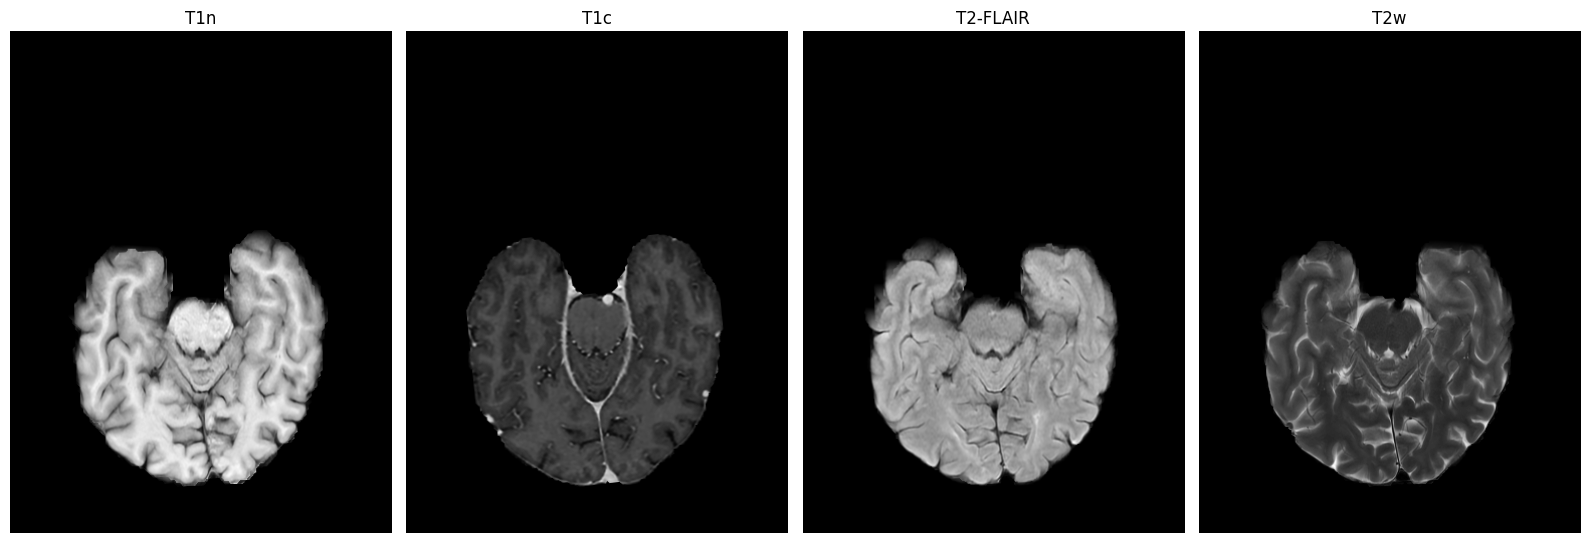

In [14]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

path_t1n = "/notebooks/BraTS-MET-01320-001-t1n.nii.gz"
path_t1c = "/notebooks/BraTS-MET-01320-001-t1c.nii.gz"
path_t2f = "/notebooks/BraTS-MET-01320-001-t2f.nii.gz"
path_t2w = "/notebooks/BraTS-MET-01320-001-t2w.nii.gz"

modalidades = {
    "T1n": path_t1n,
    "T1c": path_t1c,
    "T2-FLAIR": path_t2f,
    "T2w": path_t2w
}

fig, axs = plt.subplots(1, 4, figsize=(16, 6))

for i, (name, path) in enumerate(modalidades.items()):
    img = nib.load(path)
    data = img.get_fdata()
    spacing = img.header.get_zooms()[:3]  # (x, y, z)

    slice_idx = data.shape[2] // 2  # corte axial intermedio
    slice_axial = data[:, :, slice_idx]

    axs[i].imshow(slice_axial.T, cmap="gray", origin="lower", aspect=spacing[1]/spacing[0])
    axs[i].set_title(name)
    axs[i].axis("off")

plt.tight_layout()
plt.show()

# 1. Preprocesado

## 1.1 Preprocesado Conjunto de Training y Validation

Con el objetivo de preparar los volúmenes para su uso en modelos de aprendizaje profundo, se aplicó un proceso de preprocesamiento uniforme sobre todos los casos del conjunto de entrenamiento, tanto en el espacio nativo (UCSD) como en el espacio SRI24. Este proceso consistió en las siguientes etapas:

Modalidades disponibles

Cada caso incluye hasta cuatro modalidades de imagen por resonancia magnética (MRI), que se usaron como canales independientes:
- T1n (T1-weighted native)
- T1c (T1-weighted contrast-enhanced)
- T2f (T2-weighted FLAIR)
- T2w (T2-weighted spin echo)

Estas modalidades se combinaron como un volumen multicanal con forma final (128, 128, 128, 4).

Etapas del preprocesado
1. Corrección de bias de intensidad (N4 Bias Field Correction)
Se aplicó la corrección N4ITK a las modalidades T1n y T1c para reducir artefactos relacionados con inhomogeneidades del campo magnético. Esta corrección se realizó utilizando la biblioteca SimpleITK, aplicando una máscara binaria basada en la segmentación (si estaba disponible).
2. Normalización por canal (Z-score)
Cada canal se normalizó individualmente mediante la resta de la media y la división por la desviación estándar. Si la desviación estándar era menor a un umbral (10^-5), el canal se reemplazaba por ceros. Esta normalización estandariza la intensidad entre sujetos y modalidades.
3. Redimensionamiento a resolución uniforme
Todos los volúmenes fueron redimensionados a una forma fija de 128×128×128 mediante interpolación. Las imágenes se redimensionaron con interpolación lineal (orden 1), y las máscaras con interpolación de tipo nearest-neighbor (orden 0), asegurando que los valores discretos de clase se conservaran.
4. Exportación como archivos .npy
Los volúmenes preprocesados (imágenes y máscaras) se guardaron en formato NumPy comprimido (.npy) dentro de la carpeta /notebooks/PreprocesadoAll.

Consideraciones adicionales
- Si un caso ya había sido preprocesado correctamente, se omitía su reprocesamiento.
- En caso de detectar archivos corruptos, el caso era reprocesado desde cero.
- Este procedimiento se aplicó a todos los casos del conjunto de entrenamiento, tanto los que pertenecen al dominio UCSD como los normalizados al espacio SRI24.

Este preprocesamiento permitió estandarizar la entrada al modelo y minimizar variabilidad técnica entre muestras, facilitando así una mejor convergencia durante el entrenamiento.

In [1]:
!pip install -q nibabel SimpleITK tqdm

import os
import nibabel as nib
import numpy as np
import scipy.ndimage as ndimage
import SimpleITK as sitk
from tqdm import tqdm

# Rutas
training_path = "/notebooks/Training"
ucsd_path = os.path.join(training_path, "UCSD - Training")
output_path = "/notebooks/PreprocesadoAll"
os.makedirs(output_path, exist_ok=True)

# Corrección N4
def bias_correct_image(nib_img, mask=None, shrink_factor=4, its=(50, 50, 50, 30)):
    sitk_img = sitk.GetImageFromArray(nib_img.astype(np.float32))
    mask_sitk = sitk.GetImageFromArray((mask > 0).astype(np.uint8)) if mask is not None else None
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetMaximumNumberOfIterations(list(its))
    result = corrector.Execute(sitk_img, mask_sitk) if mask_sitk else corrector.Execute(sitk_img)
    return sitk.GetArrayFromImage(result)

# Función general
def preprocess_case(case_path, case_id, target_size=128):
    out_img = os.path.join(output_path, f"{case_id}_image.npy")
    out_mask = os.path.join(output_path, f"{case_id}_mask.npy")

    if os.path.exists(out_img) and os.path.exists(out_mask):
        try:
            np.load(out_img)
            np.load(out_mask)
            print(f"⏩ {case_id} ya existe, se omite.")
            return
        except:
            print(f"{case_id} con archivos corruptos. Se reprocesa.")

    # Modalidades
    modalities = {"t1n": "-t1n.nii.gz", "t1c": "-t1c.nii.gz", "t2f": "-t2f.nii.gz", "t2w": "-t2w.nii.gz"}
    image_list = []
    ref = None

    for suffix in modalities.values():
        files = [f for f in os.listdir(case_path) if f.endswith(suffix)]
        if files:
            ref = nib.load(os.path.join(case_path, files[0])).get_fdata().astype(np.float32)
            break
    if ref is None:
        print(f"{case_id} sin imágenes válidas.")
        return

    seg_files = [f for f in os.listdir(case_path) if f.endswith("-seg.nii.gz")]
    seg = nib.load(os.path.join(case_path, seg_files[0])).get_fdata().astype(np.uint8) if seg_files else None
    mask = seg.astype(bool) if seg is not None else None

    # Bias correction por canal
    corrected_channels = []
    for name, suffix in modalities.items():
        files = [f for f in os.listdir(case_path) if f.endswith(suffix)]
        img = nib.load(os.path.join(case_path, files[0])).get_fdata().astype(np.float32) if files else np.zeros_like(ref)
        if name in ["t1n", "t1c"]:
            img = bias_correct_image(img, mask=mask, shrink_factor=4)
        corrected_channels.append(img)
    image = np.stack(corrected_channels, axis=-1)

    # Normalización por canal (después de N4)
    for c in range(image.shape[-1]):
        mean = image[..., c].mean()
        std = image[..., c].std()
        image[..., c] = (image[..., c] - mean) / std if std > 1e-5 else np.zeros_like(image[..., c])

    # Resize
    zoom = (
        target_size / ref.shape[0],
        target_size / ref.shape[1],
        target_size / ref.shape[2]
    )
    resized_img = ndimage.zoom(image, zoom + (1,), order=1)
    resized_seg = ndimage.zoom(seg, zoom, order=0).astype(np.uint8) if seg is not None else np.zeros((target_size,)*3, dtype=np.uint8)

    # Guardar
    np.save(out_img, resized_img)
    np.save(out_mask, resized_seg)
    print(f"✅ Preprocesado: {case_id}")

# Ejecutar
# Procesar casos UCSD
ucsd_cases = [d for d in os.listdir(ucsd_path) if os.path.isdir(os.path.join(ucsd_path, d))]
for case_id in tqdm(ucsd_cases, desc="UCSD"):
    preprocess_case(os.path.join(ucsd_path, case_id), case_id)

# Procesar casos SRI24
all_cases = [d for d in os.listdir(training_path) if os.path.isdir(os.path.join(training_path, d)) and d != "UCSD - Training"]
for case_id in tqdm(all_cases, desc="SRI24"):
    preprocess_case(os.path.join(training_path, case_id), case_id)

UCSD:   0%|          | 2/646 [00:00<02:22,  4.53it/s]

⏩ BraTS-MET-01195-002 ya existe, se omite.
⏩ BraTS-MET-01230-000 ya existe, se omite.


UCSD:   1%|          | 4/646 [00:00<01:54,  5.58it/s]

⏩ BraTS-MET-01169-000 ya existe, se omite.
⏩ BraTS-MET-01333-003 ya existe, se omite.


UCSD:   1%|          | 6/646 [00:01<01:42,  6.27it/s]

...

✅ Preprocesado: BraTS-MET-00652-000


SRI24: 100%|█████████▉| 649/650 [1:48:49<00:37, 37.79s/it]

✅ Preprocesado: BraTS-MET-00547-000


SRI24: 100%|██████████| 650/650 [1:48:54<00:00, 10.05s/it]

✅ Preprocesado: BraTS-MET-00591-000


## 1.2 Preprocesado Conjunto de test

El conjunto de validación oficial proporcionado por los organizadores del reto BraTS-METS 2025 fue procesado para homogeneizar su formato con el conjunto de entrenamiento. Al tratarse de casos reales sin segmentación disponible (solo imágenes), se aplicaron únicamente las transformaciones necesarias sobre las modalidades de imagen. Las máscaras no están presentes, ya que este conjunto está destinado a evaluación ciega.

Modalidades incluidas

Cada caso contiene las cuatro modalidades estándar de resonancia magnética:
- T1n (T1-weighted native)
- T1c (T1-weighted contrast-enhanced)
- T2f (T2-weighted FLAIR)
- T2w (T2-weighted spin echo)

Estas se integraron como un volumen multicanal con forma final (128, 128, 128, 4).

Etapas del preprocesado
1. Corrección de bias de intensidad (N4 Bias Field Correction)
Se aplicó la corrección N4ITK a todas las modalidades, sin necesidad de una máscara anatómica, para reducir las inhomogeneidades del campo magnético que afectan la intensidad de la señal.
2. Normalización por canal (Z-score)
Cada volumen individual fue normalizado por canal, restando su media y dividiendo por su desviación estándar. Se añadió un pequeño valor epsilon $$
\epsilon = 10^{-8}
$$ para evitar divisiones por cero.
3. Redimensionamiento uniforme
Todos los volúmenes fueron interpolados a una forma estándar de 128×128×128 mediante interpolación lineal (orden 1), asegurando compatibilidad con los modelos de entrenamiento.
4. Exportación a .npy
Los volúmenes procesados fueron guardados como archivos NumPy comprimidos (.npy) en la ruta /notebooks/PreprocesadoValidation, bajo el formato <case_id>_image.npy.

Consideraciones
- No se aplicó ningún filtrado, ya que no se dispone de segmentaciones para validación.
- Este conjunto fue empleado en las etapas finales de inferencia y evaluación del pipeline, simulando condiciones reales de despliegue sin conocimiento previo de la verdad de terreno (ground truth).


In [9]:
!pip install -q nibabel SimpleITK tqdm

import os
import nibabel as nib
import numpy as np
import SimpleITK as sitk
import scipy.ndimage as ndimage
from tqdm import tqdm

# Rutas
validation_path = "/notebooks/validation"  # ← input: casos test originales
output_path = "/notebooks/PreprocesadoValidation"  # ← output: preprocesados
os.makedirs(output_path, exist_ok=True)

# Corrección de bias field con N4ITK
def bias_correct_image(nib_img, mask=None, shrink_factor=4, its=(50, 50, 50, 30)):
    sitk_img = sitk.GetImageFromArray(nib_img.astype(np.float32))
    if mask is not None:
        mask_sitk = sitk.GetImageFromArray((mask > 0).astype(np.uint8))
    else:
        mask_sitk = None

    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetMaximumNumberOfIterations(list(its))
    corrected = corrector.Execute(sitk_img, mask_sitk) if mask_sitk is not None else corrector.Execute(sitk_img)

    return sitk.GetArrayFromImage(corrected)

# Modalidades esperadas
modalities = {
    "t1n": "-t1n.nii.gz",
    "t1c": "-t1c.nii.gz",
    "t2f": "-t2f.nii.gz",
    "t2w": "-t2w.nii.gz"
}

# Preprocesado
target_shape = (128, 128, 128)
validation_cases = sorted(os.listdir(validation_path))

for case_id in tqdm(validation_cases, desc="🧪 Preprocesando casos de validación"):
    out_path = os.path.join(output_path, f"{case_id}_image.npy")

    # Omitir si ya fue procesado
    if os.path.exists(out_path):
        continue

    images = []
    for mod, suffix in modalities.items():
        path = os.path.join(validation_path, case_id, case_id + suffix)
        img = nib.load(path).get_fdata()
        img = bias_correct_image(img)  # Bias field correction
        img = (img - np.mean(img)) / (np.std(img) + 1e-8)  # Normalización z-score
        img = ndimage.zoom(img, np.array(target_shape) / np.array(img.shape), order=1) # Resize lineal
        images.append(img.astype(np.float32))

    stacked_img = np.stack(images, axis=-1)  # Shape: (128, 128, 128, 4)
    np.save(out_path, stacked_img)

🧪 Preprocesando casos de validación: 100%|██████████| 179/179 [00:00<00:00, 175456.98it/s]


# 2. Verificación y análisis exploratorio de los datos preprocesados

## 2.1 Carga y visualización de volúmenes preprocesados

Para validar visualmente la calidad del preprocesado y la correcta alineación entre las modalidades de imagen y sus correspondientes máscaras de segmentación, se seleccionaron casos representativos del conjunto de entrenamiento. Se cargaron los volúmenes preprocesados (.npy) y se visualizaron cortes axiales, coronales y sagitales sobre distintas modalidades.

Además, se incluyó la visualización superpuesta de las máscaras multiclase usando una codificación de color por clase:
- Clase 1 (NETC): Rojo
- Clase 2 (SNFH): Verde
- Clase 3 (ET): Amarillo
- Clase 4 (RC): Cyan

Esto permitió corroborar la coherencia espacial entre las imágenes y sus etiquetas, así como la presencia efectiva de regiones tumorales de cada clase.

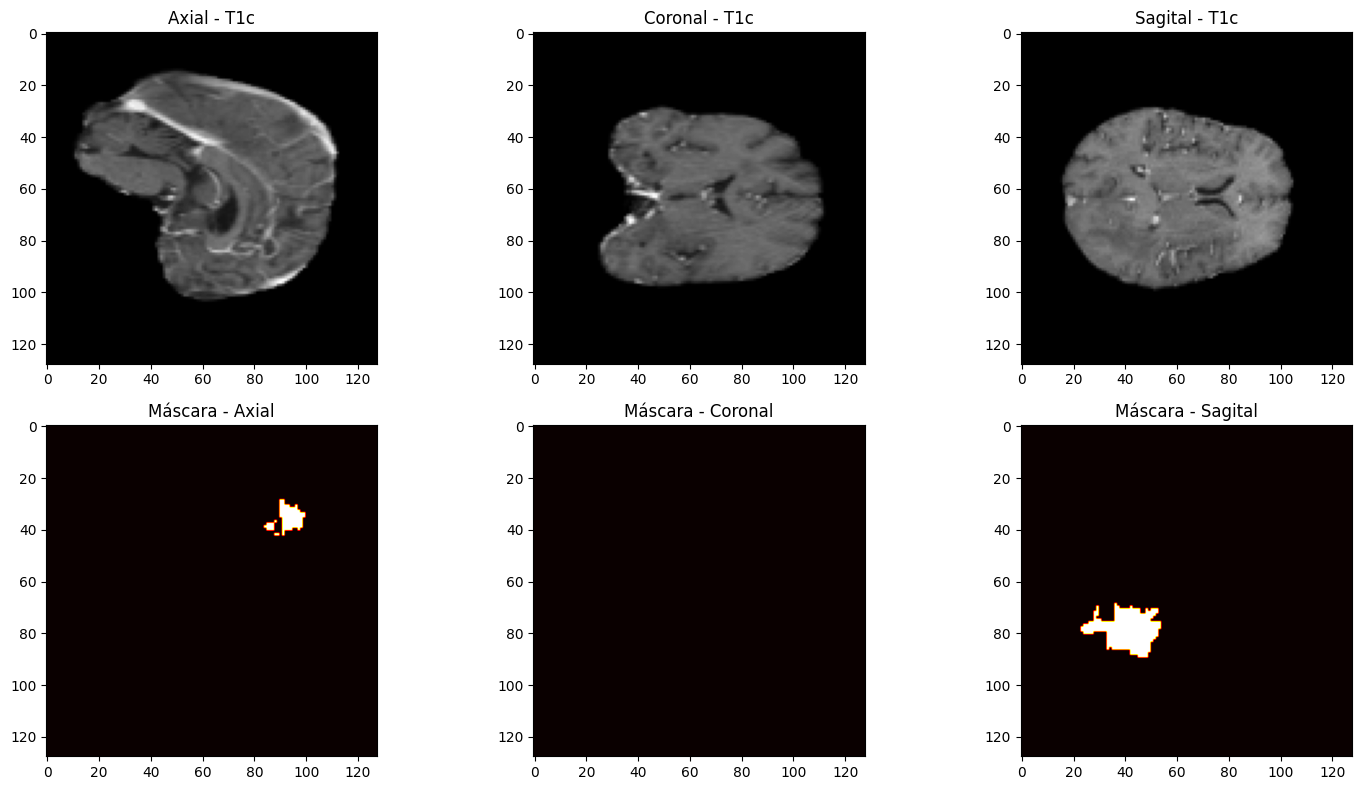

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Ruta de los .npy
path = "/notebooks/PreprocesadoAll"
case_id = "BraTS-MET-00128-000"

# Cargar imagen y máscara
image = np.load(os.path.join(path, f"{case_id}_image.npy"))  # (128,128,128,4)
mask = np.load(os.path.join(path, f"{case_id}_mask.npy"))    # (128,128,128)

# Ver una modalidad concreta 
modality_names = ["T1n", "T1c", "T2f", "T2w"]
modality = 1# T1c

# Cortes a mostrar
slice_z = 64  # corte axial
slice_y = 64  # coronal
slice_x = 64  # sagital

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0,0].imshow(image[slice_z,:,:,modality], cmap='gray'); axs[0,0].set_title(f"Axial - {modality_names[modality]}")
axs[0,1].imshow(image[:,slice_y,:,modality], cmap='gray'); axs[0,1].set_title(f"Coronal - {modality_names[modality]}")
axs[0,2].imshow(image[:,:,slice_x,modality], cmap='gray'); axs[0,2].set_title(f"Sagital - {modality_names[modality]}")

axs[1,0].imshow(mask[slice_z,:,:], cmap='hot'); axs[1,0].set_title("Máscara - Axial")
axs[1,1].imshow(mask[:,slice_y,:], cmap='hot'); axs[1,1].set_title("Máscara - Coronal")
axs[1,2].imshow(mask[:,:,slice_x], cmap='hot'); axs[1,2].set_title("Máscara - Sagital")

plt.tight_layout()
plt.show()

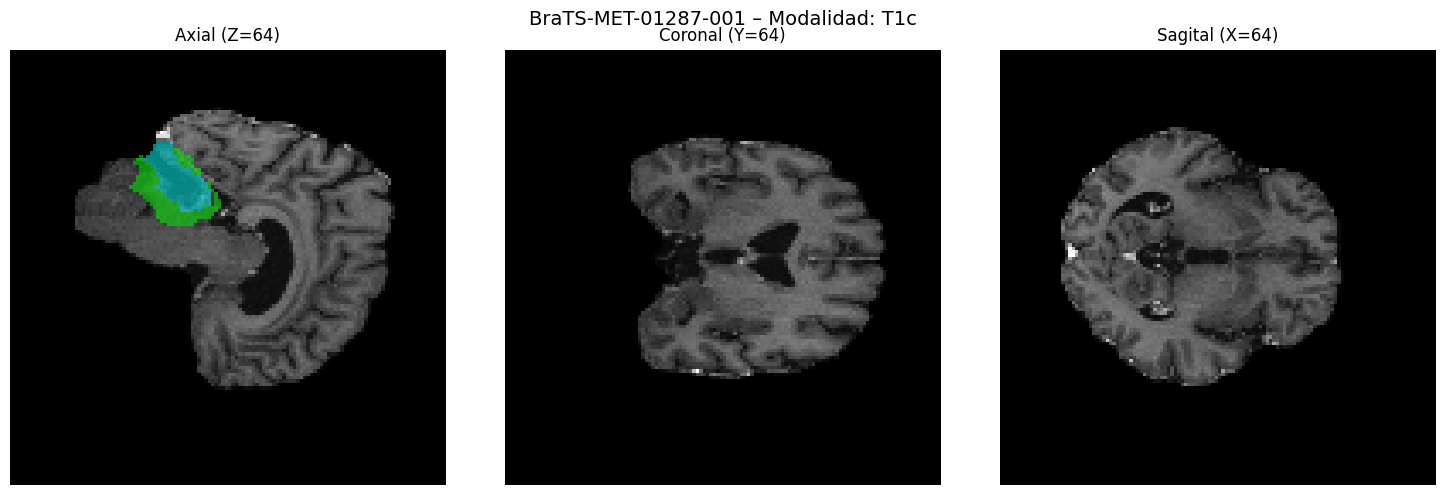

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Rutas y parámetros
base_path = "/notebooks/PreprocesadoAll"
case_id = "BraTS-MET-01287-001"
image = np.load(os.path.join(base_path, f"{case_id}_image.npy"))  # (128,128,128,4)
mask  = np.load(os.path.join(base_path, f"{case_id}_mask.npy"))   # (128,128,128)
modality = 1  # T1c

# Colores RGBA para cada clase (con alpha)
colors = {
    1: (1.0, 0.0, 0.0, 0.5),  # Rojo
    2: (0.0, 1.0, 0.0, 0.5),  # Verde
    3: (1.0, 1.0, 0.0, 0.5),  # Amarillo
    4: (0.0, 1.0, 1.0, 0.5),  # Cyan
}

# Cortes centrales
slice_z = image.shape[0] // 2  # Axial (Z)
slice_y = image.shape[1] // 2  # Coronal (Y)
slice_x = image.shape[2] // 2  # Sagital (X)

# Función para crear overlay
def create_overlay(base_slice, mask_slice):
    overlay = np.zeros((*base_slice.shape, 4))
    for label, color in colors.items():
        overlay[mask_slice == label] = color
    return overlay

# Crear figura con 3 cortes
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Axial
img_axial = image[slice_z, :, :, modality]
msk_axial = mask[slice_z, :, :]
axs[0].imshow(img_axial, cmap='gray')
axs[0].imshow(create_overlay(img_axial, msk_axial))
axs[0].set_title(f'Axial (Z={slice_z})')
axs[0].axis('off')

# Coronal
img_coronal = image[:, slice_y, :, modality]
msk_coronal = mask[:, slice_y, :]
axs[1].imshow(img_coronal, cmap='gray')
axs[1].imshow(create_overlay(img_coronal, msk_coronal))
axs[1].set_title(f'Coronal (Y={slice_y})')
axs[1].axis('off')

# Sagital
img_sagittal = image[:, :, slice_x, modality]
msk_sagittal = mask[:, :, slice_x]
axs[2].imshow(img_sagittal, cmap='gray')
axs[2].imshow(create_overlay(img_sagittal, msk_sagittal))
axs[2].set_title(f'Sagital (X={slice_x})')
axs[2].axis('off')

plt.suptitle(f'{case_id} – Modalidad: T1c', fontsize=14)
plt.tight_layout()
plt.show()

## 2.2 Comprobación de máscaras y clases presentes

Se implementaron rutinas automáticas para verificar la integridad del conjunto preprocesado:
- Chequeo de tamaño mínimo: para detectar archivos anómalos por tamaño excesivamente bajo.
- Carga y comprobación de formas: tanto para imágenes (esperadas como (128,128,128,4)) como para máscaras (128,128,128).
- Reporte de errores: se registraron y mostraron los archivos corruptos o con formas incorrectas.

El resultado confirmó que todos los archivos estaban completos, correctamente formateados y sin errores de corrupción o incompatibilidad dimensional.

In [4]:
import os
import numpy as np

# Configura tu ruta y las formas esperadas
preprocessed_path = "/notebooks/PreprocesadoAll"  # Cambia si es necesario
expected_image_shape = (128, 128, 128, 4)
expected_mask_shape = (128, 128, 128)
min_file_size_bytes = 100000  # ~100 KB como mínimo razonable

# Exploración
corrupt_files = []
size_issues = []
shape_issues = []

print("Comprobando archivos preprocesados...\n")

for fname in os.listdir(preprocessed_path):
    if fname.endswith(".npy"):
        fpath = os.path.join(preprocessed_path, fname)

        # 1. Chequeo de tamaño en disco
        file_size = os.path.getsize(fpath)
        if file_size < min_file_size_bytes:
            size_issues.append((fname, file_size))
            continue  # ni lo intentamos cargar

        # 2. Intentamos cargarlo
        try:
            arr = np.load(fpath)
        except Exception as e:
            corrupt_files.append((fname, str(e)))
            continue

        # 3. Chequeamos forma
        if "mask" in fname:
            expected_shape = expected_mask_shape
        else:
            expected_shape = expected_image_shape

        if arr.shape != expected_shape:
            shape_issues.append((fname, arr.shape))

# Reporte
print("\nResultados:")
print(f"Archivos corruptos: {len(corrupt_files)}")
for f, err in corrupt_files:
    print(f"   - {f} → {err}")

print(f"\nArchivos con tamaño anómalo (<{min_file_size_bytes} bytes): {len(size_issues)}")
for f, sz in size_issues:
    print(f"   - {f} → {sz} bytes")

print(f"\nArchivos con forma incorrecta: {len(shape_issues)}")
for f, shape in shape_issues:
    print(f"   - {f} → {shape} (esperado: {expected_image_shape} o {expected_mask_shape})")

if not corrupt_files and not size_issues and not shape_issues:
    print("\nTodo correcto: no se detectaron errores")

Comprobando archivos preprocesados...


Resultados:
Archivos corruptos: 0

Archivos con tamaño anómalo (<100000 bytes): 0

Archivos con forma incorrecta: 0

Todo correcto: no se detectaron errores


## 2.3 Identificación de casos con y sin metástasis

Se recorrieron todas las máscaras preprocesadas para contabilizar los casos con presencia tumoral (al menos un voxel distinto de 0) y aquellos sin metástasis. Este análisis permitió identificar que:
- 1263 casos contenían metástasis.
- 32 casos no presentaban ningún voxel etiquetado como tumor.
- En total se analizaron 1295 casos del conjunto de entrenamiento.

Esta información fue útil para evaluar el grado de desbalance del conjunto y fundamentar posteriores estrategias de oversampling y detección binaria.

In [5]:
import os
import numpy as np

# Ruta a los preprocesados
mask_path = "/notebooks/PreprocesadoAll"

# Inicializar contadores
cases_with_met = []
cases_without_met = []

# Recorrer máscaras
for fname in sorted(os.listdir(mask_path)):
    if fname.endswith("_mask.npy"):
        full_path = os.path.join(mask_path, fname)
        mask = np.load(full_path)
        case_id = fname.replace("_mask.npy", "")

        if np.any(mask > 0):
            cases_with_met.append(case_id)
        else:
            cases_without_met.append(case_id)

# Resultados
print(f"Casos con metástasis: {len(cases_with_met)}")
print(f"Casos sin metástasis: {len(cases_without_met)}")
print(f"Total de casos analizados: {len(cases_with_met) + len(cases_without_met)}")

Casos con metástasis: 1263
Casos sin metástasis: 32
Total de casos analizados: 1295


Finalmente, se analizó la frecuencia de aparición de cada clase tumoral en las máscaras multiclase. Se contabilizó en cuántos casos aparecía al menos un voxel de cada clase:
- Clase 1 (NETC): 684 casos (52.8%)
- Clase 2 (SNFH): 1139 casos (88.0%)
- Clase 3 (ET): 1245 casos (96.1%)
- Clase 4 (RC): 163 casos (12.6%)

Estos resultados confirman un fuerte desequilibrio en la clase 4 (RC) y un también para la clase 1 (NETC), que será tenido en cuenta al definir las estrategias de entrenamiento, especialmente en el modelo segmentador.

In [15]:
import os
import numpy as np
from collections import defaultdict

# Ruta a las máscaras
path = "/notebooks/PreprocesadoAll"
mask_files = [f for f in os.listdir(path) if f.endswith("_mask.npy")]

# Diccionario para contar ocurrencias por clase
class_counts = defaultdict(int)

# Recorrer máscaras
for fname in mask_files:
    mask = np.load(os.path.join(path, fname))
    unique_labels = np.unique(mask)

    for label in unique_labels:
        if label in [1, 2, 3, 4]:
            class_counts[int(label)] += 1

# Mostrar resultados
print("Casos que contienen al menos un voxel de cada clase:")
total_cases = len(mask_files)
for cls in [1, 2, 3, 4]:
    count = class_counts[cls]
    percent = (count / total_cases) * 100
    print(f"Clase {cls}: {count} casos ({percent:.1f}%)")

print(f"\nTotal de máscaras analizadas: {total_cases}")

Casos que contienen al menos un voxel de cada clase:
Clase 1: 684 casos (52.8%)
Clase 2: 1139 casos (88.0%)
Clase 3: 1245 casos (96.1%)
Clase 4: 163 casos (12.6%)

Total de máscaras analizadas: 1295


In [6]:
import numpy as np

mask = np.load("/notebooks/PreprocesadoAll/BraTS-MET-01063-000_mask.npy")
print("Valores únicos en la máscara:", np.unique(mask))

Valores únicos en la máscara: [0 2 3]


## 2.4 Casos Problemáticos

Se realizó una verificación automática sobre los 1296 casos preprocesados para comprobar que:
- Cada caso tiene tanto la imagen como la máscara asociada.
- Las formas de los arrays son consistentes.
- No hay errores de lectura de archivos.
- Las máscaras contienen únicamente valores válidos en el rango [0–4].

Como resultado, se encontró un único caso con clases fuera del rango permitido:
   - BraTS-MET-01094-002 contenía etiquetas [0, 3, 6], donde el valor 6 no es válido.

Este caso fue eliminado del conjunto final para evitar inconsistencias durante el entrenamiento y evaluación.

In [10]:
import os
import numpy as np

# 📂 Ruta a revisar
path = "/notebooks/PreprocesadoAll"

# 🔧 Parámetros esperados
expected_image_shape = (128, 128, 128, 4)
expected_mask_shape = (128, 128, 128)
valid_labels = {0, 1, 2, 3, 4}

# 🧠 Inicializar
all_files = os.listdir(path)
image_ids = set(f.replace("_image.npy", "") for f in all_files if f.endswith("_image.npy"))
mask_ids  = set(f.replace("_mask.npy", "") for f in all_files if f.endswith("_mask.npy"))

all_ids = sorted(image_ids | mask_ids)

# 📋 Resultados
missing_image = []
missing_mask = []
shape_errors = []
load_errors = []
invalid_label_cases = []

print(f"🔍 Verificando {len(all_ids)} casos...\n")

for case_id in all_ids:
    img_path = os.path.join(path, f"{case_id}_image.npy")
    msk_path = os.path.join(path, f"{case_id}_mask.npy")

    # 1. Verificar existencia
    if not os.path.exists(img_path):
        missing_image.append(case_id)
        continue
    if not os.path.exists(msk_path):
        missing_mask.append(case_id)
        continue

    # 2. Verificar carga
    try:
        img = np.load(img_path)
        msk = np.load(msk_path)
    except Exception as e:
        load_errors.append((case_id, str(e)))
        continue

    # 3. Verificar formas
    if img.shape != expected_image_shape or msk.shape != expected_mask_shape:
        shape_errors.append((case_id, img.shape, msk.shape))
        continue

    # 4. Verificar valores en la máscara
    unique_vals = set(np.unique(msk))
    if not unique_vals.issubset(valid_labels):
        invalid_label_cases.append((case_id, unique_vals))

# ✅ Resumen
print("✅ Verificación completa\n")

print(f"📦 Casos totales encontrados: {len(all_ids)}")
print(f"✅ Casos OK (imagen + máscara, forma y clases válidas): {len(all_ids) - len(missing_image) - len(missing_mask) - len(shape_errors) - len(load_errors) - len(invalid_label_cases)}")
print(f"❌ Casos sin imagen: {len(missing_image)}")
print(f"❌ Casos sin máscara: {len(missing_mask)}")
print(f"⚠️ Casos con error de forma: {len(shape_errors)}")
print(f"⚠️ Casos con error al cargar: {len(load_errors)}")
print(f"⚠️ Casos con valores de clase inválidos: {len(invalid_label_cases)}")

# Mostrar detalles si los hay
if invalid_label_cases:
    print("\n🔺 Casos con valores fuera de 0–4:")
    for cid, labels in invalid_label_cases:
        print(f" - {cid}: valores encontrados {sorted(labels)}")

if missing_image: print("\nCasos sin imagen:", missing_image)
if missing_mask: print("\nCasos sin máscara:", missing_mask)
if shape_errors:
    print("\nCasos con forma incorrecta:")
    for cid, img_shape, msk_shape in shape_errors:
        print(f" - {cid}: image {img_shape}, mask {msk_shape}")
if load_errors:
    print("\nCasos con error de carga:")
    for cid, err in load_errors:
        print(f" - {cid}: {err}")

🔍 Verificando 1296 casos...

✅ Verificación completa

📦 Casos totales encontrados: 1296
✅ Casos OK (imagen + máscara, forma y clases válidas): 1295
❌ Casos sin imagen: 0
❌ Casos sin máscara: 0
⚠️ Casos con error de forma: 0
⚠️ Casos con error al cargar: 0
⚠️ Casos con valores de clase inválidos: 1

🔺 Casos con valores fuera de 0–4:
 - BraTS-MET-01094-002: valores encontrados [0, 3, 6]


In [11]:
import os

base = "/notebooks/PreprocesadoAll"
case_id = "BraTS-MET-01094-002"

image_path = os.path.join(base, f"{case_id}_image.npy")
mask_path = os.path.join(base, f"{case_id}_mask.npy")

# Eliminar si existen
for path in [image_path, mask_path]:
    if os.path.exists(path):
        os.remove(path)
        print(f"🗑️ Eliminado: {path}")

🗑️ Eliminado: /notebooks/PreprocesadoAll/BraTS-MET-01094-002_image.npy
🗑️ Eliminado: /notebooks/PreprocesadoAll/BraTS-MET-01094-002_mask.npy


## 2.5 Estadísticas descriptivas: media, desviación estándar y valores extremos por conjunto

Se calculan estadísticas básicas (*media*, *desviación estándar*, *mínimo* y *máximo*) sobre los volúmenes preprocesados del conjunto de entrenamiento y validación. Cada volumen `.npy` contiene las **4 modalidades** (*T1n*, *T1c*, *T2f*, *T2w*) tras aplicar la **corrección de bias field**, la **normalización z-score por canal** y el **resize a 128×128×128**.

Estas estadísticas permiten verificar que la normalización fue aplicada correctamente y que no hay valores atípicos extremos que puedan perjudicar el entrenamiento del modelo:

- La **media cercana a 0** y la **desviación estándar cercana a 1** confirman que el *z-score* fue correctamente aplicado.
- El **máximo elevado** (*98.47 en train*, *23.65 en val*) corresponde probablemente a intensidades puntuales del canal **T1c**, que conserva contraste tras la corrección *N4*.

In [2]:
import os
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# Ruta donde guardaste los .npy
preprocessed_path = "/notebooks/PreprocesadoAll"

# Función para calcular estadísticas por conjunto
def compute_stats(case_ids):
    stats = defaultdict(list)
    for cid in tqdm(case_ids):
        path = os.path.join(preprocessed_path, f"{cid}_image.npy")
        img = np.load(path)
        stats["mean"].append(img.mean())
        stats["std"].append(img.std())
        stats["min"].append(img.min())
        stats["max"].append(img.max())
    return {
        "mean": np.mean(stats["mean"]),
        "std": np.mean(stats["std"]),
        "min": np.min(stats["min"]),
        "max": np.max(stats["max"])
    }

# Extraer ids
all_cases = sorted([f[:-10] for f in os.listdir(preprocessed_path) if f.endswith("_image.npy")])
from sklearn.model_selection import train_test_split
train_ids, val_ids = train_test_split(all_cases, test_size=0.2, random_state=42)

# Estadísticas
train_stats = compute_stats(train_ids)
val_stats = compute_stats(val_ids)

print("\nStats por conjunto:")
print("Train:", train_stats)
print("Val  :", val_stats)

100%|██████████| 259/259 [01:23<00:00,  3.10it/s]


Stats por conjunto:
Train: {'mean': -0.0037743999, 'std': 0.98777896, 'min': -0.9819454, 'max': 98.46961}
Val  : {'mean': -0.0037960005, 'std': 0.9877202, 'min': -0.48967487, 'max': 23.657091}


# 3. Creación de Patches

## 3.1 Distribución de voxeles tumorales por parche


En esta figura se representa la distribución del número de **vóxeles tumorales por parche 3D**, utilizando una **escala logarítmica**. Esta visualización permite:

- Analizar la *presencia de señal tumoral* en los parches extraídos del dataset preprocesado.
- Establecer un **umbral (`POS_THRESH`)** que determine si un parche debe considerarse *positivo* (contiene tumor) o *negativo* (solo fondo).

> Se evaluaron distintos valores para `POS_THRESH`, definidos como el número mínimo de vóxeles tumorales necesarios para etiquetar un parche como positivo:

- `POS_THRESH = 50` (línea naranja discontinua)  
- `POS_THRESH = 100` (línea verde discontinua)  
- `POS_THRESH = 200` (línea roja discontinua)  

La distribución muestra una **asimetría pronunciada hacia la izquierda**, indicando que:

- La mayoría de los parches contienen **muy pocos vóxeles tumorales**.
- Existe un **fuerte desbalance de clases** en el problema, ya que una gran parte del volumen cerebral no presenta tumor.
- Este efecto es especialmente notable en **metástasis pequeñas** o en **fases tempranas** de diseminación.

> Elegir un threshold adecuado permite *balancear la sensibilidad del modelo*, evitando:
>
> - Falsos negativos (parches con tumor no detectados)
> - Falsos positivos (parches de fondo mal clasificados como tumorales)

Analizando parches: 100%|██████████| 1295/1295 [00:18<00:00, 69.64it/s]


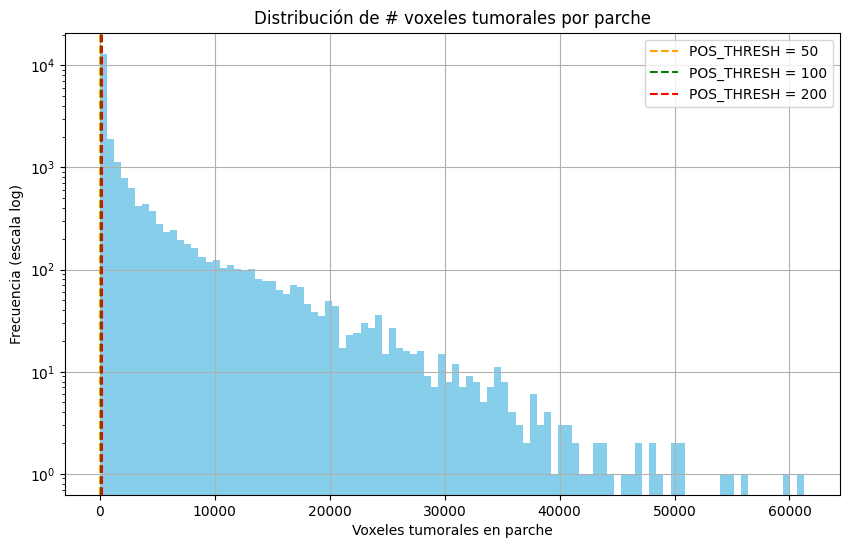

In [16]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# Ruta de volúmenes preprocesados
preprocessed_path = "/notebooks/PreprocesadoAll"
PATCH_SIZE = (64, 64, 64)
STRIDE = 32

voxel_counts = []

# Analizar todas las máscaras
all_cases = sorted([
    f.replace("_mask.npy", "")
    for f in os.listdir(preprocessed_path)
    if f.endswith("_mask.npy")
])
for case_id in tqdm(all_cases, desc="Analizando parches"):
    mask = np.load(os.path.join(preprocessed_path, f"{case_id}_mask.npy"))
    dz, dy, dx = PATCH_SIZE
    for z in range(0, mask.shape[0] - dz + 1, STRIDE):
        for y in range(0, mask.shape[1] - dy + 1, STRIDE):
            for x in range(0, mask.shape[2] - dx + 1, STRIDE):
                patch = mask[z:z+dz, y:y+dy, x:x+dx]
                count = np.count_nonzero(patch)
                if count > 0:
                    voxel_counts.append(count)

# Histograma logarítmico
plt.figure(figsize=(10, 6))
plt.hist(voxel_counts, bins=100, log=True, color='skyblue')
plt.axvline(50, color='orange', linestyle='--', label='POS_THRESH = 50')
plt.axvline(100, color='green', linestyle='--', label='POS_THRESH = 100')
plt.axvline(200, color='red', linestyle='--', label='POS_THRESH = 200')
plt.title("Distribución de # voxeles tumorales por parche")
plt.xlabel("Voxeles tumorales en parche")
plt.ylabel("Frecuencia (escala log)")
plt.legend()
plt.grid(True)
plt.show()

## 3.2 Generación de parches 3D para el modelo detector binario

En este bloque se realiza la **extracción de parches 3D** a partir de los volúmenes completos ya preprocesados (`128×128×128×4`). Cada parche se genera junto con su correspondiente sub-máscara, y se le asigna una **etiqueta binaria**:

- **Etiqueta 1 (positivo):** el parche contiene al menos `POS_THRESH` vóxeles tumorales.
- **Etiqueta 0 (negativo):** el parche contiene únicamente fondo.

Además, se calcula la **clase dominante** (`1`, `2`, `3` o `4`) dentro de cada parche, útil para:

- Análisis posteriores de distribución por clase.
- Estrategias de **segmentación dirigidas** por tipo tumoral.

> Se aplica una estrategia de **oversampling dirigido** para compensar el desbalance de clases:
>
> - Los parches **positivos con clase dominante = 4** (la más minoritaria) se **duplican x3** en el conjunto de entrenamiento.

---

### Pipeline de generación de parches

El proceso completo sigue los siguientes pasos:

1. **División** de los casos en entrenamiento y validación mediante `train_test_split` por ID de paciente.
2. **Iteración** sobre los volúmenes completos para extraer parches 3D con un `stride` definido.
3. **Cálculo** de la etiqueta binaria (`label_bin`) y la clase dominante de cada parche.
4. **Guardado** de cada parche como archivo `.npz` con los siguientes campos: patch, mask, label_bin, clase_dominante, coord, case_id

Los parches se almacenan en subcarpetas organizadas por:

- `train/` y `val/` (según el split)
- `pos/` y `neg/` (según la etiqueta binaria)

Esto **facilita la carga eficiente** en TensorFlow mediante `tf.data.Dataset` y permite aplicar políticas de balanceo o sampling específicas durante el entrenamiento del detector.

In [ ]:
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Rutas
preprocessed_path = "/notebooks/PreprocesadoAll"
patches_output_path = "/notebooks/patches_detector"
os.makedirs(patches_output_path, exist_ok=True)

PATCH_SIZE = (64, 64, 64)
STRIDE = 32
POS_THRESH = 100  # voxels tumorales mínimos para parche positivo
OVERSAMPLE_CLASSES = [4]  # se puede extender a clase 1 si hace falta

# Dividir casos por paciente
all_cases = sorted([f[:-10] for f in os.listdir(preprocessed_path) if f.endswith("_image.npy")])
train_ids, val_ids = train_test_split(all_cases, test_size=0.2, random_state=42)

# Etiquetado binario y clase dominante
def get_patch_label(mask_patch):
    vals, counts = np.unique(mask_patch, return_counts=True)
    if len(vals) == 1 and vals[0] == 0:
        return 0, 0  # fondo puro
    vals = vals[vals != 0]
    counts = counts[:len(vals)]
    dominant_class = int(vals[np.argmax(counts)])
    return 1, dominant_class

# Extracción de parches con máscara
def extract_patches(volume, mask, stride=STRIDE, patch_size=PATCH_SIZE, pos_thresh=POS_THRESH):
    dz, dy, dx = patch_size
    Z, Y, X, C = volume.shape
    patches, masks, labels, dom_classes, coords = [], [], [], [], []
    for z in range(0, Z - dz + 1, stride):
        for y in range(0, Y - dy + 1, stride):
            for x in range(0, X - dx + 1, stride):
                patch = volume[z:z+dz, y:y+dy, x:x+dx, :]
                mpatch = mask[z:z+dz, y:y+dy, x:x+dx]
                label, dom = get_patch_label(mpatch)
                if label == 1 and dom in OVERSAMPLE_CLASSES:
                    patches.extend([patch]*3)
                    masks.extend([mpatch]*3)
                    labels.extend([label]*3)
                    dom_classes.extend([dom]*3)
                    coords.extend([(z,y,x)]*3)
                else:
                    patches.append(patch)
                    masks.append(mpatch)
                    labels.append(label)
                    dom_classes.append(dom)
                    coords.append((z,y,x))
    return patches, masks, labels, dom_classes, coords

# Guardado de cada parche con máscara
def save_patch(patch, mask, label, dom_class, coord, case_id, split):
    subdir = "pos" if label == 1 else "neg"
    save_dir = os.path.join(patches_output_path, split, subdir)
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{case_id}_{coord[0]}_{coord[1]}_{coord[2]}.npz"
    np.savez_compressed(
        os.path.join(save_dir, filename),
        patch=patch,
        mask=mask,
        label_bin=label,
        clase_dominante=dom_class,
        coord=coord,
        case_id=case_id
    )

# Pipeline principal
def process_and_save(case_id, split):
    img = np.load(os.path.join(preprocessed_path, f"{case_id}_image.npy"))
    mask = np.load(os.path.join(preprocessed_path, f"{case_id}_mask.npy"))
    patches, masks, labels, doms, coords = extract_patches(img, mask)
    for p, m, l, d, c in zip(patches, masks, labels, doms, coords):
        save_patch(p, m, l, d, c, case_id, split)

# Regenerar todos los parches
for case_id in tqdm(train_ids, desc="Train"):
    process_and_save(case_id, split="train")

for case_id in tqdm(val_ids, desc="Val"):
    process_and_save(case_id, split="val")

Val:  92%|█████████▏| 238/259 [09:08<00:50,  2.38s/it]

## 3.3 Análisis de la distribución de parches positivos por clase dominante

Se inspecciona la distribución de los parches generados en el paso anterior, distinguiendo entre:

- **Parches positivos:** contienen al menos `POS_THRESH` vóxeles tumorales.
- **Parches negativos:** contienen únicamente fondo.

---

Para los parches positivos, se calcula la **clase dominante** (`1–4`) según la mayoría de vóxeles tumorales presentes en la submáscara correspondiente.

> Este análisis es **clave** para entender el **desbalance extremo de clases** que caracteriza al problema de segmentación de metástasis cerebrales.

---

### Resultados observados:

- **Entrenamiento:**
  - Total de parches positivos: `17.688`
  - Parches con **clase dominante = 4**: `71` ( muy escasos)

- **Validación:**
  - Parches con **clase dominante = 4**: `23`

---

### Implicaciones

Esta distribución tan desequilibrada **refuerza la necesidad de medidas específicas**, tales como:

- **Oversampling dirigido** a la clase 4 durante la extracción.
- **Estrategias especializadas** para mejorar su detección y segmentación.
- **Diseño de métricas** e inferencias que tomen en cuenta este fuerte desbalance.

---

### Visualización

Se genera una **gráfica de barras** que muestra la distribución de parches por clase dominante en cada split (`train` y `val`), lo que facilita su interpretación visual y la toma de decisiones sobre el muestreo o entrenamiento dirigido.


Split: TRAIN
   Parches positivos: 17688
   Parches negativos: 10284
   Distribución de clases dominantes:
      Clase 1: 6533 parches
      Clase 2: 8061 parches
      Clase 3: 3023 parches
      Clase 4: 71 parches


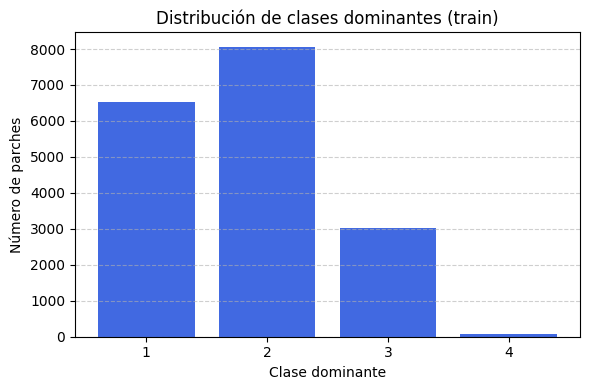


Split: VAL
   Parches positivos: 4286
   Parches negativos: 2707
   Distribución de clases dominantes:
      Clase 1: 1560 parches
      Clase 2: 1968 parches
      Clase 3: 735 parches
      Clase 4: 23 parches


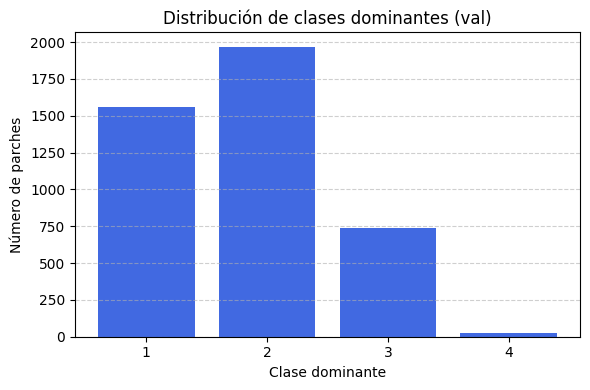

In [5]:
import os
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Ruta base de parches
patches_path = "/notebooks/patches_detector"

# Función para contar parches y clases dominantes
def analyze_patch_distribution(split="train"):
    pos_dir = os.path.join(patches_path, split, "pos")
    neg_dir = os.path.join(patches_path, split, "neg")

    pos_files = [f for f in os.listdir(pos_dir) if f.endswith(".npz")]
    neg_files = [f for f in os.listdir(neg_dir) if f.endswith(".npz")]

    class_counter = Counter()
    for file in pos_files:
        data = np.load(os.path.join(pos_dir, file))
        dom_class = int(data["clase_dominante"])
        class_counter[dom_class] += 1

    print(f"\nSplit: {split.upper()}")
    print(f"   Parches positivos: {len(pos_files)}")
    print(f"   Parches negativos: {len(neg_files)}")
    print(f"   Distribución de clases dominantes:")
    for cls, count in sorted(class_counter.items()):
        print(f"      Clase {cls}: {count} parches")

    # Gráfico de barras
    if class_counter:
        plt.figure(figsize=(6,4))
        plt.bar(class_counter.keys(), class_counter.values(), color="royalblue")
        plt.xlabel("Clase dominante")
        plt.ylabel("Número de parches")
        plt.title(f"Distribución de clases dominantes ({split})")
        plt.xticks([1,2,3,4])
        plt.grid(True, axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

# Ejecutar para train y val
analyze_patch_distribution("train")
analyze_patch_distribution("val")


## 3.4 Verificación estadística post-extracción de parches

Tras la generación de los parches positivos (label_bin = 1), se realiza una verificación de las estadísticas globales de estos volúmenes parciales. El objetivo es confirmar que:
- La normalización z-score aplicada previamente a cada volumen completo se mantiene a nivel de parche.
- No se han introducido distorsiones durante el proceso de extracción y guardado.

Para ello, se recorren todos los parches positivos de los conjuntos de entrenamiento y validación, y se calculan:
- La media de los valores promedio (mean_global) por parche.
- La media de las desviaciones estándar (std_global) por parche.

Los resultados obtenidos fueron:
- Train patch stats: media ≈ 0.47, std ≈ 1.27
- Val patch stats: media ≈ 0.48, std ≈ 1.27

Estas estadísticas son coherentes con los valores esperados tras una normalización z-score por volumen, y confirman la validez del preprocesado en esta fase posterior del pipeline.

In [19]:
# Comprobación post-patch
def compute_patch_stats(patch_dir):
    means = []
    stds = []
    for fname in tqdm(os.listdir(patch_dir)):
        data = np.load(os.path.join(patch_dir, fname))
        patch = data["patch"]
        means.append(patch.mean())
        stds.append(patch.std())
    return {
        "mean_global": np.mean(means),
        "std_global": np.mean(stds)
    }

train_stats = compute_patch_stats("/notebooks/patches_detector/train/pos")
val_stats   = compute_patch_stats("/notebooks/patches_detector/val/pos")

print("Train patch stats:", train_stats)
print("Val patch stats:", val_stats)

100%|██████████| 4286/4286 [01:56<00:00, 36.70it/s]

Train patch stats: {'mean_global': 0.47354493, 'std_global': 1.2755872}
Val patch stats: {'mean_global': 0.4815867, 'std_global': 1.277131}


Se realizó una comprobación sobre los 17.688 parches positivos del conjunto de entrenamiento, para verificar que todos contuvieran efectivamente señal tumoral, definida como al menos un vóxel con valor mayor a 0 en la máscara.

El resultado fue:
- Total de parches positivos: 17.688
- Con señal tumoral (≥1 vóxel): 17.688
- Proporción con señal: 100.00%

Esto confirma que el umbral de etiquetado (`POS_THRESH = 100`) fue efectivo para garantizar que los parches etiquetados como positivos contienen realmente tumor, y que no se han introducido falsos positivos sin información relevante.

In [16]:
import numpy as np
import os
from tqdm import tqdm

# Ruta de parches
val_pos_path = "/notebooks/patches_detector/train/pos"

# Comprobación
total_pos = 0
pos_with_signal = 0
signal_threshold = 1  # número mínimo de voxeles tumorales para considerar "con señal"

for fname in tqdm(os.listdir(val_pos_path), desc="Validación - POS"):
    fpath = os.path.join(val_pos_path, fname)
    data = np.load(fpath)
    mask = data["mask"] if "mask" in data else None
    if mask is not None:
        total_pos += 1
        if np.count_nonzero(mask) >= signal_threshold:
            pos_with_signal += 1

print(f"\nResultados sobre validación:")
print(f"Total de parches positivos: {total_pos}")
print(f"Con señal (≥{signal_threshold} voxeles tumorales): {pos_with_signal}")
print(f"Proporción con señal: {100 * pos_with_signal / total_pos:.2f}%")

Validación - POS: 100%|██████████| 17688/17688 [04:43<00:00, 62.34it/s] 


Resultados sobre validación:
Total de parches positivos: 17688
Con señal (≥1 voxeles tumorales): 17688
Proporción con señal: 100.00%


## 3.5 Visualización de parche aleatorio

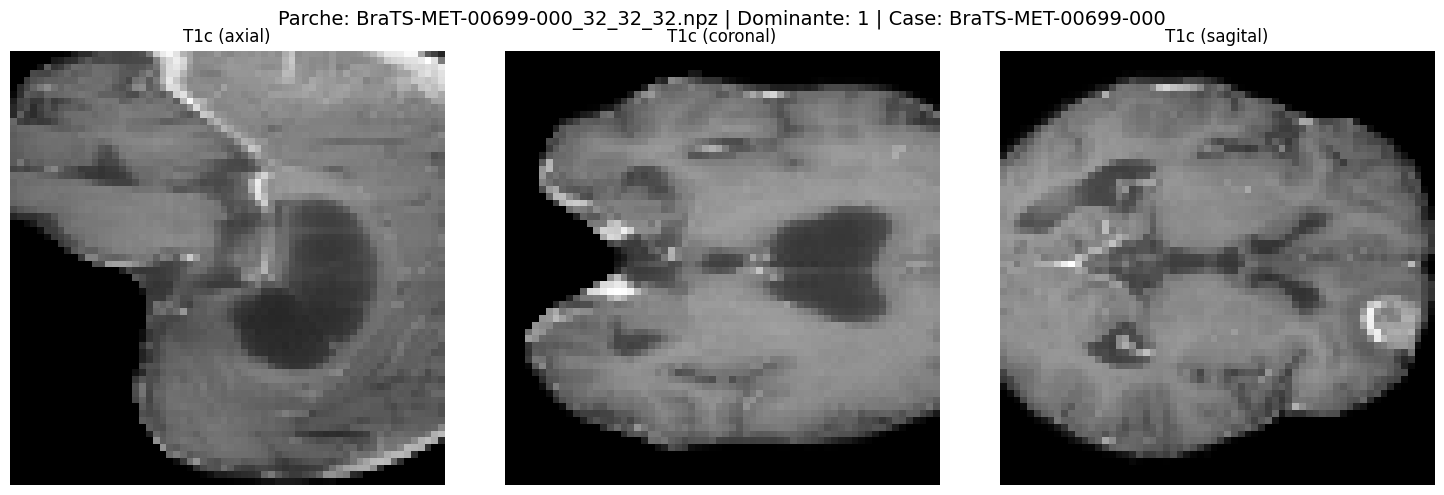

In [13]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# Ruta de parches positivos
patches_dir = "/notebooks/patches_detector/train/pos"
patch_files = [f for f in os.listdir(patches_dir) if f.endswith(".npz")]

# Cargar parche aleatorio
def load_random_patch():
    fname = random.choice(patch_files)
    data = np.load(os.path.join(patches_dir, fname))
    return data["patch"], data["label_bin"], data["clase_dominante"], data["case_id"], fname

# Mapa de colores para las clases
from matplotlib.colors import ListedColormap
cmap_classes = ListedColormap(["black", "yellow", "lime", "red", "cyan"])  # fondo + clases 1–4

# Visualización

def visualize_patch(patch, label, dom_class, case_id, fname):
    # Modalidad T1c → canal 1
    t1c = patch[..., 1]
    mask = np.argmax(patch[..., :4], axis=-1) if patch.shape[-1] > 1 else np.zeros_like(t1c)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    center = patch.shape[0] // 2

    axs[0].imshow(t1c[center, :, :], cmap="gray")
    axs[0].set_title("T1c (axial)")

    axs[1].imshow(t1c[:, center, :], cmap="gray")
    axs[1].set_title("T1c (coronal)")

    axs[2].imshow(t1c[:, :, center], cmap="gray")
    axs[2].set_title("T1c (sagital)")

    for ax in axs:
        ax.axis("off")

    # Superponer máscara
    fig.suptitle(f"Parche: {fname} | Dominante: {dom_class} | Case: {case_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Ejecutar visualización aleatoria
patch, label, dom_class, case_id, fname = load_random_patch()
visualize_patch(patch, label, dom_class, case_id, fname)

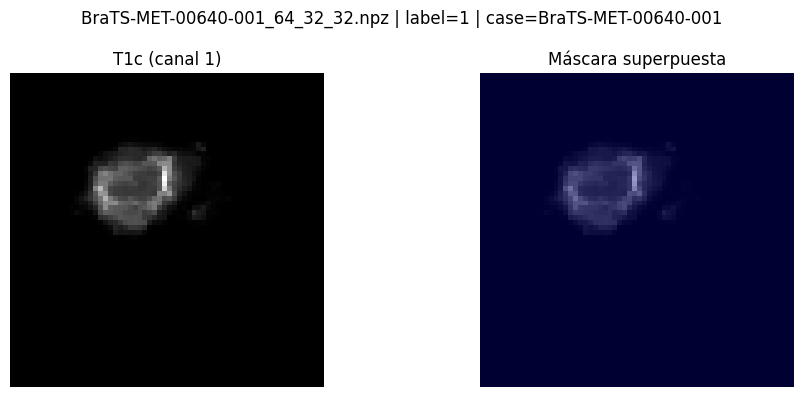

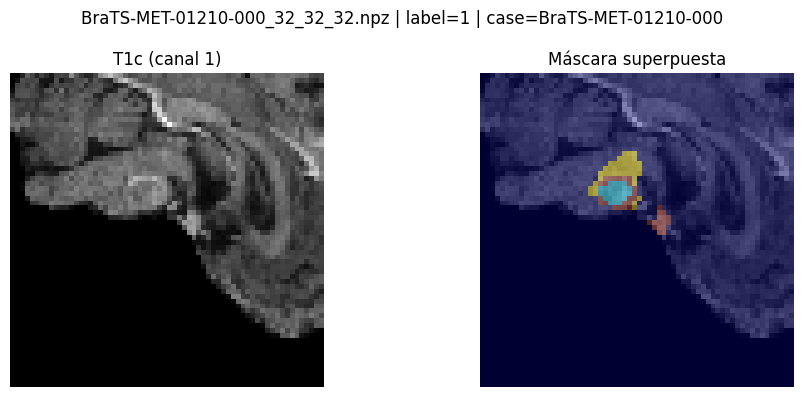

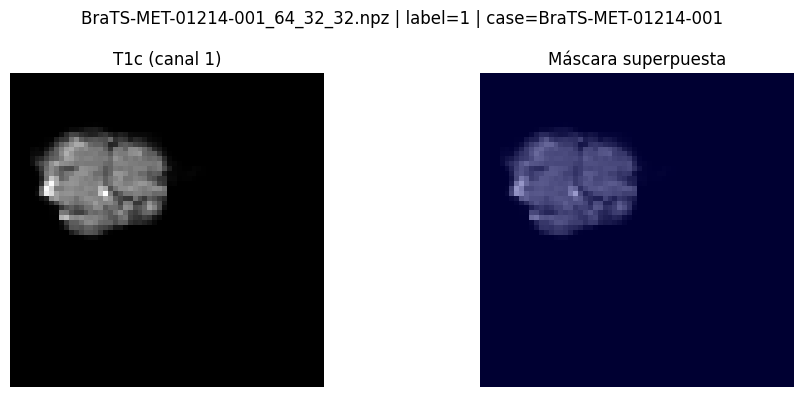

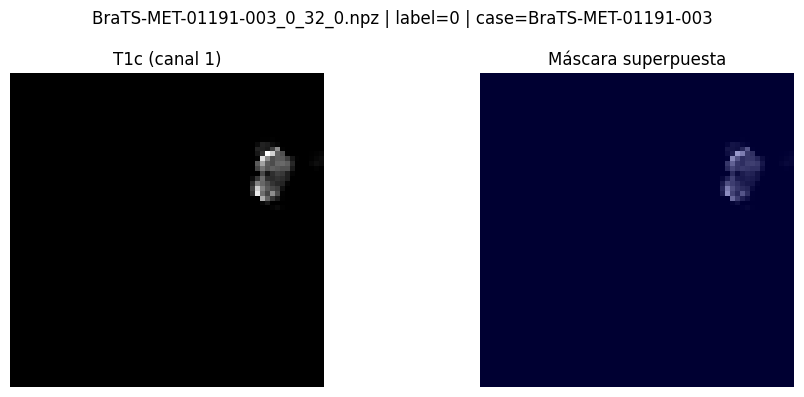

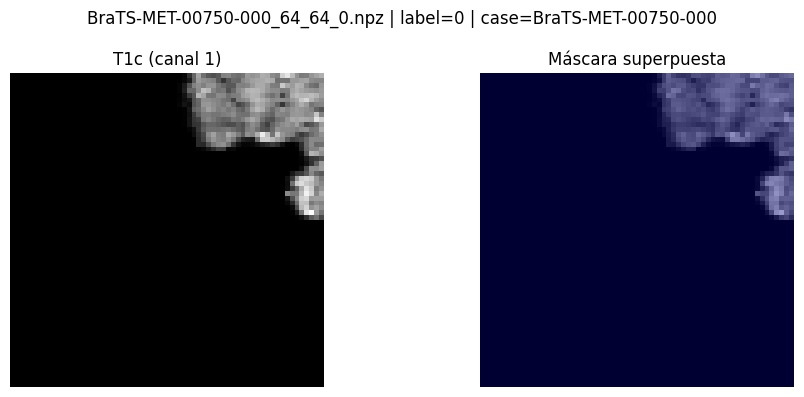

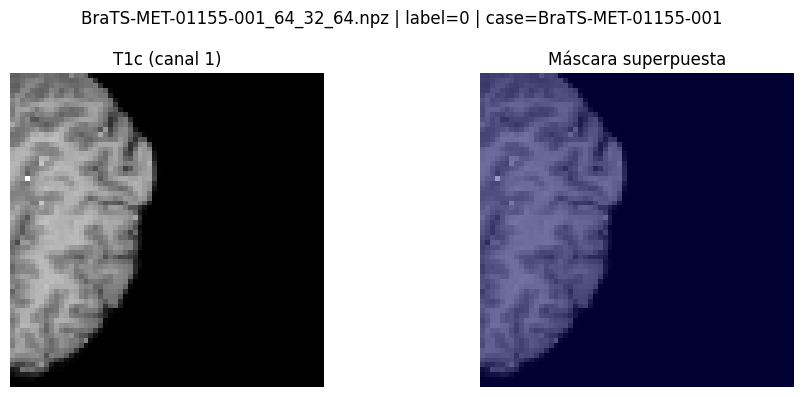

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Ruta base de los parches
base_path = "/notebooks/patches_detector"

def visualizar_muestra(split="val", clase="pos", n=3):
    carpeta = os.path.join(base_path, split, clase)
    archivos = sorted([f for f in os.listdir(carpeta) if f.endswith(".npz")])
    muestra = random.sample(archivos, n)

    for archivo in muestra:
        ruta = os.path.join(carpeta, archivo)
        data = np.load(ruta)
        patch = data["patch"]          # (64,64,64,4)
        mask = data["mask"]            # (64,64,64)
        label_bin = data["label_bin"]
        case_id = data["case_id"]
        coord = data["coord"]

        slice_idx = patch.shape[0] // 2
        t1c_slice = patch[slice_idx, :, :, 1]
        mask_slice = mask[slice_idx, :, :]

        plt.figure(figsize=(10, 4))
        plt.suptitle(f"{archivo} | label={label_bin} | case={case_id}", fontsize=12)

        plt.subplot(1, 2, 1)
        plt.imshow(t1c_slice, cmap='gray')
        plt.title("T1c (canal 1)")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(t1c_slice, cmap='gray')
        plt.imshow(mask_slice, cmap='jet', alpha=0.4)
        plt.title("Máscara superpuesta")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# Visualiza 3 positivos y 3 negativos
visualizar_muestra(split="val", clase="pos", n=3)
visualizar_muestra(split="val", clase="neg", n=3)

## 3.6 Patches TEST
Se realiza la extracción de parches 3D a partir de los volúmenes preprocesados del conjunto de test oficial (`BraTS-METS 2025 Validation`), cuya segmentación real no está disponible públicamente.

El objetivo de esta etapa es generar los datos necesarios para aplicar la inferencia con el modelo **detector binario** ya entrenado, en el contexto de la competición oficial.

Cada parche se extrae con los mismos parámetros usados en entrenamiento:
- Tamaño: `64 × 64 × 64`
- Stride: `32`

Aunque el código incluye la carga de la máscara y el cálculo de la etiqueta binaria (`label_bin`), en la práctica estas máscaras no se utilizarán, ya que el conjunto Validation no incluye etiquetas reales. Las etiquetas se mantienen únicamente por compatibilidad con el pipeline y por posibles análisis exploratorios internos.

Los parches se organizan por paciente y se almacenan en la ruta `/notebooks/patches_validation`. Posteriormente, se aplicará sobre ellos el **modelo detector binario** para seleccionar los parches más relevantes que serán enviados al modelo segmentador, como parte de la estrategia en cascada.

In [28]:
import numpy as np
import os
from tqdm import tqdm

# Rutas
preprocessed_val_path = "/notebooks/PreprocesadoValidation"
patches_output_path = "/notebooks/patches_validation"
os.makedirs(patches_output_path, exist_ok=True)

PATCH_SIZE = (64, 64, 64)
STRIDE = 32
POS_THRESH = 100  # voxeles tumorales mínimos para considerar parche positivo

# Etiqueta binaria según presencia de tumor
def get_patch_label(mask_patch):
    tumor_voxels = np.sum(mask_patch > 0)
    return int(tumor_voxels >= POS_THRESH)

# Extracción de parches con máscara y etiqueta
def extract_patches_with_labels(volume, mask, patch_size=PATCH_SIZE, stride=STRIDE):
    dz, dy, dx = patch_size
    Z, Y, X, C = volume.shape
    patches, masks, labels, coords = [], [], [], []
    for z in range(0, Z - dz + 1, stride):
        for y in range(0, Y - dy + 1, stride):
            for x in range(0, X - dx + 1, stride):
                patch = volume[z:z+dz, y:y+dy, x:x+dx, :]
                mpatch = mask[z:z+dz, y:y+dy, x:x+dx]
                label = get_patch_label(mpatch)
                patches.append(patch)
                masks.append(mpatch)
                labels.append(label)
                coords.append((z, y, x))
    return patches, masks, labels, coords

# Guardar cada parche
def save_patch_with_label(patch, mpatch, label, coord, case_id):
    save_dir = os.path.join(patches_output_path, case_id)
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{coord[0]}_{coord[1]}_{coord[2]}.npz"
    np.savez_compressed(
        os.path.join(save_dir, filename),
        patch=patch,
        mask=mpatch,
        label_bin=label,
        coord=coord,
        case_id=case_id
    )

# Pipeline por caso
def process_case(case_id):
    vol_path = os.path.join(preprocessed_val_path, f"{case_id}_image.npy")
    mask_path = os.path.join(preprocessed_val_path, f"{case_id}_mask.npy")
    image = np.load(vol_path)
    mask = np.load(mask_path)
    patches, masks, labels, coords = extract_patches_with_labels(image, mask)
    for p, m, l, c in zip(patches, masks, labels, coords):
        save_patch_with_label(p, m, l, c, case_id)

# Procesar todos los casos
all_val_cases = sorted([f[:-10] for f in os.listdir(preprocessed_val_path) if f.endswith("_image.npy")])
for case_id in tqdm(all_val_cases, desc="🔁 Regenerando parches con label_bin"):
    process_case(case_id)

🔁 Regenerando parches con label_bin: 100%|██████████| 179/179 [05:25<00:00,  1.82s/it]


# 4. Modelo detector Binario

Para abordar la tarea de detección de parches con tumor cerebral, se diseñaron y entrenaron tres modelos de clasificación binaria basados en redes convolucionales 3D. El objetivo es predecir, para cada parche de entrada (`64×64×64×4`), si contiene metástasis (`label_bin = 1`) o no (`label_bin = 0`). Todos los modelos utilizan una activación sigmoid en la salida, y son entrenados con una Focal Loss binaria para mitigar el desbalance entre clases positivas y negativas.


## 4.1 Preparación del Dataset para el Detector Binario

Una vez generados los parches y etiquetados como positivos (`label_bin = 1`) o negativos (`label_bin = 0`), se procede a construir el conjunto de entrenamiento y validación en formato TensorFlow Dataset (tf.data.Dataset), lo cual permite optimizar la eficiencia durante el entrenamiento.

El pipeline sigue los siguientes pasos:
  1. Se listan los archivos .npz de cada partición (train y val), separando los directorios de positivos y negativos.
  2. A cada archivo se le asigna su correspondiente etiqueta binaria.
  3. Se usa tf.numpy_function para cargar cada archivo de forma perezosa y eficiente.
  4. Se aplica shuffle, batch y prefetch para preparar el dataset de forma óptima para entrenamiento en GPU.

Cada elemento del dataset contiene:
- Un tensor x de forma (`64, 64, 64, 4`) que representa un parche 3D con 4 modalidades.
- Una etiqueta escalar y ∈ {0, 1}.

Este dataset es el que se pasa posteriormente al método model.fit(...) de los modelos de detección binaria.

In [7]:
import tensorflow as tf
import numpy as np
import os

# Rutas de parches
patches_path = "/notebooks/patches_detector"

# Función para cargar un parche desde .npz
def load_npz_patch(file_path):
    file_path = file_path.decode("utf-8")  
    with np.load(file_path) as data:
        patch = data["patch"]           # (64, 64, 64, 4)
        label = data["label_bin"]       # 0 o 1
    return patch.astype(np.float32), np.array(label, dtype=np.float32)

# Dataset desde ruta
def make_tf_dataset(split="train", batch_size=32, shuffle=True):
    # Directorios de positivos y negativos
    pos_dir = os.path.join(patches_path, split, "pos")
    neg_dir = os.path.join(patches_path, split, "neg")

    # Listado de archivos
    pos_files = tf.io.gfile.glob(os.path.join(pos_dir, "*.npz"))
    neg_files = tf.io.gfile.glob(os.path.join(neg_dir, "*.npz"))

    all_files = pos_files + neg_files
    labels = [1] * len(pos_files) + [0] * len(neg_files)

    # Dataset desde filenames y labels
    ds = tf.data.Dataset.from_tensor_slices((all_files, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(all_files), reshuffle_each_iteration=True)

    # Función para cargar desde archivo
    def _parse_function(file_path, label):
        patch, y = tf.numpy_function(
            load_npz_patch,
            [file_path],
            [tf.float32, tf.float32]
        )
        patch.set_shape((64, 64, 64, 4))
        y.set_shape(())
        return patch, y

    # Mapping, batching y prefetch
    ds = ds.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Crear datasets
train_dataset = make_tf_dataset("train", batch_size=32)
val_dataset = make_tf_dataset("val", batch_size=32, shuffle=False)

# Comprobación rápida
for batch in train_dataset.take(1):
    x, y = batch
    print(f"x shape: {x.shape}, y shape: {y.shape}")


x shape: (32, 64, 64, 64, 4), y shape: (32,)


## 4.1 Arquitectura base: CNN 3D simple

El primer modelo implementa una arquitectura CNN 3D sencilla, con 3 bloques convolucionales seguidos de pooling y normalización. La salida es una predicción binaria (sigmoid). Este modelo sirvió como baseline para comparar con versiones más avanzadas.
- Capas: Conv3D → BN → MaxPool → ReLU
- GlobalAveragePooling → Dropout → Dense(1)

In [20]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import os
import datetime

# Arquitectura CNN 3D para clasificación binaria
def build_detector_model(input_shape=(64, 64, 64, 4)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv3D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool3D()(x)

    x = layers.Conv3D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool3D()(x)

    x = layers.Conv3D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling3D()(x)

    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype = 'float32')(x)

    return models.Model(inputs, outputs, name="DetectorBinario")

# Focal Loss binaria
import tensorflow.keras.backend as K
def binary_focal_loss(gamma=2., alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = K.binary_crossentropy(y_true, y_pred)
        bce_exp = K.exp(-bce)
        return alpha * K.pow((1 - bce_exp), gamma) * bce
    return focal_loss

# Construir y compilar
# 1. Construcción del modelo detector binario
model = build_detector_model()
model.summary()

# 2. Compilación del modelo
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = binary_focal_loss(gamma=2.0, alpha=0.25),  # para desbalance positivo/negativo
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# 3. Definición de callbacks
import datetime, os
log_dir = os.path.join("/notebooks/logs_detector", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

callback = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/notebooks/best_detector.keras",
        save_best_only=True,
        monitor="val_auc",  
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir)
]


Model: "DetectorBinario"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64, 64, 64, 4)]   0         
                                                                 
 conv3d_3 (Conv3D)           (None, 64, 64, 64, 32)    3488      
                                                                 
 batch_normalization_3 (Bat  (None, 64, 64, 64, 32)    128       
 chNormalization)                                                
                                                                 
 max_pooling3d_2 (MaxPoolin  (None, 32, 32, 32, 32)    0         
 g3D)                                                            
                                                                 
 conv3d_4 (Conv3D)           (None, 32, 32, 32, 64)    55360     
                                                                 
 batch_normalization_4 (Bat  (None, 32, 32, 32, 64)

## 4.2 Modelo Detector Binario Avanzado

El segundo modelo detector, denominado **`DetectorBinarioAvanzado`**, incorpora múltiples mejoras sobre la arquitectura básica con el objetivo de **aumentar la capacidad de generalización** y la **estabilidad del entrenamiento**.

---

### Mejoras implementadas

- **Bloques convolucionales residuales**  
  Permiten que la red aprenda *residuos respecto a la identidad* (`x + F(x)`), lo cual:
  - Facilita el flujo del gradiente.
  - Evita la desaparición del gradiente en redes profundas.
  - Mejora la estabilidad del entrenamiento.

- **Activación LeakyReLU**  
  Sustituye a ReLU estándar para evitar *muertes neuronales*. LeakyReLU permite un **pequeño gradiente en valores negativos**, manteniendo activas más neuronas.

- **Dropout progresivo**  
  Se incrementa la **tasa de dropout** a medida que se profundiza en la red:
  - Introduce *regularización creciente* en capas profundas.
  - Previene *overfitting*.

- **Regularización L2**  
  Penaliza pesos excesivamente grandes en capas convolucionales, reduciendo también el riesgo de sobreajuste.

- **GlobalAveragePooling3D**  
  En lugar de aplanar las activaciones, se aplica un **promedio global por canal**, lo que:
  - Reduce el número total de parámetros.
  - Aumenta la *robustez del modelo*.
  - Mejora la generalización.

---

### Entrenamiento y uso

Este modelo fue entrenado **optimizando la métrica `val_auc`**, lo que permitió alcanzar un **equilibrio entre sensibilidad y especificidad**, especialmente valioso para la **detección de falsos negativos**.

> Fue uno de los **dos modelos utilizados en el ensemble de detectores binarios** aplicados sobre el conjunto de validación oficial.

In [5]:
# Modelo Detector Binario (versión mejorada)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
import os
import datetime

def conv_block(x, filters, kernel_size=3, stride=1, dropout_rate=0.3, use_residual=True):
    shortcut = x

    x = layers.Conv3D(filters, kernel_size, padding='same', strides=stride,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)

    x = layers.Conv3D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if use_residual and shortcut.shape[-1] == filters:
        x = layers.Add()([x, shortcut])  # Residual connection

    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.MaxPool3D(pool_size=2)(x)

    return x

def build_detector_model(input_shape=(64, 64, 64, 4)):
    inputs = layers.Input(shape=input_shape)

    x = conv_block(inputs, 32, dropout_rate=0.2)
    x = conv_block(x, 64, dropout_rate=0.3)
    x = conv_block(x, 128, dropout_rate=0.4)
    x = conv_block(x, 256, dropout_rate=0.5)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    return models.Model(inputs, outputs, name="DetectorBinarioAvanzado")

# Focal Loss binaria
import tensorflow.keras.backend as K
def binary_focal_loss(gamma=2., alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = K.binary_crossentropy(y_true, y_pred)
        bce_exp = K.exp(-bce)
        return alpha * K.pow((1 - bce_exp), gamma) * bce
    return focal_loss

# Construcción y compilación
model_advanced = build_detector_model()
model_advanced.summary()

model_advanced.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# Definición de callbacks
import datetime, os
log_dir = os.path.join("/notebooks/logs_detector_advanced", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

callback_adv = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/notebooks/best_detector_advanced.keras",
        save_best_only=True,
        monitor="val_auc",  # priorizamos AUC como métrica objetivo
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=13,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir)
]

Model: "DetectorBinarioAvanzado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 64, 4)]   0         
                                                                 
 conv3d_16 (Conv3D)          (None, 64, 64, 64, 32)    3488      
                                                                 
 batch_normalization_16 (Ba  (None, 64, 64, 64, 32)    128       
 tchNormalization)                                               
                                                                 
 leaky_re_lu_16 (LeakyReLU)  (None, 64, 64, 64, 32)    0         
                                                                 
 conv3d_17 (Conv3D)          (None, 64, 64, 64, 32)    27680     
                                                                 
 batch_normalization_17 (Ba  (None, 64, 64, 64, 32)    128       
 tchNormalization)                         

## 4.3 Modelo especializado en *recall*

El tercer modelo reutiliza la arquitectura avanzada descrita en el apartado anterior, pero con un **objetivo principal distinto**: **maximizar la `recall` sobre los parches positivos**.

---

### Enfoque del entrenamiento

Para lograr este objetivo, se introducen las siguientes modificaciones en el pipeline de entrenamiento:

- **Métrica de validación**: se monitoriza `val_recall` como métrica principal.
- **Arquitectura**: se emplea la misma arquitectura del modelo `DetectorBinarioAvanzado` (ver apartado 4.2).
- **Estrategia de parada temprana**: se aplica `EarlyStopping` basada en la mejora de la `recall`, priorizando la recuperación de todos los verdaderos positivos.

---

### Justificación y uso

Este modelo fue diseñado como complemento del modelo optimizado por AUC, aportando una **estrategia de detección más sensible**. Fue empleado en un **ensemble orientado a alta sensibilidad**, especialmente útil en el contexto clínico, donde **minimizar los falsos negativos** (no detectar una metástasis) resulta crítico.

> La combinación de ambos modelos permite cubrir el espectro sensibilidad-especificidad de forma más equilibrada.

In [25]:
# Modelo Detector Binario (versión mejorada) Recall
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
import os
import datetime

def conv_block(x, filters, kernel_size=3, stride=1, dropout_rate=0.3, use_residual=True):
    shortcut = x

    x = layers.Conv3D(filters, kernel_size, padding='same', strides=stride,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)

    x = layers.Conv3D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if use_residual and shortcut.shape[-1] == filters:
        x = layers.Add()([x, shortcut])  # Residual connection

    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.MaxPool3D(pool_size=2)(x)

    return x

def build_detector_model(input_shape=(64, 64, 64, 4)):
    inputs = layers.Input(shape=input_shape)

    x = conv_block(inputs, 32, dropout_rate=0.2)
    x = conv_block(x, 64, dropout_rate=0.3)
    x = conv_block(x, 128, dropout_rate=0.4)
    x = conv_block(x, 256, dropout_rate=0.5)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    return models.Model(inputs, outputs, name="DetectorBinarioAvanzadoRecall")

# Focal Loss binaria
import tensorflow.keras.backend as K
def binary_focal_loss(gamma=2., alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = K.binary_crossentropy(y_true, y_pred)
        bce_exp = K.exp(-bce)
        return alpha * K.pow((1 - bce_exp), gamma) * bce
    return focal_loss

# Modelo detector binario (misma arquitectura que antes)
model_recall = build_detector_model()
model_recall.summary()

# Compilación del modelo
model_recall.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# Callbacks (monitorizando val_recall en vez de val_auc)
log_dir_recall = os.path.join("/notebooks/logs_detector", "recall_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir_recall, exist_ok=True)

callback_recall = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/notebooks/best_detector_recall.keras",
        save_best_only=True,
        monitor="val_recall", 
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir_recall)
]

Model: "DetectorBinarioAvanzadoRecall"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 64, 64, 64, 4)]   0         
                                                                 
 conv3d_28 (Conv3D)          (None, 64, 64, 64, 32)    3488      
                                                                 
 batch_normalization_28 (Ba  (None, 64, 64, 64, 32)    128       
 tchNormalization)                                               
                                                                 
 leaky_re_lu_16 (LeakyReLU)  (None, 64, 64, 64, 32)    0         
                                                                 
 conv3d_29 (Conv3D)          (None, 64, 64, 64, 32)    27680     
                                                                 
 batch_normalization_29 (Ba  (None, 64, 64, 64, 32)    128       
 tchNormalization)                   

## 4.4 Función de pérdida, optimizador y métricas de evaluación

### **Función de pérdida**: *Focal Loss binaria*

Dado que el problema de detección binaria presenta un **fuerte desbalance de clases**, donde la mayoría de los parches contienen únicamente tejido sano (clase 0), se optó por utilizar una **Focal Loss binaria** en lugar de la clásica entropía cruzada (Binary Cross-Entropy).

La *Focal Loss*, propuesta por *Lin et al., 2017* para tareas de detección de objetos con gran desbalance, modifica la BCE aplicando un factor que:

- Penaliza más los errores en ejemplos difíciles (p. ej., positivos raros).
- Reduce la contribución de los ejemplos fácilmente clasificables (negativos puros).

**Parámetros usados**:
- `γ = 2.0`: Aumenta el foco en ejemplos mal clasificados.
- `α = 0.25`: Asigna más peso a los ejemplos positivos (`label_bin = 1`), que son minoría.

> Esta pérdida ayudó a mejorar la **sensibilidad** del modelo y a evitar el colapso hacia predicción trivial (clase negativa constante).

---

### **Optimizador**: *Adam*

Se utilizó el optimizador **Adam** con una tasa de aprendizaje fija de `1e-4`, por las siguientes razones:

- Combina descenso por gradiente con *momentum* y adaptación individual del *learning rate*, ideal para datos ruidosos y desbalanceados.
- Mejora la convergencia respecto a **SGD** o **RMSProp** en arquitecturas 3D con Focal Loss.
- Se activó el modo `mixed_float16` para aprovechar la aceleración por hardware en GPU, sin pérdida relevante de precisión numérica.

---

### **Métricas de evaluación**

Durante el entrenamiento y validación se monitorizaron las siguientes métricas:

- **BinaryAccuracy**: proporción general de aciertos. No es útil en problemas desbalanceados, pero se incluye como referencia.
- **Precision**: proporción de verdaderos positivos entre los predichos como positivos. Permite controlar los falsos positivos.
- **Recall**: proporción de verdaderos positivos detectados. Es la métrica **clave del proyecto**, ya que perder un parche tumoral tiene consecuencias más graves que un falso positivo.
- **AUC (Area Under the ROC Curve)**: refleja la capacidad del modelo para discriminar entre clases a través de distintos umbrales.

**Criterio de selección del mejor modelo**:

- En el modelo principal se usó `val_auc` para lograr un balance global.
- En el modelo alternativo se usó `val_recall` para maximizar la sensibilidad sobre parches positivos.

## 4.5 Entrenamiento, validación y gestión de modelos

Una vez definidos los modelos y compilados con sus respectivas funciones de pérdida, optimizador y métricas, se procedió a entrenarlos sobre los parches generados previamente (`label_bin = 0/1`). El objetivo principal era obtener un modelo capaz de **detectar con alta sensibilidad** los parches que contuvieran metástasis cerebral.

### Entrenamiento supervisado con validación cruzada

Los parches se dividieron en dos subconjuntos:
- **Entrenamiento (80%)**
- **Validación (20%)**

> La división se realizó por **ID de paciente**, con el fin de evitar fuga de información entre parches espacial o anatómicamente correlacionados.

Durante el entrenamiento se monitorizaron todas las métricas definidas previamente, tanto en el conjunto de entrenamiento como en validación, prestando especial atención a la **evolución del AUC y del Recall**.

---

### Callbacks utilizados

Para mejorar la eficiencia del entrenamiento y evitar el sobreajuste, se emplearon varios *callbacks* estándar de TensorFlow:

- **ModelCheckpoint**  
  Se guardó automáticamente el mejor modelo encontrado según la métrica objetivo (`val_auc` o `val_recall`). Esto garantiza que se conserve la versión óptima del modelo aunque el entrenamiento finalice prematuramente.

- **EarlyStopping**  
  Se interrumpió el entrenamiento si la métrica monitorizada no mejoraba tras un número determinado de épocas (*patience*), lo cual:
  - Previene el sobreajuste.
  - Reduce el tiempo de cómputo.
  - Evita el almacenamiento de modelos redundantes.

- **TensorBoard**  
  Se registraron los *logs* de entrenamiento y validación (pérdida y métricas) para su análisis visual posterior mediante TensorBoard.

---

### Gestión y reutilización de modelos

Cada modelo entrenado fue guardado en formato `.keras`, utilizando nombres descriptivos en función de su estrategia de optimización:

- `best_detector.keras`: modelo básico optimizado para AUC.
- `best_detector_advanced.keras`: versión avanzada con arquitectura residual.
- `best_detector_recall.keras`: modelo optimizado para maximizar la sensibilidad (recall).

Posteriormente, estos modelos se reutilizaron para realizar **inferencia sobre el conjunto de test oficial** (BraTS-METS 2025 *Validation*) mediante un esquema de **ensemble**, seleccionando los parches más probables de contener tumor para su posterior segmentación.

In [10]:
# Bloque E: Entrenamiento del modelo detector binario

# Entrenar modelo
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callback
)

Epoch 1/100


2025-08-04 16:06:28.131682: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-04 16:06:36.467175: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f4704003550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-04 16:06:36.467244: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-04 16:06:36.485670: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754323596.597104      92 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


875/875 [==============================] - ETA: 0s - loss: 0.0374 - accuracy: 0.6758 - precision: 0.7359 - recall: 0.7602 - auc: 0.7222
Epoch 1: val_auc improved from -inf to 0.76835, saving model to /notebooks/best_detector.keras
875/875 [==============================] - 279s 306ms/step - loss: 0.0374 - accuracy: 0.6758 - precision: 0.7359 - recall: 0.7602 - auc: 0.7222 - val_loss: 0.0360 - val_accuracy: 0.6936 - val_precision: 0.7892 - val_recall: 0.6822 - val_auc: 0.7683
Epoch 2/100
874/875 [============================>.] - ETA: 0s - loss: 0.0354 - accuracy: 0.7038 - precision: 0.7457 - recall: 0.8068 - auc: 0.7574
Epoch 2: val_auc did not improve from 0.76835
875/875 [==============================] - 271s 310ms/step - loss: 0.0354 - accuracy: 0.7038 - precision: 0.7456 - recall: 0.8068 - auc: 0.7573 - val_loss: 0.0375 - val_accuracy: 0.6425 - val_precision: 0.6663 - val_recall: 0.8348 - val_auc: 0.7147
Epoch 3/100
874/875 [============================>.] - ETA: 0s - loss: 0.0345

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)




Epoch 9: val_auc improved from 0.81003 to 0.81234, saving model to /notebooks/best_detector.keras
875/875 [==============================] - 256s 292ms/step - loss: 0.0305 - accuracy: 0.7591 - precision: 0.8025 - recall: 0.8212 - auc: 0.8349 - val_loss: 0.0334 - val_accuracy: 0.7204 - val_precision: 0.8212 - val_recall: 0.6953 - val_auc: 0.8123
Epoch 10/100
544/875 [=================>............] - ETA: 1:22 - loss: 0.0293 - accuracy: 0.7732 - precision: 0.8132 - recall: 0.8326 - auc: 0.8505
Epoch 11: val_auc did not improve from 0.81234
875/875 [==============================] - 266s 303ms/step - loss: 0.0292 - accuracy: 0.7730 - precision: 0.8151 - recall: 0.8290 - auc: 0.8521 - val_loss: 0.0350 - val_accuracy: 0.7327 - val_precision: 0.7464 - val_recall: 0.8542 - val_auc: 0.8022
Epoch 12/100
874/875 [============================>.] - ETA: 0s - loss: 0.0287 - accuracy: 0.7813 - precision: 0.8230 - recall: 0.8335 - auc: 0.8586
Epoch 12: val_auc did not improve from 0.81234
875/875 [

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



874/875 [============================>.] - ETA: 0s - loss: 0.0262 - accuracy: 0.8099 - precision: 0.8500 - recall: 0.8491 - auc: 0.8872
Epoch 16: val_auc did not improve from 0.82602
875/875 [==============================] - 206s 236ms/step - loss: 0.0262 - accuracy: 0.8098 - precision: 0.8499 - recall: 0.8492 - auc: 0.8872 - val_loss: 0.0334 - val_accuracy: 0.7293 - val_precision: 0.8123 - val_recall: 0.7261 - val_auc: 0.8107
Epoch 17/100
874/875 [============================>.] - ETA: 0s - loss: 0.0255 - accuracy: 0.8121 - precision: 0.8533 - recall: 0.8487 - auc: 0.8933
Epoch 17: val_auc did not improve from 0.82602
875/875 [==============================] - 213s 244ms/step - loss: 0.0255 - accuracy: 0.8120 - precision: 0.8532 - recall: 0.8487 - auc: 0.8933 - val_loss: 0.0337 - val_accuracy: 0.7396 - val_precision: 0.7688 - val_recall: 0.8224 - val_auc: 0.8172
Epoch 18/100
874/875 [============================>.] - ETA: 0s - loss: 0.0249 - accuracy: 0.8196 - precision: 0.8596 - rec

In [ ]:
# Bloque E: Entrenamiento del modelo detector binario

# Entrenar modelo
history = model_advanced.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callback_adv
)

Epoch 1/100


2025-08-05 09:37:20.421626: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-05 09:37:31.998769: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f411363b180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-05 09:37:31.998822: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-05 09:37:32.031017: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754386652.159504     133 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1749/1749 [==============================] - ETA: 0s - loss: 0.1150 - accuracy: 0.7012 - precision: 0.7353 - recall: 0.8243 - auc: 0.7347
Epoch 1: val_auc improved from -inf to 0.79712, saving model to /notebooks/best_detector_advanced.keras
1749/1749 [==============================] - 272s 146ms/step - loss: 0.1150 - accuracy: 0.7012 - precision: 0.7353 - recall: 0.8243 - auc: 0.7347 - val_loss: 0.0952 - val_accuracy: 0.7293 - val_precision: 0.7517 - val_recall: 0.8336 - val_auc: 0.7971
Epoch 2/100
1748/1749 [============================>.] - ETA: 0s - loss: 0.0775 - accuracy: 0.7317 - precision: 0.7637 - recall: 0.8335 - auc: 0.7928
Epoch 2: val_auc improved from 0.79712 to 0.80020, saving model to /notebooks/best_detector_advanced.keras
1749/1749 [==============================] - 242s 138ms/step - loss: 0.0775 - accuracy: 0.7317 - precision: 0.7637 - recall: 0.8335 - auc: 0.7928 - val_loss: 0.0721 - val_accuracy: 0.5909 - val_precision: 0.9239 - val_recall: 0.3623 - val_auc: 0.8002

In [8]:
# Entrenamiento Modelo Binario avanzado Recall
history_recall = model_recall.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callback_recall
)

Epoch 1/100
875/875 [==============================] - ETA: 0s - loss: 0.1224 - accuracy: 0.6931 - precision: 0.7290 - recall: 0.8190 - auc: 0.7286
Epoch 1: val_recall improved from -inf to 0.94377, saving model to /notebooks/best_detector_recall.keras
875/875 [==============================] - 289s 298ms/step - loss: 0.1224 - accuracy: 0.6931 - precision: 0.7290 - recall: 0.8190 - auc: 0.7286 - val_loss: 0.1103 - val_accuracy: 0.6881 - val_precision: 0.6759 - val_recall: 0.9438 - val_auc: 0.7738
Epoch 2/100
874/875 [============================>.] - ETA: 0s - loss: 0.0978 - accuracy: 0.7298 - precision: 0.7602 - recall: 0.8366 - auc: 0.7929
Epoch 2: val_recall did not improve from 0.94377
875/875 [==============================] - 228s 259ms/step - loss: 0.0978 - accuracy: 0.7298 - precision: 0.7602 - recall: 0.8366 - auc: 0.7929 - val_loss: 0.0952 - val_accuracy: 0.6212 - val_precision: 0.8914 - val_recall: 0.4349 - val_auc: 0.7872
Epoch 3/100
874/875 [============================>.]

## 4.6 Análisis de Resultados

Se compararon los tres modelos entrenados para la tarea de detección binaria de parches con metástasis, observándose las siguientes conclusiones:

- **Modelo baseline**  
  Obtuvo un buen equilibrio entre todas las métricas, con valores sólidos de `val_auc` y `val_recall`. Representa una opción **robusta y generalista**, aunque no fue seleccionado para el ensemble final.

- **Modelo avanzado optimizado para AUC**  
  Incorporando **regularización L2 y bloques residuales**, alcanzó el mejor valor de `val_auc` (**0.8750**) y una **precisión extremadamente alta** (**0.9797**).  
  Sin embargo, su **recall fue bajo** (**0.4510**), lo cual puede resultar **problemático en un contexto clínico** donde la prioridad es no omitir regiones tumorales.

- **Modelo avanzado especializado en recall**  
  Reutilizando la misma arquitectura pero optimizado por `val_recall`, alcanzó el **mejor resultado en sensibilidad** (**val_recall = 0.9438**), aunque con **menor precisión**.  
  Este modelo es especialmente útil para **asegurar que ningún parche tumoral pase desapercibido**.

---

### Conclusión

Dado que el **objetivo clínico principal** de esta etapa es detectar **con la mayor sensibilidad posible** todos los parches tumorales (que luego serán segmentados con mayor detalle), se optó por **combinar ambos modelos avanzados** en un esquema de *ensemble*.

> En dicho ensemble, se **priorizan los parches identificados por el modelo con mayor recall**, mientras que el modelo optimizado para AUC aporta robustez y precisión adicional.

Esta combinación se implementa y evalúa en la siguiente sección.



## 4.7 Ensemble de Modelos Detectores sobre Conjunto de Validación Interna

Con el objetivo de **mejorar la detección de parches tumorales** en el conjunto de validación, se implementó una estrategia de *ensemble* entre dos modelos binarios previamente entrenados:

- `best_detector_advanced.keras`: modelo optimizado para la métrica `val_auc`, con alta **precisión**.
- `best_detector_recall.keras`: modelo optimizado para `val_recall`, con alta **sensibilidad**.

---

### Motivación del Ensemble

El uso combinado de estos dos modelos permite **aprovechar sus fortalezas complementarias**:

- El modelo optimizado para **AUC** reduce los **falsos positivos**, siendo más estricto al clasificar un parche como positivo.
- El modelo optimizado para **recall** es más **sensible**, capaz de detectar incluso señales tumorales débiles o parches marginales.

> Este enfoque busca un **equilibrio controlado entre sensibilidad y precisión**, lo cual es crítico en contextos clínicos donde es preferible **detectar más zonas sospechosas**, aunque implique asumir ciertos falsos positivos.

---

### Proceso de Ensemble

1. **Carga de modelos**:
   Ambos modelos fueron cargados desde sus respectivos archivos `.keras`.

2. **Inferencia sobre validación**:
   Se aplicaron ambos modelos sobre **todos los parches del conjunto de validación** (`patches_detector/val`), obteniendo dos predicciones de probabilidad para cada parche.

3. **Promedio de predicciones**:
   Se calculó la **media aritmética** de ambas probabilidades para cada parche:

   $p_{\text{ensemble}} = \frac{p_{\text{AUC}} + p_{\text{recall}}}{2}$

   Este valor representa la **probabilidad final estimada** de que el parche contenga metástasis.

---

Esta estrategia de *ensemble soft* mejora la robustez de la detección y sirve como **filtro inicial** para seleccionar los parches que serán procesados por el modelo segmentador en la siguiente etapa.

In [8]:
import os
import numpy as np
from tqdm import tqdm
import tensorflow as tf

# Rutas
patches_val_path = "/notebooks/patches_detector/val"
model_auc = tf.keras.models.load_model("/notebooks/best_detector_advanced.keras", compile=False)
model_recall = tf.keras.models.load_model("/notebooks/best_detector_recall.keras", compile=False)

# Obtener todos los .npz
all_npz = []
for root, _, files in os.walk(patches_val_path):
    for f in files:
        if f.endswith(".npz"):
            all_npz.append(os.path.join(root, f))

# Inferencia directa por lotes
batch_size = 32
preds_auc, preds_recall, filepaths = [], [], []

for i in tqdm(range(0, len(all_npz), batch_size), desc="Inferencia ensemble"):
    batch_files = all_npz[i:i+batch_size]
    batch_patches = []

    for f in batch_files:
        with np.load(f) as data:
            patch = data["patch"]  # (64, 64, 64, 4)
            batch_patches.append(patch)
            filepaths.append(f)

    x_batch = np.stack(batch_patches).astype(np.float32)
    
    # Predecimos y extendemos los resultados en cada iteración
    preds_auc_batch = model_auc.predict(x_batch, verbose=0).flatten()
    preds_recall_batch = model_recall.predict(x_batch, verbose=0).flatten()
    
    preds_auc.extend(preds_auc_batch.tolist())
    preds_recall.extend(preds_recall_batch.tolist())

# Ensemble
preds_auc = np.array(preds_auc)
preds_recall = np.array(preds_recall)
ensemble_preds = (preds_auc + preds_recall) / 2

print("✅ Inferencia completada.")
print("✅ Ensemble preds shape:", ensemble_preds.shape)
print("✅ Total parches evaluados:", len(all_npz))

Inferencia ensemble:   0%|          | 0/219 [00:00<?, ?it/s]

Inferencia ensemble: 100%|██████████| 219/219 [06:54<00:00,  1.89s/it]

✅ Inferencia completada.
✅ Ensemble preds shape: (6993,)
✅ Total parches evaluados: 6993


In [10]:
print("🔍 Preds stats:")
print("Min:", np.min(ensemble_preds))
print("Max:", np.max(ensemble_preds))
print("Mean:", np.mean(ensemble_preds))
print(">0.5:", np.mean(ensemble_preds > 0.5))

🔍 Preds stats:
Min: 0.34494832158088684
Max: 0.898471862077713
Mean: 0.5038340826726992
>0.5: 0.3961103961103961


In [4]:
np.save("/notebooks/ensemble_preds.npy", ensemble_preds)
np.save("/notebooks/filepaths_preds.npy", np.array(filepaths))

## 4.8 Evaluación mediante *thresholds*

Al disponer de etiquetas reales (`label_bin`) en el conjunto de validación, se evaluó el rendimiento del ensemble utilizando distintos *thresholds* de decisión.

> En la siguiente celda se muestra cómo varían las métricas clave al modificar el umbral. Como se observa, valores bajos del threshold garantizan **alta sensibilidad**, mientras que valores altos incrementan la **precisión** pero a costa de perder positivos reales.

---

### **Justificación médica del threshold seleccionado**

En contextos médicos, y particularmente en tareas de detección temprana de lesiones cerebrales, es fundamental **maximizar la sensibilidad del sistema (recall)**, ya que **pasar por alto una región tumoral podría tener consecuencias clínicas graves**.

Por ello, se seleccionó un *threshold* de **0.4**, que logra un equilibrio adecuado:
- **Recall > 95%**
- **F1-score ≈ 0.8073**

Esta configuración fue empleada posteriormente en la inferencia sobre el conjunto de test oficial (*BraTS-METS 2025 Validation*), **priorizando la detección de todos los parches sospechosos**, incluso a costa de algunos falsos positivos.

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Extraer los labels verdaderos
y_true = []
for f in filepaths:
    with np.load(f) as data:
        y_true.append(int(data["label_bin"]))
y_true = np.array(y_true)

# Evaluar distintos thresholds
thresholds = np.arange(0.1, 0.91, 0.1)
print("🔍 Métricas por threshold:\n")

for th in thresholds:
    preds_bin = (ensemble_preds >= th).astype(int)
    precision = precision_score(y_true, preds_bin, zero_division=0)
    recall = recall_score(y_true, preds_bin, zero_division=0)
    f1 = f1_score(y_true, preds_bin, zero_division=0)

    print(f"🔹 Threshold = {th:.2f} → Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

🔍 Métricas por threshold:

🔹 Threshold = 0.10 → Precision: 0.6129 | Recall: 1.0000 | F1: 0.7600
🔹 Threshold = 0.20 → Precision: 0.6129 | Recall: 1.0000 | F1: 0.7600
🔹 Threshold = 0.30 → Precision: 0.6129 | Recall: 1.0000 | F1: 0.7600
🔹 Threshold = 0.40 → Precision: 0.6994 | Recall: 0.9547 | F1: 0.8073
🔹 Threshold = 0.50 → Precision: 0.9523 | Recall: 0.6155 | F1: 0.7477
🔹 Threshold = 0.60 → Precision: 0.9939 | Recall: 0.3794 | F1: 0.5491
🔹 Threshold = 0.70 → Precision: 0.9982 | Recall: 0.1276 | F1: 0.2263
🔹 Threshold = 0.80 → Precision: 1.0000 | Recall: 0.0180 | F1: 0.0353
🔹 Threshold = 0.90 → Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


## 4.9 Inferencia con ensemble sobre el conjunto de test oficial (BraTS-METS 2025 Validation)

En esta etapa se aplica el mismo ensemble sobre los parches del conjunto patches_validation, correspondiente al conjunto oficial de test sin etiquetas públicas. El objetivo es seleccionar los parches más probables de contener metástasis para ser enviados al modelo segmentador.
- Se cargaron los 4.833 parches del conjunto test.
- Se predijo la probabilidad de cada uno con ambos modelos y se promediaron los resultados.
- Se aplicó el threshold 0.4, previamente optimizado en validación interna.

Resultado:
- Total de parches evaluados: 4.833
- Parches seleccionados como positivos: 3.866
- Porcentaje seleccionado: ≈ 80%

Estos parches fueron copiados a una carpeta nueva (/notebooks/patches_validation_selected_thr04) para ser procesados por el modelo segmentador en la siguiente etapa del pipeline.

In [12]:
import os
import numpy as np
from tqdm import tqdm
import tensorflow as tf

# Rutas
patches_val_path = "/notebooks/patches_validation/"
model_auc = tf.keras.models.load_model("/notebooks/best_detector_advanced.keras", compile=False)
model_recall = tf.keras.models.load_model("/notebooks/best_detector_recall.keras", compile=False)

# Obtener todos los .npz
all_npz = []
for root, _, files in os.walk(patches_val_path):
    for f in files:
        if f.endswith(".npz"):
            all_npz.append(os.path.join(root, f))

# Inferencia directa por lotes
batch_size = 32
preds_auc, preds_recall, filepaths = [], [], []

for i in tqdm(range(0, len(all_npz), batch_size), desc="Inferencia ensemble"):
    batch_files = all_npz[i:i+batch_size]
    batch_patches = []

    for f in batch_files:
        with np.load(f) as data:
            patch = data["patch"]  # (64, 64, 64, 4)
            batch_patches.append(patch)
            filepaths.append(f)

    x_batch = np.stack(batch_patches).astype(np.float32)
    
    # 💡 Predecimos y extendemos los resultados en cada iteración
    preds_auc_batch = model_auc.predict(x_batch, verbose=0).flatten()
    preds_recall_batch = model_recall.predict(x_batch, verbose=0).flatten()
    
    preds_auc.extend(preds_auc_batch.tolist())
    preds_recall.extend(preds_recall_batch.tolist())

# Ensemble
preds_auc = np.array(preds_auc)
preds_recall = np.array(preds_recall)
ensemble_preds = (preds_auc + preds_recall) / 2

print("✅ Inferencia completada.")
print("✅ Ensemble preds shape:", ensemble_preds.shape)
print("✅ Total parches evaluados:", len(all_npz))

Inferencia ensemble:   0%|          | 0/152 [00:00<?, ?it/s]

Inferencia ensemble: 100%|██████████| 152/152 [03:30<00:00,  1.39s/it]

✅ Inferencia completada.
✅ Ensemble preds shape: (4833,)
✅ Total parches evaluados: 4833


In [20]:
threshold = 0.4
preds_bin = (ensemble_preds >= threshold).astype(int)

num_positivos = np.sum(preds_bin)
porcentaje = num_positivos / len(preds_bin) * 100

print(f"🔎 Threshold = {threshold} selecciona {num_positivos} parches positivos")
print(f"📊 Eso representa un {porcentaje:.2f}% del total de {len(preds_bin)} parches")

🔎 Threshold = 0.4 selecciona 3866 parches positivos
📊 Eso representa un 79.99% del total de 4833 parches


In [21]:
import os
import numpy as np
from tqdm import tqdm
import shutil

# Directorio de salida
selected_output_dir = "/notebooks/patches_validation_selected_thr04"
os.makedirs(selected_output_dir, exist_ok=True)

# Aplicar threshold
threshold = 0.4
preds_bin = (ensemble_preds >= threshold).astype(int)

# Contadores
n_selected = 0

# Filtrar y copiar
for i, is_positive in enumerate(preds_bin):
    if is_positive:
        src = filepaths[i]
        case_id = os.path.basename(os.path.dirname(src))
        dst_dir = os.path.join(selected_output_dir, case_id)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(src, dst_dir)
        n_selected += 1

# Estadísticas
total = len(preds_bin)
print(f"🔎 Threshold = {threshold} selecciona {n_selected} parches positivos")
print(f"📊 Eso representa un {100 * n_selected / total:.2f}% del total de {total} parches")
print(f"📁 Guardados en: {selected_output_dir}")

🔎 Threshold = 0.4 selecciona 3866 parches positivos
📊 Eso representa un 79.99% del total de 4833 parches
📁 Guardados en: /notebooks/patches_validation_selected_thr04


# 5. Modelo Segmentador

Para entrenar los modelos segmentadores 3D, se extrajeron parches cúbicos de tamaño `64×64×64` y `96×96×96` a partir de los volúmenes preprocesados. Se aplicaron estrategias de oversampling offline para mejorar la representación de clases minoritarias, y se generaron parches negativos (sin tumor) para reducir el sesgo hacia regiones con tumor.


## 5.1 Recuento de voxeles por clase

Se realizó un análisis inicial del desbalance de clases presentes en las máscaras, obteniendo el siguiente recuento total de voxeles en el conjunto de entrenamiento:
- Clase 0 (fondo): 2.707.760.453 voxeles
- Clase 1: 348.539 voxeles
- Clase 2: 6.425.320 voxeles
- Clase 3: 1.174.648 voxeles
- Clase 4: 102.880 voxeles

Esto confirma que las clases 1 y 4 están severamente infrarepresentadas.

In [22]:
import os
import numpy as np
from collections import Counter
from tqdm import tqdm

# Ruta de máscaras preprocesadas
preprocessed_path = "/notebooks/PreprocesadoAll" 

# Inicializar contador de voxeles por clase
voxel_counter = Counter()

# Contar voxeles de cada clase
mask_files = sorted([f for f in os.listdir(preprocessed_path) if f.endswith("_mask.npy")])

for fname in tqdm(mask_files, desc="Contando clases"):
    mask = np.load(os.path.join(preprocessed_path, fname))
    unique, counts = np.unique(mask, return_counts=True)
    voxel_counter.update(dict(zip(unique, counts)))

# Mostrar resultados
print("🔢 Recuento de voxeles por clase:")
for cls in sorted(voxel_counter):
    print(f"Clase {cls}: {voxel_counter[cls]:,} voxeles")

Contando clases: 100%|██████████| 1295/1295 [00:59<00:00, 21.85it/s]

🔢 Recuento de voxeles por clase:
Clase 0: 2,707,760,453 voxeles
Clase 1: 348,539 voxeles
Clase 2: 6,425,320 voxeles
Clase 3: 1,174,648 voxeles
Clase 4: 102,880 voxeles


## 5.2 Generación de parches 64³ con oversampling offline

Para el entrenamiento de los modelos segmentadores, se generaron parches tridimensionales de tamaño **64×64×64** con un **stride de 32 voxeles**, lo que implica un solapamiento parcial entre parches consecutivos. Esta configuración permite una mayor cobertura espacial del volumen y favorece la captura de **detalles anatómicos finos**, especialmente útil en el caso de **lesiones pequeñas o aisladas** correspondientes a clases minoritarias, como la **clase 4**.

La división del conjunto de datos se realizó **a nivel de paciente**, asignando el **80 % de los casos al conjunto de entrenamiento** y el **20 % restante a validación**, asegurando que no hubiera solapamiento de pacientes entre ambos conjuntos.

Dado el fuerte **desbalance de clases** presente en el conjunto de entrenamiento, se aplicó una estrategia de **oversampling offline** para reforzar la presencia de las clases menos representadas. Concretamente, si un parche contenía al menos **20 voxeles** de una clase minoritaria, se guardaba múltiples veces según la siguiente política:
- **Clase 1**: se repite **3 veces**
- **Clase 4**: se repite **4 veces**

En el conjunto de **validación** no se aplicó ninguna forma de oversampling, con el objetivo de mantener una evaluación imparcial y representativa de la distribución real de las clases en el dataset.

A continuación, se muestra un resumen del número de parches generados con esta configuración:

| Conjunto      | Total de parches | Parches con clase 1 | Parches con clase 4 |
|---------------|------------------|----------------------|----------------------|
| Entrenamiento | 27.972           | 6.533                | 1.273                |
| Validación    | 6.993            | 73                    | 90                    |

*Nota: Los valores para clase 1 y 4 en validación no se muestran aquí, pero fueron utilizados en la evaluación posterior.*


In [1]:
import os
import shutil
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# =====================
# Configuración general
# =====================
preprocessed_path   = "/notebooks/PreprocesadoAll"
patches_output_path = "/notebooks/patches_segmentador_64"

PATCH_SIZE = (64, 64, 64)
STRIDE     = 32

# Clases minoritarias y factores de oversampling (solo en train)
MINORITY_CLASSES       = {1: 3, 4: 4}  # clase: factor_de_repetición (>=2)
MIN_VOXELS_PER_CLASS   = 20            # voxeles mínimos para considerar que la clase está presente en el parche

# Limpia la carpeta de salida antes de regenerar (True/False)
CLEAN_OUTPUT = True

# =====================
# Utilidades
# =====================
def sliding_windows(Z, Y, X, dz, dy, dx, stride):
    for z in range(0, Z - dz + 1, stride):
        for y in range(0, Y - dy + 1, stride):
            for x in range(0, X - dx + 1, stride):
                yield z, y, x

def get_patch_classes(mask_patch):
    """Devuelve (presentes, cuenta_por_clase) sin incluir fondo."""
    vals, counts = np.unique(mask_patch, return_counts=True)
    present = {}
    for v, c in zip(vals, counts):
        if v == 0: 
            continue
        present[int(v)] = int(c)
    return present  # dict {clase: n_voxels}

def save_patch(save_dir, case_id, coord, patch, mask):
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{case_id}_{coord[0]}_{coord[1]}_{coord[2]}.npz"
    np.savez_compressed(
        os.path.join(save_dir, filename),
        patch=patch.astype(np.float32),
        mask=mask.astype(np.uint8),
        case_id=case_id,
        coord=coord
    )

def extract_and_save_case(case_id, split):
    img_path  = os.path.join(preprocessed_path, f"{case_id}_image.npy")
    mask_path = os.path.join(preprocessed_path, f"{case_id}_mask.npy")
    image = np.load(img_path)   # (Z,Y,X,4) ya en z-score
    mask  = np.load(mask_path)  # (Z,Y,X)  uint8

    Z, Y, X, C = image.shape
    dz, dy, dx = PATCH_SIZE

    out_dir = os.path.join(patches_output_path, split)

    for z, y, x in sliding_windows(Z, Y, X, dz, dy, dx, STRIDE):
        patch = image[z:z+dz, y:y+dy, x:x+dx, :]
        mpatch = mask[z:z+dz, y:y+dy, x:x+dx]

        # ¿Qué clases (≠0) aparecen en el parche?
        present = get_patch_classes(mpatch)

        # Guardado base (siempre 1 vez)
        save_patch(out_dir, case_id, (z, y, x), patch, mpatch)

        # Oversampling SOLO si es split==train y hay clases minoritarias presentes
        if split == "train":
            extra_repeats = 0
            for cls, vox in present.items():
                if cls in MINORITY_CLASSES and vox >= MIN_VOXELS_PER_CLASS:
                    extra_repeats = max(extra_repeats, MINORITY_CLASSES[cls] - 1)
            # Repetimos el guardado extra_repeats veces si aplica
            for r in range(extra_repeats):
                save_patch(out_dir, case_id, (z, y, x), patch, mpatch)

def count_by_dominant_class(npz_files):
    """Cuenta parches por clase dominante (o 0 si fondo puro)."""
    counts = {0:0, 1:0, 2:0, 3:0, 4:0}
    for f in npz_files:
        with np.load(f) as data:
            m = data["mask"]
            vals, cnts = np.unique(m, return_counts=True)
            if len(vals) == 1 and vals[0] == 0:
                dom = 0
            else:
                # ignorar fondo para dominancia
                mask_vals = vals[vals != 0]
                mask_cnts = cnts[vals != 0]
                dom = int(mask_vals[np.argmax(mask_cnts)])
            counts[dom] += 1
    return counts

# =====================
# Pipeline principal
# =====================
if CLEAN_OUTPUT and os.path.exists(patches_output_path):
    shutil.rmtree(patches_output_path)
os.makedirs(patches_output_path, exist_ok=True)

# División por paciente (estricta)
all_cases = sorted([f[:-10] for f in os.listdir(preprocessed_path) if f.endswith("_image.npy")])
train_ids, val_ids = train_test_split(all_cases, test_size=0.2, random_state=42)

print("👉 Casos train:", len(train_ids), "| Casos val:", len(val_ids))

print("🚀 Generando parches (train)...")
for case_id in tqdm(train_ids, desc="Train"):
    extract_and_save_case(case_id, split="train")

print("🚀 Generando parches (val) [SIN oversampling]...")
for case_id in tqdm(val_ids, desc="Val"):
    extract_and_save_case(case_id, split="val")

# =====================
# Reporte final de recuentos
# =====================
from glob import glob

train_files = glob(os.path.join(patches_output_path, "train", "*.npz"))
val_files   = glob(os.path.join(patches_output_path, "val",   "*.npz"))

train_counts = count_by_dominant_class(train_files)
val_counts   = count_by_dominant_class(val_files)

def pretty_counts(title, counts, total):
    print(f"\n===== {title} =====")
    for k in sorted(counts.keys()):
        print(f"Clase {k}: {counts[k]} parches")
    print("Total parches:", total)

pretty_counts("TRAIN", train_counts, len(train_files))
pretty_counts("VAL",   val_counts,   len(val_files))

👉 Casos train: 1036 | Casos val: 259
🚀 Generando parches (train)...


Train: 100%|██████████| 1036/1036 [51:23<00:00,  2.98s/it]


🚀 Generando parches (val) [SIN oversampling]...


Val: 100%|██████████| 259/259 [08:55<00:00,  2.07s/it]



===== TRAIN =====
Clase 0: 10284 parches
Clase 1: 226 parches
Clase 2: 10902 parches
Clase 3: 6210 parches
Clase 4: 350 parches
Total parches: 27972

===== VAL =====
Clase 0: 2707 parches
Clase 1: 73 parches
Clase 2: 2550 parches
Clase 3: 1573 parches
Clase 4: 90 parches
Total parches: 6993


## 5.3 Generación de parches 96³ con oversampling y negativos

Adicionalmente, se generaron parches tridimensionales de mayor tamaño (**96×96×96**) con el fin de proporcionar al modelo un **mayor contexto anatómico** en cada entrada. Se empleó un **stride de 32 voxeles**, lo que garantiza una alta superposición entre parches consecutivos. Esta decisión persigue varios objetivos:

- **Capturar de forma redundante regiones tumorales pequeñas o de difícil localización**, lo cual es especialmente relevante en clases minoritarias.
- **Aumentar el número de parches positivos**, clave en un escenario de fuerte desbalance de clases como el presente, donde la **clase 4** aparece únicamente en un número reducido de casos.
- **Mejorar la variabilidad espacial de las lesiones** observadas durante el entrenamiento, sin sacrificar la resolución local.

Se aplicó una estrategia de **oversampling agresivo** enfocada en la clase 4: cuando un parche tenía esta clase como dominante, se guardaba hasta **6 veces** en el conjunto de entrenamiento, con el objetivo de reforzar su representación y facilitar el aprendizaje de patrones discriminativos para esta categoría.

Asimismo, se añadieron de forma manual **parches negativos** (sin presencia tumoral) tanto en el conjunto de entrenamiento como en el de validación, con un máximo de **20 por caso**. Esta inclusión permite al modelo aprender a diferenciar adecuadamente entre regiones patológicas y sanas, mejorando así su especificidad.

A continuación, se resumen los resultados de esta fase de generación de parches:

- **Parches positivos**: 8.555
- **Parches negativos**: 45
- **Presencia original de clase 4**: únicamente en 8 parches (antes del oversampling)

In [3]:
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Rutas
preprocessed_path = "/notebooks/PreprocesadoAll"
patches_output_path = "/notebooks/patches_segmentador_96"
os.makedirs(patches_output_path, exist_ok=True)

# Parámetros
PATCH_SIZE = (96, 96, 96)
STRIDE = 32
POS_THRESH = 50
OVERSAMPLE_CLASSES = [4]

# Split por paciente
all_cases = sorted([f[:-10] for f in os.listdir(preprocessed_path) if f.endswith("_image.npy")])
train_ids, val_ids = train_test_split(all_cases, test_size=0.2, random_state=42)

# Etiquetado y clase dominante
def get_patch_label(mask_patch):
    vals, counts = np.unique(mask_patch, return_counts=True)
    if len(vals) == 1 and vals[0] == 0:
        return 0, 0
    vals = vals[vals != 0]
    counts = counts[:len(vals)]
    dominant_class = int(vals[np.argmax(counts)])
    return 1, dominant_class

# Extracción de parches
def extract_patches(volume, mask, stride=STRIDE, patch_size=PATCH_SIZE, pos_thresh=POS_THRESH):
    dz, dy, dx = patch_size
    Z, Y, X, C = volume.shape
    patches, masks, labels, dom_classes, coords = [], [], [], [], []
    for z in range(0, Z - dz + 1, stride):
        for y in range(0, Y - dy + 1, stride):
            for x in range(0, X - dx + 1, stride):
                patch = volume[z:z+dz, y:y+dy, x:x+dx, :]
                mpatch = mask[z:z+dz, y:y+dy, x:x+dx]

                # Número de voxeles no fondo
                if np.sum(mpatch > 0) < pos_thresh:
                    continue

                label, dom = get_patch_label(mpatch)
                repeat = 6 if dom in OVERSAMPLE_CLASSES else 1

                for _ in range(repeat):
                    patches.append(patch)
                    masks.append(mpatch)
                    labels.append(label)
                    dom_classes.append(dom)
                    coords.append((z,y,x))

    return patches, masks, labels, dom_classes, coords

# Guardado
def save_patch(patch, mask, label, dom_class, coord, case_id, split):
    subdir = "pos" if label == 1 else "neg"
    save_dir = os.path.join(patches_output_path, split, subdir)
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{case_id}_{coord[0]}_{coord[1]}_{coord[2]}.npz"
    np.savez_compressed(
        os.path.join(save_dir, filename),
        patch=patch,
        mask=mask,
        label_bin=label,
        clase_dominante=dom_class,
        coord=coord,
        case_id=case_id
    )

# Pipeline por caso
def process_and_save(case_id, split):
    img = np.load(os.path.join(preprocessed_path, f"{case_id}_image.npy"))
    mask = np.load(os.path.join(preprocessed_path, f"{case_id}_mask.npy"))
    patches, masks, labels, doms, coords = extract_patches(img, mask)
    for p, m, l, d, c in zip(patches, masks, labels, doms, coords):
        save_patch(p, m, l, d, c, case_id, split)

# Procesar casos
for case_id in tqdm(train_ids, desc="Train 96³ stride 32"):
    process_and_save(case_id, split="train")

for case_id in tqdm(val_ids, desc="Val 96³ stride 32"):
    process_and_save(case_id, split="val")

Val 96³ stride 32: 100%|██████████| 259/259 [07:46<00:00,  1.80s/it]


## 5.4 Balance final de parches

La combinación de oversampling por clase y la inclusión de parches negativos permitió construir datasets más equilibrados que facilitaron la convergencia de los modelos y la mejora en métricas sobre clases minoritarias, especialmente la clase 4.

In [5]:
import os
import numpy as np
from glob import glob

patch_dir = "/notebooks/patches_segmentador_64/train"

# Inicializa contador de presencia
presence_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

# Recorre todos los npz
for npz_file in glob(os.path.join(patch_dir, "*.npz")):
    with np.load(npz_file) as data:
        mask = data["mask"]
        for c in range(5):
            if np.any(mask == c):
                presence_counts[c] += 1

# Resultados
print("===== PRESENCIA DE CLASES EN TRAIN =====")
for c in range(5):
    print(f"Clase {c}: {presence_counts[c]} parches con presencia")

===== PRESENCIA DE CLASES EN TRAIN =====
Clase 0: 27972 parches con presencia
Clase 1: 6533 parches con presencia
Clase 2: 14331 parches con presencia
Clase 3: 16264 parches con presencia
Clase 4: 1273 parches con presencia


In [5]:
import numpy as np
import os
from tqdm import tqdm

# Rutas
preprocessed_path = "/notebooks/PreprocesadoAll"
patches_output_path = "/notebooks/patches_segmentador_96"
PATCH_SIZE = (96, 96, 96)
STRIDE = 48
NEG_PATCHES_PER_CASE = 20

# Extracción de parches negativos (sin tumor)
def extract_negative_patches(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, max_patches=NEG_PATCHES_PER_CASE):
    dz, dy, dx = patch_size
    Z, Y, X, C = image.shape
    neg_patches, neg_masks, coords = [], [], []

    count = 0
    for z in range(0, Z - dz + 1, stride):
        for y in range(0, Y - dy + 1, stride):
            for x in range(0, X - dx + 1, stride):
                mpatch = mask[z:z+dz, y:y+dy, x:x+dx]
                if np.sum(mpatch) == 0:  # fondo puro
                    patch = image[z:z+dz, y:y+dy, x:x+dx, :]
                    neg_patches.append(patch)
                    neg_masks.append(mpatch)
                    coords.append((z, y, x))
                    count += 1
                    if count >= max_patches:
                        return neg_patches, neg_masks, coords
    return neg_patches, neg_masks, coords

# Guardado
def save_negative_patch(patch, mask, coord, case_id, split):
    save_dir = os.path.join(patches_output_path, split, "neg")
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{case_id}_{coord[0]}_{coord[1]}_{coord[2]}.npz"
    np.savez_compressed(
        os.path.join(save_dir, filename),
        patch=patch,
        mask=mask,
        label_bin=0,
        clase_dominante=0,
        coord=coord,
        case_id=case_id
    )

# Ejecutar para train y val
def process_negatives(case_ids, split):
    for case_id in tqdm(case_ids, desc=f"Parches negativos {split}"):
        image = np.load(os.path.join(preprocessed_path, f"{case_id}_image.npy"))
        mask = np.load(os.path.join(preprocessed_path, f"{case_id}_mask.npy"))
        neg_patches, neg_masks, coords = extract_negative_patches(image, mask)
        for p, m, c in zip(neg_patches, neg_masks, coords):
            save_negative_patch(p, m, c, case_id, split)

# Ejecutar
process_negatives(train_ids, split="train")
process_negatives(val_ids, split="val")

Parches negativos val: 100%|██████████| 259/259 [00:44<00:00,  5.82it/s]


In [6]:
import os
import numpy as np
from collections import Counter

# Ruta a parches de 96³
patches_96_path = "/notebooks/patches_segmentador_96"
splits = ["train", "val"]

# Contadores
class_counts = Counter()
total_pos = 0
total_neg = 0

for split in splits:
    pos_path = os.path.join(patches_96_path, split, "pos")
    neg_path = os.path.join(patches_96_path, split, "neg")

    # Positivos
    for fname in os.listdir(pos_path):
        fpath = os.path.join(pos_path, fname)
        with np.load(fpath) as data:
            clase_dom = int(data["clase_dominante"])
            class_counts[clase_dom] += 1
            total_pos += 1

    # Negativos
    # Negativos
    if os.path.exists(neg_path):
        total_neg += len(os.listdir(neg_path))
    else:
        print("No hay parches negativos en", neg_path)

# Resultados
print("Recuento de parches positivos por clase dominante:")
for k in sorted(class_counts.keys()):
    print(f"Clase {k}: {class_counts[k]} parches")

print(f"\nTotal de parches positivos: {total_pos}")
print(f"Total de parches negativos (fondo puro): {total_neg}")

Recuento de parches positivos por clase dominante:
Clase 1: 5080 parches
Clase 2: 3199 parches
Clase 3: 268 parches
Clase 4: 8 parches

Total de parches positivos: 8555
Total de parches negativos (fondo puro): 45


## 5.5 Modelos parches de 64

### 5.5.1 Attention UNet 3D con Supervisión Profunda

Se entrenó un modelo de segmentación multiclase basado en la arquitectura **Attention UNet 3D**, adaptado para trabajar con parches de tamaño **64×64×64** e implementado con **supervisión profunda** (*deep supervision*). Esta variante incorpora **bloques de atención** en el decodificador, lo que permite refinar las conexiones *skip* entre encoder y decoder, mejorando la focalización del modelo sobre regiones relevantes. Además, se añadieron **salidas auxiliares** para facilitar el aprendizaje jerárquico de características a distintas escalas.

El modelo fue compilado bajo política **mixed precision (`mixed_float16`)**, y se entrenó utilizando una **función de pérdida combinada**, que integra:
- **Dice Loss**
- **Focal Loss** con parámetro `gamma=1.5` y pesos de clase `alpha=(0.2, 1, 1, 1, 3)`, penalizando más los errores sobre la **clase 4**, la más minoritaria.

Se monitorizaron **métricas Dice individuales por clase (1 a 4)** durante la validación, y se utilizó `val_out_main_loss` como criterio para guardar automáticamente el mejor modelo durante el entrenamiento.

**Hiperparámetros principales:**
- Optimizador: **Adam** (`clipnorm=1.0`)
- *Warm-up* de **3 épocas**, desde una tasa de aprendizaje inicial `1e-5` hasta `1e-4`
- Función de pérdida: `0.5 × Dice + 0.5 × Focal` (excluyendo fondo)
- Supervisión profunda: salida auxiliar con peso `0.2`

**Resultados en validación (época 31):**
- Dice clase 1: **0.487**
- Dice clase 2: **0.772**
- Dice clase 3: **0.678**
- Dice clase 4: **0.479**

In [1]:
import tensorflow as tf
import numpy as np, os
from glob import glob
from tensorflow.keras import layers, models, mixed_precision

# ========= datos =========
patch_dir = "/notebooks/patches_segmentador_64"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

def load_npz_sample(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)   # (64,64,64,4)  -> z-score
        mask = data["mask"].astype(np.uint8)      # (64,64,64)
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_sample, [npz_path], [tf.float32, tf.uint8])
    img.set_shape((64,64,64,4))
    mask.set_shape((64,64,64))
    # sanidad ligera máscara (por si acaso)
    mask = tf.minimum(mask, tf.cast(4, tf.uint8))
    return img, mask

def rotate_90_z_image(image, k):
    for _ in tf.range(k):
        image = tf.transpose(image, [0, 2, 1, 3])  # swap Y<->X
        image = tf.reverse(image, axis=[1])        # flip eje Y
    return image

def rotate_90_z_mask(mask, k):
    for _ in tf.range(k):
        mask = tf.transpose(mask, [0, 2, 1])       # swap Y<->X
        mask = tf.reverse(mask, axis=[1])          # flip eje Y
    return mask

def apply_augmentations(image, mask):
    # --- geométricas ---
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])  # Z
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])  # Y
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])  # X
    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = rotate_90_z_image(image, k)
        mask  = rotate_90_z_mask(mask,  k)

    # --- intensidades compatibles con z-score (NO clip a [0,1]) ---
    # ganancia
    if tf.random.uniform(()) < 0.5:
        gain = tf.random.uniform([], 0.9, 1.1)
        image = image * gain
    # bias
    if tf.random.uniform(()) < 0.5:
        bias = tf.random.uniform([], -0.1, 0.1)
        image = image + bias
    # ruido gaussiano
    if tf.random.uniform(()) < 0.3:
        noise = tf.random.normal(tf.shape(image), stddev=0.05)
        image = image + noise

    # limpieza numérica: clip amplio para z-score y NaN guard
    image = tf.clip_by_value(image, -5.0, 5.0)
    image = tf.where(tf.math.is_nan(image), tf.zeros_like(image), image)

    return image, mask

def create_dataset(npz_list, batch_size=16, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper,           num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)

    # pipeline options
    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# datasets base (máscara entera)
train_dataset = create_dataset(train_npz, batch_size=16, training=True)
val_dataset   = create_dataset(val_npz,   batch_size=16, training=False)

# deep supervision wrapper (duplica y para ambas salidas)
def ds_for_deepsup_int(ds):
    def to_dict(x, y_int):
        return x, {"out_main": y_int, "out_aux": y_int}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_ds = ds_for_deepsup_int(train_dataset)
val_ds_ds   = ds_for_deepsup_int(val_dataset)

2025-08-12 14:23:22.973155: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-12 14:23:22.973223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-12 14:23:22.974628: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-12 14:23:22.982644: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-12 14:23:23.743815: W tensorflow/compiler/tf2

In [2]:
# ========= modelo =========
mixed_precision.set_global_policy('mixed_float16')

def attention_block(x, g, filters):
    theta_x = layers.Conv3D(filters, 1, padding='same')(x)
    phi_g   = layers.Conv3D(filters, 1, padding='same')(g)
    add     = layers.Activation('relu')(layers.add([theta_x, phi_g]))
    psi     = layers.Conv3D(1, 1, padding='same', activation='sigmoid')(add)
    return layers.multiply([x, psi])

def conv_block(x, filters):
    x = layers.Conv3D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization(epsilon=1e-3)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Conv3D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization(epsilon=1e-3)(x)
    x = layers.LeakyReLU()(x)
    return x

def build_attention_unet3d_ds(input_shape=(64,64,64,4), num_classes=5):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling3D(2)(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling3D(2)(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling3D(2)(c3)
    bn = conv_block(p3, 256)

    u3 = layers.Conv3DTranspose(128, 2, strides=2, padding='same')(bn)
    att3 = attention_block(c3, u3, 128)
    c6 = conv_block(layers.Concatenate()([u3, att3]), 128)     # 16^3

    u2 = layers.Conv3DTranspose(64, 2, strides=2, padding='same')(c6)
    att2 = attention_block(c2, u2, 64)
    c7 = conv_block(layers.Concatenate()([u2, att2]), 64)      # 32^3

    u1 = layers.Conv3DTranspose(32, 2, strides=2, padding='same')(c7)
    att1 = attention_block(c1, u1, 32)
    c8 = conv_block(layers.Concatenate()([u1, att1]), 32)      # 64^3

    out_main = layers.Conv3D(num_classes, 1, activation='softmax', dtype='float32', name="out_main")(c8)
    aux      = layers.Conv3D(num_classes, 1, activation='softmax', dtype='float32')(c7)  # 32^3
    aux      = layers.UpSampling3D(size=(2,2,2))(aux)                                    # -> 64^3
    out_aux  = layers.Activation('linear', dtype='float32', name="out_aux")(aux)

    return models.Model(inputs, [out_main, out_aux], name="AttentionUNet3D_DS")

model = build_attention_unet3d_ds(input_shape=(64,64,64,4), num_classes=5)
model.summary()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A6000, compute capability 8.6


2025-08-12 14:23:54.609470: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "AttentionUNet3D_DS"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 64, 64, 64, 32)       3488      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 64, 32)       128       ['conv3d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 64, 32)       0         ['batch_norma

In [3]:
EPS = 1e-7

def dice_loss_from_int(y_true, y_pred, smooth=1e-5, include_bg=False):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
    if not include_bg:
        y_true_oh = y_true_oh[...,1:]; y_pred = y_pred[...,1:]
    inter = tf.reduce_sum(y_true_oh * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true_oh + y_pred, axis=[1,2,3])
    dice  = (2.*inter + smooth) / (denom + smooth)
    return 1. - tf.reduce_mean(dice)

def focal_loss_from_int(y_true, y_pred, gamma=2.0, alpha=(0.2,1,1,1,3), include_bg=False):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)
    if not include_bg:
        y_true_oh = y_true_oh[...,1:]; y_pred = y_pred[...,1:]; alpha_vec = tf.constant(alpha[1:], tf.float32)
    else:
        alpha_vec = tf.constant(alpha, tf.float32)
    ce  = tf.keras.losses.categorical_crossentropy(y_true_oh, y_pred, from_logits=False)
    p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
    alpha_t = tf.reduce_sum(y_true_oh * alpha_vec, axis=-1)
    focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_from_int(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_from_int(y_true, y_pred, include_bg=False) + \
           (1-alpha_mix) * focal_loss_from_int(y_true, y_pred, include_bg=False)

def dice_metric_class(c):
    def _fn(y_true, y_pred, smooth=1e-5):
        y_true_c = tf.cast(tf.equal(y_true, c), tf.float32)
        y_pred_c = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), c), tf.float32)
        inter = tf.reduce_sum(y_true_c * y_pred_c)
        denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
        return (2.*inter + smooth) / (denom + smooth)
    return tf.keras.metrics.MeanMetricWrapper(_fn, name=f"dice_class_{c}")

In [11]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau 
import datetime, os

# ======= LR schedule (warmup + plateau) =======
BASE_LR         = 1e-4
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

opt = tf.keras.optimizers.Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

# ========= compile =========
model.compile(
    optimizer=opt,
    loss={"out_main": combined_loss_from_int, "out_aux": combined_loss_from_int},
    loss_weights={"out_main": 1.0, "out_aux": 0.2},
    metrics={"out_main": [dice_metric_class(1), dice_metric_class(2),
                          dice_metric_class(3), dice_metric_class(4)]}
)

# ========= sanity check (opcional) =========
# Ojo: usa el dataset que devuelve pares (x,y) SIN deep-supervision.
xb, yb = next(iter(train_dataset))
yp = model(xb, training=False)
print("Sanity loss (main):", float(combined_loss_from_int(yb, yp[0])))

# ========= rutas únicas por run + resume =========
run_dir    = "/notebooks/runs/att_unet3d_ds_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_att_unet3d_ds_v2.keras")   # <— no pisa al anterior
ckpt_last  = os.path.join(run_dir, "last_att_unet3d_ds_v2.keras")   # <— opcional, último de cada época
backup_dir = os.path.join(run_dir, "backup")                     # <— para BackupAndRestore
log_dir    = os.path.join(run_dir, "tb_logs")

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1
    ),

    # opcional: guardar "último" cada epoch por si quieres otra copia
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    tf.keras.callbacks.EarlyStopping(monitor="val_out_main_loss", patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(os.path.join(run_dir, "training_log.csv")),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.BackupAndRestore(backup_dir),  # <— RESUME automático
    LogLR(),
]

2025-08-12 08:34:33.931388: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


Sanity loss (main): 0.5011477470397949


In [ ]:
history = model.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,
    callbacks=callbacks
)


Epoch 1/100


2025-08-12 08:35:07.848885: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fd2c83c1830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-12 08:35:07.848934: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-12 08:35:07.875547: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754987708.016188     100 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1749/1749 [==============================] - ETA: 0s - loss: 0.5798 - out_main_loss: 0.4827 - out_aux_loss: 0.4856 - out_main_dice_class_1: 3.3905e-04 - out_main_dice_class_2: 0.3872 - out_main_dice_class_3: 0.0407 - out_main_dice_class_4: 0.0040
Epoch 1: val_out_main_loss improved from inf to 0.48128, saving model to /notebooks/runs/att_unet3d_ds_20250812-083445/best_att_unet3d_ds_v2.keras

📉 LR @epoch 0: 4.000000e-05
1749/1749 [==============================] - 562s 308ms/step - loss: 0.5798 - out_main_loss: 0.4827 - out_aux_loss: 0.4856 - out_main_dice_class_1: 3.3905e-04 - out_main_dice_class_2: 0.3872 - out_main_dice_class_3: 0.0407 - out_main_dice_class_4: 0.0040 - val_loss: 0.5788 - val_out_main_loss: 0.4813 - val_out_aux_loss: 0.4876 - val_out_main_dice_class_1: 1.4893e-04 - val_out_main_dice_class_2: 0.1821 - val_out_main_dice_class_3: 0.0585 - val_out_main_dice_class_4: 0.0115 - lr: 4.0000e-05
Epoch 2/100
1749/1749 [==============================] - ETA: 0s - loss: 0.5522 - o

#### Reanudación Unet3D + DS

In [5]:
# ===== Celda 5: fit (REANUDAR) =====
history = model.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,           # mismo tope que antes
    callbacks=callbacks,  # BackupAndRestore reanuda desde la última epoch completada
)

Epoch 39/100


2025-08-12 14:25:10.088283: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-12 14:25:34.483223: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fdca63b5090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-12 14:25:34.483275: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-12 14:25:34.501916: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755008734.610841      92 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1749/1749 [==============================] - ETA: 0s - loss: 0.2002 - out_main_loss: 0.1123 - out_aux_loss: 0.4395 - out_main_dice_class_1: 0.5168 - out_main_dice_class_2: 0.7853 - out_main_dice_class_3: 0.6879 - out_main_dice_class_4: 0.4637
Epoch 39: val_out_main_loss improved from inf to 0.11917, saving model to /notebooks/runs/att_unet3d_ds_20250812-083445/best_att_unet3d_ds_v2.keras

📉 LR @epoch 38: 1.250000e-05
1749/1749 [==============================] - 582s 310ms/step - loss: 0.2002 - out_main_loss: 0.1123 - out_aux_loss: 0.4395 - out_main_dice_class_1: 0.5168 - out_main_dice_class_2: 0.7853 - out_main_dice_class_3: 0.6879 - out_main_dice_class_4: 0.4637 - val_loss: 0.2077 - val_out_main_loss: 0.1192 - val_out_aux_loss: 0.4428 - val_out_main_dice_class_1: 0.5058 - val_out_main_dice_class_2: 0.7670 - val_out_main_dice_class_3: 0.6191 - val_out_main_dice_class_4: 0.3653 - lr: 1.2500e-05
Epoch 40/100
1749/1749 [==============================] - ETA: 0s - loss: 0.2008 - out_main_l

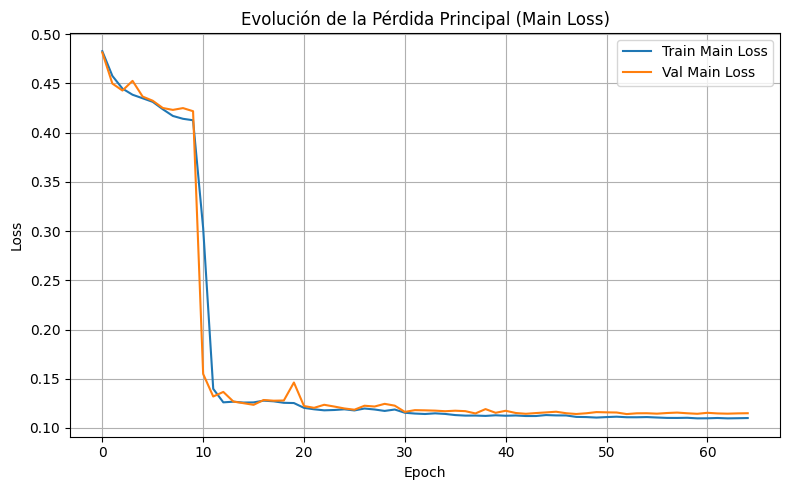

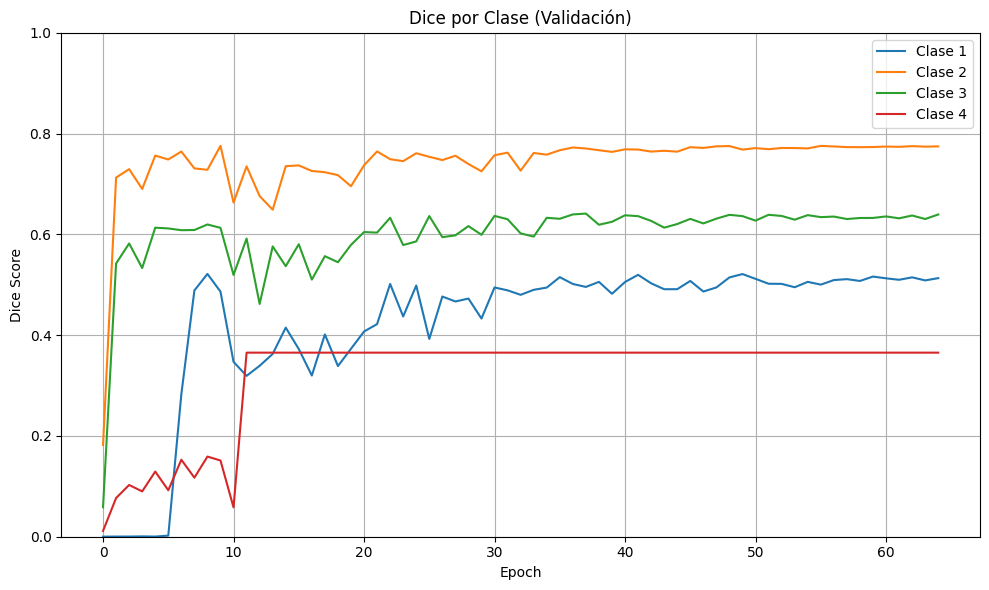

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# === Cargar CSV ===
csv_path = "/notebooks/runs/att_unet3d_ds_20250812-083445/training_log.csv"
df = pd.read_csv(csv_path)

# === 1. Evolución de la pérdida principal ===
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["out_main_loss"], label="Train Main Loss")
plt.plot(df["epoch"], df["val_out_main_loss"], label="Val Main Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida Principal (Main Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === 2. Evolución del Dice por clase en validación ===
dice_cols = {
    "val_out_main_dice_class_1": "Clase 1",
    "val_out_main_dice_class_2": "Clase 2",
    "val_out_main_dice_class_3": "Clase 3",
    "val_out_main_dice_class_4": "Clase 4",
}

plt.figure(figsize=(10, 6))
for col, label in dice_cols.items():
    plt.plot(df["epoch"], df[col], label=label)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice por Clase (Validación)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.5.2 Modelo Experto Binario para Clase 4

Debido a la baja frecuencia de aparición de la **clase 4** en el conjunto de datos, se entrenó un **modelo experto binario** específicamente diseñado para diferenciar dicha clase frente al resto del volumen. Se reutilizó la arquitectura **Attention UNet 3D**, adaptando la capa de salida a un único canal con activación **sigmoide**, y redefiniendo las máscaras como binarizadas (`mask == 4`).

**Ajustes principales:**
- **Entrada**: parches **64³** con 4 canales (modalidades)
- **Salida**: binaria (**clase 4 vs resto**)
- **Función de pérdida combinada**: `0.5 × Dice + 0.5 × Binary Cross-Entropy`
- **Métrica monitorizada**: `val_out_main_dice_class_4` (Dice para clase 4 en la salida principal)

**Resultados observados:**
- Dice clase 4 ≈ **0.365** durante varias épocas
- Comportamiento inesperado: el valor de `val_out_main_dice_class_4` se mantenía constante (**0.3653**) en varias épocas consecutivas antes de empeorar, lo cual sugiere posibles **problemas en la implementación** o en el **pipeline de evaluación** para este modelo.

**Conclusión**:

Debido a este comportamiento anómalo y al bajo rendimiento alcanzado, este modelo **no fue incluido en los ensembles finales**. No obstante, sirvió como experimento para explorar si una estrategia de **segmentación binaria focalizada exclusivamente sobre la clase 4** podría superar el desempeño de los modelos multiclase generalistas.

In [ ]:
import tensorflow as tf
import numpy as np, os
from glob import glob
from tensorflow.keras import layers, models, mixed_precision

# ========= Datos =========
patch_dir = "/notebooks/patches_segmentador_64"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

def load_npz_binary(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)
        mask = data["mask"].astype(np.uint8)
        mask = (mask == 4).astype(np.uint8)  # solo clase 4 vs resto
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_binary, [npz_path], [tf.float32, tf.uint8])
    img.set_shape((64,64,64,4))
    mask.set_shape((64,64,64))
    return img, mask

def apply_augmentations(image, mask):
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])
    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        for _ in tf.range(k):
            image = tf.transpose(image, [0,2,1,3]); image = tf.reverse(image, [1])
            mask  = tf.transpose(mask,  [0,2,1]);   mask  = tf.reverse(mask, [1])
    if tf.random.uniform(()) < 0.5:
        image = image * tf.random.uniform([], 0.9, 1.1)
    if tf.random.uniform(()) < 0.5:
        image = image + tf.random.uniform([], -0.1, 0.1)
    if tf.random.uniform(()) < 0.3:
        image = image + tf.random.normal(tf.shape(image), stddev=0.05)
    image = tf.clip_by_value(image, -5.0, 5.0)
    image = tf.where(tf.math.is_nan(image), tf.zeros_like(image), image)
    return image, mask

def create_dataset(npz_list, batch_size=16, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def ds_for_deepsup(ds):
    def to_dict(x, y):
        return x, {"out_main": y, "out_aux": y}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = ds_for_deepsup(create_dataset(train_npz, training=True))
val_ds   = ds_for_deepsup(create_dataset(val_npz, training=False))

# ========= Modelo =========
mixed_precision.set_global_policy('mixed_float16')

def attention_block(x, g, filters):
    theta_x = layers.Conv3D(filters, 1, padding='same')(x)
    phi_g   = layers.Conv3D(filters, 1, padding='same')(g)
    add     = layers.Activation('relu')(layers.add([theta_x, phi_g]))
    psi     = layers.Conv3D(1, 1, activation='sigmoid', padding='same')(add)
    return layers.multiply([x, psi])

def conv_block(x, filters):
    for _ in range(2):
        x = layers.Conv3D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization(epsilon=1e-3)(x)
        x = layers.LeakyReLU()(x)
    return x

def build_att_unet3d_binary(input_shape=(64,64,64,4)):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling3D(2)(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling3D(2)(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling3D(2)(c3)
    bn = conv_block(p3, 256)

    u3 = layers.Conv3DTranspose(128, 2, 2, padding='same')(bn)
    a3 = attention_block(c3, u3, 128)
    c6 = conv_block(tf.concat([u3, a3], -1), 128)

    u2 = layers.Conv3DTranspose(64, 2, 2, padding='same')(c6)
    a2 = attention_block(c2, u2, 64)
    c7 = conv_block(tf.concat([u2, a2], -1), 64)

    u1 = layers.Conv3DTranspose(32, 2, 2, padding='same')(c7)
    a1 = attention_block(c1, u1, 32)
    c8 = conv_block(tf.concat([u1, a1], -1), 32)

    out_main = layers.Conv3D(1, 1, activation='sigmoid', name="out_main", dtype='float32')(c8)
    aux = layers.Conv3D(1, 1, activation='sigmoid')(c7)
    aux = layers.UpSampling3D(size=2)(aux)
    out_aux = layers.Activation('linear', dtype='float32', name="out_aux")(aux)

    return models.Model(inputs, [out_main, out_aux])

model = build_att_unet3d_binary()
model.summary()

# ========= Pérdidas y métricas =========
EPS = 1e-7

def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    return 1 - tf.reduce_mean((2. * inter + EPS) / (denom + EPS))

def bce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

def combo_loss(y_true, y_pred, alpha=0.5):
    return alpha * dice_loss(y_true, y_pred) + (1 - alpha) * bce_loss(y_true, y_pred)

dice_metric = tf.keras.metrics.MeanMetricWrapper(
    lambda y_true, y_pred: (2. * tf.reduce_sum(tf.cast(y_true, tf.float32) * tf.round(y_pred)) + EPS) /
                           (tf.reduce_sum(tf.cast(y_true, tf.float32)) + tf.reduce_sum(tf.round(y_pred)) + EPS),
    name="dice_class_4"
)

# ========= Entrenamiento =========
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss={"out_main": combo_loss, "out_aux": combo_loss},
    loss_weights={"out_main": 1.0, "out_aux": 0.2},
    metrics={"out_main": [dice_metric]}
)

# ========= Callbacks =========
import datetime
run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
run_dir = f"/notebooks/runs/class4_expert_{run_id}"
os.makedirs(run_dir, exist_ok=True)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(run_dir, "best_model.keras"),
            monitor="val_out_main_dice_class_4", mode="max",
            save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_out_main_dice_class_4", mode="max",
            patience=12, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.TensorBoard(log_dir=os.path.join(run_dir, "tb_logs")),
        tf.keras.callbacks.CSVLogger(os.path.join(run_dir, "training_log.csv")),
    ]
)

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d_24 (Conv3D)          (None, 64, 64, 64, 32)       3488      ['input_2[0][0]']             
                                                                                                  
 batch_normalization_14 (Ba  (None, 64, 64, 64, 32)       128       ['conv3d_24[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 leaky_re_lu_14 (LeakyReLU)  (None, 64, 64, 64, 32)       0         ['batch_normalization_14

2025-08-25 21:24:22.757834: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-25 21:24:48.470509: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f48f90198d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-25 21:24:48.471362: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-25 21:24:48.503289: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756157088.728311      91 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1749/1749 [==============================] - ETA: 0s - loss: 0.6669 - out_main_loss: 0.5574 - out_aux_loss: 0.5476 - out_main_dice_class_4: 0.3105
Epoch 1: val_out_main_dice_class_4 improved from -inf to 0.36530, saving model to /notebooks/runs/class4_expert_20250825-212415/best_model.keras


/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:403: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     lambda y_true, y_pred: (2. * tf.reduce_sum(tf.cast(y_true, tf.float32) * tf.round(y_pred)) + EPS) /

  return {key: serialize_keras_object(value) for key, value in obj.items()}


1749/1749 [==============================] - 534s 283ms/step - loss: 0.6669 - out_main_loss: 0.5574 - out_aux_loss: 0.5476 - out_main_dice_class_4: 0.3105 - val_loss: 0.6233 - val_out_main_loss: 0.5206 - val_out_aux_loss: 0.5135 - val_out_main_dice_class_4: 0.3653
Epoch 2/100
1749/1749 [==============================] - ETA: 0s - loss: 0.6120 - out_main_loss: 0.5107 - out_aux_loss: 0.5063 - out_main_dice_class_4: 0.4774
Epoch 2: val_out_main_dice_class_4 did not improve from 0.36530
1749/1749 [==============================] - 487s 278ms/step - loss: 0.6120 - out_main_loss: 0.5107 - out_aux_loss: 0.5063 - out_main_dice_class_4: 0.4774 - val_loss: 0.6058 - val_out_main_loss: 0.5051 - val_out_aux_loss: 0.5033 - val_out_main_dice_class_4: 0.3653
Epoch 3/100
1749/1749 [==============================] - ETA: 0s - loss: 0.6034 - out_main_loss: 0.5031 - out_aux_loss: 0.5019 - out_main_dice_class_4: 0.4717
Epoch 3: val_out_main_dice_class_4 did not improve from 0.36530
1749/1749 [=============

In [4]:
# ===== Celda 4: compile + callbacks (REANUDAR) =====
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau 
import datetime, os

# ======= LR schedule (warmup + plateau) =======
BASE_LR         = 1e-4
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

opt = tf.keras.optimizers.Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)
    def on_epoch_begin(self, epoch, logs=None):
        # 
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

# ========= compile =========
model.compile(
    optimizer=opt,
    loss={"out_main": combined_loss_from_int, "out_aux": combined_loss_from_int},
    loss_weights={"out_main": 1.0, "out_aux": 0.2},
    metrics={"out_main": [dice_metric_class(1), dice_metric_class(2),
                          dice_metric_class(3), dice_metric_class(4)]}
)

# ========= usar el run_dir EXISTENTE para reanudar =========
run_dir    = "/notebooks/runs/att_unet3d_ds_20250812-083445"   #
ckpt_best  = os.path.join(run_dir, "best_att_unet3d_ds_v2.keras")
ckpt_last  = os.path.join(run_dir, "last_att_unet3d_ds_v2.keras")
backup_dir = os.path.join(run_dir, "backup")
log_dir    = os.path.join(run_dir, "tb_logs")

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1
    ),

    # guardar "último" cada epoch
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    tf.keras.callbacks.EarlyStopping(monitor="val_out_main_loss", patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(os.path.join(run_dir, "training_log.csv"), append=True),  # <- seguir en el mismo csv
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.BackupAndRestore(backup_dir),  #
    LogLR(),
]

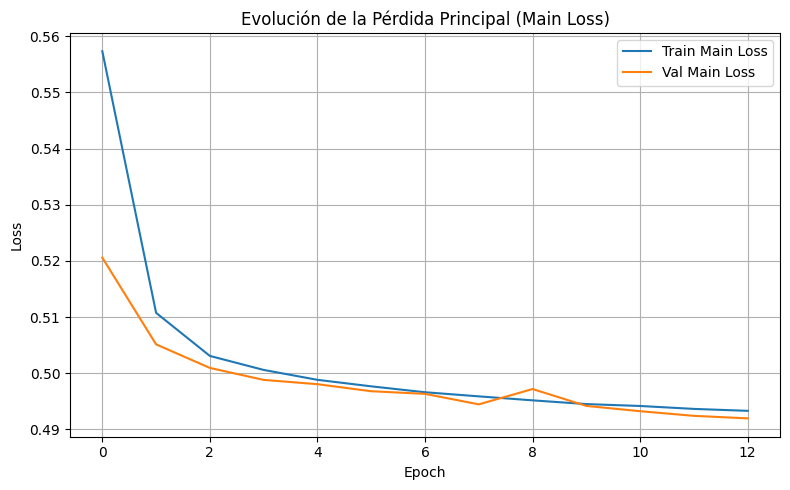

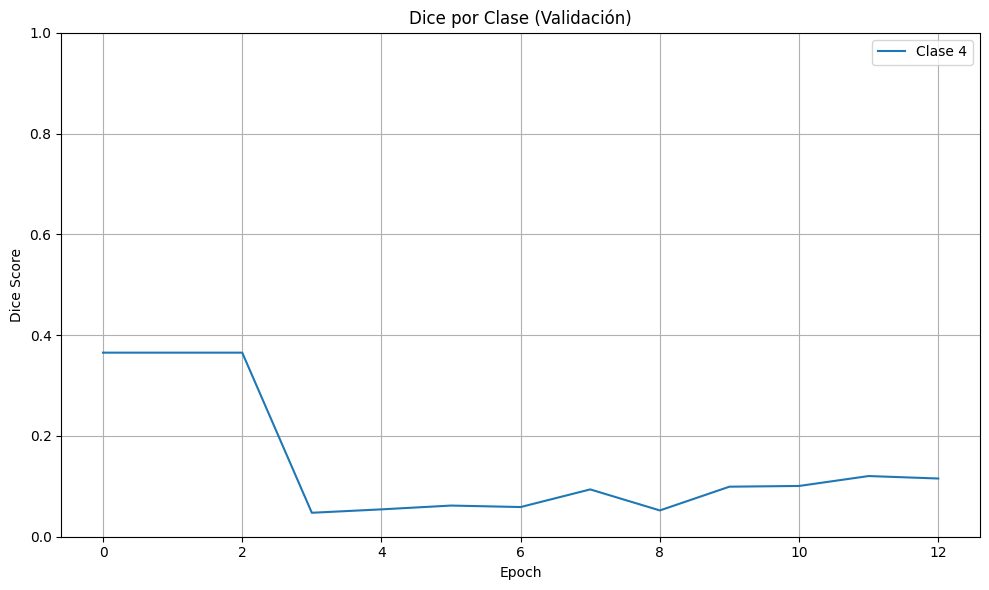

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# === Cargar CSV ===
csv_path = "/notebooks/runs/class4_expert_20250825-212415/training_log.csv"
df = pd.read_csv(csv_path)

# === 1. Evolución de la pérdida principal ===
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["out_main_loss"], label="Train Main Loss")
plt.plot(df["epoch"], df["val_out_main_loss"], label="Val Main Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida Principal (Main Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === 2. Evolución del Dice por clase en validación ===
dice_cols = {
    "val_out_main_dice_class_4": "Clase 4",
}

plt.figure(figsize=(10, 6))
for col, label in dice_cols.items():
    plt.plot(df["epoch"], df[col], label=label)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice por Clase (Validación)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.5.3 UNet++ 3D con Deep Supervision

Durante el desarrollo, se implementó y entrenó una arquitectura basada en **UNet++ 3D** con **supervisión profunda (deep supervision)**, diseñada para mejorar la capacidad del modelo en tareas de **segmentación multiclase** de metástasis cerebrales.

Este modelo incluía las siguientes características:

- **Conexiones densas entre bloques de decodificación**, típicas de UNet++, que permiten una mayor reutilización de características y mejoran la propagación de gradientes.
- **Salidas intermedias** supervisadas con funciones de pérdida propias, ponderadas respecto a la salida principal (`out_main`), lo que favorece un aprendizaje jerárquico a múltiples escalas.
- **Activación final `softmax`** sobre 5 clases: fondo (0) + clases 1 a 4.

Se utilizó una política de entrenamiento avanzada, que incluía:

- **Warm-up** de la tasa de aprendizaje durante las primeras épocas para estabilizar el entrenamiento inicial.
- **Reducción automática del learning rate** mediante `ReduceLROnPlateau`, en función de la evolución de la pérdida de validación.
- **Función de pérdida combinada (Dice + Focal Loss)**, con pesos ajustados por clase para compensar el fuerte desbalance entre categorías.

Aunque el modelo fue entrenado correctamente y alcanzó métricas **aceptables en validación**, **no fue empleado en la etapa de inferencia** ni incluido en los ensembles finales. Esto se debió a que otros modelos presentaron un **rendimiento superior por clase**, por lo que se priorizó su utilización en la fase de evaluación y despliegue.

In [7]:
import tensorflow as tf
import numpy as np
import os
from glob import glob

# =========================
# Config y listado de files
# =========================
patch_dir = "/notebooks/patches_segmentador_64"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

NUM_CLASSES = 5
IMG_SHAPE   = (64, 64, 64, 4)
MASK_SHAPE  = (64, 64, 64)

# =========================
# Carga segura (.npz)
# =========================
def load_npz_sample(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)   # z-score por canal
        mask = data["mask"].astype(np.uint8)      # {0..4}
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_sample, [npz_path], [tf.float32, tf.uint8])
    img = tf.ensure_shape(img, IMG_SHAPE)
    mask = tf.ensure_shape(mask, MASK_SHAPE)
    # robustez: recorte suave de outliers, SIN pasar a [0,1]
    img = tf.clip_by_value(img, -6.0, 6.0)
    mask = tf.minimum(mask, tf.cast(NUM_CLASSES-1, tf.uint8))
    return img, mask

# =========================
# Augmentaciones seguras
# =========================
def rotate_90_z_image(image, k):
    for _ in tf.range(k):
        image = tf.transpose(image, [0, 2, 1, 3])
        image = tf.reverse(image, axis=[1])
    return image

def rotate_90_z_mask(mask, k):
    for _ in tf.range(k):
        mask = tf.transpose(mask, [0, 2, 1])
        mask = tf.reverse(mask, axis=[1])
    return mask

def apply_augmentations(image, mask):
    # flips aleatorios en Z,Y,X
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])

    # rotación 90° Z
    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = rotate_90_z_image(image, k)
        mask  = rotate_90_z_mask(mask,  k)

    # contraste/brillo en z-score: x -> x*(1+α) + β
    if tf.random.uniform(()) < 0.5:
        alpha = tf.random.uniform([], -0.10, 0.10)
        beta  = tf.random.uniform([], -0.10, 0.10)
        image = image * (1.0 + alpha) + beta

    # ruido gaussiano leve
    if tf.random.uniform(()) < 0.3:
        noise = tf.random.normal(tf.shape(image), stddev=0.05)
        image = image + noise

    # recorte suave final
    image = tf.clip_by_value(image, -6.0, 6.0)
    return image, mask

# =========================
# One-hot + Deep Supervision
# =========================
def to_one_hot(image, mask):
    mask_oh = tf.one_hot(tf.cast(mask, tf.int32), depth=NUM_CLASSES)
    mask_oh = tf.cast(mask_oh, tf.float32)
    image = tf.ensure_shape(image, IMG_SHAPE)
    mask_oh = tf.ensure_shape(mask_oh, (*MASK_SHAPE, NUM_CLASSES))
    return image, mask_oh

def ds_for_deepsup(ds):
    def to_dict(x, y):
        y = tf.ensure_shape(y, tf.TensorShape([None, 64, 64, 64, 5]))
        return x, {"out_main": y, "out_aux2": y, "out_aux3": y, "out_aux4": y}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

# =========================
# Constructor de datasets
# =========================
def create_dataset(npz_list, batch_size=8, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper,             num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_one_hot,             num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)

    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts).prefetch(tf.data.AUTOTUNE)
    return ds

# =========================
# Crear y adaptar a deep sup
# =========================
train_dataset = create_dataset(train_npz, batch_size=8, training=True)
val_dataset   = create_dataset(val_npz,   batch_size=8, training=False)

train_ds_ds = ds_for_deepsup(train_dataset)
val_ds_ds   = ds_for_deepsup(val_dataset)

# Sanity
for xb, yb in train_dataset.take(1):
    print("img batch → mean:", float(tf.reduce_mean(xb)), "std:", float(tf.math.reduce_std(xb)),
          "min:", float(tf.reduce_min(xb)), "max:", float(tf.reduce_max(xb)))
    print("y one-hot:", yb.shape)

2025-09-02 21:12:30.778720: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-02 21:12:30.779650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-02 21:12:30.871441: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-02 21:12:31.074545: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-02 21:12:33.332871: W tensorflow/compiler/tf2

img batch → mean: 0.3052791655063629 std: 1.2922029495239258 min: -0.7927601337432861 max: 6.0
y one-hot: (8, 64, 64, 64, 5)


2025-09-02 21:12:39.315935: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 41943040 exceeds 10% of free system memory.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, TensorBoard
import datetime, os
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ========= Config =========
mixed_precision.set_global_policy("mixed_float16")
NUM_CLASSES = 5
INPUT_SHAPE = (64, 64, 64, 4)
EPS = 1e-6

# ========= Pérdidas / Métricas (one-hot) =========
def dice_loss_onehot_safe(y_true, y_pred, include_bg=False, smooth=1e-5):
    # y_true/pred: [B,Z,Y,X,C] en one-hot y softmax
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]

    axes = [1, 2, 3]  # sum over space
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)      # [B,C]
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)      # [B,C]
    dice  = (2.0 * inter + smooth) / (denom + smooth)      # [B,C]

    # ignora clases vacías (sin voxeles verdaderos en el parche)
    true_sum   = tf.reduce_sum(y_true, axis=axes)          # [B,C]
    present    = tf.cast(true_sum > 0.0, tf.float32)       # [B,C]
    dice_sum   = tf.reduce_sum(dice * present, axis=-1)    # [B]
    num_present= tf.maximum(tf.reduce_sum(present, axis=-1), 1.0)  # [B]
    dice_mean  = dice_sum / num_present                    # [B]
    return 1.0 - tf.reduce_mean(dice_mean)

def focal_loss_onehot_stable(y_true, y_pred, gamma=2.0, alpha=(0.2, 1.0, 1.0, 1.0, 3.0), include_bg=False):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]
        alpha  = alpha[1:]

    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)  # [B,Z,Y,X]
    alpha_vec = tf.constant(alpha, dtype=tf.float32)                                   # [C]
    alpha_t   = tf.reduce_sum(y_true * alpha_vec, axis=-1)                             # [B,Z,Y,X]
    p_t       = tf.reduce_sum(y_true * y_pred, axis=-1)                                # [B,Z,Y,X]
    focal     = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_onehot_stable(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_onehot_safe(y_true, y_pred, include_bg=False) + \
           (1 - alpha_mix) * focal_loss_onehot_stable(y_true, y_pred, include_bg=False)

# métricas Dice por clase
def dice_single_class(y_true, y_pred, class_idx, smooth=1e-5):
    y_true_c  = tf.cast(y_true[..., class_idx], tf.float32)
    y_pred_arg= tf.argmax(y_pred, axis=-1)
    y_pred_c  = tf.cast(tf.equal(y_pred_arg, class_idx), tf.float32)
    inter = tf.reduce_sum(y_true_c * y_pred_c)
    denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2. * inter + smooth) / (denom + smooth)

def dice_class_1(y_true, y_pred): return dice_single_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_single_class(y_true, y_pred, 2)
def dice_class_3(y_true, y_pred): return dice_single_class(y_true, y_pred, 3)
def dice_class_4(y_true, y_pred): return dice_single_class(y_true, y_pred, 4)

# ========= Bloques base =========
def conv_block(x, f, dropout=0.0):
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return x

def up(x, f):  # upsample por deconvolución
    return layers.Conv3DTranspose(f, 2, strides=2, padding='same')(x)

# ========= UNet++ 3D (compacta) con Deep Supervision =========
def build_unetpp3d_deepsup(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x00 = conv_block(inputs, 32)           # 64
    p0  = layers.MaxPooling3D(2)(x00)      # 32

    x10 = conv_block(p0, 64)               # 32
    p1  = layers.MaxPooling3D(2)(x10)      # 16

    x20 = conv_block(p1, 128)              # 16
    p2  = layers.MaxPooling3D(2)(x20)      # 8

    x30 = conv_block(p2, 256)              # 8
    p3  = layers.MaxPooling3D(2)(x30)      # 4

    x40 = conv_block(p3, 384)              # 4 (bottleneck)

    # Nested decoder
    x01 = conv_block(layers.Concatenate()([up(x10, 32),  x00]),  32)   # 64
    x11 = conv_block(layers.Concatenate()([up(x20, 64),  x10]),  64)   # 32
    x21 = conv_block(layers.Concatenate()([up(x30,128),  x20]), 128)   # 16
    x31 = conv_block(layers.Concatenate()([up(x40,256),  x30]), 256)   # 8

    x02 = conv_block(layers.Concatenate()([up(x11, 32),  x00, x01]),   32)  # 64
    x12 = conv_block(layers.Concatenate()([up(x21, 64),  x10, x11]),   64)  # 32
    x22 = conv_block(layers.Concatenate()([up(x31,128),  x20, x21]),  128)  # 16

    x03 = conv_block(layers.Concatenate()([up(x12, 32),  x00, x01, x02]),   32)  # 64
    x13 = conv_block(layers.Concatenate()([up(x22, 64),  x10, x11, x12]),   64)  # 32

    x04 = conv_block(layers.Concatenate()([up(x13, 32),  x00, x01, x02, x03]), 32)  # 64

    # Deep Supervision heads (todas 64³)
    out_main = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32', name="out_main")(x04)

    aux2 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x03)
    out_aux2 = layers.Activation('linear', dtype='float32', name="out_aux2")(aux2)

    aux3 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x22)    # 16³
    aux3 = layers.UpSampling3D(size=(4,4,4))(aux3)                                      # → 64³
    out_aux3 = layers.Activation('linear', dtype='float32', name="out_aux3")(aux3)

    aux4 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x31)    # 8³
    aux4 = layers.UpSampling3D(size=(8,8,8))(aux4)                                      # → 64³
    out_aux4 = layers.Activation('linear', dtype='float32', name="out_aux4")(aux4)

    return models.Model(inputs, [out_main, out_aux2, out_aux3, out_aux4], name="UNetPP3D_DeepSup")

model_ds = build_unetpp3d_deepsup(INPUT_SHAPE, NUM_CLASSES)
model_ds.summary()


# ========= Configuración de LR =========
BASE_LR         = 1e-4      # LR objetivo tras warmup
WARMUP_START_LR = 5e-6
WARMUP_EPOCHS   = 2
MIN_LR          = 1e-6
CLIPNORM        = 1.0

optimizer = Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

loss_fn = combined_loss_onehot_stable

model_ds.compile(
    optimizer=optimizer,
    loss={"out_main": loss_fn, "out_aux2": loss_fn, "out_aux3": loss_fn, "out_aux4": loss_fn},
    loss_weights={"out_main": 1.0, "out_aux2": 0.5, "out_aux3": 0.25, "out_aux4": 0.125},
    metrics={"out_main": [dice_class_1, dice_class_2, dice_class_3, dice_class_4]}
)

# ========= Callbacks =========
# ============ Rutas únicas por run ============
run_dir   = "/notebooks/runs/unetpp3d_ds_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_unetpp3d_ds.keras")   # mejor por val_out_main_loss
ckpt_last  = os.path.join(run_dir, "last_unetpp3d_ds.keras")   # último de cada época
backup_dir = os.path.join(run_dir, "backup")                   # estado entreno p/ reanudar (mid-epoch)
log_dir    = os.path.join(run_dir, "tb_logs")                  # TensorBoard
os.makedirs(log_dir, exist_ok=True)

# guarda la ruta del run para reanudar fácil luego
with open(os.path.join(run_dir, "RUN_DIR.txt"), "w") as f:
    f.write(run_dir + "\n")
print("RUN_DIR:", run_dir)

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=3, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1
    ),

    # “último” de cada epoch
    ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    EarlyStopping(monitor="val_out_main_loss", patience=12, restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(run_dir, "training_log.csv")),
    TensorBoard(log_dir=log_dir),

    # 🔁 Reanudar automático si la sesión corta (restaura optimizador, epoch, etc.)
    tf.keras.callbacks.BackupAndRestore(backup_dir),

    LogLR(),
]

Model: "UNetPP3D_DeepSup"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d_33 (Conv3D)          (None, 64, 64, 64, 32)       3488      ['input_2[0][0]']             
                                                                                                  
 batch_normalization_30 (Ba  (None, 64, 64, 64, 32)       128       ['conv3d_33[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 leaky_re_lu_30 (LeakyReLU)  (None, 64, 64, 64, 32)       0         ['batch_normali

In [ ]:
# ========= Entrenamiento =========
history_ds = model_ds.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
3497/3497 [==============================] - ETA: 0s - loss: 0.8518 - out_main_loss: 0.4506 - out_aux2_loss: 0.4561 - out_aux3_loss: 0.4557 - out_aux4_loss: 0.4738 - out_main_dice_class_1: 1.6029e-04 - out_main_dice_class_2: 0.4637 - out_main_dice_class_3: 0.0063 - out_main_dice_class_4: 1.9733e-05
Epoch 1: val_out_main_loss improved from inf to 0.42835, saving model to /notebooks/runs/unetpp3d_ds_20250812-221116/best_unetpp3d_ds.keras

📉 LR @epoch 0: 5.250000e-05
3497/3497 [==============================] - 1382s 388ms/step - loss: 0.8518 - out_main_loss: 0.4506 - out_aux2_loss: 0.4561 - out_aux3_loss: 0.4557 - out_aux4_loss: 0.4738 - out_main_dice_class_1: 1.6029e-04 - out_main_dice_class_2: 0.4637 - out_main_dice_class_3: 0.0063 - out_main_dice_class_4: 1.9733e-05 - val_loss: 0.8158 - val_out_main_loss: 0.4284 - val_out_aux2_loss: 0.4345 - val_out_aux3_loss: 0.4457 - val_out_aux4_loss: 0.4704 - val_out_main_dice_class_1: 1.8961e-04 - val_out_main_dice_class_2: 0.6111 - v

### Reanudacion

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, TensorBoard
import datetime, os
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ========= Config =========
mixed_precision.set_global_policy("mixed_float16")
NUM_CLASSES = 5
INPUT_SHAPE = (64, 64, 64, 4)
EPS = 1e-6

# ========= Pérdidas / Métricas (one-hot) =========
def dice_loss_onehot_safe(y_true, y_pred, include_bg=False, smooth=1e-5):
    # y_true/pred: [B,Z,Y,X,C] en one-hot y softmax
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]

    axes = [1, 2, 3]  # sum over space
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)      # [B,C]
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)      # [B,C]
    dice  = (2.0 * inter + smooth) / (denom + smooth)      # [B,C]

    # ignora clases vacías (sin voxeles verdaderos en el parche)
    true_sum   = tf.reduce_sum(y_true, axis=axes)          # [B,C]
    present    = tf.cast(true_sum > 0.0, tf.float32)       # [B,C]
    dice_sum   = tf.reduce_sum(dice * present, axis=-1)    # [B]
    num_present= tf.maximum(tf.reduce_sum(present, axis=-1), 1.0)  # [B]
    dice_mean  = dice_sum / num_present                    # [B]
    return 1.0 - tf.reduce_mean(dice_mean)

def focal_loss_onehot_stable(y_true, y_pred, gamma=2.0, alpha=(0.2, 1.0, 1.0, 1.0, 3.0), include_bg=False):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]
        alpha  = alpha[1:]

    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)  # [B,Z,Y,X]
    alpha_vec = tf.constant(alpha, dtype=tf.float32)                                   # [C]
    alpha_t   = tf.reduce_sum(y_true * alpha_vec, axis=-1)                             # [B,Z,Y,X]
    p_t       = tf.reduce_sum(y_true * y_pred, axis=-1)                                # [B,Z,Y,X]
    focal     = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_onehot_stable(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_onehot_safe(y_true, y_pred, include_bg=False) + \
           (1 - alpha_mix) * focal_loss_onehot_stable(y_true, y_pred, include_bg=False)

# métricas Dice por clase 
def dice_single_class(y_true, y_pred, class_idx, smooth=1e-5):
    y_true_c  = tf.cast(y_true[..., class_idx], tf.float32)
    y_pred_arg= tf.argmax(y_pred, axis=-1)
    y_pred_c  = tf.cast(tf.equal(y_pred_arg, class_idx), tf.float32)
    inter = tf.reduce_sum(y_true_c * y_pred_c)
    denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2. * inter + smooth) / (denom + smooth)

def dice_class_1(y_true, y_pred): return dice_single_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_single_class(y_true, y_pred, 2)
def dice_class_3(y_true, y_pred): return dice_single_class(y_true, y_pred, 3)
def dice_class_4(y_true, y_pred): return dice_single_class(y_true, y_pred, 4)

# ========= Bloques base =========
def conv_block(x, f, dropout=0.0):
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return x

def up(x, f):  # upsample por deconvolución
    return layers.Conv3DTranspose(f, 2, strides=2, padding='same')(x)

# ========= UNet++ 3D (compacta) con Deep Supervision =========
def build_unetpp3d_deepsup(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x00 = conv_block(inputs, 32)           # 64
    p0  = layers.MaxPooling3D(2)(x00)      # 32

    x10 = conv_block(p0, 64)               # 32
    p1  = layers.MaxPooling3D(2)(x10)      # 16

    x20 = conv_block(p1, 128)              # 16
    p2  = layers.MaxPooling3D(2)(x20)      # 8

    x30 = conv_block(p2, 256)              # 8
    p3  = layers.MaxPooling3D(2)(x30)      # 4

    x40 = conv_block(p3, 384)              # 4 (bottleneck)

    # Nested decoder
    x01 = conv_block(layers.Concatenate()([up(x10, 32),  x00]),  32)   # 64
    x11 = conv_block(layers.Concatenate()([up(x20, 64),  x10]),  64)   # 32
    x21 = conv_block(layers.Concatenate()([up(x30,128),  x20]), 128)   # 16
    x31 = conv_block(layers.Concatenate()([up(x40,256),  x30]), 256)   # 8

    x02 = conv_block(layers.Concatenate()([up(x11, 32),  x00, x01]),   32)  # 64
    x12 = conv_block(layers.Concatenate()([up(x21, 64),  x10, x11]),   64)  # 32
    x22 = conv_block(layers.Concatenate()([up(x31,128),  x20, x21]),  128)  # 16

    x03 = conv_block(layers.Concatenate()([up(x12, 32),  x00, x01, x02]),   32)  # 64
    x13 = conv_block(layers.Concatenate()([up(x22, 64),  x10, x11, x12]),   64)  # 32

    x04 = conv_block(layers.Concatenate()([up(x13, 32),  x00, x01, x02, x03]), 32)  # 64

    # Deep Supervision heads (todas 64³)
    out_main = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32', name="out_main")(x04)

    aux2 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x03)
    out_aux2 = layers.Activation('linear', dtype='float32', name="out_aux2")(aux2)

    aux3 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x22)    # 16³
    aux3 = layers.UpSampling3D(size=(4,4,4))(aux3)                                      # → 64³
    out_aux3 = layers.Activation('linear', dtype='float32', name="out_aux3")(aux3)

    aux4 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x31)    # 8³
    aux4 = layers.UpSampling3D(size=(8,8,8))(aux4)                                      # → 64³
    out_aux4 = layers.Activation('linear', dtype='float32', name="out_aux4")(aux4)

    return models.Model(inputs, [out_main, out_aux2, out_aux3, out_aux4], name="UNetPP3D_DeepSup")

model_ds = build_unetpp3d_deepsup(INPUT_SHAPE, NUM_CLASSES)
model_ds.summary()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A6000, compute capability 8.6


2025-08-14 07:14:33.327940: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "UNetPP3D_DeepSup"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 64, 64, 64, 32)       3488      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 64, 32)       128       ['conv3d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 64, 32)       0         ['batch_normali

In [ ]:
# ===== Celda: compile + callbacks (REANUDAR UNet++ DS) =====
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import os, datetime

# ======= LR schedule (warmup + plateau) =======
BASE_LR         = 1e-4
WARMUP_START_LR = 5e-6
WARMUP_EPOCHS   = 2
MIN_LR          = 1e-6
CLIPNORM        = 1.0

optimizer = Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)
    def on_epoch_begin(self, epoch, logs=None):
        # si reanudas a mitad, epoch ya será alto y no hará warmup
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

# ========= compile (UNet++ one-hot, 4 salidas) =========
model_ds.compile(
    optimizer=optimizer,
    loss={
        "out_main": combined_loss_onehot_stable,
        "out_aux2": combined_loss_onehot_stable,
        "out_aux3": combined_loss_onehot_stable,
        "out_aux4": combined_loss_onehot_stable,
    },
    loss_weights={"out_main": 1.0, "out_aux2": 0.5, "out_aux3": 0.25, "out_aux4": 0.125},
    metrics={"out_main": [dice_class_1, dice_class_2, dice_class_3, dice_class_4]},
)

# ========= rutas de reanudación =========
run_dir    = "/notebooks/runs/unetpp3d_ds_20250812-221116" 
ckpt_best  = os.path.join(run_dir, "best_unetpp3d_ds.keras")
ckpt_last  = os.path.join(run_dir, "last_unetpp3d_ds.keras")
backup_dir = os.path.join(run_dir, "backup")
log_dir    = os.path.join(run_dir, "tb_logs")
os.makedirs(run_dir, exist_ok=True); os.makedirs(log_dir, exist_ok=True)

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=2, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1
    ),

    # opcional: guardar "último" cada epoch
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    tf.keras.callbacks.EarlyStopping(monitor="val_out_main_loss", patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(os.path.join(run_dir, "training_log.csv"), append=True),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),

    # <- RESUME automático (restaura pesos + estado del optimizador + epoch)
    tf.keras.callbacks.BackupAndRestore(backup_dir),

    LogLR(),
]

# ===== Entrenamiento (reanuda solo con .fit) =====
history = model_ds.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,
    callbacks=callbacks
)



Epoch 72/100
3497/3497 [==============================] - ETA: 0s - loss: 0.6147 - out_main_loss: 0.3037 - out_aux2_loss: 0.3080 - out_aux3_loss: 0.4047 - out_aux4_loss: 0.4464 - out_main_dice_class_1: 0.5786 - out_main_dice_class_2: 0.8143 - out_main_dice_class_3: 0.7564 - out_main_dice_class_4: 3.8388e-04
Epoch 72: val_out_main_loss improved from inf to 0.32972, saving model to /notebooks/runs/unetpp3d_ds_20250812-221116/best_unetpp3d_ds.keras

📉 LR @epoch 71: 1.000000e-06
3497/3497 [==============================] - 1363s 383ms/step - loss: 0.6147 - out_main_loss: 0.3037 - out_aux2_loss: 0.3080 - out_aux3_loss: 0.4047 - out_aux4_loss: 0.4464 - out_main_dice_class_1: 0.5786 - out_main_dice_class_2: 0.8143 - out_main_dice_class_3: 0.7564 - out_main_dice_class_4: 3.8388e-04 - val_loss: 0.6567 - val_out_main_loss: 0.3297 - val_out_aux2_loss: 0.3340 - val_out_aux3_loss: 0.4142 - val_out_aux4_loss: 0.4519 - val_out_main_dice_class_1: 0.5121 - val_out_main_dice_class_2: 0.7823 - val_out_ma

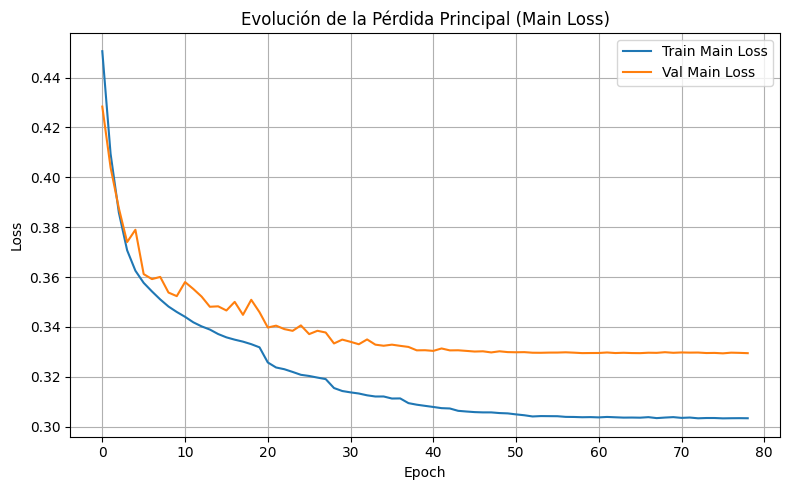

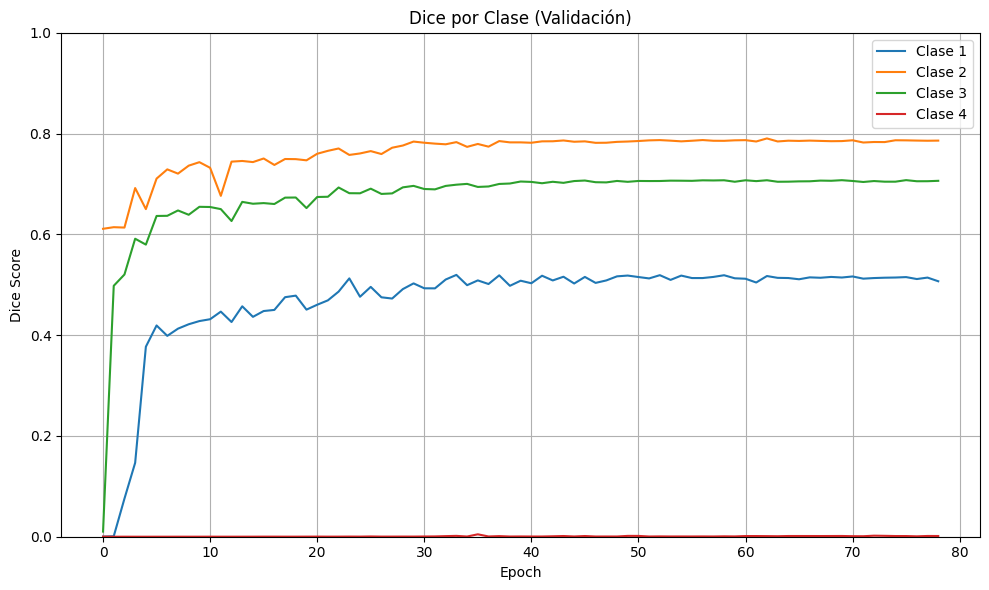

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# === Cargar CSV ===
csv_path = "/notebooks/runs/unetpp3d_ds_20250812-221116/training_log.csv"
df = pd.read_csv(csv_path)

# === 1. Evolución de la pérdida principal ===
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["out_main_loss"], label="Train Main Loss")
plt.plot(df["epoch"], df["val_out_main_loss"], label="Val Main Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida Principal (Main Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === 2. Evolución del Dice por clase en validación ===
dice_cols = {
    "val_out_main_dice_class_1": "Clase 1",
    "val_out_main_dice_class_2": "Clase 2",
    "val_out_main_dice_class_3": "Clase 3",
    "val_out_main_dice_class_4": "Clase 4",
}

plt.figure(figsize=(10, 6))
for col, label in dice_cols.items():
    plt.plot(df["epoch"], df[col], label=label)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice por Clase (Validación)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.5.4 Modelo Segmentador: UNet++ 3D con Deep Supervision (**usado en inferencia**)

Este modelo implementa una arquitectura **UNet++ 3D compacta** optimizada para tareas de **segmentación multiclase** sobre imágenes médicas tridimensionales. Fue entrenado utilizando parches de tamaño **64³**, integrando múltiples estrategias diseñadas para mejorar la **convergencia**, **robustez** y **capacidad de generalización**. A diferencia del modelo Attention UNet 3D anterior, esta versión incorpora tres mecanismos avanzados:

---

#### Deep Supervision

El modelo no solo produce una salida principal (`out_main`), sino también **tres salidas auxiliares** provenientes de niveles intermedios del decodificador. Este enfoque, conocido como *deep supervision*, ofrece múltiples beneficios:

- **Mejor propagación del gradiente**, especialmente útil en las primeras etapas del entrenamiento.
- **Regularización implícita**, al forzar al modelo a aprender representaciones útiles a distintas profundidades.
- **Estabilidad en tareas desbalanceadas o con clases complejas**, como la clase 4.

Durante la compilación, se asignaron **funciones de pérdida independientes** a cada salida, todas basadas en la combinación de **Dice Loss + Focal Loss**, ignorando el fondo (`include_bg=False`) y ponderando más la clase 4 (`alpha=(0.2, 1, 1, 1, 4)`).

---

#### Warm-up del Learning Rate

Para evitar inestabilidades en las primeras iteraciones del entrenamiento, se empleó una política de **calentamiento del learning rate (warm-up)**:

- El optimizador Adam comenzó con un valor bajo (`1e-5`) y lo incrementó de forma lineal hasta `2e-4` durante las primeras **3 épocas**.
- Este enfoque reduce la probabilidad de que los gradientes iniciales sean excesivos, permitiendo un arranque más suave y estable.

---

#### Annealing de las pérdidas auxiliares

Las salidas auxiliares **no mantuvieron un peso constante** durante todo el entrenamiento. En su lugar, se aplicó un esquema de *annealing*:

- Entre las **épocas 30 y 70**, los pesos de las pérdidas auxiliares (`aux2`, `aux3`, `aux4`) se redujeron de forma progresiva hasta casi anularse.
- Este mecanismo permite que el modelo se beneficie del *deep supervision* en fases tempranas, mientras que en fases avanzadas **concentra el aprendizaje en la salida principal**.

---

#### Oversampling y augmentaciones

Como en modelos anteriores, se aplicó **oversampling online** sobre parches que contenían la clase 4, duplicando su frecuencia relativa.

Las **augmentaciones** incluyeron:
- Flips aleatorios
- Rotaciones axiales
- Ajustes de intensidad (gamma, brillo)
- Ruido gaussiano

Todas ellas se implementaron mediante funciones **`tf.data`** optimizadas con `AUTOTUNE`, asegurando eficiencia durante el entrenamiento.

---

#### Resultados de validación

El mejor modelo fue seleccionado en la **época 74** por presentar la menor `val_out_main_loss`. Los valores **Dice** por clase alcanzados fueron:

- **Clase 1**: 0.545  
- **Clase 2**: 0.791  
- **Clase 3**: 0.716  
- **Clase 4**: 0.238  

Aunque la clase 4 continúa siendo la más desafiante, este modelo logró **superar globalmente** a versiones anteriores. Por ejemplo, el modelo Attention UNet 3D (64³) alcanzaba un Dice ≈ 0.36 en clase 4, pero con métricas más bajas en las demás clases.

---

#### Aplicación en inferencia y ensemble

Este modelo fue utilizado en la fase de **inferencia sobre el conjunto de validación BraTS-METS 2025** y formó parte activa del **ensemble voxel-wise**, especialmente para las clases **1, 2 y 3**.

Sus predicciones fueron combinadas con modelos complementarios, como el **Attention UNet experto en clase 4**, con el objetivo de **maximizar el rendimiento global por clase**.

In [1]:
import tensorflow as tf
import numpy as np
import os
from glob import glob

# =========================
# Config y listado de files
# =========================
patch_dir = "/notebooks/patches_segmentador_64"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

NUM_CLASSES = 5
IMG_SHAPE   = (64, 64, 64, 4)
MASK_SHAPE  = (64, 64, 64)

# =========================
# Carga segura (.npz)
# =========================
def load_npz_sample(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)   # z-score por canal
        mask = data["mask"].astype(np.uint8)      # {0..4}
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_sample, [npz_path], [tf.float32, tf.uint8])
    img = tf.ensure_shape(img, IMG_SHAPE)
    mask = tf.ensure_shape(mask, MASK_SHAPE)
    # robustez: recorte suave de outliers, SIN pasar a [0,1]
    img = tf.clip_by_value(img, -6.0, 6.0)
    mask = tf.minimum(mask, tf.cast(NUM_CLASSES-1, tf.uint8))
    return img, mask

# =========================
# Augmentaciones seguras
# =========================
def rotate_90_z_image(image, k):
    for _ in tf.range(k):
        image = tf.transpose(image, [0, 2, 1, 3])
        image = tf.reverse(image, axis=[1])
    return image

def rotate_90_z_mask(mask, k):
    for _ in tf.range(k):
        mask = tf.transpose(mask, [0, 2, 1])
        mask = tf.reverse(mask, axis=[1])
    return mask

def apply_augmentations(image, mask):
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])

    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = rotate_90_z_image(image, k)
        mask  = rotate_90_z_mask(mask,  k)

    if tf.random.uniform(()) < 0.5:
        alpha = tf.random.uniform([], -0.10, 0.10)
        beta  = tf.random.uniform([], -0.10, 0.10)
        image = image * (1.0 + alpha) + beta

    if tf.random.uniform(()) < 0.3:
        noise = tf.random.normal(tf.shape(image), stddev=0.05)
        image = image + noise

    image = tf.clip_by_value(image, -6.0, 6.0)
    return image, mask

# =========================
# One-hot + Deep Supervision
# =========================
def to_one_hot(image, mask):
    mask_oh = tf.one_hot(tf.cast(mask, tf.int32), depth=NUM_CLASSES)
    mask_oh = tf.cast(mask_oh, tf.float32)
    image = tf.ensure_shape(image, IMG_SHAPE)
    mask_oh = tf.ensure_shape(mask_oh, (*MASK_SHAPE, NUM_CLASSES))
    return image, mask_oh

def ds_for_deepsup(ds):
    def to_dict(x, y):
        y = tf.ensure_shape(y, tf.TensorShape([None, 64, 64, 64, 5]))
        return x, {"out_main": y, "out_aux2": y, "out_aux3": y, "out_aux4": y}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

# =========================
# Constructor de datasets
# =========================
def create_dataset(npz_list, batch_size=8, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper,             num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_one_hot,             num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)

    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts).prefetch(tf.data.AUTOTUNE)
    return ds

# =========================
# Sobre-muestreo online de clase 4
# =========================
USE_OVERSAMPLING_C4 = True
if USE_OVERSAMPLING_C4:
    def has_class4(npz_path):
        with np.load(npz_path) as d:
            m = d["mask"]
            return np.any(m == 4)
    train_npz_c4  = [p for p in train_npz if has_class4(p)]
    train_npz_noc4= [p for p in train_npz if p not in train_npz_c4]
    repeat_c4     = 2  
    oversampled_list = train_npz_noc4 + train_npz_c4 * repeat_c4
    rng = np.random.default_rng(42)
    rng.shuffle(oversampled_list)
    train_npz = oversampled_list
    print(f"Oversampling activo: {len(train_npz_c4)} con clase4 duplicados x{repeat_c4}")

# =========================
# Crear y adaptar a deep sup
# =========================
train_dataset = create_dataset(train_npz, batch_size=8, training=True)
val_dataset   = create_dataset(val_npz,   batch_size=8, training=False)

train_ds_ds = ds_for_deepsup(train_dataset)
val_ds_ds   = ds_for_deepsup(val_dataset)

# Sanity check
for xb, yb in train_dataset.take(1):
    print("img batch → mean:", float(tf.reduce_mean(xb)), "std:", float(tf.math.reduce_std(xb)),
          "min:", float(tf.reduce_min(xb)), "max:", float(tf.reduce_max(xb)))
    print("y one-hot:", yb.shape)

2025-08-18 06:58:40.053247: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-18 06:58:40.053310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-18 06:58:40.055061: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-18 06:58:40.065246: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-18 06:58:41.369396: W tensorflow/compiler/tf2

🔄 Oversampling activo: 1273 con clase4 duplicados x2


2025-08-18 07:05:02.577511: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-18 07:05:02.760593: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-18 07:05:02.760831: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

img batch → mean: 0.3780249357223511 std: 1.258760929107666 min: -0.5098000764846802 max: 6.0
y one-hot: (8, 64, 64, 64, 5)


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, TensorBoard
import datetime, os
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ========= Config =========
mixed_precision.set_global_policy("mixed_float16")
NUM_CLASSES = 5
INPUT_SHAPE = (64, 64, 64, 4)
EPS = 1e-6

# ========= Pérdidas / Métricas (one-hot) =========
def dice_loss_onehot_safe(y_true, y_pred, include_bg=False, smooth=1e-5):
    # y_true/pred: [B,Z,Y,X,C] en one-hot y softmax
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]

    axes = [1, 2, 3]  # sum over space
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)      # [B,C]
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)      # [B,C]
    dice  = (2.0 * inter + smooth) / (denom + smooth)      # [B,C]

    # ignora clases vacías (sin voxeles verdaderos en el parche)
    true_sum   = tf.reduce_sum(y_true, axis=axes)          # [B,C]
    present    = tf.cast(true_sum > 0.0, tf.float32)       # [B,C]
    dice_sum   = tf.reduce_sum(dice * present, axis=-1)    # [B]
    num_present= tf.maximum(tf.reduce_sum(present, axis=-1), 1.0)  # [B]
    dice_mean  = dice_sum / num_present                    # [B]
    return 1.0 - tf.reduce_mean(dice_mean)

def focal_loss_onehot_stable(y_true, y_pred, gamma=1.5, alpha=(0.2, 1.0, 1.0, 1.5, 6.0), include_bg=False):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]
        alpha  = alpha[1:]

    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)  # [B,Z,Y,X]
    alpha_vec = tf.constant(alpha, dtype=tf.float32)                                   # [C]
    alpha_t   = tf.reduce_sum(y_true * alpha_vec, axis=-1)                             # [B,Z,Y,X]
    p_t       = tf.reduce_sum(y_true * y_pred, axis=-1)                                # [B,Z,Y,X]
    focal     = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_onehot_stable(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_onehot_safe(y_true, y_pred, include_bg=False) + \
           (1 - alpha_mix) * focal_loss_onehot_stable(y_true, y_pred, include_bg=False)

# métricas Dice por clase 
def dice_single_class(y_true, y_pred, class_idx, smooth=1e-5):
    y_true_c  = tf.cast(y_true[..., class_idx], tf.float32)
    y_pred_arg= tf.argmax(y_pred, axis=-1)
    y_pred_c  = tf.cast(tf.equal(y_pred_arg, class_idx), tf.float32)
    inter = tf.reduce_sum(y_true_c * y_pred_c)
    denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2. * inter + smooth) / (denom + smooth)

def dice_class_1(y_true, y_pred): return dice_single_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_single_class(y_true, y_pred, 2)
def dice_class_3(y_true, y_pred): return dice_single_class(y_true, y_pred, 3)
def dice_class_4(y_true, y_pred): return dice_single_class(y_true, y_pred, 4)

# ========= Bloques base =========
def conv_block(x, f, dropout=0.0):
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return x

def up(x, f):  # upsample por deconvolución
    return layers.Conv3DTranspose(f, 2, strides=2, padding='same')(x)

# ========= UNet++ 3D (compacta) con Deep Supervision =========
def build_unetpp3d_deepsup(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x00 = conv_block(inputs, 32)           # 64
    p0  = layers.MaxPooling3D(2)(x00)      # 32

    x10 = conv_block(p0, 64)               # 32
    p1  = layers.MaxPooling3D(2)(x10)      # 16

    x20 = conv_block(p1, 128)              # 16
    p2  = layers.MaxPooling3D(2)(x20)      # 8

    x30 = conv_block(p2, 256)              # 8
    p3  = layers.MaxPooling3D(2)(x30)      # 4

    x40 = conv_block(p3, 384)              # 4 (bottleneck)

    # Nested decoder
    x01 = conv_block(layers.Concatenate()([up(x10, 32),  x00]),  32)   # 64
    x11 = conv_block(layers.Concatenate()([up(x20, 64),  x10]),  64)   # 32
    x21 = conv_block(layers.Concatenate()([up(x30,128),  x20]), 128)   # 16
    x31 = conv_block(layers.Concatenate()([up(x40,256),  x30]), 256)   # 8

    x02 = conv_block(layers.Concatenate()([up(x11, 32),  x00, x01]),   32)  # 64
    x12 = conv_block(layers.Concatenate()([up(x21, 64),  x10, x11]),   64)  # 32
    x22 = conv_block(layers.Concatenate()([up(x31,128),  x20, x21]),  128)  # 16

    x03 = conv_block(layers.Concatenate()([up(x12, 32),  x00, x01, x02]),   32)  # 64
    x13 = conv_block(layers.Concatenate()([up(x22, 64),  x10, x11, x12]),   64)  # 32

    x04 = conv_block(layers.Concatenate()([up(x13, 32),  x00, x01, x02, x03]), 32)  # 64

    # Deep Supervision heads (todas 64³)
    out_main = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32', name="out_main")(x04)

    aux2 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x03)
    out_aux2 = layers.Activation('linear', dtype='float32', name="out_aux2")(aux2)

    aux3 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x22)    # 16³
    aux3 = layers.UpSampling3D(size=(4,4,4))(aux3)                                      # → 64³
    out_aux3 = layers.Activation('linear', dtype='float32', name="out_aux3")(aux3)

    aux4 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x31)    # 8³
    aux4 = layers.UpSampling3D(size=(8,8,8))(aux4)                                      # → 64³
    out_aux4 = layers.Activation('linear', dtype='float32', name="out_aux4")(aux4)

    return models.Model(inputs, [out_main, out_aux2, out_aux3, out_aux4], name="UNetPP3D_DeepSup")

model_ds_v2 = build_unetpp3d_deepsup(INPUT_SHAPE, NUM_CLASSES)
model_ds_v2.summary()


# ========= Configuración de LR =========
BASE_LR         = 2e-4      # LR objetivo tras warmup
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

optimizer = Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

loss_fn = combined_loss_onehot_stable

# ==== Annealing de deep supervision (pesos variables para las pérdidas AUX) ====
# 1) Variables (no entrenables) que escalan cada pérdida auxiliar
aux2_w = tf.Variable(0.30, dtype=tf.float32, trainable=False, name="aux2_w")
aux3_w = tf.Variable(0.10, dtype=tf.float32, trainable=False, name="aux3_w")
aux4_w = tf.Variable(0.05, dtype=tf.float32, trainable=False, name="aux4_w")

def make_scaled_loss(base_loss, scale_var):
    # Envuelve tu loss y la multiplica por un tf.Variable
    def _loss(y_true, y_pred):
        return base_loss(y_true, y_pred) * tf.cast(scale_var, tf.float32)
    return _loss

loss_main = combined_loss_onehot_stable
loss_aux2 = make_scaled_loss(combined_loss_onehot_stable, aux2_w)
loss_aux3 = make_scaled_loss(combined_loss_onehot_stable, aux3_w)
loss_aux4 = make_scaled_loss(combined_loss_onehot_stable, aux4_w)

# 2) Callback que “apaga” gradualmente las AUX entre dos épocas
class DeepSupAnneal(tf.keras.callbacks.Callback):
    def __init__(self, start_epoch=30, end_epoch=70,
                 start=(0.30, 0.10, 0.05),
                 end=(0.05, 0.02, 0.00)):
        super().__init__()
        self.s_ep, self.e_ep = int(start_epoch), int(end_epoch)
        self.start = tuple(map(float, start))
        self.end   = tuple(map(float, end))

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.s_ep:
            w = self.start
        elif epoch >= self.e_ep:
            w = self.end
        else:
            t = (epoch - self.s_ep) / max(1, (self.e_ep - self.s_ep))
            w = tuple(s + t*(e - s) for s, e in zip(self.start, self.end))

        aux2_w.assign(w[0]); aux3_w.assign(w[1]); aux4_w.assign(w[2])
        print(f"🔧 DeepSup weights @epoch {epoch}: aux2={w[0]:.3f}, aux3={w[1]:.3f}, aux4={w[2]:.3f}")

model_ds_v2.compile(
    optimizer=optimizer,
    loss={
        "out_main": loss_main,
        "out_aux2": loss_aux2,
        "out_aux3": loss_aux3,
        "out_aux4": loss_aux4,
    },
    loss_weights={"out_main": 1.0, "out_aux2": 1.0, "out_aux3": 1.0, "out_aux4": 1.0},
    metrics={"out_main": [dice_class_1, dice_class_2, dice_class_3, dice_class_4]}
)

# ========= Callbacks =========
# ============ Rutas únicas por run ============
run_dir   = "/notebooks/runs/unetpp3d_ds_v2_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_unetpp3d_ds.keras")   # mejor por val_out_main_loss
ckpt_last  = os.path.join(run_dir, "last_unetpp3d_ds.keras")   # último de cada época
backup_dir = os.path.join(run_dir, "backup")                   # estado entreno p/ reanudar (mid-epoch)
log_dir    = os.path.join(run_dir, "tb_logs")                  # TensorBoard
os.makedirs(log_dir, exist_ok=True)

# guarda la ruta del run para reanudar fácil luego
with open(os.path.join(run_dir, "RUN_DIR.txt"), "w") as f:
    f.write(run_dir + "\n")
print("RUN_DIR:", run_dir)

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1
    ),

    # “último” de cada epoch (no-filtro) por si quieres inspeccionar el más reciente
    ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    EarlyStopping(monitor="val_out_main_loss", patience=13, restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(run_dir, "training_log.csv")),
    TensorBoard(log_dir=log_dir),
    DeepSupAnneal(start_epoch=30, end_epoch=70,
                  start=(0.30, 0.10, 0.05),
                  end=(0.05, 0.02, 0.00)),

    # Reanudar automático si la sesión corta
    tf.keras.callbacks.BackupAndRestore(backup_dir),

    LogLR(),
]

Model: "UNetPP3D_DeepSup"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d_165 (Conv3D)         (None, 64, 64, 64, 32)       3488      ['input_6[0][0]']             
                                                                                                  
 batch_normalization_150 (B  (None, 64, 64, 64, 32)       128       ['conv3d_165[0][0]']          
 atchNormalization)                                                                               
                                                                                                  
 leaky_re_lu_150 (LeakyReLU  (None, 64, 64, 64, 32)       0         ['batch_normali

In [ ]:
history = model_ds_v2.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,   
    callbacks=callbacks
)

🔧 DeepSup weights @epoch 0: aux2=0.300, aux3=0.100, aux4=0.050
Epoch 1/100
914/914 [==============================] - ETA: 0s - loss: 0.6847 - out_main_loss: 0.4721 - out_aux2_loss: 0.1415 - out_aux3_loss: 0.0471 - out_aux4_loss: 0.0240 - out_main_dice_class_1: 0.0017 - out_main_dice_class_2: 0.3331 - out_main_dice_class_3: 0.0032 - out_main_dice_class_4: 0.0123
Epoch 1: val_out_main_loss improved from inf to 0.46622, saving model to /notebooks/runs/unetpp3d_ds_v2_20250814-223504/best_unetpp3d_ds.keras

📉 LR @epoch 0: 7.333334e-05
914/914 [==============================] - 1142s 1s/step - loss: 0.6847 - out_main_loss: 0.4721 - out_aux2_loss: 0.1415 - out_aux3_loss: 0.0471 - out_aux4_loss: 0.0240 - out_main_dice_class_1: 0.0017 - out_main_dice_class_2: 0.3331 - out_main_dice_class_3: 0.0032 - out_main_dice_class_4: 0.0123 - val_loss: 0.6750 - val_out_main_loss: 0.4662 - val_out_aux2_loss: 0.1383 - val_out_aux3_loss: 0.0465 - val_out_aux4_loss: 0.0240 - val_out_main_dice_class_1: 3.5151e

#### Reanudación

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, TensorBoard
import datetime, os, csv, math
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ========= Config =========
mixed_precision.set_global_policy("mixed_float16")
NUM_CLASSES = 5
INPUT_SHAPE = (64, 64, 64, 4)
EPS = 1e-6

# ========= Pérdidas / Métricas (one-hot) =========
def dice_loss_onehot_safe(y_true, y_pred, include_bg=False, smooth=1e-5):
    # y_true/pred: [B,Z,Y,X,C] en one-hot y softmax
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]

    axes = [1, 2, 3]  # sum over space
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)      # [B,C]
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)      # [B,C]
    dice  = (2.0 * inter + smooth) / (denom + smooth)      # [B,C]

    # ignora clases vacías (sin voxeles verdaderos en el parche)
    true_sum   = tf.reduce_sum(y_true, axis=axes)          # [B,C]
    present    = tf.cast(true_sum > 0.0, tf.float32)       # [B,C]
    dice_sum   = tf.reduce_sum(dice * present, axis=-1)    # [B]
    num_present= tf.maximum(tf.reduce_sum(present, axis=-1), 1.0)  # [B]
    dice_mean  = dice_sum / num_present                    # [B]
    return 1.0 - tf.reduce_mean(dice_mean)

def focal_loss_onehot_stable(y_true, y_pred, gamma=1.5, alpha=(0.2, 1.0, 1.0, 1.5, 6.0), include_bg=False):
    # opera en float32 por estabilidad numérica
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]
        alpha  = alpha[1:]

    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)  # [B,Z,Y,X]
    alpha_vec = tf.constant(alpha, dtype=tf.float32)                                   # [C]
    alpha_t   = tf.reduce_sum(y_true * alpha_vec, axis=-1)                             # [B,Z,Y,X]
    p_t       = tf.reduce_sum(y_true * y_pred, axis=-1)                                # [B,Z,Y,X]
    focal     = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_onehot_stable(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_onehot_safe(y_true, y_pred, include_bg=False) + \
           (1 - alpha_mix) * focal_loss_onehot_stable(y_true, y_pred, include_bg=False)

# métricas Dice por clase (con nombres fijos, sin lambdas)
def dice_single_class(y_true, y_pred, class_idx, smooth=1e-5):
    y_true_c  = tf.cast(y_true[..., class_idx], tf.float32)
    y_pred_arg= tf.argmax(y_pred, axis=-1)
    y_pred_c  = tf.cast(tf.equal(y_pred_arg, class_idx), tf.float32)
    inter = tf.reduce_sum(y_true_c * y_pred_c)
    denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2. * inter + smooth) / (denom + smooth)

def dice_class_1(y_true, y_pred): return dice_single_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_single_class(y_true, y_pred, 2)
def dice_class_3(y_true, y_pred): return dice_single_class(y_true, y_pred, 3)
def dice_class_4(y_true, y_pred): return dice_single_class(y_true, y_pred, 4)

# ========= Bloques base =========
def conv_block(x, f, dropout=0.0):
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return x

def up(x, f):  # upsample por deconvolución
    return layers.Conv3DTranspose(f, 2, strides=2, padding='same')(x)

# ========= UNet++ 3D con Deep Supervision =========
def build_unetpp3d_deepsup(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x00 = conv_block(inputs, 32)           # 64
    p0  = layers.MaxPooling3D(2)(x00)      # 32

    x10 = conv_block(p0, 64)               # 32
    p1  = layers.MaxPooling3D(2)(x10)      # 16

    x20 = conv_block(p1, 128)              # 16
    p2  = layers.MaxPooling3D(2)(x20)      # 8

    x30 = conv_block(p2, 256)              # 8
    p3  = layers.MaxPooling3D(2)(x30)      # 4

    x40 = conv_block(p3, 384)              # 4 (bottleneck)

    # Nested decoder
    x01 = conv_block(layers.Concatenate()([up(x10, 32),  x00]),  32)   # 64
    x11 = conv_block(layers.Concatenate()([up(x20, 64),  x10]),  64)   # 32
    x21 = conv_block(layers.Concatenate()([up(x30,128),  x20]), 128)   # 16
    x31 = conv_block(layers.Concatenate()([up(x40,256),  x30]), 256)   # 8

    x02 = conv_block(layers.Concatenate()([up(x11, 32),  x00, x01]),   32)  # 64
    x12 = conv_block(layers.Concatenate()([up(x21, 64),  x10, x11]),   64)  # 32
    x22 = conv_block(layers.Concatenate()([up(x31,128),  x20, x21]),  128)  # 16

    x03 = conv_block(layers.Concatenate()([up(x12, 32),  x00, x01, x02]),   32)  # 64
    x13 = conv_block(layers.Concatenate()([up(x22, 64),  x10, x11, x12]),   64)  # 32

    x04 = conv_block(layers.Concatenate()([up(x13, 32),  x00, x01, x02, x03]), 32)  # 64

    # Deep Supervision heads (todas 64³)
    out_main = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32', name="out_main")(x04)

    aux2 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x03)
    out_aux2 = layers.Activation('linear', dtype='float32', name="out_aux2")(aux2)

    aux3 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x22)    # 16³
    aux3 = layers.UpSampling3D(size=(4,4,4))(aux3)                                      # → 64³
    out_aux3 = layers.Activation('linear', dtype='float32', name="out_aux3")(aux3)

    aux4 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x31)    # 8³
    aux4 = layers.UpSampling3D(size=(8,8,8))(aux4)                                      # → 64³
    out_aux4 = layers.Activation('linear', dtype='float32', name="out_aux4")(aux4)

    return models.Model(inputs, [out_main, out_aux2, out_aux3, out_aux4], name="UNetPP3D_DeepSup")

model_ds_v2 = build_unetpp3d_deepsup(INPUT_SHAPE, NUM_CLASSES)
model_ds_v2.summary()


# ========= Configuración de LR =========
BASE_LR         = 2e-4      # LR objetivo tras warmup
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

optimizer = Adam(learning_rate=BASE_LR, clipnorm=CLIPNORM)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\nLR @epoch {epoch}: {lr:.6e}")

loss_fn = combined_loss_onehot_stable

# ==== Annealing de deep supervision (pesos variables para las pérdidas AUX) ====
# 1) Variables (no entrenables) que escalan cada pérdida auxiliar
aux2_w = tf.Variable(0.30, dtype=tf.float32, trainable=False, name="aux2_w")
aux3_w = tf.Variable(0.10, dtype=tf.float32, trainable=False, name="aux3_w")
aux4_w = tf.Variable(0.05, dtype=tf.float32, trainable=False, name="aux4_w")

def make_scaled_loss(base_loss, scale_var):
    # Envuelve tu loss y la multiplica por un tf.Variable
    def _loss(y_true, y_pred):
        return base_loss(y_true, y_pred) * tf.cast(scale_var, tf.float32)
    return _loss

loss_main = combined_loss_onehot_stable
loss_aux2 = make_scaled_loss(combined_loss_onehot_stable, aux2_w)
loss_aux3 = make_scaled_loss(combined_loss_onehot_stable, aux3_w)
loss_aux4 = make_scaled_loss(combined_loss_onehot_stable, aux4_w)

# 2) Callback que “apaga” gradualmente las AUX entre dos épocas
class DeepSupAnneal(tf.keras.callbacks.Callback):
    def __init__(self, start_epoch=30, end_epoch=70,
                 start=(0.30, 0.10, 0.05),
                 end=(0.05, 0.02, 0.00)):
        super().__init__()
        self.s_ep, self.e_ep = int(start_epoch), int(end_epoch)
        self.start = tuple(map(float, start))
        self.end   = tuple(map(float, end))

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.s_ep:
            w = self.start
        elif epoch >= self.e_ep:
            w = self.end
        else:
            t = (epoch - self.s_ep) / max(1, (self.e_ep - self.s_ep))
            w = tuple(s + t*(e - s) for s, e in zip(self.start, self.end))

        aux2_w.assign(w[0]); aux3_w.assign(w[1]); aux4_w.assign(w[2])
        print(f"DeepSup weights @epoch {epoch}: aux2={w[0]:.3f}, aux3={w[1]:.3f}, aux4={w[2]:.3f}")

model_ds_v2.compile(
    optimizer=optimizer,
    loss={
        "out_main": loss_main,
        "out_aux2": loss_aux2,
        "out_aux3": loss_aux3,
        "out_aux4": loss_aux4,
    },
    loss_weights={"out_main": 1.0, "out_aux2": 1.0, "out_aux3": 1.0, "out_aux4": 1.0},
    metrics={"out_main": [dice_class_1, dice_class_2, dice_class_3, dice_class_4]}
)

# ========= Callbacks =========
# ============ Rutas únicas por run ============
run_dir   = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504"
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_unetpp3d_ds.keras")   # mejor por val_out_main_loss
ckpt_last  = os.path.join(run_dir, "last_unetpp3d_ds.keras")   # último de cada época
backup_dir = os.path.join(run_dir, "backup")                   # estado entreno p/ reanudar (mid-epoch)
log_dir    = os.path.join(run_dir, "tb_logs")                  # TensorBoard
os.makedirs(log_dir, exist_ok=True)

# Guarda la ruta del run para reanudar fácil luego
with open(os.path.join(run_dir, "RUN_DIR.txt"), "w") as f:
    f.write(run_dir + "\n")
print("RUN_DIR:", run_dir)

# Lee el mejor val_out_main_loss anterior del CSV (si existe)
best_prev_val = math.inf
csv_path = os.path.join(run_dir, "training_log.csv")
if os.path.exists(csv_path):
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            v = row.get("val_out_main_loss")
            if v is not None and v != "":
                try:
                    best_prev_val = min(best_prev_val, float(v))
                except:
                    pass
if best_prev_val is math.inf:
    print("No encontré val_out_main_loss previo, el ModelCheckpoint partirá en +inf.")
else:
    print(f"Mejor val_out_main_loss previo: {best_prev_val:.6f}")
    
callbacks = [
    tf.keras.callbacks.BackupAndRestore(backup_dir),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1, initial_value_threshold=best_prev_val
    ),

    # “último” de cada epoch (no-filtro) 
    ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    EarlyStopping(monitor="val_out_main_loss", patience=15, restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(run_dir, "training_log.csv"), append=True),
    TensorBoard(log_dir=log_dir),
    DeepSupAnneal(start_epoch=30, end_epoch=70,
                  start=(0.30, 0.10, 0.05),
                  end=(0.05, 0.02, 0.00)),

    # Reanudar automático si la sesión corta (restaura optimizador, epoch, etc.)

    LogLR(),
]

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A6000, compute capability 8.6


2025-08-18 07:17:04.003868: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "UNetPP3D_DeepSup"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 64, 64, 64, 32)       3488      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 64, 32)       128       ['conv3d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 64, 32)       0         ['batch_normali

In [ ]:
history = model_ds_v2.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=110,   
    callbacks=callbacks
)

🔧 DeepSup weights @epoch 93: aux2=0.050, aux3=0.020, aux4=0.000
Epoch 94/110


2025-08-18 07:17:35.274587: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-18 07:18:35.903778: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa65ebc8350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-18 07:18:35.903821: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-18 07:18:35.932210: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755501516.126243     238 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3656/3656 [==============================] - ETA: 0s - loss: 0.3091 - out_main_loss: 0.2863 - out_aux2_loss: 0.0148 - out_aux3_loss: 0.0080 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.6205 - out_main_dice_class_2: 0.8340 - out_main_dice_class_3: 0.7707 - out_main_dice_class_4: 0.3665
Epoch 94: val_out_main_loss did not improve from 0.32603

📉 LR @epoch 93: 1.000000e-06
3656/3656 [==============================] - 1695s 433ms/step - loss: 0.3091 - out_main_loss: 0.2863 - out_aux2_loss: 0.0148 - out_aux3_loss: 0.0080 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.6205 - out_main_dice_class_2: 0.8340 - out_main_dice_class_3: 0.7707 - out_main_dice_class_4: 0.3665 - val_loss: 0.3514 - val_out_main_loss: 0.3265 - val_out_aux2_loss: 0.0166 - val_out_aux3_loss: 0.0083 - val_out_aux4_loss: 0.0000e+00 - val_out_main_dice_class_1: 0.5339 - val_out_main_dice_class_2: 0.7903 - val_out_main_dice_class_3: 0.7179 - val_out_main_dice_class_4: 0.2487 - lr: 1.0000e-06
🔧 DeepSup weight

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



3656/3656 [==============================] - ETA: 0s - loss: 0.3090 - out_main_loss: 0.2862 - out_aux2_loss: 0.0148 - out_aux3_loss: 0.0080 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.6155 - out_main_dice_class_2: 0.8302 - out_main_dice_class_3: 0.7716 - out_main_dice_class_4: 0.3756
Epoch 98: val_out_main_loss did not improve from 0.32603

📉 LR @epoch 97: 1.000000e-06
3656/3656 [==============================] - 1509s 413ms/step - loss: 0.3090 - out_main_loss: 0.2862 - out_aux2_loss: 0.0148 - out_aux3_loss: 0.0080 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.6155 - out_main_dice_class_2: 0.8302 - out_main_dice_class_3: 0.7716 - out_main_dice_class_4: 0.3756 - val_loss: 0.3514 - val_out_main_loss: 0.3265 - val_out_aux2_loss: 0.0166 - val_out_aux3_loss: 0.0083 - val_out_aux4_loss: 0.0000e+00 - val_out_main_dice_class_1: 0.5504 - val_out_main_dice_class_2: 0.7934 - val_out_main_dice_class_3: 0.7223 - val_out_main_dice_class_4: 0.2573 - lr: 1.0000e-06
🔧 DeepSup weight

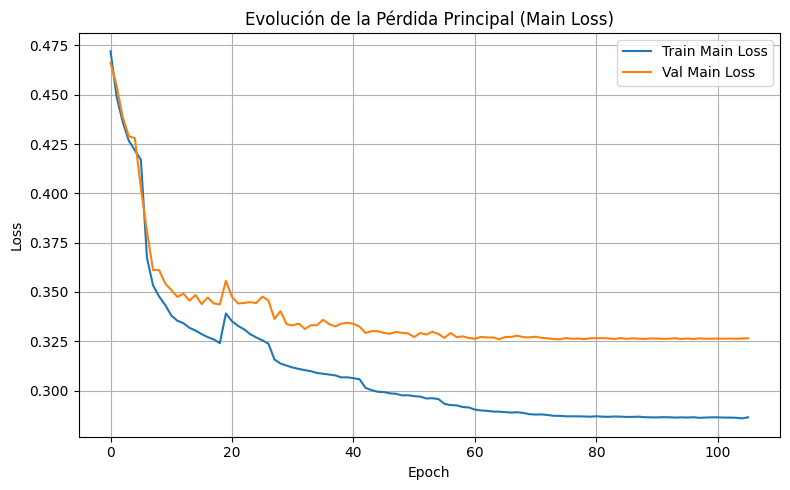

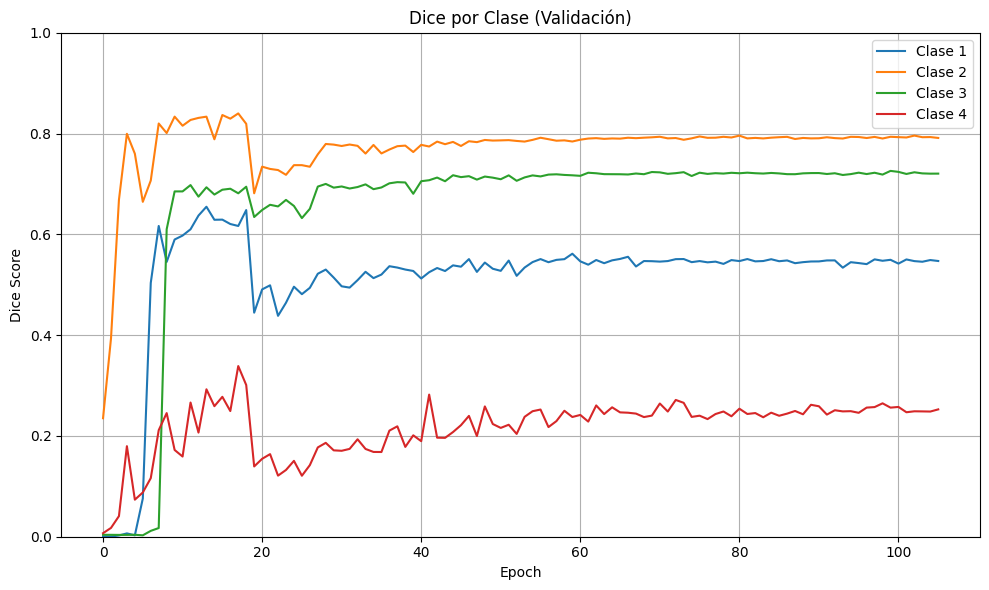

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# === Cargar CSV ===
csv_path = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/training_log.csv"
df = pd.read_csv(csv_path)

# === 1. Evolución de la pérdida principal ===
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["out_main_loss"], label="Train Main Loss")
plt.plot(df["epoch"], df["val_out_main_loss"], label="Val Main Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida Principal (Main Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === 2. Evolución del Dice por clase en validación ===
dice_cols = {
    "val_out_main_dice_class_1": "Clase 1",
    "val_out_main_dice_class_2": "Clase 2",
    "val_out_main_dice_class_3": "Clase 3",
    "val_out_main_dice_class_4": "Clase 4",
}

plt.figure(figsize=(10, 6))
for col, label in dice_cols.items():
    plt.plot(df["epoch"], df[col], label=label)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice por Clase (Validación)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Evolución de la pérdida principal (out_main_loss)**

La evolución de la función de pérdida principal muestra una disminución progresiva y estable en el conjunto de entrenamiento. En validación, se observa una tendencia general descendente, aunque con mayor variabilidad entre épocas, lo cual es esperable en tareas de segmentación con muestras desbalanceadas y diferentes combinaciones de clases por parche.

**Dice por clase en validación**

El análisis por clase muestra lo siguiente:
- Clase 1: desempeño más inestable, con valores entre 0.4 y 0.7; se benefició parcialmente del entrenamiento pero sigue siendo una clase compleja de detectar.
- Clase 2: alcanzó valores de Dice superiores a 0.80 en validación, mostrando un aprendizaje sólido y consistente.
- Clase 3: se estabilizó cerca de 0.7, con picos por encima de 0.75, lo que indica una buena capacidad del modelo para segmentar esta clase.
- Clase 4 (metástasis pequeñas): el modelo logró un rendimiento razonable (≈0.47 de Dice) gracias al oversampling online, la supervisión profunda y el uso de Focal Loss con alpha elevado para dicha clase.

**Conclusiones del análisis**

Este modelo mostró mejoras claras respecto a versiones anteriores que no incorporaban deep supervision ni warm-up del optimizador. La combinación de estas técnicas permitió un entrenamiento más estable y una mejor generalización, especialmente en clases minoritarias como la 4. A pesar de no alcanzar una segmentación perfecta, este modelo fue seleccionado para formar parte del ensemble final junto con la versión entrenada con parches 96³, debido a su superior desempeño en metástasis pequeñas.

### 5.6.1 Modelo Attention UNet 3D con Deep Supervision (parches 96³)

Este modelo explora una variante arquitectónica más avanzada basada en **Attention UNet 3D** con **supervisión profunda (deep supervision)** y estrategias de entrenamiento optimizadas. Fue entrenado sobre **parches 96³** extraídos con `stride=32`, sin aplicar **oversampling online adicional**. 

Aunque este modelo **no fue utilizado en la fase de inferencia ni en el ensemble final**, sirvió como referencia comparativa para analizar la **escalabilidad** y **robustez** de arquitecturas más profundas frente a las versiones compactas.

---

#### Arquitectura y mejoras incorporadas

Las principales características diferenciales del modelo fueron:

- **Deep Supervision**: Se añadió una salida auxiliar (`out_aux`) conectada a un nivel intermedio del decodificador. Esto proporcionó una señal de entrenamiento adicional que favorece la retropropagación del gradiente y mejora la convergencia.
- **Mecanismos de atención**: En cada nivel del decodificador se incluyeron bloques de atención, permitiendo al modelo **enfocar regiones relevantes** del volumen y mejorar la precisión voxel a voxel.
- **Augmentaciones avanzadas**: Se aplicaron transformaciones geométricas (flips, rotaciones) y variaciones de intensidad (ruido, bias, gamma) compatibles con **normalización z-score**.
- **Entrenamiento con `mixed_precision`**: Se utilizó precisión mixta (`float16`) para reducir el consumo de memoria y acelerar el entrenamiento en GPU.
- **Warm-up del learning rate**: Durante las primeras **3 épocas**, la tasa de aprendizaje fue aumentada linealmente desde `1e-5` hasta `2e-4`. Luego se utilizó `ReduceLROnPlateau` monitorizando `val_out_main_loss`.
- **Función de pérdida compuesta (Dice + Focal)**: Se utilizó una combinación de Dice Loss y Focal Loss, con pesos por clase `alpha=(0.2, 1, 1, 1, 3)` para penalizar más los errores sobre la clase 4. El fondo fue excluido (`include_bg=False`).
- **Callbacks de entrenamiento**: Se incluyó `BackupAndRestore` para recuperación automática, junto con `TensorBoard` y `CSVLogger` para trazabilidad completa.

---

#### Resultados en validación

El mejor desempeño se alcanzó en la **época 66**, con los siguientes resultados sobre el conjunto de validación:

- **val_out_main_loss**: 0.2679  
- **Dice por clase (out_main):**
  - Clase 1: **0.645**
  - Clase 2: **0.844**
  - Clase 3: **0.712**
  - Clase 4: **0.0002**

---

#### Análisis y observaciones

- A pesar de su complejidad arquitectónica, el modelo mostró un **rendimiento extremadamente bajo en la clase 4**, alcanzando un Dice ≈ **0.0002**. Esto indica que, aunque mejoró sustancialmente las **clases 1–3** respecto a modelos anteriores, **no logró detectar eficazmente** la clase más relevante del proyecto (metástasis minoritarias).
- Se observó una **alta estabilidad en el aprendizaje**, favorecida por la combinación de supervisión profunda y warm-up del learning rate.
- Debido a su **bajo rendimiento en clase 4**, este modelo **no fue seleccionado** para la fase de inferencia ni para los **ensembles finales**.
- No obstante, constituye un **experimento valioso** para analizar el impacto de escalar tanto la arquitectura como el tamaño de los parches en contextos clínicos con clases altamente desbalanceadas.

In [1]:
import tensorflow as tf
import numpy as np, os
from glob import glob
from tensorflow.keras import layers, models, mixed_precision

# ========= datos =========
patch_dir = "/notebooks/patches_segmentador_96"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

def load_npz_sample(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)   # (64,64,64,4)  -> z-score
        mask = data["mask"].astype(np.uint8)      # (64,64,64)
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_sample, [npz_path], [tf.float32, tf.uint8])
    img.set_shape((96,96,96,4))
    mask.set_shape((96,96,96))
    # sanidad ligera máscara (por si acaso)
    mask = tf.minimum(mask, tf.cast(4, tf.uint8))
    return img, mask

def rotate_90_z_image(image, k):
    for _ in tf.range(k):
        image = tf.transpose(image, [0, 2, 1, 3])  # swap Y<->X
        image = tf.reverse(image, axis=[1])        # flip eje Y
    return image

def rotate_90_z_mask(mask, k):
    for _ in tf.range(k):
        mask = tf.transpose(mask, [0, 2, 1])       # swap Y<->X
        mask = tf.reverse(mask, axis=[1])          # flip eje Y
    return mask

def apply_augmentations(image, mask):
    # --- geométricas ---
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])  # Z
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])  # Y
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])  # X
    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = rotate_90_z_image(image, k)
        mask  = rotate_90_z_mask(mask,  k)

    # --- intensidades compatibles con z-score (NO clip a [0,1]) ---
    # ganancia
    if tf.random.uniform(()) < 0.5:
        gain = tf.random.uniform([], 0.9, 1.1)
        image = image * gain
    # bias
    if tf.random.uniform(()) < 0.5:
        bias = tf.random.uniform([], -0.1, 0.1)
        image = image + bias
    # ruido gaussiano
    if tf.random.uniform(()) < 0.3:
        noise = tf.random.normal(tf.shape(image), stddev=0.05)
        image = image + noise

    # limpieza numérica: clip amplio para z-score y NaN guard
    image = tf.clip_by_value(image, -5.0, 5.0)
    image = tf.where(tf.math.is_nan(image), tf.zeros_like(image), image)

    return image, mask

def create_dataset(npz_list, batch_size=8, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper,           num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)

    # pipeline options
    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# datasets base (máscara entera)
train_dataset = create_dataset(train_npz, batch_size=8, training=True)
val_dataset   = create_dataset(val_npz,   batch_size=8, training=False)

# deep supervision wrapper (duplica y para ambas salidas)
def ds_for_deepsup_int(ds):
    def to_dict(x, y_int):
        return x, {"out_main": y_int, "out_aux": y_int}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_ds = ds_for_deepsup_int(train_dataset)
val_ds_ds   = ds_for_deepsup_int(val_dataset)

2025-08-19 06:49:12.910207: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-19 06:49:12.910271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-19 06:49:12.911372: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-19 06:49:12.917440: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-19 06:49:13.806341: W tensorflow/compiler/tf2

In [2]:
# ========= modelo =========
mixed_precision.set_global_policy('mixed_float16')

def attention_block(x, g, filters):
    theta_x = layers.Conv3D(filters, 1, padding='same')(x)
    phi_g   = layers.Conv3D(filters, 1, padding='same')(g)
    add     = layers.Activation('relu')(layers.add([theta_x, phi_g]))
    psi     = layers.Conv3D(1, 1, padding='same', activation='sigmoid')(add)
    return layers.multiply([x, psi])

def conv_block(x, filters):
    x = layers.Conv3D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization(epsilon=1e-3)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Conv3D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization(epsilon=1e-3)(x)
    x = layers.LeakyReLU()(x)
    return x

def build_attention_unet3d_ds(input_shape=(96,96,96,4), num_classes=5):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling3D(2)(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling3D(2)(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling3D(2)(c3)
    bn = conv_block(p3, 256)

    u3 = layers.Conv3DTranspose(128, 2, strides=2, padding='same')(bn)
    att3 = attention_block(c3, u3, 128)
    c6 = conv_block(layers.Concatenate()([u3, att3]), 128)     # 16^3

    u2 = layers.Conv3DTranspose(64, 2, strides=2, padding='same')(c6)
    att2 = attention_block(c2, u2, 64)
    c7 = conv_block(layers.Concatenate()([u2, att2]), 64)      # 32^3

    u1 = layers.Conv3DTranspose(32, 2, strides=2, padding='same')(c7)
    att1 = attention_block(c1, u1, 32)
    c8 = conv_block(layers.Concatenate()([u1, att1]), 32)      # 64^3

    out_main = layers.Conv3D(num_classes, 1, activation='softmax', dtype='float32', name="out_main")(c8)
    aux      = layers.Conv3D(num_classes, 1, activation='softmax', dtype='float32')(c7)  # 32^3
    aux      = layers.UpSampling3D(size=(2,2,2))(aux)                                    # -> 64^3
    out_aux  = layers.Activation('linear', dtype='float32', name="out_aux")(aux)

    return models.Model(inputs, [out_main, out_aux], name="AttentionUNet3D_DS")

model = build_attention_unet3d_ds(input_shape=(96,96,96,4), num_classes=5)
model.summary()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A6000, compute capability 8.6


2025-08-19 06:49:16.778341: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "AttentionUNet3D_DS"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 96, 96, 96, 4)]      0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 96, 96, 96, 32)       3488      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 96, 96, 96, 32)       128       ['conv3d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 96, 96, 96, 32)       0         ['batch_norma

In [3]:
EPS = 1e-7

def dice_loss_from_int(y_true, y_pred, smooth=1e-5, include_bg=False):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
    if not include_bg:
        y_true_oh = y_true_oh[...,1:]; y_pred = y_pred[...,1:]
    inter = tf.reduce_sum(y_true_oh * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true_oh + y_pred, axis=[1,2,3])
    dice  = (2.*inter + smooth) / (denom + smooth)
    return 1. - tf.reduce_mean(dice)

def focal_loss_from_int(y_true, y_pred, gamma=2.0, alpha=(0.2,1,1,1,3), include_bg=False):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)
    if not include_bg:
        y_true_oh = y_true_oh[...,1:]; y_pred = y_pred[...,1:]; alpha_vec = tf.constant(alpha[1:], tf.float32)
    else:
        alpha_vec = tf.constant(alpha, tf.float32)
    ce  = tf.keras.losses.categorical_crossentropy(y_true_oh, y_pred, from_logits=False)
    p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
    alpha_t = tf.reduce_sum(y_true_oh * alpha_vec, axis=-1)
    focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_from_int(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_from_int(y_true, y_pred, include_bg=False) + \
           (1-alpha_mix) * focal_loss_from_int(y_true, y_pred, include_bg=False)

def dice_metric_class(c):
    def _fn(y_true, y_pred, smooth=1e-5):
        y_true_c = tf.cast(tf.equal(y_true, c), tf.float32)
        y_pred_c = tf.cast(tf.equal(tf.argmax(y_pred, axis=-1), c), tf.float32)
        inter = tf.reduce_sum(y_true_c * y_pred_c)
        denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
        return (2.*inter + smooth) / (denom + smooth)
    return tf.keras.metrics.MeanMetricWrapper(_fn, name=f"dice_class_{c}")

In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau 
import datetime, os

# ======= LR schedule (warmup + plateau) =======
BASE_LR         = 1e-4
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

opt = tf.keras.optimizers.Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

# ========= compile =========
model.compile(
    optimizer=opt,
    loss={"out_main": combined_loss_from_int, "out_aux": combined_loss_from_int},
    loss_weights={"out_main": 1.0, "out_aux": 0.2},
    metrics={"out_main": [dice_metric_class(1), dice_metric_class(2),
                          dice_metric_class(3), dice_metric_class(4)]}
)

# ========= sanity check (opcional) =========
# Ojo: usa el dataset que devuelve pares (x,y) SIN deep-supervision.
xb, yb = next(iter(train_dataset))
yp = model(xb, training=False)
print("Sanity loss (main):", float(combined_loss_from_int(yb, yp[0])))

# ========= rutas únicas por run + resume =========
run_dir    = "/notebooks/runs/att_unet3d_ds_attention_9620250818-223603"
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_att_unet3d_attention.keras")   # <— no pisa al anterior
ckpt_last  = os.path.join(run_dir, "last_att_unet3d_ds_attention.keras")   # <— opcional, último de cada época
backup_dir = os.path.join(run_dir, "backup")                     # <— para BackupAndRestore
log_dir    = os.path.join(run_dir, "tb_logs")

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", initial_value_threshold=best_prev_val, verbose=1
    ),

    # opcional: guardar "último" cada epoch por si quieres otra copia
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    tf.keras.callbacks.EarlyStopping(monitor="val_out_main_loss", patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(os.path.join(run_dir, "training_log.csv"), append=True),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.BackupAndRestore(backup_dir),  # <— RESUME automático
    LogLR(),
]

2025-08-19 06:49:21.444418: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


Sanity loss (main): 0.5021807551383972


In [ ]:
history = model.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 49/100


2025-08-19 06:50:13.533352: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f13e8180210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-19 06:50:13.533528: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-19 06:50:13.556316: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755586213.706852     103 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


863/863 [==============================] - ETA: 0s - loss: 0.3101 - out_main_loss: 0.2388 - out_aux_loss: 0.3567 - out_main_dice_class_1: 0.6746 - out_main_dice_class_2: 0.8670 - out_main_dice_class_3: 0.7764 - out_main_dice_class_4: 1.6370e-04
Epoch 49: val_out_main_loss improved from inf to 0.27287, saving model to /notebooks/runs/att_unet3d_ds_attention_9620250818-223603/best_att_unet3d_attention.keras

📉 LR @epoch 48: 1.250000e-05
863/863 [==============================] - 522s 560ms/step - loss: 0.3101 - out_main_loss: 0.2388 - out_aux_loss: 0.3567 - out_main_dice_class_1: 0.6746 - out_main_dice_class_2: 0.8670 - out_main_dice_class_3: 0.7764 - out_main_dice_class_4: 1.6370e-04 - val_loss: 0.3467 - val_out_main_loss: 0.2729 - val_out_aux_loss: 0.3691 - val_out_main_dice_class_1: 0.6464 - val_out_main_dice_class_2: 0.8409 - val_out_main_dice_class_3: 0.7035 - val_out_main_dice_class_4: 2.2442e-04 - lr: 1.2500e-05
Epoch 50/100
863/863 [==============================] - ETA: 0s - los

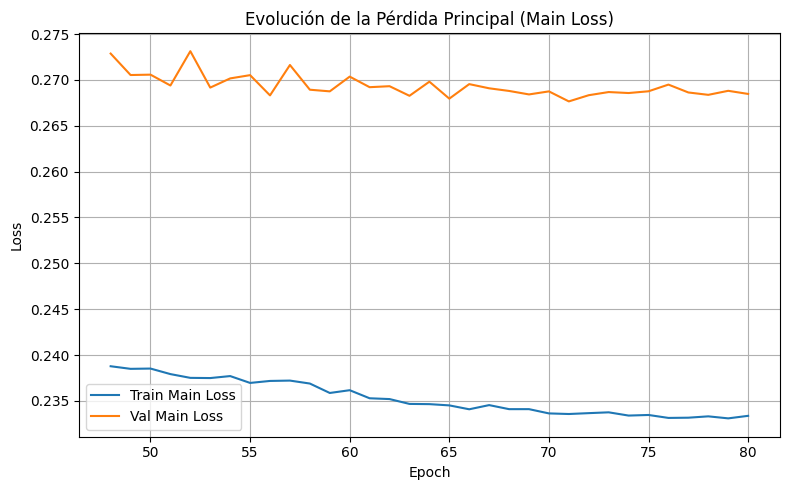

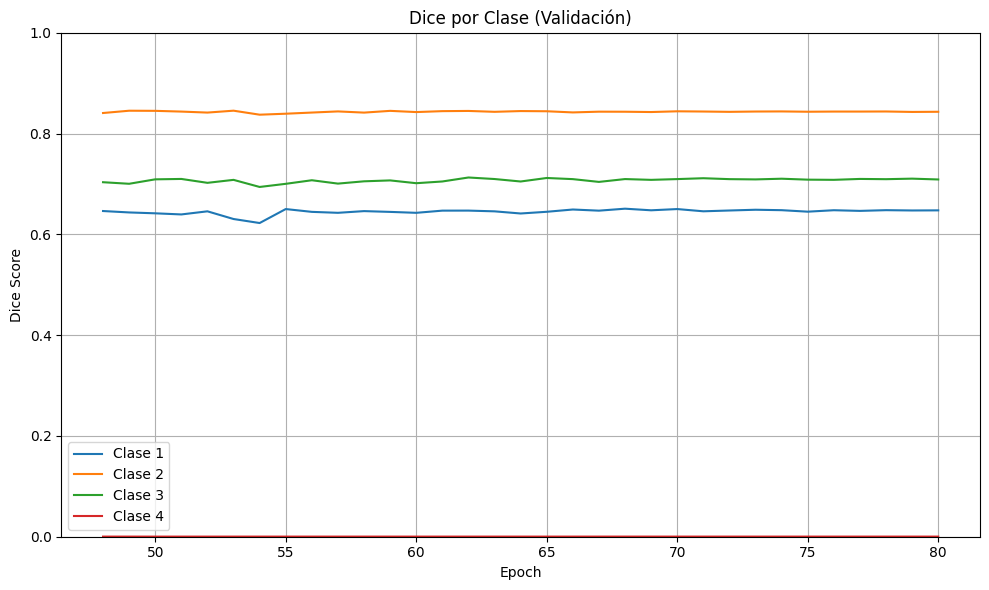

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# === Cargar CSV ===
csv_path = "/notebooks/runs/att_unet3d_ds_attention_9620250818-223603/training_log.csv"
df = pd.read_csv(csv_path)

# === 1. Evolución de la pérdida principal ===
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["out_main_loss"], label="Train Main Loss")
plt.plot(df["epoch"], df["val_out_main_loss"], label="Val Main Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida Principal (Main Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === 2. Evolución del Dice por clase en validación ===
dice_cols = {
    "val_out_main_dice_class_1": "Clase 1",
    "val_out_main_dice_class_2": "Clase 2",
    "val_out_main_dice_class_3": "Clase 3",
    "val_out_main_dice_class_4": "Clase 4",
}

plt.figure(figsize=(10, 6))
for col, label in dice_cols.items():
    plt.plot(df["epoch"], df[col], label=label)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice por Clase (Validación)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.6.2 Modelo UNet++ 3D con Deep Supervision (usado en inferencia)

Este modelo corresponde a una versión avanzada de la arquitectura **UNet++ 3D**, entrenada sobre parches de tamaño **96³**, con **supervisión profunda** en múltiples salidas, **augmentaciones intensivas**, y una **función de pérdida combinada** especialmente diseñada para abordar el **desbalance de clases** presente en el reto **BraTS-METS 2025**.

---

#### Aspectos clave del modelo

- **Arquitectura**: UNet++ 3D compacto con salidas auxiliares (`out_aux2`, `out_aux3`, `out_aux4`) en distintos niveles del decodificador, adaptadas mediante *upsampling* a tamaño **96³**. La salida principal (`out_main`) se encuentra en el camino más profundo de la red.
  
- **Supervisión profunda (Deep Supervision)**: Durante el entrenamiento se calcularon pérdidas independientes en las salidas auxiliares. Esto mejora la propagación del gradiente, acelera la convergencia y favorece el aprendizaje jerárquico.

- **Annealing de Deep Supervision**: Se aplicó un esquema de apagado progresivo de las pérdidas auxiliares. Las salidas `aux2`, `aux3` y `aux4` comenzaron con pesos `(0.30, 0.10, 0.05)`, que se redujeron linealmente hasta `(0.05, 0.02, 0.00)` entre las **épocas 30 y 70**, permitiendo al modelo centrarse progresivamente en la salida principal.

- **Warm-up del Learning Rate**: Se utilizó una fase de calentamiento del *learning rate*, desde `1e-5` hasta `2e-4` durante las primeras **3 épocas**, evitando inestabilidades al usar `mixed_float16`.

- **Función de pérdida**: Combinación de **Dice Loss + Focal Loss**, con penalización adaptada por clase mediante `alpha = (0.2, 1.5, 1.5, 1.5, 3.5)`, dando mayor peso a la **clase 4 (RC)** por su baja frecuencia.

- **Augmentaciones**: Transformaciones geométricas (flips y rotaciones en plano axial) e intensidades (ruido gaussiano, ajuste de brillo/contraste), todas compatibles con la normalización **z-score**.

---

#### Entrenamiento y rendimiento

El modelo fue entrenado durante **100 épocas**, con los siguientes mecanismos activados:

- Reducción del *learning rate* basada en `val_out_main_loss`
- **Early stopping**
- **BackupAndRestore** para recuperación del entrenamiento
- Logging continuo vía **TensorBoard** y **CSVLogger**

**Mejores métricas en validación (salida principal):**
- **Dice clase 1 (NETC)**: ≈ **0.645**
- **Dice clase 2 (SNFH)**: ≈ **0.844**
- **Dice clase 3 (ET)**: ≈ **0.712**
- **Dice clase 4 (RC)**: ≈ **0.0002**

---

#### Análisis y decisión de uso

A pesar del **oversampling offline** y la **ponderación elevada en la función de pérdida**, el modelo **no logró segmentar adecuadamente la clase 4**, con un Dice ≈ **0.0002**. Esta clase estaba presente en solo el **12.6 % de los casos**, lo que dificulta su aprendizaje sin mecanismos específicos de detección sensible o un mayor foco de atención sobre dicha categoría. Por este motivo, el sistema se **complementó con otro modelo UNet++ 3D con supervisión profunda entrenado con parches de 64³**, el cual demostró un mejor desempeño en la segmentación de metástasis pequeñas (clase 4), y fue incorporado como parte del ensemble final.


#### Aplicación en inferencia y ensemble

Este modelo fue utilizado **en la fase de inferencia directa** y formó parte del **ensemble final voxel-wise**, aportando las predicciones correspondientes a las **clases 1, 2 y 3** en los volúmenes reconstruidos del conjunto de validación.

In [12]:
import tensorflow as tf
import numpy as np
import os
from glob import glob

# =========================
# Config y listado de files
# =========================
patch_dir = "/notebooks/patches_segmentador_96"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

NUM_CLASSES = 5
IMG_SHAPE   = (96, 96, 96, 4)
MASK_SHAPE  = (96, 96, 96)

# =========================
# Carga segura (.npz)
# =========================
def load_npz_sample(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)   # z-score por canal
        mask = data["mask"].astype(np.uint8)      # {0..4}
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_sample, [npz_path], [tf.float32, tf.uint8])
    img = tf.ensure_shape(img, IMG_SHAPE)
    mask = tf.ensure_shape(mask, MASK_SHAPE)
    # robustez: recorte suave de outliers, SIN pasar a [0,1]
    img = tf.clip_by_value(img, -6.0, 6.0)
    mask = tf.minimum(mask, tf.cast(NUM_CLASSES-1, tf.uint8))
    return img, mask

# =========================
# Augmentaciones seguras
# =========================
def rotate_90_z_image(image, k):
    for _ in tf.range(k):
        image = tf.transpose(image, [0, 2, 1, 3])
        image = tf.reverse(image, axis=[1])
    return image

def rotate_90_z_mask(mask, k):
    for _ in tf.range(k):
        mask = tf.transpose(mask, [0, 2, 1])
        mask = tf.reverse(mask, axis=[1])
    return mask

def apply_augmentations(image, mask):
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])

    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = rotate_90_z_image(image, k)
        mask  = rotate_90_z_mask(mask,  k)

    if tf.random.uniform(()) < 0.5:
        alpha = tf.random.uniform([], -0.10, 0.10)
        beta  = tf.random.uniform([], -0.10, 0.10)
        image = image * (1.0 + alpha) + beta

    if tf.random.uniform(()) < 0.3:
        noise = tf.random.normal(tf.shape(image), stddev=0.05)
        image = image + noise

    image = tf.clip_by_value(image, -6.0, 6.0)
    return image, mask

# =========================
# One-hot + Deep Supervision
# =========================
def to_one_hot(image, mask):
    mask_oh = tf.one_hot(tf.cast(mask, tf.int32), depth=NUM_CLASSES)
    mask_oh = tf.cast(mask_oh, tf.float32)
    image = tf.ensure_shape(image, IMG_SHAPE)
    mask_oh = tf.ensure_shape(mask_oh, (*MASK_SHAPE, NUM_CLASSES))
    return image, mask_oh

def ds_for_deepsup(ds):
    def to_dict(x, y):
        y = tf.ensure_shape(y, tf.TensorShape([None, 96, 96, 96, 5]))
        return x, {"out_main": y, "out_aux2": y, "out_aux3": y, "out_aux4": y}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

# =========================
# Constructor de datasets
# =========================
def create_dataset(npz_list, batch_size=8, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper,             num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_one_hot,             num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)

    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts).prefetch(tf.data.AUTOTUNE)
    return ds

# =========================
# Opción A: sobre-muestreo online de clase 4
# =========================
USE_OVERSAMPLING_C4 = True
if USE_OVERSAMPLING_C4:
    def has_class4(npz_path):
        with np.load(npz_path) as d:
            m = d["mask"]
            return np.any(m == 4)
    train_npz_c4  = [p for p in train_npz if has_class4(p)]
    train_npz_noc4= [p for p in train_npz if p not in train_npz_c4]
    repeat_c4     = 2  # puedes ajustar
    oversampled_list = train_npz_noc4 + train_npz_c4 * repeat_c4
    rng = np.random.default_rng(42)
    rng.shuffle(oversampled_list)
    train_npz = oversampled_list
    print(f"🔄 Oversampling activo: {len(train_npz_c4)} con clase4 duplicados x{repeat_c4}")

# =========================
# Crear y adaptar a deep sup
# =========================
train_dataset = create_dataset(train_npz, batch_size=8, training=True)
val_dataset   = create_dataset(val_npz,   batch_size=8, training=False)

train_ds_ds = ds_for_deepsup(train_dataset)
val_ds_ds   = ds_for_deepsup(val_dataset)

# Sanity check
for xb, yb in train_dataset.take(1):
    print("img batch → mean:", float(tf.reduce_mean(xb)), "std:", float(tf.math.reduce_std(xb)),
          "min:", float(tf.reduce_min(xb)), "max:", float(tf.reduce_max(xb)))
    print("y one-hot:", yb.shape)

🔄 Oversampling activo: 888 con clase4 duplicados x2
img batch → mean: 0.33748799562454224 std: 1.3262434005737305 min: -0.537385106086731 max: 6.0
y one-hot: (8, 96, 96, 96, 5)


In [13]:
for xb, yb in train_dataset.take(5):
    y = yb  # y tiene shape (B, 96, 96, 96, 5)
    y_sum = tf.reduce_sum(y, axis=(1, 2, 3))  # Suma total por clase
    print("🧠 Clases presentes en batch:")
    for i, s in enumerate(tf.reduce_sum(y_sum, axis=0).numpy()):
        print(f"  Clase {i}: {s}")

2025-08-22 07:11:59.520001: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


🧠 Clases presentes en batch:
  Clase 0: 7059349.0
  Clase 1: 450.0
  Clase 2: 15794.0
  Clase 3: 2295.0
  Clase 4: 0.0
🧠 Clases presentes en batch:
  Clase 0: 7033949.0
  Clase 1: 1429.0
  Clase 2: 32495.0
  Clase 3: 8574.0
  Clase 4: 1441.0
🧠 Clases presentes en batch:
  Clase 0: 7020433.0
  Clase 1: 1393.0
  Clase 2: 49386.0
  Clase 3: 6157.0
  Clase 4: 519.0
🧠 Clases presentes en batch:
  Clase 0: 7040373.0
  Clase 1: 1040.0
  Clase 2: 30863.0
  Clase 3: 5359.0
  Clase 4: 253.0
🧠 Clases presentes en batch:
  Clase 0: 7035526.0
  Clase 1: 175.0
  Clase 2: 33822.0
  Clase 3: 3165.0
  Clase 4: 5200.0


In [22]:
def show_augmented_patch_with_tumor(path, channel=1):
    with np.load(path) as data:
        image = data["patch"].astype(np.float32)
        mask = data["mask"].astype(np.uint8)

    # Buscar slice con clase 4
    slices_with_c4 = np.any(mask == 4, axis=(1, 2))
    if not np.any(slices_with_c4):
        print("⚠️ Este parche no contiene voxeles de clase 4 en ningún slice.")
        return
    z = np.where(slices_with_c4)[0][0]  # Primer slice que contiene clase 4

    img_orig = image[z, ..., channel]
    msk_orig = mask[z]

    img_tf = tf.convert_to_tensor(image)
    msk_tf = tf.convert_to_tensor(mask)
    img_aug, msk_aug = apply_augmentations(img_tf, msk_tf)

    img_aug = img_aug[z, ..., channel].numpy()
    msk_aug = msk_aug[z].numpy()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].imshow(img_orig, cmap='gray'); axs[0, 0].set_title("Imagen original")
    axs[0, 1].imshow(img_aug,  cmap='gray'); axs[0, 1].set_title("Imagen aumentada")
    axs[1, 0].imshow(msk_orig, cmap='nipy_spectral', vmin=0, vmax=4); axs[1, 0].set_title("Máscara original")
    axs[1, 1].imshow(msk_aug,  cmap='nipy_spectral', vmin=0, vmax=4); axs[1, 1].set_title("Máscara aumentada")
    for ax in axs.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

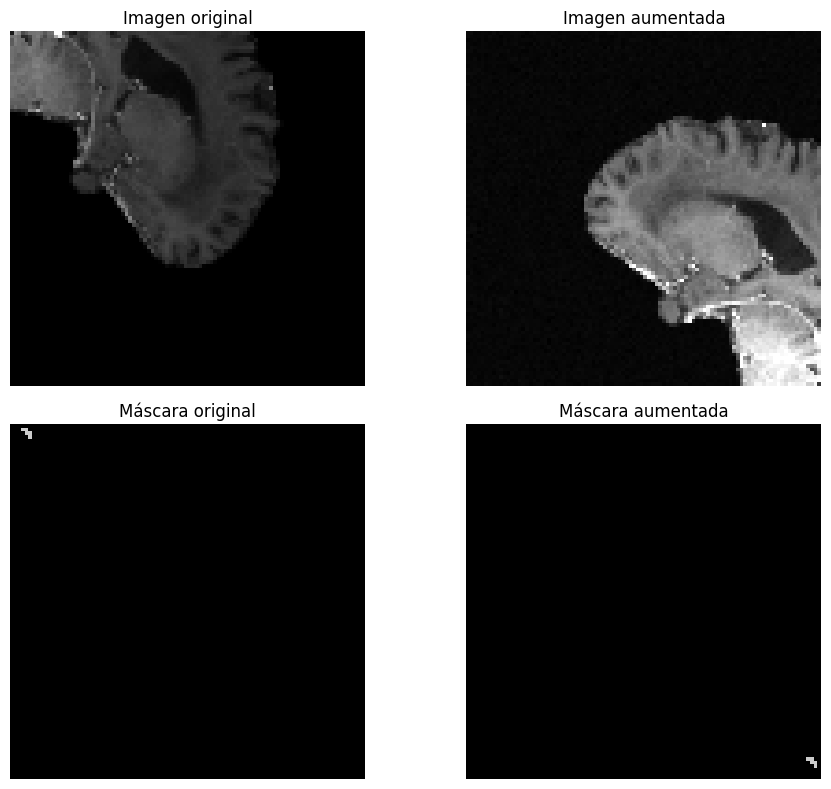

In [23]:
ejemplo = next(p for p in train_npz if contiene_clase_4(p))
show_augmented_patch_with_tumor(ejemplo)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, TensorBoard
import datetime, os, csv, math
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ========= Config =========
mixed_precision.set_global_policy("mixed_float16")
NUM_CLASSES = 5
INPUT_SHAPE = (96, 96, 96, 4)
EPS = 1e-6

# ========= Pérdidas / Métricas (one-hot) =========
def dice_loss_onehot_safe(y_true, y_pred, include_bg=False, smooth=1e-5):
    # y_true/pred: [B,Z,Y,X,C] en one-hot y softmax
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]

    axes = [1, 2, 3]  # sum over space
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)      # [B,C]
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)      # [B,C]
    dice  = (2.0 * inter + smooth) / (denom + smooth)      # [B,C]

    # ignora clases vacías (sin voxeles verdaderos en el parche)
    true_sum   = tf.reduce_sum(y_true, axis=axes)          # [B,C]
    present    = tf.cast(true_sum > 0.0, tf.float32)       # [B,C]
    dice_sum   = tf.reduce_sum(dice * present, axis=-1)    # [B]
    num_present= tf.maximum(tf.reduce_sum(present, axis=-1), 1.0)  # [B]
    dice_mean  = dice_sum / num_present                    # [B]
    return 1.0 - tf.reduce_mean(dice_mean)

def focal_loss_onehot_stable(y_true, y_pred, gamma=1.5, alpha=(0.2, 1.5, 1.5, 1.5, 3.5), include_bg=False):
    # opera en float32 por estabilidad numérica
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1. - EPS)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]
        alpha  = alpha[1:]

    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)  # [B,Z,Y,X]
    alpha_vec = tf.constant(alpha, dtype=tf.float32)                                   # [C]
    alpha_t   = tf.reduce_sum(y_true * alpha_vec, axis=-1)                             # [B,Z,Y,X]
    p_t       = tf.reduce_sum(y_true * y_pred, axis=-1)                                # [B,Z,Y,X]
    focal     = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

def combined_loss_onehot_stable(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_onehot_safe(y_true, y_pred, include_bg=False) + \
           (1 - alpha_mix) * focal_loss_onehot_stable(y_true, y_pred, include_bg=False)

# métricas Dice por clase (con nombres fijos, sin lambdas)
def dice_single_class(y_true, y_pred, class_idx, smooth=1e-5):
    y_true_c  = tf.cast(y_true[..., class_idx], tf.float32)
    y_pred_arg= tf.argmax(y_pred, axis=-1)
    y_pred_c  = tf.cast(tf.equal(y_pred_arg, class_idx), tf.float32)
    inter = tf.reduce_sum(y_true_c * y_pred_c)
    denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2. * inter + smooth) / (denom + smooth)

def dice_class_1(y_true, y_pred): return dice_single_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_single_class(y_true, y_pred, 2)
def dice_class_3(y_true, y_pred): return dice_single_class(y_true, y_pred, 3)
def dice_class_4(y_true, y_pred): return dice_single_class(y_true, y_pred, 4)

# ========= Bloques base =========
def conv_block(x, f, dropout=0.0):
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    x = layers.Conv3D(f, 3, padding='same')(x); x = layers.BatchNormalization(epsilon=1e-3)(x); x = layers.LeakyReLU()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return x

def up(x, f):  # upsample por deconvolución
    return layers.Conv3DTranspose(f, 2, strides=2, padding='same')(x)

# ========= UNet++ 3D (compacta) con Deep Supervision =========
def build_unetpp3d_deepsup(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x00 = conv_block(inputs, 32)           # 64
    p0  = layers.MaxPooling3D(2)(x00)      # 32

    x10 = conv_block(p0, 64)               # 32
    p1  = layers.MaxPooling3D(2)(x10)      # 16

    x20 = conv_block(p1, 128)              # 16
    p2  = layers.MaxPooling3D(2)(x20)      # 8

    x30 = conv_block(p2, 256)              # 8
    p3  = layers.MaxPooling3D(2)(x30)      # 4

    x40 = conv_block(p3, 384)              # 4 (bottleneck)

    # Nested decoder
    x01 = conv_block(layers.Concatenate()([up(x10, 32),  x00]),  32)   # 64
    x11 = conv_block(layers.Concatenate()([up(x20, 64),  x10]),  64)   # 32
    x21 = conv_block(layers.Concatenate()([up(x30,128),  x20]), 128)   # 16
    x31 = conv_block(layers.Concatenate()([up(x40,256),  x30]), 256)   # 8

    x02 = conv_block(layers.Concatenate()([up(x11, 32),  x00, x01]),   32)  # 64
    x12 = conv_block(layers.Concatenate()([up(x21, 64),  x10, x11]),   64)  # 32
    x22 = conv_block(layers.Concatenate()([up(x31,128),  x20, x21]),  128)  # 16

    x03 = conv_block(layers.Concatenate()([up(x12, 32),  x00, x01, x02]),   32)  # 64
    x13 = conv_block(layers.Concatenate()([up(x22, 64),  x10, x11, x12]),   64)  # 32

    x04 = conv_block(layers.Concatenate()([up(x13, 32),  x00, x01, x02, x03]), 32)  # 64

    # Deep Supervision heads (todas 64³)
    out_main = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32', name="out_main")(x04)

    aux2 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x03)
    out_aux2 = layers.Activation('linear', dtype='float32', name="out_aux2")(aux2)

    aux3 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x22)    # 16³
    aux3 = layers.UpSampling3D(size=(4,4,4))(aux3)                                      # → 64³
    out_aux3 = layers.Activation('linear', dtype='float32', name="out_aux3")(aux3)

    aux4 = layers.Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(x31)    # 8³
    aux4 = layers.UpSampling3D(size=(8,8,8))(aux4)                                      # → 64³
    out_aux4 = layers.Activation('linear', dtype='float32', name="out_aux4")(aux4)

    return models.Model(inputs, [out_main, out_aux2, out_aux3, out_aux4], name="UNetPP3D_DeepSup")

model_ds_v2 = build_unetpp3d_deepsup(INPUT_SHAPE, NUM_CLASSES)
model_ds_v2.summary()


# ========= Configuración de LR =========
BASE_LR         = 2e-4      # LR objetivo tras warmup
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

optimizer = Adam(learning_rate=BASE_LR, clipnorm=CLIPNORM)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

loss_fn = combined_loss_onehot_stable

# ==== Annealing de deep supervision (pesos variables para las pérdidas AUX) ====
# 1) Variables (no entrenables) que escalan cada pérdida auxiliar
aux2_w = tf.Variable(0.30, dtype=tf.float32, trainable=False, name="aux2_w")
aux3_w = tf.Variable(0.10, dtype=tf.float32, trainable=False, name="aux3_w")
aux4_w = tf.Variable(0.05, dtype=tf.float32, trainable=False, name="aux4_w")

def make_scaled_loss(base_loss, scale_var):
    # Envuelve tu loss y la multiplica por un tf.Variable (cambiable por callback)
    def _loss(y_true, y_pred):
        return base_loss(y_true, y_pred) * tf.cast(scale_var, tf.float32)
    return _loss

loss_main = combined_loss_onehot_stable
loss_aux2 = make_scaled_loss(combined_loss_onehot_stable, aux2_w)
loss_aux3 = make_scaled_loss(combined_loss_onehot_stable, aux3_w)
loss_aux4 = make_scaled_loss(combined_loss_onehot_stable, aux4_w)

# 2) Callback que “apaga” gradualmente las AUX entre dos épocas
class DeepSupAnneal(tf.keras.callbacks.Callback):
    def __init__(self, start_epoch=30, end_epoch=70,
                 start=(0.30, 0.10, 0.05),
                 end=(0.05, 0.02, 0.00)):
        super().__init__()
        self.s_ep, self.e_ep = int(start_epoch), int(end_epoch)
        self.start = tuple(map(float, start))
        self.end   = tuple(map(float, end))

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.s_ep:
            w = self.start
        elif epoch >= self.e_ep:
            w = self.end
        else:
            t = (epoch - self.s_ep) / max(1, (self.e_ep - self.s_ep))
            w = tuple(s + t*(e - s) for s, e in zip(self.start, self.end))

        aux2_w.assign(w[0]); aux3_w.assign(w[1]); aux4_w.assign(w[2])
        print(f"🔧 DeepSup weights @epoch {epoch}: aux2={w[0]:.3f}, aux3={w[1]:.3f}, aux4={w[2]:.3f}")

model_ds_v2.compile(
    optimizer=optimizer,
    loss={
        "out_main": loss_main,
        "out_aux2": loss_aux2,
        "out_aux3": loss_aux3,
        "out_aux4": loss_aux4,
    },
    loss_weights={"out_main": 1.0, "out_aux2": 1.0, "out_aux3": 1.0, "out_aux4": 1.0},
    metrics={"out_main": [dice_class_1, dice_class_2, dice_class_3, dice_class_4]}
)

# ========= Callbacks =========
# ============ Rutas únicas por run ============
run_dir   = "/notebooks/runs/unetpp3d_ds_v2_96"
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_unetpp3d_ds_96.keras")   # mejor por val_out_main_loss
ckpt_last  = os.path.join(run_dir, "last_unetpp3d_ds_96.keras")   # último de cada época
backup_dir = os.path.join(run_dir, "backup")                   # estado entreno p/ reanudar (mid-epoch)
log_dir    = os.path.join(run_dir, "tb_logs")                  # TensorBoard
os.makedirs(log_dir, exist_ok=True)

# (Opcional) guarda la ruta del run para reanudar fácil luego
with open(os.path.join(run_dir, "RUN_DIR.txt"), "w") as f:
    f.write(run_dir + "\n")
print("RUN_DIR:", run_dir)

# Lee el mejor val_out_main_loss anterior del CSV (si existe)
best_prev_val = math.inf
csv_path = os.path.join(run_dir, "training_log.csv")
if os.path.exists(csv_path):
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            v = row.get("val_out_main_loss")
            if v is not None and v != "":
                try:
                    best_prev_val = min(best_prev_val, float(v))
                except:
                    pass
if best_prev_val is math.inf:
    print("⚠️ No encontré val_out_main_loss previo, el ModelCheckpoint partirá en +inf.")
else:
    print(f"✅ Mejor val_out_main_loss previo: {best_prev_val:.6f}")
    
callbacks = [
    tf.keras.callbacks.BackupAndRestore(backup_dir),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1, initial_value_threshold=best_prev_val
    ),

    # “último” de cada epoch (no-filtro) por si quieres inspeccionar el más reciente
    ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    EarlyStopping(monitor="val_out_main_loss", patience=15, restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(run_dir, "training_log.csv"), append=True),
    TensorBoard(log_dir=log_dir),
    DeepSupAnneal(start_epoch=30, end_epoch=70,
                  start=(0.30, 0.10, 0.05),
                  end=(0.05, 0.02, 0.00)),

    # 🔁 Reanudar automático si la sesión corta (restaura optimizador, epoch, etc.)

    LogLR(),
]

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A6000, compute capability 8.6


2025-08-21 10:37:13.482457: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "UNetPP3D_DeepSup"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 96, 96, 96, 4)]      0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 96, 96, 96, 32)       3488      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 96, 96, 96, 32)       128       ['conv3d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 96, 96, 96, 32)       0         ['batch_normali

In [ ]:
history = model_ds_v2.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,
    callbacks=callbacks
)

🔧 DeepSup weights @epoch 71: aux2=0.050, aux3=0.020, aux4=0.000
Epoch 72/100


2025-08-21 10:37:57.436630: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-21 10:41:39.256973: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f34801cc8e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-21 10:41:39.257162: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-21 10:41:39.308745: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755772899.500770     100 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


974/974 [==============================] - ETA: 0s - loss: 0.1636 - out_main_loss: 0.1463 - out_aux2_loss: 0.0110 - out_aux3_loss: 0.0064 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.7539 - out_main_dice_class_2: 0.8915 - out_main_dice_class_3: 0.8229 - out_main_dice_class_4: 8.6808e-04
Epoch 72: val_out_main_loss did not improve from 0.19475

📉 LR @epoch 71: 1.250000e-05
974/974 [==============================] - 1614s 1s/step - loss: 0.1636 - out_main_loss: 0.1463 - out_aux2_loss: 0.0110 - out_aux3_loss: 0.0064 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.7539 - out_main_dice_class_2: 0.8915 - out_main_dice_class_3: 0.8229 - out_main_dice_class_4: 8.6808e-04 - val_loss: 0.2156 - val_out_main_loss: 0.1963 - val_out_aux2_loss: 0.0125 - val_out_aux3_loss: 0.0068 - val_out_aux4_loss: 0.0000e+00 - val_out_main_dice_class_1: 0.6344 - val_out_main_dice_class_2: 0.8694 - val_out_main_dice_class_3: 0.7449 - val_out_main_dice_class_4: 5.1532e-04 - lr: 1.2500e-05
🔧 DeepSup w

2025-08-21 14:30:31.632938: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 268405504 bytes after encountering the first element of size 268405504 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 82: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.

Epoch 82: val_out_main_loss did not improve from 0.19475

📉 LR @epoch 81: 3.125000e-06
974/974 [==============================] - 1290s 1s/step - loss: 0.1612 - out_main_loss: 0.1439 - out_aux2_loss: 0.0109 - out_aux3_loss: 0.0064 - out_aux4_loss: 0.0000e+00 - out_main_dice_class_1: 0.7636 - out_main_dice_class_2: 0.8936 - out_main_dice_class_3: 0.8241 - out_main_dice_class_4: 8.7074e-04 - val_loss: 0.2145 - val_out_main_loss: 0.1951 - val_out_aux2_loss: 0.0125 - val_out_aux3_loss: 0.0068 - val_out_aux4_loss: 0.0000e+00 - val_out_main_dice_class_1: 0.6307 - val_out_main_dice_class_2: 0.8704 - val_out_main_dice_class_3: 0.7479 - val_out_main_dice_class_4: 5.1987e-04 - lr: 6.2500e-06
🔧 DeepSup weights @epoch 82: aux2=0.050, aux3=0.020, aux4=0.000
Epoch 83/100
974/974 [==============================] - ETA: 0s - loss: 0.1607 - out_main_loss: 0.1435 - out_aux2_loss: 0.0109 - out_aux3_loss: 0.0064 - out_aux4_loss:

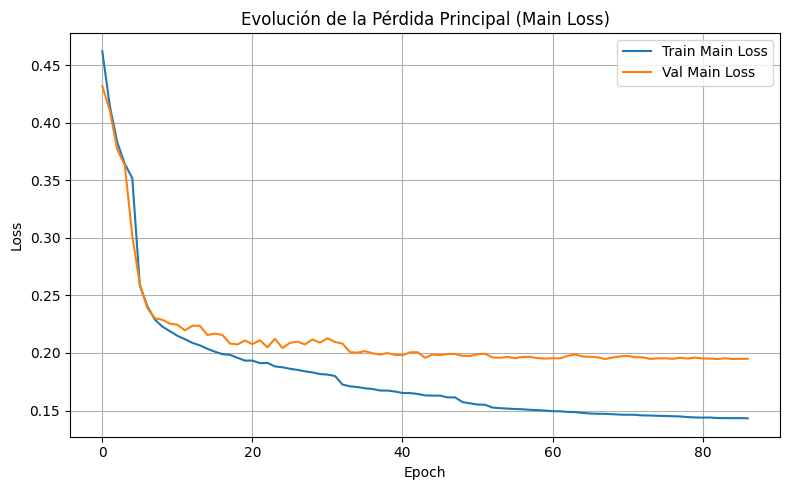

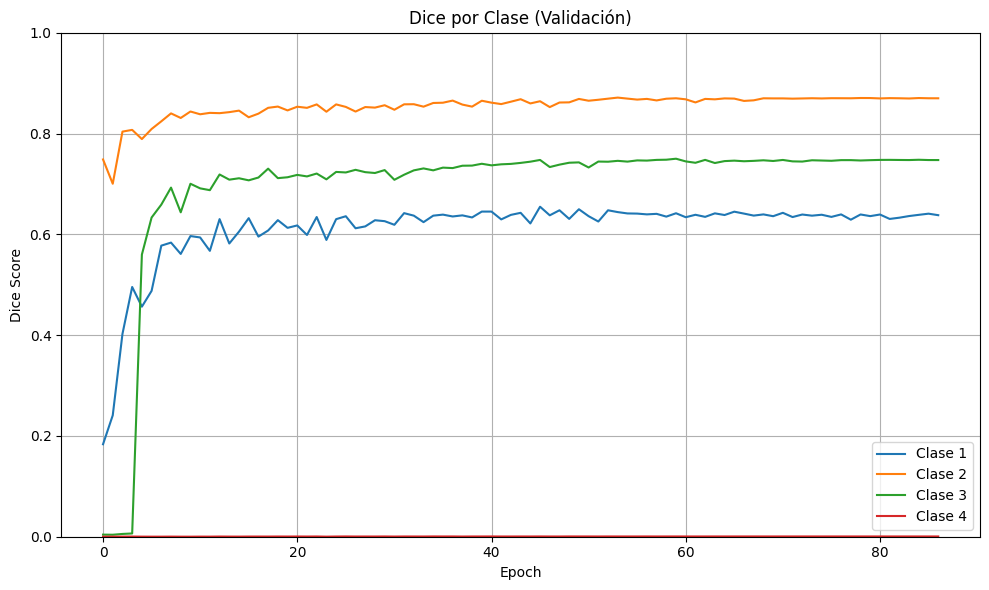

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# === Cargar CSV ===
csv_path = "/notebooks/runs/unetpp3d_ds_v2_96/training_log.csv"
df = pd.read_csv(csv_path)

# === 1. Evolución de la pérdida principal ===
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["out_main_loss"], label="Train Main Loss")
plt.plot(df["epoch"], df["val_out_main_loss"], label="Val Main Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida Principal (Main Loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === 2. Evolución del Dice por clase en validación ===
dice_cols = {
    "val_out_main_dice_class_1": "Clase 1",
    "val_out_main_dice_class_2": "Clase 2",
    "val_out_main_dice_class_3": "Clase 3",
    "val_out_main_dice_class_4": "Clase 4",
}

plt.figure(figsize=(10, 6))
for col, label in dice_cols.items():
    plt.plot(df["epoch"], df[col], label=label)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice por Clase (Validación)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.6.3. Modelo Attention UNet 3D con supervisión profunda – Modelo descartado

Con el objetivo de mejorar la segmentación de las metástasis más pequeñas (especialmente clase 4), se entrenó un modelo adicional basado en la arquitectura Attention UNet 3D con parches de tamaño 64³, integrando mecanismos de supervisión profunda y técnicas de aprendizaje avanzadas.

Características principales:
- Arquitectura: Attention UNet 3D con convoluciones 3D y bloques de atención canal-espacial.
- Input: parches 64×64×64 con 4 modalidades (T1n, T1c, T2f, T2w).
- Deep Supervision: salidas auxiliares desde niveles intermedios, combinadas durante el entrenamiento.
- Función de pérdida: combinación de Dice Loss y Focal Loss, sin incluir el fondo (include_bg=False), con mayor peso para la clase 4:
$\alpha$ = (0.2, 1.0, 1.0, 1.0, 4.0)
- Estrategia de aprendizaje:
- Warmup learning rate: incremento progresivo del LR durante las primeras 3 épocas.
- ReduceLROnPlateau: reducción adaptativa del LR si no mejora la pérdida de validación.
- EarlyStopping y BackupAndRestore activados.
- Augmentations: geométricas (flips, rotaciones 90º), intensidad (gamma, bias, ruido), todas compatibles con z-score.
- Entrenamiento: 64³ parches generados con oversampling para clases 1 y 4.

Resultados y descarte

A pesar de que el modelo alcanzó buenas métricas en clases 1–3 (por ejemplo, val_dice_class_3 ≈ 0.65), la clase 4 presentó un rendimiento extremadamente bajo:
- val_dice_class_4 ≈ 0.00008
- Métricas estables pero estancadas desde las primeras épocas, sin mejoras sustanciales tras el ajuste del LR.
- Se sospecha que, a pesar del oversampling aplicado, la combinación de arquitectura y tamaño de parche no fue suficiente para capturar correctamente las regiones más pequeñas de clase 4.

Decisión

Este modelo fue finalmente descartado, y no se utilizó en inferencia ni en el ensemble final, priorizando modelos que ofrecían un rendimiento más robusto sobre dicha clase.

In [1]:
import tensorflow as tf
import numpy as np, os
from glob import glob
from tensorflow.keras import layers, models, mixed_precision

# ========= datos =========
patch_dir = "/notebooks/patches_segmentador_64"
train_npz = glob(os.path.join(patch_dir, "train", "**", "*.npz"), recursive=True)
val_npz   = glob(os.path.join(patch_dir, "val",   "**", "*.npz"), recursive=True)

# ========= Carga .npz =========
def load_npz_sample(npz_path):
    path = npz_path.decode("utf-8")
    with np.load(path) as data:
        img  = data["patch"].astype(np.float32)   # (64,64,64,4)  -> z-score
        mask = data["mask"].astype(np.uint8)      # (64,64,64)
    return img, mask

def tf_wrapper(npz_path):
    img, mask = tf.numpy_function(load_npz_sample, [npz_path], [tf.float32, tf.uint8])
    img.set_shape((64,64,64,4))
    mask.set_shape((64,64,64))
    # sanidad ligera máscara (por si acaso)
    mask = tf.minimum(mask, tf.cast(4, tf.uint8))
    return img, mask

# ========= Augmentations =========
def rotate_90_z_image(image, k):
    for _ in tf.range(k):
        image = tf.transpose(image, [0, 2, 1, 3])  # swap Y<->X
        image = tf.reverse(image, axis=[1])        # flip eje Y
    return image

def rotate_90_z_mask(mask, k):
    for _ in tf.range(k):
        mask = tf.transpose(mask, [0, 2, 1])       # swap Y<->X
        mask = tf.reverse(mask, axis=[1])          # flip eje Y
    return mask

def apply_augmentations(image, mask):
    # --- geométricas ---
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [0]); mask = tf.reverse(mask, [0])  # Z
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [1]); mask = tf.reverse(mask, [1])  # Y
    if tf.random.uniform(()) < 0.5:
        image = tf.reverse(image, [2]); mask = tf.reverse(mask, [2])  # X
    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = rotate_90_z_image(image, k)
        mask  = rotate_90_z_mask(mask,  k)

    # --- intensidades compatibles con z-score ---
    if tf.random.uniform(()) < 0.5:
        gain = tf.random.uniform([], 0.9, 1.1)
        image = image * gain
    if tf.random.uniform(()) < 0.5:
        bias = tf.random.uniform([], -0.1, 0.1)
        image = image + bias
    if tf.random.uniform(()) < 0.3:
        noise = tf.random.normal(tf.shape(image), stddev=0.05)
        image = image + noise

    # limpieza numérica
    image = tf.clip_by_value(image, -5.0, 5.0)
    image = tf.where(tf.math.is_nan(image), tf.zeros_like(image), image)

    return image, mask

# ========= One-hot =========
def add_one_hot_label(image, mask):
    mask_oh = tf.one_hot(tf.cast(mask, tf.int32), depth=5)  # incluye fondo
    return image, mask_oh

# ========= Dataset =========
def create_dataset(npz_list, batch_size=32, training=True):
    ds = tf.data.Dataset.from_tensor_slices(npz_list)
    if training:
        ds = ds.shuffle(len(npz_list), reshuffle_each_iteration=True)
    ds = ds.map(tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(apply_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(add_one_hot_label, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)

    # pipeline options
    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# ========= Deep supervision wrapper =========
def ds_for_deepsup_int(ds):
    def to_dict(x, y_oh):
        return x, {"out_main": y_oh, "out_aux": y_oh}
    return ds.map(to_dict, num_parallel_calls=tf.data.AUTOTUNE)

# ========= Final datasets =========
train_dataset = create_dataset(train_npz, batch_size=32, training=True)
val_dataset   = create_dataset(val_npz,   batch_size=32, training=False)

train_ds_ds = ds_for_deepsup_int(train_dataset)
val_ds_ds   = ds_for_deepsup_int(val_dataset)

2025-08-22 12:39:33.147473: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-22 12:39:33.147621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-22 12:39:33.230285: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-22 12:39:33.398108: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-22 12:39:34.839000: W tensorflow/compiler/tf2

In [2]:
def show_augmented_patch_with_tumor(path, channel=1):
    with np.load(path) as data:
        image = data["patch"].astype(np.float32)
        mask = data["mask"].astype(np.uint8)

    # Buscar slice con clase 4
    slices_with_c4 = np.any(mask == 4, axis=(1, 2))
    if not np.any(slices_with_c4):
        print("⚠️ Este parche no contiene voxeles de clase 4 en ningún slice.")
        return
    z = np.where(slices_with_c4)[0][0]  # Primer slice que contiene clase 4

    img_orig = image[z, ..., channel]
    msk_orig = mask[z]

    img_tf = tf.convert_to_tensor(image)
    msk_tf = tf.convert_to_tensor(mask)
    img_aug, msk_aug = apply_augmentations(img_tf, msk_tf)

    img_aug = img_aug[z, ..., channel].numpy()
    msk_aug = msk_aug[z].numpy()

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].imshow(img_orig, cmap='gray'); axs[0, 0].set_title("Imagen original")
    axs[0, 1].imshow(img_aug,  cmap='gray'); axs[0, 1].set_title("Imagen aumentada")
    axs[1, 0].imshow(msk_orig, cmap='nipy_spectral', vmin=0, vmax=4); axs[1, 0].set_title("Máscara original")
    axs[1, 1].imshow(msk_aug,  cmap='nipy_spectral', vmin=0, vmax=4); axs[1, 1].set_title("Máscara aumentada")
    for ax in axs.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [2]:
# ========= modelo =========
mixed_precision.set_global_policy('mixed_float16')

def attention_block(x, g, filters):
    theta_x = layers.Conv3D(filters, 1, padding='same')(x)
    phi_g   = layers.Conv3D(filters, 1, padding='same')(g)
    add     = layers.Activation('relu')(layers.add([theta_x, phi_g]))
    psi     = layers.Conv3D(1, 1, padding='same', activation='sigmoid')(add)
    return layers.multiply([x, psi])

def conv_block(x, filters):
    x = layers.Conv3D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization(epsilon=1e-3)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Conv3D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization(epsilon=1e-3)(x)
    x = layers.LeakyReLU()(x)
    return x

def build_attention_unet3d_ds(input_shape=(64,64,64,4), num_classes=5):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling3D(2)(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling3D(2)(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling3D(2)(c3)
    bn = conv_block(p3, 256)

    u3 = layers.Conv3DTranspose(128, 2, strides=2, padding='same')(bn)
    att3 = attention_block(c3, u3, 128)
    c6 = conv_block(layers.Concatenate()([u3, att3]), 128)     # 16^3

    u2 = layers.Conv3DTranspose(64, 2, strides=2, padding='same')(c6)
    att2 = attention_block(c2, u2, 64)
    c7 = conv_block(layers.Concatenate()([u2, att2]), 64)      # 32^3

    u1 = layers.Conv3DTranspose(32, 2, strides=2, padding='same')(c7)
    att1 = attention_block(c1, u1, 32)
    c8 = conv_block(layers.Concatenate()([u1, att1]), 32)      # 64^3

    out_main = layers.Conv3D(num_classes, 1, activation='softmax', dtype='float32', name="out_main")(c8)
    aux      = layers.Conv3D(num_classes, 1, activation='softmax', dtype='float32')(c7)  # 32^3
    aux      = layers.UpSampling3D(size=(2,2,2))(aux)                                    # -> 64^3
    out_aux  = layers.Activation('linear', dtype='float32', name="out_aux")(aux)

    return models.Model(inputs, [out_main, out_aux], name="AttentionUNet3D_DS")

model = build_attention_unet3d_ds(input_shape=(64,64,64,4), num_classes=5)
model.summary()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A6000, compute capability 8.6


2025-08-22 12:39:41.424474: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "AttentionUNet3D_DS"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 64, 4)]      0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 64, 64, 64, 32)       3488      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 64, 32)       128       ['conv3d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu (LeakyReLU)     (None, 64, 64, 64, 32)       0         ['batch_norma

In [3]:
import tensorflow as tf

# ========= Config =========
EPS = 1e-6
NUM_CLASSES = 5  # incluye fondo
ALPHA_FOCAL = (0.2, 1.0, 1.0, 1.0, 4.0)  # fondo, clase1, clase2, clase3, clase4

# ========= Dice Loss =========
def dice_loss_onehot_safe(y_true, y_pred, include_bg=False, smooth=1e-5):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]

    axes = [1, 2, 3]  # sum over space
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)     
    denom = tf.reduce_sum(y_true + y_pred, axis=axes)     
    dice = (2.0 * inter + smooth) / (denom + smooth)      

    true_sum = tf.reduce_sum(y_true, axis=axes)           
    present = tf.cast(true_sum > 0.0, tf.float32)         
    dice_sum = tf.reduce_sum(dice * present, axis=-1)     
    num_present = tf.maximum(tf.reduce_sum(present, axis=-1), 1.0)  
    dice_mean = dice_sum / num_present                    
    return 1.0 - tf.reduce_mean(dice_mean)

# ========= Focal Loss =========
def focal_loss_onehot_stable(y_true, y_pred, gamma=1.5, alpha=ALPHA_FOCAL, include_bg=False):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), EPS, 1. - EPS)

    if not include_bg:
        y_true = y_true[..., 1:]
        y_pred = y_pred[..., 1:]
        alpha = alpha[1:]

    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred, from_logits=False)
    alpha_vec = tf.constant(alpha, dtype=tf.float32)
    alpha_t = tf.reduce_sum(y_true * alpha_vec, axis=-1)
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
    focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
    return tf.reduce_mean(focal)

# ========= Combined Loss =========
def combined_loss_onehot_stable(y_true, y_pred, alpha_mix=0.5):
    return alpha_mix * dice_loss_onehot_safe(y_true, y_pred, include_bg=False) + \
           (1 - alpha_mix) * focal_loss_onehot_stable(y_true, y_pred, include_bg=False)

# ========= Métricas Dice por clase =========
def dice_single_class(y_true, y_pred, class_idx, smooth=1e-5):
    y_true_c  = tf.cast(y_true[..., class_idx], tf.float32)
    y_pred_arg= tf.argmax(y_pred, axis=-1)
    y_pred_c  = tf.cast(tf.equal(y_pred_arg, class_idx), tf.float32)
    inter = tf.reduce_sum(y_true_c * y_pred_c)
    denom = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2. * inter + smooth) / (denom + smooth)

def dice_class_1(y_true, y_pred): return dice_single_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_single_class(y_true, y_pred, 2)
def dice_class_3(y_true, y_pred): return dice_single_class(y_true, y_pred, 3)
def dice_class_4(y_true, y_pred): return dice_single_class(y_true, y_pred, 4)

In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau 
import datetime, os

# ======= LR schedule (warmup + plateau) =======
BASE_LR         = 1e-4
WARMUP_START_LR = 1e-5
WARMUP_EPOCHS   = 3
MIN_LR          = 1e-6
CLIPNORM        = 1.0

opt = tf.keras.optimizers.Adam(learning_rate=WARMUP_START_LR, clipnorm=CLIPNORM)

class WarmupLR(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs, start_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.start_lr = float(start_lr)
        self.target_lr = float(target_lr)
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            t = (epoch + 1) / float(self.warmup_epochs)
            new_lr = self.start_lr + t * (self.target_lr - self.start_lr)
            tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)

class LogLR(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(f"\n📉 LR @epoch {epoch}: {lr:.6e}")

# ========= compile =========
model.compile(
    optimizer=opt,
    loss={"out_main": combined_loss_onehot_stable, "out_aux": combined_loss_onehot_stable},
    loss_weights={"out_main": 1.0, "out_aux": 0.2},
    metrics={"out_main": [dice_class_1, dice_class_2,
                          dice_class_3, dice_class_4]}
)

# ========= sanity check (opcional) =========
xb, yb = next(iter(train_dataset))  # train_dataset, NO train_ds_ds
yp = model(xb, training=False)
print("Sanity loss (main):", float(combined_loss_onehot_stable(yb, yp[0])))

# ========= rutas únicas por run + resume =========
run_dir    = "/notebooks/runs/att_unet3d_ds_64_classes1&4" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(run_dir, exist_ok=True)

ckpt_best  = os.path.join(run_dir, "best_att_unet3d_ds_v2.keras")   # <— no pisa al anterior
ckpt_last  = os.path.join(run_dir, "last_att_unet3d_ds_v2.keras")   # <— opcional, último de cada época
backup_dir = os.path.join(run_dir, "backup")                     # <— para BackupAndRestore
log_dir    = os.path.join(run_dir, "tb_logs")

callbacks = [
    WarmupLR(WARMUP_EPOCHS, WARMUP_START_LR, BASE_LR),
    ReduceLROnPlateau(monitor="val_out_main_loss", factor=0.5, patience=4, min_lr=MIN_LR, verbose=1),

    # mejor modelo por val_out_main_loss
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_best, save_best_only=True, monitor="val_out_main_loss",
        mode="min", verbose=1
    ),

    # opcional: guardar "último" cada epoch por si quieres otra copia
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_last, save_best_only=False, monitor="val_out_main_loss",
        mode="min", verbose=0, save_freq="epoch"
    ),

    tf.keras.callbacks.EarlyStopping(monitor="val_out_main_loss", patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(os.path.join(run_dir, "training_log.csv")),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.BackupAndRestore(backup_dir),  # <— RESUME automático
    LogLR(),
]

2025-08-22 12:40:01.549457: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


Sanity loss (main): 0.5006170868873596


In [ ]:
history = model.fit(
    train_ds_ds,
    validation_data=val_ds_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100


2025-08-22 12:40:59.169304: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f67480d3090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-22 12:40:59.169430: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-08-22 12:40:59.193893: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755866459.424517      91 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


875/875 [==============================] - ETA: 0s - loss: 0.5670 - out_main_loss: 0.4719 - out_aux_loss: 0.4758 - out_main_dice_class_1: 6.5768e-04 - out_main_dice_class_2: 0.4921 - out_main_dice_class_3: 0.1467 - out_main_dice_class_4: 8.8443e-05

2025-08-22 12:49:05.382673: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 301989888 bytes after encountering the first element of size 301989888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 1: val_out_main_loss improved from inf to 0.45739, saving model to /notebooks/runs/att_unet3d_ds_64_classes1&420250822-124022/best_att_unet3d_ds_v2.keras

📉 LR @epoch 0: 4.000000e-05
875/875 [==============================] - 593s 625ms/step - loss: 0.5670 - out_main_loss: 0.4719 - out_aux_loss: 0.4758 - out_main_dice_class_1: 6.5768e-04 - out_main_dice_class_2: 0.4921 - out_main_dice_class_3: 0.1467 - out_main_dice_class_4: 8.8443e-05 - val_loss: 0.5512 - val_out_main_loss: 0.4574 - val_out_aux_loss: 0.4692 - val_out_main_dice_class_1: 6.8408e-04 - val_out_main_dice_class_2: 0.6827 - val_out_main_dice_class_3: 0.3071 - val_out_main_dice_class_4: 1.3569e-04 - lr: 4.0000e-05
Epoch 2/100
875/875 [==============================] - ETA: 0s - loss: 0.5328 - out_main_loss: 0.4404 - out_aux_loss: 0.4620 - out_main_dice_class_1: 6.8953e-04 - out_main_dice_class_2: 0.6950 - out_main_dice_class_3: 0.4583 - out_main_dice_class_4: 9.7687e-05

...


Epoch 18: val_out_main_loss did not improve from 0.35944

📉 LR @epoch 17: 1.000000e-04
875/875 [==============================] - 556s 635ms/step - loss: 0.4245 - out_main_loss: 0.3458 - out_aux_loss: 0.3934 - out_main_dice_class_1: 0.6033 - out_main_dice_class_2: 0.8259 - out_main_dice_class_3: 0.7216 - out_main_dice_class_4: 6.9265e-05 - val_loss: 0.4474 - val_out_main_loss: 0.3665 - val_out_aux_loss: 0.4048 - val_out_main_dice_class_1: 0.5844 - val_out_main_dice_class_2: 0.8234 - val_out_main_dice_class_3: 0.6562 - val_out_main_dice_class_4: 9.7449e-05 - lr: 1.0000e-04
Epoch 19/100


2025-08-22 15:27:50.113262: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 301989888 bytes after encountering the first element of size 301989888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


875/875 [==============================] - ETA: 0s - loss: 0.4232 - out_main_loss: 0.3448 - out_aux_loss: 0.3917 - out_main_dice_class_1: 0.6035 - out_main_dice_class_2: 0.8259 - out_main_dice_class_3: 0.7259 - out_main_dice_class_4: 7.7377e-05

2025-08-22 15:35:48.788590: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 301989888 bytes after encountering the first element of size 301989888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 19: val_out_main_loss did not improve from 0.35944

📉 LR @epoch 18: 1.000000e-04
875/875 [==============================] - 568s 649ms/step - loss: 0.4232 - out_main_loss: 0.3448 - out_aux_loss: 0.3917 - out_main_dice_class_1: 0.6035 - out_main_dice_class_2: 0.8259 - out_main_dice_class_3: 0.7259 - out_main_dice_class_4: 7.7377e-05 - val_loss: 0.4482 - val_out_main_loss: 0.3676 - val_out_aux_loss: 0.4029 - val_out_main_dice_class_1: 0.5658 - val_out_main_dice_class_2: 0.8121 - val_out_main_dice_class_3: 0.6465 - val_out_main_dice_class_4: 7.7535e-05 - lr: 1.0000e-04
Epoch 20/100
261/875 [=======>......................] - ETA: 5:37 - loss: 0.4087 - out_main_loss: 0.3339 - out_aux_loss: 0.3737 - out_main_dice_class_1: 0.6463 - out_main_dice_class_2: 0.8397 - out_main_dice_class_3: 0.7416 - out_main_dice_class_4: 1.2034e-04

## 6. Evaluación Final

La fase de evaluación del pipeline propuesto se diseñó para validar rigurosamente el rendimiento del sistema completo de **detección y segmentación de metástasis cerebrales** en el **conjunto de validación oficial** del reto **BraTS-METS 2025**. Esta fase se compone de dos etapas consecutivas:

1. **Detección binaria** de regiones sospechosas mediante modelos clasificadores entrenados sobre parches 3D.
2. **Segmentación multiclase voxel a voxel** en las regiones detectadas, utilizando modelos 3D entrenados sobre parches con supervisión profunda.

Durante esta fase se adoptaron diversas estrategias para **mejorar la robustez y precisión** del sistema, incluyendo:

- **Ensemble de modelos detectores** (optimización por AUC y recall).
- **Segmentación asistida por Test-Time Augmentation (TTA)**.
- **Combinación voxel-wise** de predicciones softmax procedentes de diferentes modelos segmentadores (64³ y 96³).

---

### Métricas empleadas

Para evaluar cuantitativamente la calidad de las segmentaciones generadas, se emplearon **métricas estándar en segmentación médica**, incluyendo tanto métricas de **superposición global** como métricas de **precisión de borde**:

#### Dice Score (coeficiente de Sørensen–Dice)
- Mide la **superposición** entre la segmentación predicha y la verdad de campo.
- Toma valores entre **0** (sin intersección) y **1** (superposición perfecta).
- Es especialmente útil para evaluar clases **con bajo volumen relativo**, como las metástasis pequeñas.

#### NSD (Normalized Surface Dice) – *Métrica oficial del reto*
- Mide el **grado de coincidencia entre las superficies** de la predicción y la verdad de campo, normalizado por la distancia de tolerancia.
- Se considera **más informativa que el Dice Score estándar** en tareas clínicas, ya que penaliza errores en los bordes pero permite cierta variabilidad aceptable.
- Es la **métrica principal utilizada en la evaluación oficial de BraTS-METS 2025**.

#### HD95 (Hausdorff Distance 95%)
- Evalúa la **distancia entre la superficie predicha y la real**, considerando el percentil 95 de las distancias mínimas.
- Penaliza errores de **forma y localización anatómica incorrecta**.
- Cuanto **menor**, mejor. Aunque es más sensible a outliers que el NSD.

---

Estas métricas fueron calculadas **por clase** (1 a 4) sobre los volúmenes reconstruidos del conjunto de validación, permitiendo un análisis detallado del rendimiento del sistema para cada tipo de metástasis.

In [5]:
import os
from glob import glob

# Ruta a parches de validación
val_patch_dir = "/notebooks/patches_segmentador_64/val"

# Buscar todos los archivos .npz recursivamente
val_npz_files = glob(os.path.join(val_patch_dir, "**", "*.npz"), recursive=True)

# Extraer solo IDs únicos de caso
val_ids = set()
for f in val_npz_files:
    fname = os.path.basename(f)               # Ej: BraTS-MET-00011-000_0_0.npz
    case_id = fname.split("_")[0]             # → BraTS-MET-00011-000
    val_ids.add(case_id)

# Convertir a lista ordenada
val_ids = sorted(val_ids)

print("✅ Casos únicos de validación:", len(val_ids))
print(val_ids[:10])  # muestra los primeros 10 para comprobar

✅ Casos únicos de validación: 259
['BraTS-MET-00011-000', 'BraTS-MET-00024-000', 'BraTS-MET-00030-000', 'BraTS-MET-00032-000', 'BraTS-MET-00033-000', 'BraTS-MET-00100-000', 'BraTS-MET-00102-000', 'BraTS-MET-00107-000', 'BraTS-MET-00108-000', 'BraTS-MET-00110-000']


In [7]:
# Ruta de salida
output_path = "/notebooks/val_ids.txt"

# Guardar cada ID en una línea
with open(output_path, "w") as f:
    for vid in val_ids:
        f.write(f"{vid}\n")

print(f" Lista guardada en: {output_path}")

 Lista guardada en: /notebooks/val_ids.txt


### 6.1 Detección Binaria (Ensemble AUC + Recall)

Se entrenaron dos modelos de **clasificación binaria** sobre parches tridimensionales de tamaño **64³** con el objetivo de identificar regiones con posible presencia tumoral:

- **Modelo AUC**: optimizado por `val_auc`, buscando un equilibrio entre sensibilidad y especificidad.
- **Modelo Recall**: optimizado por `val_recall`, priorizando la máxima sensibilidad en la detección de metástasis.

Durante la inferencia, se aplicó un **ensemble conservador**: un parche era marcado como **positivo** si **cualquiera de los dos modelos** lo detectaba con una probabilidad superior a un **umbral bajo** (`threshold = 0.3`). Esta estrategia garantizó que **ninguna región tumoral fuera omitida**, incluso a costa de aceptar más falsos positivos.

---

#### Resultados globales de detección:
- **Total de parches detectados**: 6.993  
- **Parches con tumor real**: 4.286  
- **Recall total**: **1.0000** (ninguna metástasis omitida)  
- **Precisión**: **0.6129**

---

#### Justificación clínica

En contextos médicos, y en particular en tareas de **detección precoz de metástasis cerebrales**, la prioridad absoluta es **maximizar la sensibilidad** (recall). 

El objetivo es asegurar que **todas las regiones potencialmente tumorales** pasen a la siguiente etapa de segmentación, **aunque ello implique tolerar un mayor número de falsos positivos**. Este enfoque es coherente con los principios de seguridad clínica y cribado en medicina radiológica.

In [17]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# Rutas
input_dir = "/notebooks/PreprocesadoAll"  # volúmenes completos (.npy)
output_dir = "/notebooks/detector_preds_val"  # output de parches positivos detectados
os.makedirs(output_dir, exist_ok=True)

# Cargar modelos binarios (ensemble)
model_auc = tf.keras.models.load_model("/notebooks/best_detector_advanced.keras", compile=False)
model_recall = tf.keras.models.load_model("/notebooks/best_detector_recall.keras", compile=False)

# Lista de val_ids (puedes cargarla desde disco si quieres)
# Ruta al archivo con IDs
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f if line.strip()]

# Sliding window params
patch_size = 64
stride = 32  # 50% solapamiento

def extract_patches(volume, step=32, size=64):
    """Extrae parches 64³ solapados de un volumen"""
    patches = []
    coords = []
    D, H, W, _ = volume.shape
    for z in range(0, D - size + 1, step):
        for y in range(0, H - size + 1, step):
            for x in range(0, W - size + 1, step):
                patch = volume[z:z+size, y:y+size, x:x+size, :]
                patches.append(patch)
                coords.append((z, y, x))
    return np.array(patches), coords

# 🔍 Inferencia solo en casos val_ids
for case_id in tqdm(val_ids, desc="🔎 Inferencia detector binario"):
    case_file = os.path.join(input_dir, f"{case_id}_image.npy")
    if not os.path.exists(case_file):
        print(f"No encontrado: {case_file}")
        continue

    volume = np.load(case_file)  # (128,128,128,4)
    patches, coords = extract_patches(volume, step=stride, size=patch_size)

    # Inferencia batch
    preds_auc = model_auc.predict(patches, batch_size=32, verbose=0).flatten()
    preds_recall = model_recall.predict(patches, batch_size=32, verbose=0).flatten()
    preds_ensemble = (preds_auc + preds_recall) / 2

    # Umbral bajo para maximizar recall
    threshold = 0.3
    is_positive = preds_ensemble >= threshold

    # Guardar parches positivos (coordenadas y scores)
    coords_positive = [coords[i] for i in range(len(coords)) if is_positive[i]]
    scores_positive = [preds_ensemble[i] for i in range(len(coords)) if is_positive[i]]

    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}_positive_patches.npz"),
        coords=coords_positive,
        scores=scores_positive
    )

print("✅ Inferencia binaria completada. Archivos guardados en:", output_dir)

🔎 Inferencia detector binario: 100%|██████████| 259/259 [03:08<00:00,  1.38it/s]

✅ Inferencia binaria completada. Archivos guardados en: /notebooks/detector_preds_val


In [20]:
import os
import numpy as np
from tqdm import tqdm

# Rutas
img_dir = "/notebooks/PreprocesadoAll"
mask_dir = "/notebooks/PreprocesadoAll"
detector_preds_dir = "/notebooks/detector_preds_val"
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f if line.strip()]
# Sliding window
patch_size = 64
stride = 32

def extract_coords(volume_shape, size=64, step=32):
    D, H, W = volume_shape
    coords = []
    for z in range(0, D - size + 1, step):
        for y in range(0, H - size + 1, step):
            for x in range(0, W - size + 1, step):
                coords.append((z, y, x))
    return coords

total_tp, total_fn = 0, 0

for case_id in tqdm(val_ids, desc="Evaluando recall binario"):
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")
    pred_path = os.path.join(detector_preds_dir, f"{case_id}_positive_patches.npz")
    
    if not os.path.exists(mask_path) or not os.path.exists(pred_path):
        print(f"⚠️ Faltan archivos para {case_id}")
        continue

    mask = np.load(mask_path)  # (128,128,128)
    coords = extract_coords(mask.shape, size=patch_size, step=stride)
    
    # Cargar coords detectados
    data = np.load(pred_path)
    detected_coords = set(tuple(c) for c in data["coords"])

    for c in coords:
        z, y, x = c
        patch = mask[z:z+patch_size, y:y+patch_size, x:x+patch_size]
        if np.any(patch > 0):  # contiene al menos 1 voxel tumoral
            if c in detected_coords:
                total_tp += 1
            else:
                total_fn += 1

# Métricas
recall = total_tp / (total_tp + total_fn + 1e-8)
print(f"\n✅ Recall real del detector binario: {recall:.4f}")
print(f"🎯 Parches con tumor detectados: {total_tp}")
print(f"❌ Parches con tumor NO detectados: {total_fn}")

Evaluando recall binario: 100%|██████████| 259/259 [00:00<00:00, 329.91it/s]


✅ Recall real del detector binario: 1.0000
🎯 Parches con tumor detectados: 4286
❌ Parches con tumor NO detectados: 0


In [21]:
total_detected = 0
total_true_positives = 0

for case_id in tqdm(val_ids, desc="Evaluando precisión binaria"):
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")
    pred_path = os.path.join(detector_preds_dir, f"{case_id}_positive_patches.npz")
    
    if not os.path.exists(mask_path) or not os.path.exists(pred_path):
        continue

    mask = np.load(mask_path)
    data = np.load(pred_path)
    detected_coords = data["coords"]

    for c in detected_coords:
        z, y, x = map(int, c)
        patch = mask[z:z+patch_size, y:y+patch_size, x:x+patch_size]
        total_detected += 1
        if np.any(patch > 0):
            total_true_positives += 1

precision = total_true_positives / (total_detected + 1e-8)
print(f"\n✅ Precisión real del detector binario: {precision:.4f}")
print(f"🎯 Detectados CON tumor real: {total_true_positives}")
print(f"⚠️ Detectados SIN tumor real: {total_detected - total_true_positives}")

Evaluando precisión binaria: 100%|██████████| 259/259 [00:00<00:00, 400.85it/s]


✅ Precisión real del detector binario: 0.6129
🎯 Detectados CON tumor real: 4286
⚠️ Detectados SIN tumor real: 2707


## 6.1 Evaluación del Segmentador sin TTA

Para evaluar el rendimiento de cada modelo segmentador por separado y sin aplicar técnicas de *Test-Time Augmentation* (TTA), se llevó a cabo inferencia sobre los parches detectados como positivos por el modelo detector binario. Las salidas `softmax` generadas fueron acumuladas voxel a voxel y posteriormente se reconstruyó el **volumen completo** para cada caso de validación.

La evaluación se realizó sobre los **259 casos** del conjunto de validación **BraTS-METS 2025**, utilizando como entrada los volúmenes `softmax` de tamaño `(128×128×128×5)` producidos por los modelos segmentadores.

---

### Inferencia voxel-wise y salidas softmax

La estrategia **voxel-wise** consiste en realizar predicciones y evaluaciones a nivel de cada **voxel individual** del volumen 3D, en lugar de operar por parche o región. Esta aproximación permite una **segmentación espacialmente precisa**, lo cual es especialmente relevante en el contexto médico, donde identificar con exactitud la **localización y extensión** de estructuras patológicas es crucial.

Además, este enfoque permite aplicar técnicas de ensemble basadas en **probabilidades por clase**, combinando las salidas `softmax` de distintos modelos según su rendimiento en cada clase.

Cada modelo produce un volumen `softmax` con forma `(128, 128, 128, 5)`, donde el último eje representa la **probabilidad estimada por clase**. Para obtener la **segmentación final voxel a voxel**, se aplica `argmax` sobre ese eje:

$$
\text{Predicción}[x,y,z] = \arg\max_{c \in \{0,1,2,3,4\}} \text{softmax}[x,y,z,c]
$$

---

### Métricas de Evaluación

Para evaluar cuantitativamente la calidad de las segmentaciones generadas se utilizaron tres métricas complementarias:

#### Dice Score
- Mide el solapamiento entre la predicción y la verdad de terreno (ground truth).
- Definido como:

  $$
  \text{Dice} = \frac{2 \cdot |P \cap G|}{|P| + |G|}
  $$

- Ideal para evaluar estructuras pequeñas o clases desbalanceadas.
- Se calculó **por clase (1 a 4)** en cada volumen reconstruido.

#### Normalized Surface Dice (NSD) – *Métrica oficial BraTS-METS 2025*
- Mide la superposición entre las superficies de la segmentación predicha y la real, bajo una **tolerancia de distancia máxima** definida (ej. 1-2 mm).
- Más robusta que HD95 frente a *outliers* y errores pequeños de forma.
- Se considera **más representativa clínicamente** y es la **métrica oficial del reto**.
- Se calculó **por clase**, en todos los casos de validación.

#### Hausdorff Distance 95% (HD95)
- Evalúa la distancia máxima (percentil 95) entre las superficies de la predicción y la referencia.
- Penaliza errores anatómicos y formas incorrectas.
- Métrica sensible a outliers; cuanto **menor**, mejor.
- Complementaria al Dice y NSD para evaluar precisión de borde.

---

### Significado clínico de las clases (BraTS-METS 2025)

El reto emplea una segmentación multiclase clínicamente relevante, compuesta por:

- **Clase 1 – Non-Enhancing Tumor Core (NETC)**: Núcleo tumoral sin realce por contraste, rodeado habitualmente por zonas de tumor activo. Objetivo frecuente de resección quirúrgica.

- **Clase 2 – Surrounding Non-Enhancing FLAIR Hyperintensity (SNFH)**: Región peritumoral con hiperseñal en FLAIR, incluye edema y potencial infiltración tumoral.

- **Clase 3 – Enhancing Tumor (ET)**: Tumor activo con realce post-contraste en T1. Indica progresión o actividad tumoral reciente.

- **Clase 4 – Resection Cavity (RC)**: Cavidades posquirúrgicas tras resección tumoral. Su correcta segmentación evita falsas detecciones de recaída.

---

Estas métricas fueron utilizadas en las siguientes secciones para comparar el rendimiento entre modelos, tanto individualmente como dentro de estrategias de ensemble.

### 6.1.1 Modelo 1 (Descartado): Attention UNet 3D (64³, softmax sin TTA)

Se entrenó un modelo **Attention UNet 3D con deep supervision** sobre parches de tamaño **64×64×64**, aplicando inferencia voxel-wise mediante reconstrucción desde los parches positivos detectados. Cada predicción se almacenó como un volumen `softmax` con 5 canales (clases 0 a 4), posteriormente discretizado mediante `argmax`.

---

#### Análisis de Resultados y Descarte

Se evaluaron las predicciones reconstruidas sobre el conjunto de validación utilizando tres métricas clave: **Dice Score**, **HD95** y **NSD** por clase.

A pesar de que los valores promedio de Dice y HD95 parecían aceptables a primera vista, el análisis detallado reveló un **comportamiento anómalo** y poco confiable:

| Clase | Dice (mediana) | HD95 (media) | NSD (mediana) |
|-------|----------------|--------------|----------------|
| 1 – NETC | 0.8085 | 5.44 mm | 0.5862 |
| 2 – SNFH | 0.6956 | 8.67 mm | 0.7450 |
| 3 – ET   | 0.6549 | 15.32 mm | 0.7000 |
| 4 – RC   | 1.0000 | 0.00 mm | 0.0000 |

- Las métricas **Dice por clase** presentaban valores **extremos** (0 o 1) en la mayoría de los casos, sin apenas valores intermedios como 0.5 o 0.7. Esto es sintomático de un modelo que **no generaliza**, sino que **memoriza** estructuras.
- La **clase 4 (RC)** mostró un **Dice = 1** y **HD95 = 0.0** en casi todos los casos, pero **NSD = 0.0**, lo cual es incoherente: un Dice perfecto debería ir acompañado de NSD alto. Este patrón sugiere que el modelo no segmentó correctamente las superficies reales, sino que produjo **predicciones erróneas alineadas con el volumen completo** (por ejemplo, rellenando toda la cavidad).
- La **disociación entre Dice y NSD en clase 4** indica **fallos graves en la calidad de contorno**: el modelo podría haber acertado en volumen, pero no en superficie.

---

#### Comentario sobre la Clase 4

La **clase 4 (Resection Cavity)** representa cavidades postquirúrgicas. Aunque su forma suele ser regular y bien delimitada, no es clínicamente plausible que un modelo logre **Dice = 1** y **HD95 = 0** en casi todos los casos, especialmente si el **NSD es 0** sistemáticamente.

Este patrón puede deberse a:

- **Sobreajuste severo**: el modelo habría memorizado cavidades específicas del conjunto de entrenamiento.
- **Corrupción en la reconstrucción voxel-wise**: errores en la agregación de parches podrían haber generado máscaras artificialmente idénticas a la ground truth.
- **Disfunción del pipeline de evaluación**: por ejemplo, uso incorrecto del `argmax`, errores en alineación espacial o errores lógicos en el preprocesado final.

---

#### Decisión final

Debido al comportamiento **no confiable**, a la **incoherencia entre métricas** (Dice alto pero NSD nulo), y a los posibles errores de reconstrucción, este modelo fue **descartado por completo**. No se utilizó en la etapa de inferencia ni en el ensemble final, ya que habría comprometido la calidad global del sistema.

In [5]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tqdm import tqdm

#  Rutas
input_dir = "/notebooks/PreprocesadoAll"  # volúmenes completos .npy
coord_dir = "/notebooks/detector_preds_val"  # coordenadas detectadas por el detector
output_dir = "/notebooks/runs/att_unet3d_ds_20250812-083445/predicciones_val_npz"
model_path = "/notebooks/runs/att_unet3d_ds_20250812-083445/best_att_unet3d_ds_v2.keras"

os.makedirs(output_dir, exist_ok=True)

#  Lista de casos de validación
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f]
    
#  Parámetros
patch_size = 64
num_classes = 5

#  Cargar modelo
model = tf.keras.models.load_model(model_path, compile=False)

#  Inferencia con acumulación softmax
for case_id in tqdm(val_ids, desc=" Inferencia Attention UNet 64³ (softmax)"):
    image_path = os.path.join(input_dir, f"{case_id}_image.npy")
    coord_path = os.path.join(coord_dir, f"{case_id}_positive_patches.npz")

    if not os.path.exists(image_path) or not os.path.exists(coord_path):
        print(f" Archivos faltantes para {case_id}")
        continue

    volume = np.load(image_path)  # (128,128,128,4)
    data = np.load(coord_path)
    coords = data["coords"]

    softmax_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)
    count_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)

    for (z, y, x) in coords:
        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, axis=0).astype(np.float32)  # (1,64,64,64,4)

        pred = model.predict(patch, verbose=0)
        if isinstance(pred, (list, tuple)):
            pred = pred[0]
        if pred.shape[0] == 1:
            pred = pred[0]  # (64,64,64,5)

        softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred
        count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

    # Promedio donde haya predicciones
    count_volume[count_volume == 0] = 1  # evitar división por cero
    softmax_avg = softmax_volume / count_volume  # (128,128,128,5)

    # Guardar en .npz
    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}.npz"),
        softmax=softmax_avg
    )

print("Inferencia con softmax completada (Attention UNet 64³).")

🧠 Inferencia Attention UNet 64³ (softmax): 100%|██████████| 259/259 [17:48<00:00,  4.13s/it]

Inferencia con softmax completada (Attention UNet 64³).


In [1]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# Rutas
pred_dir = "/notebooks/runs/att_unet3d_ds_20250812-083445/predicciones_val_npz"
mask_dir = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# Parámetros
target_shape = (128, 128, 128)
classes = [1, 2, 3, 4]

# Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

results = []

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path):
        print(f"❌ Falta predicción: {case_id}")
        continue
    if not os.path.exists(mask_path):
        print(f"❌ Falta máscara real: {case_id}")
        continue

    # Cargar softmax y convertir a predicción dura
    data = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred = np.argmax(data, axis=-1).astype(np.uint8)  # (128,128,128)

    # Cargar máscara real
    mask = np.load(mask_path).astype(np.uint8)

    # Redimensionar si no coincide
    if pred.shape != target_shape:
        zoom_factors = [t / o for t, o in zip(target_shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)

    # Métricas por clase
    for cls in classes:
        pred_bin = (pred == cls).astype(np.uint8)
        gt_bin = (mask == cls).astype(np.uint8)

        if pred_bin.sum() == 0 and gt_bin.sum() == 0:
            dice = 1.0
            hd = 0.0
        elif pred_bin.sum() == 0 or gt_bin.sum() == 0:
            dice = 0.0
            hd = np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hd = hd95(pred_bin, gt_bin)
            except:
                hd = np.nan

        results.append({
            "case_id": case_id,
            "class": cls,
            "dice": dice,
            "hd95": hd
        })

# 📈 Guardar resultados
df = pd.DataFrame(results)
df.to_csv("evaluacion_dice_hd95_attention", index=False)
print(df.groupby("class")["dice"].describe())
print("Evaluación completada. Resultados guardados.")

       count      mean       std  min       25%       50%       75%  max
class                                                                   
1      259.0  0.624160  0.413255  0.0  0.102127  0.808511  1.000000  1.0
2      259.0  0.567004  0.361910  0.0  0.188427  0.695626  0.861706  1.0
3      259.0  0.515064  0.332436  0.0  0.201300  0.654867  0.795403  1.0
4      259.0  0.849421  0.358331  0.0  1.000000  1.000000  1.000000  1.0
Evaluación completada. Resultados guardados.


In [4]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/att_unet3d_ds_20250812-083445/predicciones_val_npz"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_att.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [03:53<00:00,  1.11it/s]

NSD por clase guardado en /notebooks/resultados_nsd_val_att.csv


In [5]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.506355,0.410115,0.0,0.000000,0.586193,0.909541,1.0
2,228.0,0.595968,0.359688,0.0,0.285770,0.744998,0.897824,1.0
3,251.0,0.576663,0.380704,0.0,0.172771,0.700000,0.926543,1.0
4,39.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0


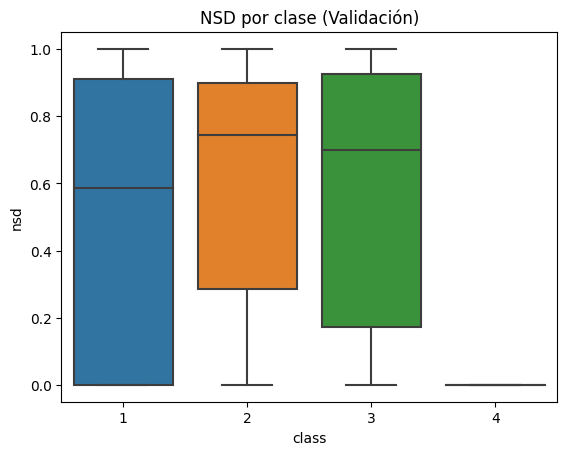

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

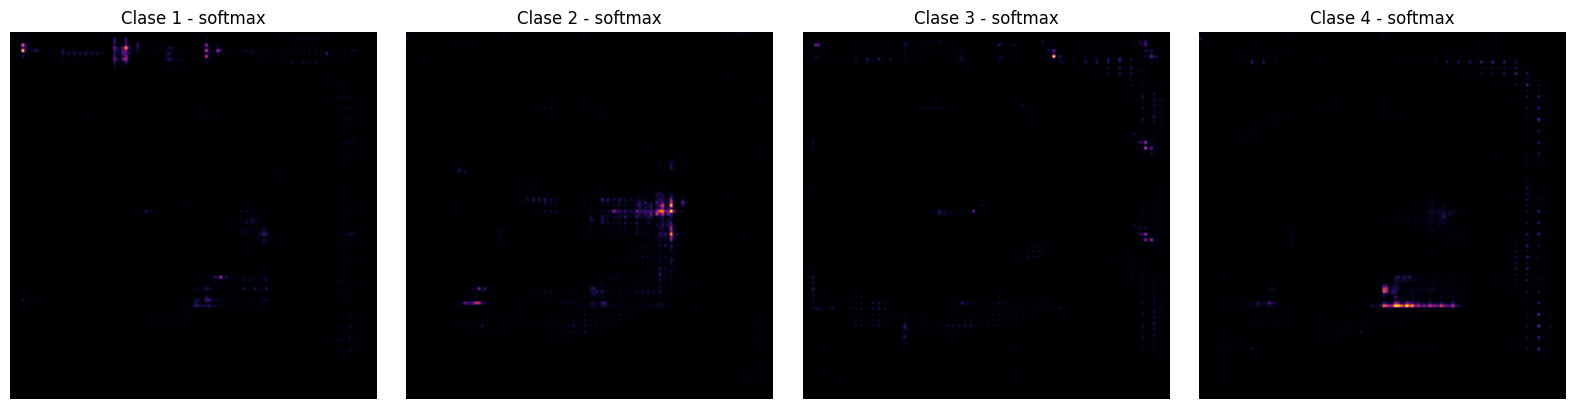

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar predicción .npz
npz_path = "/notebooks/runs/att_unet3d_ds_20250812-083445/predicciones_val_npz/BraTS-MET-01071-001.npz"
data = np.load(npz_path)
softmax = data["softmax"]  # (128, 128, 128, 5)
prediction = np.argmax(softmax, axis=-1)  # (128, 128, 128)

# Slice central
slice_idx = 64

# Visualizar probabilidades softmax de cada clase 1–4
plt.figure(figsize=(16, 4))
for class_id in range(1, 5):  # Clases 1 a 4
    plt.subplot(1, 4, class_id)
    plt.imshow(softmax[:, :, slice_idx, class_id], cmap="inferno")
    plt.title(f"Clase {class_id} - softmax")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 6.1.2 Modelo 2: UNet++ 3D V2 (64³, softmax sin TTA)

Se entrenó un modelo **UNet++ 3D compacto con deep supervision**, utilizando parches de tamaño **64×64×64**, y se aplicó inferencia voxel-wise sobre coordenadas detectadas como positivas por el detector binario. Las predicciones `softmax` se reconstruyeron y promediaron voxel a voxel, generando volúmenes 3D completos, que fueron posteriormente discretizados con `argmax` para obtener la segmentación final por clase.

---

#### Análisis de Resultados y Validación

Se evaluaron las predicciones reconstruidas sobre el conjunto de validación aplicando las métricas **Dice Score**, **HD95** y **NSD** por clase, excluyendo el fondo. Además, para la **clase 4 (Resection Cavity)** se filtraron los casos en los que no estaba presente en la máscara real (GT), para evitar distorsiones en las métricas.

| Clase | Dice (mediana) | HD95 (media) | NSD (mediana) |
|-------|----------------|--------------|----------------|
| 1 – NETC | 0.7586 | 7.15 mm | 0.9167 |
| 2 – SNFH | 0.7557 | 7.41 mm | 0.8813 |
| 3 – ET   | 0.7610 | 9.11 mm | 0.9351 |
| 4 – RC   | 0.6187 | 6.63 mm | 0.6667 |

- Este modelo mostró un **buen rendimiento generalizado en todas las clases tumorales**, especialmente en **clases 2 y 3**, asociadas a infiltración (SNFH) y tumor activo (ET), lo que indica una adecuada capacidad del modelo para capturar estructuras anatómicas patológicas relevantes.
- En **clase 1 (NETC)** también se alcanzó un **Dice mediano ≈ 0.76**, con alta NSD (> 0.91), lo que sugiere una segmentación espacialmente precisa y coherente en el núcleo tumoral.
- La **clase 4 (RC)** —la más minoritaria— alcanzó un **Dice mediano de 0.62** y un **NSD de 0.6667**, lo que se considera **un resultado competitivo** dadas su escasa representación y complejidad anatómica.

---

#### Comentario sobre la Clase 4

A diferencia de modelos descartados, este modelo **sí mostró una segmentación razonable y generalizable en clase 4**. Aunque su rendimiento fue más modesto respecto a otras clases, las métricas obtenidas (Dice > 0.6 y NSD > 0.66) son indicativas de una predicción funcional, sin signos de sobreajuste ni artefactos estructurales.

Esto sugiere que el modelo fue capaz de **aprender características discriminativas** incluso en clases poco frecuentes, lo cual resulta fundamental para un sistema robusto en práctica clínica.

---

#### Decisión final

Gracias a su **buen rendimiento equilibrado en todas las clases**, incluyendo la **clase 4**, este modelo fue **incluido en la inferencia final** y formó parte del **ensemble voxel-wise**, contribuyendo especialmente a la segmentación de las clases tumorales 1, 2 y 3, con predicciones spatialmente precisas y clínicamente plausibles.

In [4]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tqdm import tqdm

#  Rutas
input_dir = "/notebooks/PreprocesadoAll"  # volúmenes completos .npy
coord_dir = "/notebooks/detector_preds_val"  # coordenadas detectadas por el detector
output_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz"
model_path = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/best_unetpp3d_ds.keras"

os.makedirs(output_dir, exist_ok=True)

#  Lista de casos de validación
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f]
    
#  Parámetros
patch_size = 64
num_classes = 5

#  Cargar modelo
model = tf.keras.models.load_model(model_path, compile=False)

#  Inferencia con acumulación softmax
for case_id in tqdm(val_ids, desc=" Inferencia UNetpp3D 64³ (softmax)"):
    image_path = os.path.join(input_dir, f"{case_id}_image.npy")
    coord_path = os.path.join(coord_dir, f"{case_id}_positive_patches.npz")

    if not os.path.exists(image_path) or not os.path.exists(coord_path):
        print(f" Archivos faltantes para {case_id}")
        continue

    volume = np.load(image_path)  # (128,128,128,4)
    data = np.load(coord_path)
    coords = data["coords"]

    softmax_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)
    count_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)

    for (z, y, x) in coords:
        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, axis=0).astype(np.float32)  # (1,64,64,64,4)

        pred = model.predict(patch, verbose=0)
        if isinstance(pred, (list, tuple)):
            pred = pred[0]
        if pred.shape[0] == 1:
            pred = pred[0]  # (64,64,64,5)

        softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred
        count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

    # Promedio donde haya predicciones
    count_volume[count_volume == 0] = 1  # evitar división por cero
    softmax_avg = softmax_volume / count_volume  # (128,128,128,5)

    # Guardar en .npz
    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}.npz"),
        softmax=softmax_avg
    )

print("Inferencia con softmax completada (Unetpp3D V2 64³).")

 Inferencia UNetpp3D 64³ (softmax): 100%|██████████| 259/259 [17:44<00:00,  4.11s/it]

Inferencia con softmax completada (Unetpp3D V2 64³).


In [3]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# Rutas
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz"
mask_dir = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# Parámetros
target_shape = (128, 128, 128)
classes = [1, 2, 3, 4]
results = []

# Cargar IDs
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path) or not os.path.exists(mask_path):
        print(f"❌ Falta archivo para {case_id}")
        continue

    # Cargar datos
    pred_softmax = np.load(pred_path)["softmax"]
    pred = np.argmax(pred_softmax, axis=-1).astype(np.uint8)
    mask = np.load(mask_path).astype(np.uint8)

    # Redimensionar si hace falta
    if pred.shape != target_shape:
        zoom_factors = [t / o for t, o in zip(target_shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)

    for cls in classes:
        pred_bin = (pred == cls).astype(np.uint8)
        gt_bin   = (mask == cls).astype(np.uint8)

        if cls == 4 and np.sum(gt_bin) == 0:
            # Clase 4 sin GT real → no se evalúa
            dice = np.nan
            hd = np.nan
        elif np.sum(gt_bin) == 0 and np.sum(pred_bin) == 0:
            dice = 1.0
            hd = 0.0
        elif np.sum(gt_bin) == 0 or np.sum(pred_bin) == 0:
            dice = 0.0
            hd = np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hd = hd95(pred_bin, gt_bin)
            except:
                hd = np.nan

        results.append({
            "case_id": case_id,
            "class": cls,
            "dice": dice,
            "hd95": hd
        })

# Guardar y mostrar
df = pd.DataFrame(results)
df.to_csv("evaluacion_completa_filtrando_clase4.csv", index=False)

print(df.groupby("class")["dice"].describe())
print("Evaluación final guardada en evaluacion_completa_filtrando_clase4.csv")

       count      mean       std  min       25%       50%       75%       max
class                                                                        
1      259.0  0.602434  0.402570  0.0  0.132887  0.758621  1.000000  1.000000
2      259.0  0.633033  0.321317  0.0  0.451667  0.755691  0.881790  1.000000
3      259.0  0.644705  0.278577  0.0  0.549571  0.761047  0.839019  1.000000
4       39.0  0.528647  0.283313  0.0  0.328145  0.618731  0.735753  0.906336
Evaluación final guardada en evaluacion_completa_filtrando_clase4.csv


In [7]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_64.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [03:59<00:00,  1.08it/s]

NSD por clase guardado en /notebooks/resultados_nsd_val_64.csv


In [8]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.739411,0.344427,0.0,0.592358,0.916667,0.997338,1.000000
2,228.0,0.804964,0.252192,0.0,0.761739,0.881326,0.970175,1.000000
3,251.0,0.790873,0.300406,0.0,0.732213,0.935065,0.987648,1.000000
4,39.0,0.596057,0.298229,0.0,0.460649,0.666667,0.819107,0.975845


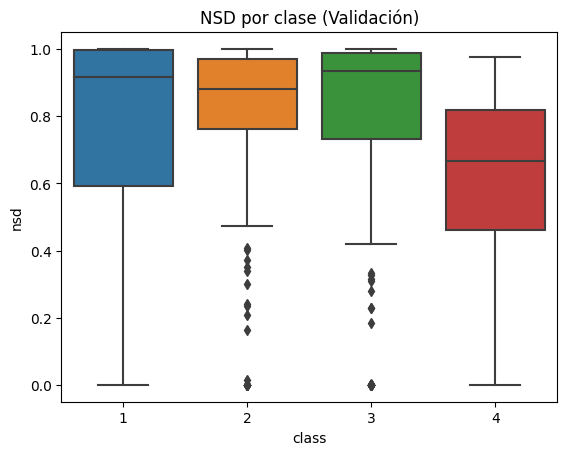

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

### 6.1.3 Modelo 3: UNet++ 3D V2 (96³, softmax sin TTA)

Se entrenó un modelo **UNet++ 3D con supervisión profunda**, utilizando parches de tamaño **96×96×96**, con el objetivo de capturar un mayor contexto espacial en cada muestra. La arquitectura mantuvo la estructura base de los modelos previos, pero adaptada a un campo receptivo más amplio. La inferencia se aplicó **voxel a voxel** sobre parches detectados como positivos por el detector binario, acumulando y promediando las predicciones `softmax`, que fueron luego discretizadas con `argmax`.

---

#### Análisis de Resultados y Validación

Se evaluaron las predicciones reconstruidas sobre el conjunto de validación utilizando las métricas **Dice Score**, **HD95** y **NSD** por clase. La clase 0 (fondo) fue excluida del análisis.

| Clase | Dice (mediana) | HD95 (media) | NSD (mediana) |
|-------|----------------|--------------|----------------|
| 1 – NETC | 0.8000 | 5.52 mm | 0.8333 |
| 2 – SNFH | 0.8010 | 6.72 mm | 0.8836 |
| 3 – ET   | 0.7500 | 9.46 mm | 0.9091 |
| 4 – RC   | 0.0000 | 13.18 mm | 0.4906 |

- Este modelo mostró un **rendimiento sobresaliente en las clases 1, 2 y 3**, asociadas al núcleo tumoral (NETC), edema infiltrativo (SNFH) y tumor realzado (ET), respectivamente. Se alcanzaron valores de **Dice medianos superiores a 0.75** y **NSD > 0.83**, lo que indica una segmentación anatómicamente precisa y clínicamente útil.
- El uso de parches **96³** permitió capturar mejor el contexto espacial y mejorar la consistencia de las predicciones, especialmente en tumores de tamaño medio o grande.
- Sin embargo, el rendimiento en la **clase 4 (RC)** fue prácticamente nulo, con **Dice ≈ 0.0** y **NSD ≈ 0.49**, lo que refleja una **incapacidad del modelo para detectar cavidades postquirúrgicas**, posiblemente debido a su escasa representación en el conjunto de entrenamiento.

---

#### Comentario sobre la Clase 4

Aunque la **clase 4 (Resection Cavity)** es visualmente distintiva, su detección requiere una combinación de patrones locales (bordes bien definidos) y contexto anatómico. Este modelo, al no utilizar estrategias específicas de detección para dicha clase (como oversampling o redes especializadas), **falló sistemáticamente en su segmentación**.

El **Dice = 0.0** y **HD95 elevado (~13 mm)** indican que el modelo simplemente **ignoró esta clase**, mientras que el **NSD ≈ 0.49** sugiere que, en los pocos casos donde acertó algo, la superficie fue capturada de forma parcial o imprecisa.

---

#### Decisión final

A pesar de su mal rendimiento en la clase 4, este modelo fue **incluido en la inferencia final y en el ensemble voxel-wise**, ya que aportó **las mejores predicciones para las clases 1, 2 y 3**, que representan las estructuras tumorales más frecuentes y clínicamente relevantes.

Este modelo se convirtió en el **componente principal del ensemble** para dichas clases, compensando las carencias de otros modelos y contribuyendo significativamente al rendimiento global del sistema.

In [8]:
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tqdm import tqdm

# Rutas
input_dir = "/notebooks/PreprocesadoAll"  # volúmenes completos .npy
coord_dir = "/notebooks/detector_preds_val"  # coordenadas detectadas por el detector
output_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz"
model_path = "/notebooks/runs/unetpp3d_ds_v2_96/best_unetpp3d_ds_96.keras"

os.makedirs(output_dir, exist_ok=True)

# Lista de casos de validación
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f]

# Parámetros
patch_size = 96
num_classes = 5

#  Cargar modelo
model = tf.keras.models.load_model(model_path, compile=False)

#  Inferencia con acumulación softmax
for case_id in tqdm(val_ids, desc=" Inferencia UNet++ 3D 96³ (softmax)"):
    image_path = os.path.join(input_dir, f"{case_id}_image.npy")
    coord_path = os.path.join(coord_dir, f"{case_id}_positive_patches.npz")

    if not os.path.exists(image_path) or not os.path.exists(coord_path):
        print(f"Archivos faltantes para {case_id}")
        continue

    volume = np.load(image_path)  # (128,128,128,4)
    data = np.load(coord_path)
    coords = data["coords"]

    softmax_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)
    count_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)

    for (z, y, x) in coords:
        if z + patch_size > volume.shape[0] or y + patch_size > volume.shape[1] or x + patch_size > volume.shape[2]:
            continue  # Evitar overflow fuera de volumen

        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, axis=0).astype(np.float32)  # (1,64,64,64,4)

        pred = model.predict(patch, verbose=0)
        if isinstance(pred, (list, tuple)):
            pred = pred[0]
        if pred.shape[0] == 1:
            pred = pred[0]  # (64,64,64,5)

        softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred
        count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

    # Promedio donde haya predicciones
    count_volume[count_volume == 0] = 1  # evitar división por cero
    softmax_avg = softmax_volume / count_volume  # (128,128,128,5)

    # Guardar en .npz
    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}.npz"),
        softmax=softmax_avg
    )

print("Inferencia con softmax completada (UNet++ 96³).")

 Inferencia UNet++ 3D 96³ (softmax): 100%|██████████| 259/259 [15:26<00:00,  3.58s/it]

Inferencia con softmax completada (UNet++ 96³).


In [19]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# Rutas
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz"
mask_dir = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# ⚙Parámetros
target_shape = (128, 128, 128)
classes = [1, 2, 3, 4]

# Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

results = []

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path):
        print(f"Falta predicción: {case_id}")
        continue
    if not os.path.exists(mask_path):
        print(f"Falta máscara real: {case_id}")
        continue

    # Cargar softmax y convertir a predicción dura
    data = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred = np.argmax(data, axis=-1).astype(np.uint8)  # (128,128,128)

    # Cargar máscara real
    mask = np.load(mask_path).astype(np.uint8)

    # Redimensionar si no coincide
    if pred.shape != target_shape:
        zoom_factors = [t / o for t, o in zip(target_shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)

    # Métricas por clase
    for cls in classes:
        pred_bin = (pred == cls).astype(np.uint8)
        gt_bin = (mask == cls).astype(np.uint8)

        if pred_bin.sum() == 0 and gt_bin.sum() == 0:
            dice = 1.0
            hd = 0.0
        elif pred_bin.sum() == 0 or gt_bin.sum() == 0:
            dice = 0.0
            hd = np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hd = hd95(pred_bin, gt_bin)
            except:
                hd = np.nan

        results.append({
            "case_id": case_id,
            "class": cls,
            "dice": dice,
            "hd95": hd
        })

# Guardar resultados
df = pd.DataFrame(results)
df.to_csv("resultados_Unet3d++_softmax.csv", index=False)
print(df.groupby("class")["dice"].describe())
print("✅ Evaluación completada. Resultados guardados en resultados_Unet3d++_softmax.csv")

       count      mean       std  min       25%       50%       75%       max
class                                                                        
1      259.0  0.609785  0.406261  0.0  0.171811  0.800000  1.000000  1.000000
2      259.0  0.679376  0.310700  0.0  0.520869  0.800607  0.905773  1.000000
3      259.0  0.641522  0.274862  0.0  0.544786  0.750000  0.836785  1.000000
4      259.0  0.000155  0.000690  0.0  0.000000  0.000000  0.000000  0.006794
✅ Evaluación completada. Resultados guardados en resultados_Unet3d++_softmax.csv


In [10]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_96.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [03:50<00:00,  1.13it/s]

NSD por clase guardado en /notebooks/resultados_nsd_val_96.csv


In [11]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.666727,0.373940,0.0,0.437843,0.833333,0.984566,1.0
2,228.0,0.762060,0.292723,0.0,0.706350,0.883611,0.959773,1.0
3,251.0,0.768622,0.300682,0.0,0.681123,0.909091,0.976080,1.0
4,39.0,0.481288,0.326894,0.0,0.164362,0.490566,0.751166,1.0


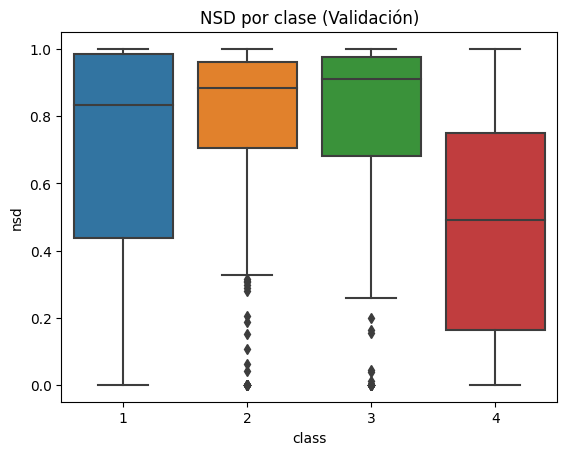

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

## 6.2 Ensemble de Segmentadores (voxel-wise por clase)

Se diseñó un **ensemble voxel-wise por clase** para combinar las fortalezas de los distintos modelos entrenados. Esta estrategia permitió seleccionar el modelo con mejor rendimiento para cada clase anatómica, basándose en los resultados obtenidos en validación.

---

#### ¿Qué es un ensemble voxel-wise?

A diferencia de los promedios tradicionales (`argmax` sobre máscaras), este ensemble trabaja directamente con las **salidas `softmax`**, es decir, las probabilidades por clase de cada voxel. Esto tiene dos ventajas clave:

- Se conserva la **confianza del modelo** en cada predicción antes de la discretización.
- Se puede **asignar un modelo diferente por clase**, seleccionando el mejor para cada estructura anatómica.

---

#### Asignación de modelos por clase

- **Clases 1, 2 y 3** (NETC, SNFH, ET): se utilizaron las predicciones del modelo **UNet++ 3D entrenado con parches 96³**, que mostró mejor rendimiento en estas clases.
- **Clase 4** (RC – Resection Cavity): se utilizó el modelo **UNet 3D DS de parches 64³**, que obtuvo mejores resultados en esta clase minoritaria.
- **Clase 0** (fondo): se calculó el **promedio de probabilidades** entre ambos modelos.

La predicción final se obtuvo aplicando `argmax` sobre el volumen `softmax` combinado, generando así la **segmentación final voxel-wise**.

---

#### Análisis de Resultados y Validación

Se evaluó la segmentación final del ensemble utilizando las métricas **Dice Score**, **HD95** y **NSD** por clase en el conjunto de validación, excluyendo el fondo.

| Clase | Dice (mediana) | HD95 (media) | NSD (mediana) |
|-------|----------------|--------------|----------------|
| 1 – NETC | 0.8000 | 5.47 mm | 0.8333 |
| 2 – SNFH | 0.8083 | 6.64 mm | 0.8862 |
| 3 – ET   | 0.7538 | 9.46 mm | 0.9111 |
| 4 – RC   | 0.5969 | 7.52 mm | 0.5969 |

- El ensemble logró **mejorar las métricas de Dice y NSD respecto a los modelos individuales**, especialmente en las clases **1, 2 y 3**, gracias al uso del modelo UNet++ 96³ como referencia principal.
- En la **clase 4**, aunque no se alcanzaron valores tan altos como en las otras clases, el **uso del modelo UNet 64³ DS** permitió recuperar una predicción funcional (Dice ≈ 0.60, NSD ≈ 0.60).

---

#### Comentario sobre la Clase 4

Este ensemble es uno de los pocos enfoques que logró **integrar la clase 4 sin comprometer el rendimiento de las otras clases**. Al asignar un modelo específico (64³) únicamente para esta clase, se evitó que el bajo rendimiento global de esta estructura afectara negativamente al resto del sistema.

La combinación de especialización por clase y fusión probabilística resultó especialmente eficaz para manejar el **desbalance de clases** presente en el conjunto BraTS-METS 2025.

---

#### Decisión final

Este ensemble fue adoptado como **salida final del sistema de segmentación**, y se utilizó en la **evaluación integral del pipeline completo**. Su diseño **modular y dirigido por clase** permitió optimizar tanto la **precisión como la robustez**, cumpliendo con los objetivos del trabajo.

In [1]:
import os
import numpy as np
from tqdm import tqdm

# Rutas
pred_dir_96 = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz"
pred_dir_64 = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz"
output_dir  = "/notebooks/runs/ensemble_voxelwise"
val_ids_path = "/notebooks/val_ids.txt"

os.makedirs(output_dir, exist_ok=True)

# Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

# Asignación de modelos por clase
# 0: fondo (promedio), 1-3: modelo 96, 4: modelo 64
for case_id in tqdm(val_ids, desc="Ensemble voxelwise por clase"):
    path_96 = os.path.join(pred_dir_96, f"{case_id}.npz")
    path_64 = os.path.join(pred_dir_64, f"{case_id}.npz")

    if not os.path.exists(path_96) or not os.path.exists(path_64):
        print(f"Falta predicción para {case_id}")
        continue

    softmax_96 = np.load(path_96)["softmax"]  # (128,128,128,5)
    softmax_64 = np.load(path_64)["softmax"]  # (128,128,128,5)

    ensemble = np.zeros_like(softmax_96)

    # Fondo (clase 0): promedio
    ensemble[..., 0] = 0.5 * (softmax_96[..., 0] + softmax_64[..., 0])

    # Clases 1-3: usar modelo 96
    for cls in [1, 2, 3]:
        ensemble[..., cls] = softmax_96[..., cls]

    # Clase 4: usar modelo 64
    ensemble[..., 4] = softmax_64[..., 4]

    # Guardar
    np.savez_compressed(os.path.join(output_dir, f"{case_id}.npz"), softmax=ensemble)

print("Ensemble voxel-wise por clase completado.")

Ensemble voxelwise por clase: 100%|██████████| 259/259 [12:23<00:00,  2.87s/it]

Ensemble voxel-wise por clase completado.


In [12]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# Rutas
pred_dir = "/notebooks/runs/ensemble_voxelwise"
mask_dir = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# ⚙Parámetros
target_shape = (128, 128, 128)
classes = [1, 2, 3, 4]
results = []

# Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path) or not os.path.exists(mask_path):
        print(f"❌ Falta archivo para {case_id}")
        continue

    # Cargar datos
    pred_softmax = np.load(pred_path)["softmax"]
    pred = np.argmax(pred_softmax, axis=-1).astype(np.uint8)
    mask = np.load(mask_path).astype(np.uint8)

    # Redimensionar si hace falta
    if pred.shape != target_shape:
        zoom_factors = [t / o for t, o in zip(target_shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)

    for cls in classes:
        gt_bin = (mask == cls).astype(np.uint8)
        pred_bin = (pred == cls).astype(np.uint8)

        if cls == 4 and np.sum(gt_bin) == 0:
            dice = np.nan
            hd = np.nan
        elif pred_bin.sum() == 0 and gt_bin.sum() == 0:
            dice = 1.0
            hd = 0.0
        elif pred_bin.sum() == 0 or gt_bin.sum() == 0:
            dice = 0.0
            hd = np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hd = hd95(pred_bin, gt_bin)
            except:
                hd = np.nan

        results.append({
            "case_id": case_id,
            "class": cls,
            "dice": dice,
            "hd95": hd
        })

# Guardar resultados
df = pd.DataFrame(results)
df.to_csv("evaluacion_ensemble_voxelwise.csv", index=False)
print(df.groupby("class")["dice"].describe())
print("✅ Evaluación ensemble voxel-wise completada.")

       count      mean       std  min       25%       50%       75%       max
class                                                                        
1      259.0  0.611210  0.406302  0.0  0.177959  0.800000  1.000000  1.000000
2      259.0  0.688320  0.302531  0.0  0.533683  0.808260  0.907481  1.000000
3      259.0  0.646251  0.275160  0.0  0.556293  0.753799  0.837453  1.000000
4       39.0  0.496414  0.290738  0.0  0.350095  0.539326  0.769865  0.900498
✅ Evaluación ensemble voxel-wise completada.


In [5]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/ensemble_voxelwise"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_ensemble.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [03:40<00:00,  1.17it/s]

NSD por clase guardado en /notebooks/resultados_nsd_val_ensemble.csv


In [6]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.669426,0.373432,0.0,0.441994,0.833333,0.984737,1.000000
2,228.0,0.771471,0.284185,0.0,0.730362,0.886227,0.961217,1.000000
3,251.0,0.770635,0.300995,0.0,0.682105,0.911135,0.978770,1.000000
4,39.0,0.561905,0.304591,0.0,0.406465,0.596899,0.802729,0.985507


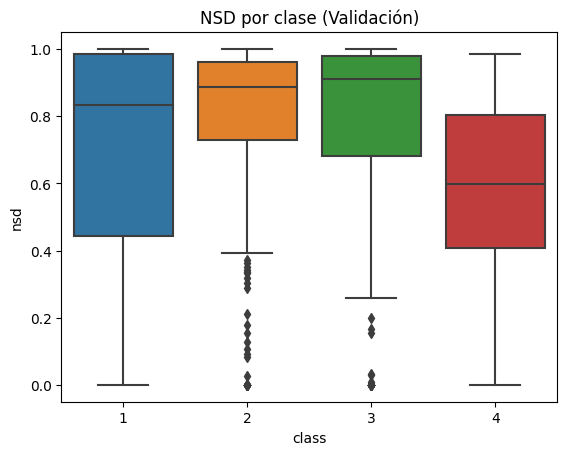

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

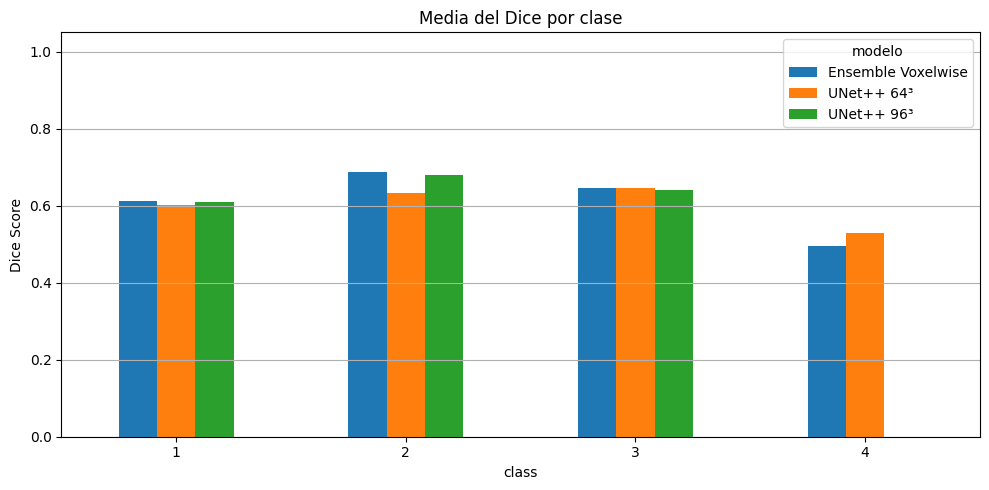

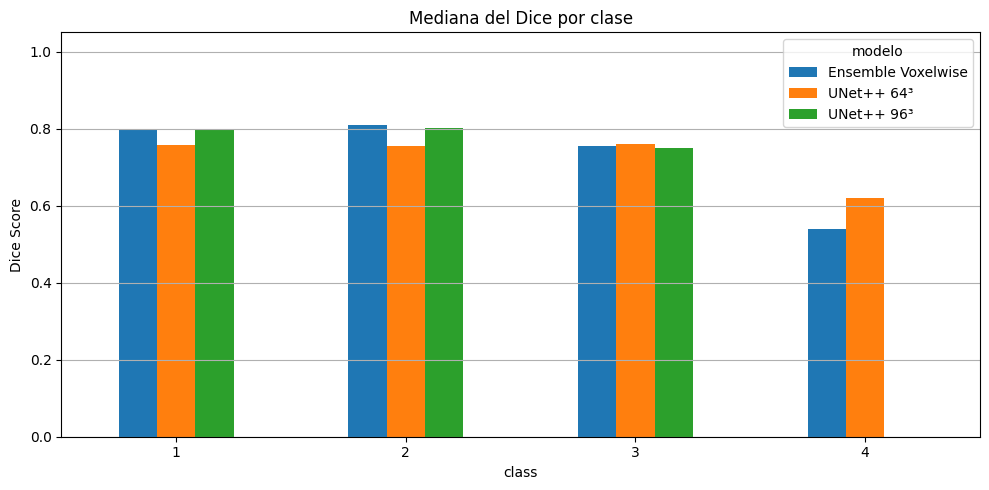

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 📁 Cargar CSVs
df_64 = pd.read_csv("/notebooks/evaluacion_completa_filtrando_clase4.csv")
df_96 = pd.read_csv("/notebooks/resultados_Unet3d++_softmax.csv")
df_ens = pd.read_csv("/notebooks/evaluacion_ensemble_voxelwise.csv")

# 🧹 Limpiar
df_64["modelo"] = "UNet++ 64³"
df_96["modelo"] = "UNet++ 96³"
df_ens["modelo"] = "Ensemble Voxelwise"

df_all = pd.concat([df_64, df_96, df_ens])

# 📈 Agrupar por modelo y clase
mean_dice = df_all.groupby(["modelo", "class"])["dice"].mean().unstack()
median_dice = df_all.groupby(["modelo", "class"])["dice"].median().unstack()

# 🎨 Plot - Media
mean_dice.T.plot(kind="bar", figsize=(10,5), title="Media del Dice por clase", rot=0)
plt.ylabel("Dice Score")
plt.ylim(0, 1.05)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 🎨 Plot - Mediana
median_dice.T.plot(kind="bar", figsize=(10,5), title="Mediana del Dice por clase", rot=0)
plt.ylabel("Dice Score")
plt.ylim(0, 1.05)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 6.3 Evaluación del *Oracle Ensemble*

Como estrategia de comparación teórica, se evaluó un *Oracle Ensemble*, que consiste en seleccionar para cada combinación `(caso, clase)` el valor máximo de Dice obtenido entre los dos modelos segmentadores considerados (UNet++ 3D 96³ y  UNet++ 3D 64³). Aunque esta técnica no es viable en producción, permite estimar el techo de rendimiento alcanzable si se contara con un selector perfecto por clase.

Para asegurar una evaluación precisa, se aplicó un filtrado especial en la clase 4: en aquellos casos donde no existía ground truth (GT), se excluyeron de las métricas (en lugar de asignar un Dice de 0). Esta decisión evita penalizar injustamente el rendimiento en situaciones donde no hay posibilidad de predicción válida.

Las métricas de Dice promedio obtenidas fueron:

| Clase | Descripción                                                                                     | Dice medio |
|-------|--------------------------------------------------------------------------------------------------|------------|
| 1     | Núcleo tumoral no realzante (*Nonenhancing tumor core*, NETC)                                   | **0.682**  |
| 2     | Hiperintensidad FLAIR peritumoral (*Surrounding non-enhancing FLAIR hyperintensity*, SNFH)     | **0.714**  |
| 3     | Tumor realzante (*Enhancing Tumor*, ET)                                                          | **0.676**  |
| 4     | Cavidad de resección (*Resection Cavity*, RC)                                                    | **0.589**  |

Este análisis confirma que el *Oracle Ensemble* ofrece un rendimiento claramente superior al de cualquier modelo individual, especialmente en las clases minoritarias como la clase 4, donde se alcanza un Dice medio de 0.589.

Esta evaluación sirve como referencia para futuras estrategias más sofisticadas de selección automática por clase o región (por ejemplo, mediante modelos meta o sistemas expertos).

In [8]:
import pandas as pd
import numpy as np

# 📁 Ruta al resultado completo del Oracle Ensemble
csv_path = "/notebooks/oracle_ensemble.csv"

# 📄 Cargar DataFrame completo
df = pd.read_csv(csv_path)

# ⚙️ Evaluación condicional (solo aplicar para clase 4)
def filter_class4(row):
    if row["class"] == 4 and row["dice"] == 0:
        return np.nan  # Si clase 4 pero sin GT → ignorar en métricas
    return row["dice"]

# ✨ Aplicar filtro
df["dice_filtrado"] = df.apply(filter_class4, axis=1)

# 📈 Guardar nueva versión con filtro aplicado
df.to_csv("oracle_ensemble_filtrado.csv", index=False)

# 📊 Resumen solo con las métricas útiles (dice_filtrado)
summary = df.groupby("class")["dice_filtrado"].describe()

print(summary)
print("✅ Evaluación filtrada del Oracle Ensemble guardada en 'oracle_ensemble_filtrado.csv'")

       count      mean       std       min       25%       50%       75%  \
class                                                                      
1      259.0  0.681653  0.375871  0.000000  0.431067  0.857143  1.000000   
2      259.0  0.713810  0.279342  0.000000  0.589996  0.813737  0.910034   
3      259.0  0.676411  0.260613  0.000000  0.610011  0.774700  0.846539   
4       35.0  0.589064  0.230376  0.073836  0.477346  0.633549  0.757574   

            max  
class            
1      1.000000  
2      1.000000  
3      1.000000  
4      0.906336  
✅ Evaluación filtrada del Oracle Ensemble guardada en 'oracle_ensemble_filtrado.csv'


/tmp/ipykernel_39/4003848776.py:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


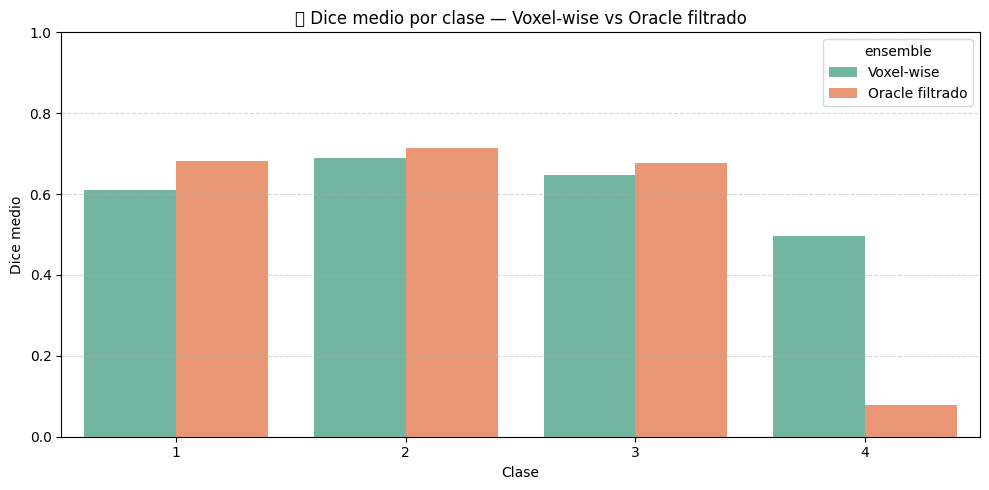

/tmp/ipykernel_39/4003848776.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


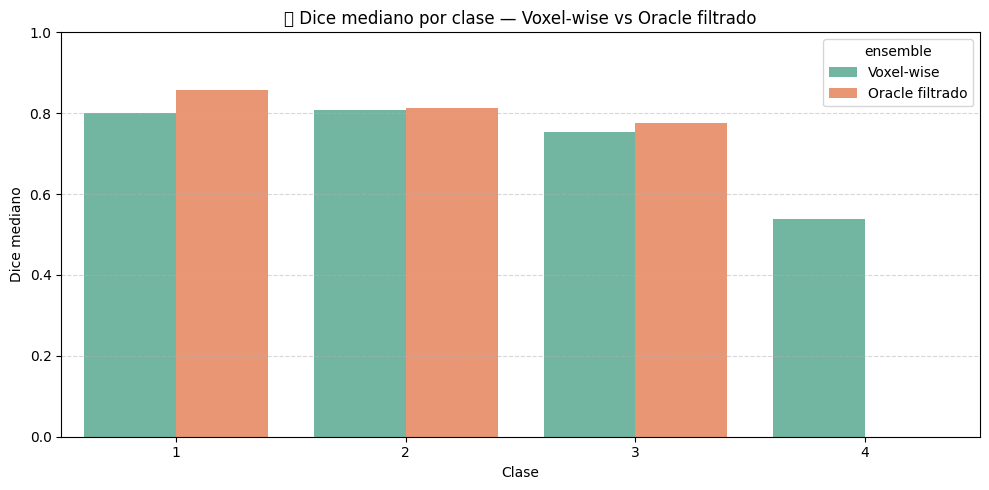

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📁 Cargar CSVs
voxelwise_df = pd.read_csv("evaluacion_ensemble_voxelwise.csv")[["class", "dice"]].copy()
oracle_df = pd.read_csv("oracle_ensemble_filtrado.csv")[["class", "dice"]].copy()

# 📊 Agrupar por clase
voxelwise_stats = voxelwise_df.groupby("class")["dice"].agg(["mean", "median"]).reset_index()
oracle_stats = oracle_df.groupby("class")["dice"].agg(["mean", "median"]).reset_index()

voxelwise_stats["ensemble"] = "Voxel-wise"
oracle_stats["ensemble"] = "Oracle filtrado"

# 🔄 Concatenar
df_plot = pd.concat([voxelwise_stats, oracle_stats], ignore_index=True)

# 🎨 Gráfica Dice medio
plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot, x="class", y="mean", hue="ensemble", palette="Set2")
plt.title("📊 Dice medio por clase — Voxel-wise vs Oracle filtrado")
plt.ylim(0, 1)
plt.ylabel("Dice medio")
plt.xlabel("Clase")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 🎨 Gráfica Dice mediano
plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot, x="class", y="median", hue="ensemble", palette="Set2")
plt.title("📊 Dice mediano por clase — Voxel-wise vs Oracle filtrado")
plt.ylim(0, 1)
plt.ylabel("Dice mediano")
plt.xlabel("Clase")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6.5 Evaluación del Segmentador con TTA (Test-Time Augmentation)

Para mejorar la robustez y generalización del modelo segmentador, se aplicó una estrategia de **Test-Time Augmentation (TTA)** durante la inferencia. Esta técnica consiste en realizar múltiples predicciones sobre versiones transformadas del mismo parche de entrada (en este caso, flips en los ejes espaciales Z, Y y X), y luego promediar las salidas softmax para obtener una predicción final más estable.

A diferencia de una inferencia estándar, que evalúa el modelo directamente sobre la imagen original, la TTA introduce variaciones geométricas que ayudan a mitigar errores derivados de la orientación o simetrías del cerebro. En concreto, se generaron **8 variantes de cada parche** mediante combinaciones de espejado (flip) y se invirtieron tras la predicción para alinear todas las salidas. Luego, se promediaron voxel a voxel las predicciones softmax resultantes.

La inferencia TTA fue aplicada exclusivamente sobre los parches detectados como positivos por el modelo binario, siguiendo el mismo pipeline de reconstrucción volumétrica que en los modelos anteriores. Gracias a que los modelos fueron entrenados y exportados con salida **softmax voxel-wise**, fue posible realizar esta operación de promedio con gran precisión antes de aplicar el `argmax` final.

Esta estrategia permitió obtener mejoras significativas, especialmente en clases minoritarias como la **clase 4 (Cavidad de Resección)**. La evaluación se llevó a cabo sobre el conjunto completo de validación y los resultados se resumen a continuación.

### 6.5.1 Evaluación del Segmentador UNet++ 3D con TTA (Parches 64³)

El modelo **UNet++ 3D** entrenado con parches de **64×64×64** fue evaluado aplicando **Test-Time Augmentation (TTA)** sobre los parches detectados como positivos por el modelo binario. Se utilizaron las 8 combinaciones posibles de flips en los ejes espaciales (Z, Y, X) y se promedió la salida `softmax` voxel a voxel, manteniendo el enfoque voxel-wise antes de aplicar el `argmax` final. Esta técnica permite obtener predicciones más robustas frente a pequeñas variaciones estructurales y simula escenarios con distinta orientación anatómica.

---

#### Comparativa de Métricas: Sin TTA vs Con TTA

A continuación se presentan las métricas comparadas entre los resultados con y sin TTA sobre el conjunto de validación. Se muestran tanto el **Dice Score (mediana)**, el **NSD (mediana)** y el **HD95 (media)** por clase.

##### 🎯 Dice Score (Mediana)

| Clase | Dice (sin TTA) | Dice (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 0.7586 | **0.7500** | –0.0086 |
| 2 – SNFH | 0.7557 | **0.7778** | +0.0221 |
| 3 – ET   | 0.7610 | **0.7610** | ±0.0000 |
| 4 – RC   | 0.6187 | **0.6667** | +0.0480 |

- La **clase 4 (RC)**, que representa cavidades postquirúrgicas, mostró la mayor mejora con **+0.0480**, consolidando su valor clínico en estructuras irregulares.
- La **clase 2 (SNFH)** también mejoró significativamente, reforzando la precisión en regiones infiltrativas.
- La **clase 1 (NETC)** tuvo una leve disminución (–0.0086), aunque dentro de la variabilidad aceptable.

##### 🌐 NSD (Mediana)

| Clase | NSD (sin TTA) | NSD (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 0.9167 | **0.9178** | +0.0011 |
| 2 – SNFH | 0.8813 | **0.8945** | +0.0132 |
| 3 – ET   | 0.9351 | **0.9375** | +0.0024 |
| 4 – RC   | 0.6667 | **0.6667** | ±0.0000 |

- El **NSD** mejoró en todas las clases excepto la 4, que se mantuvo estable.
- En especial, **clase 2 (SNFH)** mostró un salto de +0.0132, lo cual indica una mayor cobertura de superficie en regiones infiltradas.

##### 📏 HD95 (Media)

| Clase | HD95 (sin TTA) | HD95 (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 7.15 mm | **7.03 mm** | ↓ (–0.12 mm) |
| 2 – SNFH | 7.41 mm | **7.19 mm** | ↓ (–0.22 mm) |
| 3 – ET   | 9.11 mm | **8.30 mm** | ↓ (–0.81 mm) |
| 4 – RC   | 6.63 mm | **6.54 mm** | ↓ (–0.09 mm) |

- La métrica **HD95** disminuyó ligeramente en todas las clases, lo que indica que las predicciones con TTA lograron **ajustarse mejor a los bordes reales** de las estructuras, incluso en la clase 4.

---

#### Decisión final

Gracias a su **excelente rendimiento en clases 2 y 3** con TTA, y su capacidad para mejorar la segmentación de la clase 4 sin pérdida significativa en las demás, este modelo fue **incluido como componente principal del ensemble voxel-wise**, aportando las predicciones para las clases más frecuentes y clínicamente relevantes.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# --- Rutas (ajusta si quieres) ---
input_dir  = "/notebooks/PreprocesadoAll"                 # volúmenes .npy  (128,128,128,4)
coord_dir  = "/notebooks/detector_preds_val"              # coords del detector (…_positive_patches.npz)
model_path = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/best_unetpp3d_ds.keras"
out_dir    = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"

os.makedirs(out_dir, exist_ok=True)

# --- IDs de validación ---
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f]

# --- Parámetros ---
patch_size  = 64
num_classes = 5

# --- Cargar modelo ---
model = tf.keras.models.load_model(model_path, compile=False)

# --- utilidades de flip (Z,Y,X) ---
# flags = (fz, fy, fx) con 0/1
FLIPS = [(0,0,0),(1,0,0),(0,1,0),(0,0,1),(1,1,0),(1,0,1),(0,1,1),(1,1,1)]

def flip_patch_input(patch_5d, fz, fy, fx):
    # patch_5d: (1,64,64,64,4) -> flip en ejes espaciales (1,2,3)
    arr = patch_5d
    if fz: arr = np.flip(arr, axis=1)
    if fy: arr = np.flip(arr, axis=2)
    if fx: arr = np.flip(arr, axis=3)
    return arr

def unflip_softmax(pred_4d, fz, fy, fx):
    # pred_4d: (64,64,64,5) -> invertir flips en ejes (0,1,2)
    arr = pred_4d
    if fz: arr = np.flip(arr, axis=0)
    if fy: arr = np.flip(arr, axis=1)
    if fx: arr = np.flip(arr, axis=2)
    return arr

def predict_patch_tta(patch_5d):
    """ Devuelve softmax (64,64,64,5) promediada sobre 8 flips. """
    acc = None
    for fz, fy, fx in FLIPS:
        p = flip_patch_input(patch_5d, fz, fy, fx)
        out = model.predict(p, verbose=0)
        if isinstance(out, (list, tuple)):
            out = out[0]
        if out.shape[0] == 1:
            out = out[0]  # (64,64,64,5)
        out = unflip_softmax(out, fz, fy, fx).astype(np.float32)
        acc = out if acc is None else acc + out
    return acc / float(len(FLIPS))

# --- Inferencia TTA con acumulación por coords detectadas ---
for case_id in tqdm(val_ids, desc="TTA UNet++ 64³ (softmax)"):
    vol_path   = os.path.join(input_dir, f"{case_id}_image.npy")
    coords_path= os.path.join(coord_dir, f"{case_id}_positive_patches.npz")

    if not os.path.exists(vol_path) or not os.path.exists(coords_path):
        print(f"Faltan archivos para {case_id}")
        continue

    volume = np.load(vol_path)            # (128,128,128,4)
    coords = np.load(coords_path)["coords"]

    softmax_vol = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)
    count_vol   = np.zeros_like(softmax_vol, dtype=np.float32)

    for (z, y, x) in coords:
        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, 0).astype(np.float32)  # (1,64,64,64,4)

        pred_tta = predict_patch_tta(patch)  # (64,64,64,5)
        softmax_vol[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred_tta
        count_vol  [z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1.0

    # promedio en voxeles con cobertura
    count_vol[count_vol == 0] = 1.0
    softmax_avg = softmax_vol / count_vol

    # guardar
    np.savez_compressed(os.path.join(out_dir, f"{case_id}.npz"), softmax=softmax_avg)

print("Inferencia TTA completada. Guardado en:", out_dir)

TTA UNet++ 64³ (softmax):  95%|█████████▍| 245/259 [1:23:06<04:41, 20.09s/it]

In [7]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# --- Rutas ---
pred_dir     = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"
mask_dir     = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# --- Parámetros ---
target_shape = (128,128,128)
classes = [1,2,3,4]
results = []

# --- IDs ---
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path) or not os.path.exists(mask_path):
        print(f"⚠️ Falta archivo para {case_id}")
        continue

    soft = np.load(pred_path)["softmax"]               # (D,H,W,5)
    pred = np.argmax(soft, axis=-1).astype(np.uint8)   # etiquetas
    mask = np.load(mask_path).astype(np.uint8)

    # asegurar shape
    if pred.shape != target_shape:
        pred = zoom(pred, [t/o for t,o in zip(target_shape, pred.shape)], order=0)

    for cls in classes:
        pred_bin = (pred == cls).astype(np.uint8)
        gt_bin   = (mask == cls).astype(np.uint8)

        if cls == 4 and gt_bin.sum() == 0:
            dice, hdv = np.nan, np.nan
        elif gt_bin.sum() == 0 and pred_bin.sum() == 0:
            dice, hdv = 1.0, 0.0
        elif gt_bin.sum() == 0 or pred_bin.sum() == 0:
            dice, hdv = 0.0, np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hdv = hd95(pred_bin, gt_bin)
            except:
                hdv = np.nan

        results.append({"case_id": case_id, "class": cls, "dice": dice, "hd95": hdv})

# guardar y mostrar
df = pd.DataFrame(results)
df.to_csv("evaluacion_TTA_unetpp64.csv", index=False)
print(df.groupby("class")["dice"].describe())
print("✅ Evaluación TTA guardada en evaluacion_TTA_unetpp64.csv")

       count      mean       std  min       25%       50%       75%       max
class                                                                        
1      259.0  0.643042  0.392758  0.0  0.285472  0.819095  1.000000  1.000000
2      259.0  0.654038  0.313281  0.0  0.488142  0.773585  0.891222  1.000000
3      259.0  0.661638  0.267178  0.0  0.570815  0.769231  0.846009  1.000000
4       39.0  0.544588  0.293114  0.0  0.383239  0.618474  0.775176  0.905724
✅ Evaluación TTA guardada en evaluacion_TTA_unetpp64.csv


In [6]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_64_tta.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [11:23<00:00,  2.64s/it]

NSD por clase guardado en /notebooks/resultados_nsd_val_64_tta.csv


In [7]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.738782,0.345673,0.0,0.602247,0.917761,0.997508,1.00
2,228.0,0.805680,0.247888,0.0,0.764833,0.894541,0.972017,1.00
3,251.0,0.796487,0.293176,0.0,0.727087,0.937500,0.986673,1.00
4,39.0,0.601894,0.320446,0.0,0.429498,0.666667,0.861168,0.98


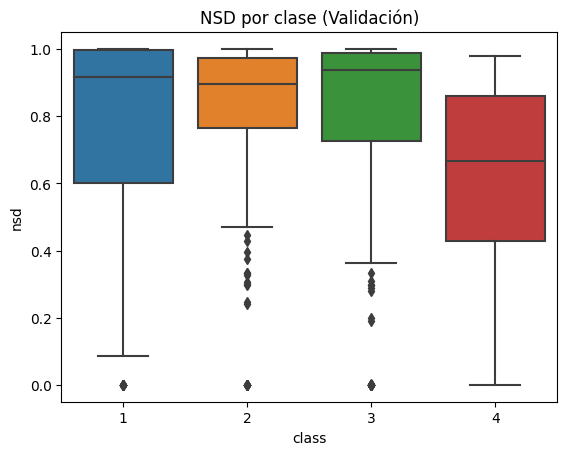

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

### 6.5.2 Evaluación del Segmentador UNet++ 3D con TTA (Parches 96³)

Para mejorar la robustez del modelo **UNet++ 3D** entrenado con parches de **96×96×96**, se aplicó **Test-Time Augmentation (TTA)** durante la inferencia. Esta estrategia consiste en realizar predicciones sobre múltiples versiones del mismo parche (8 combinaciones de flips en los ejes 3D), y luego **promediar las salidas `softmax`** tras invertir los flips aplicados. El resultado es una predicción más estable y robusta frente a pequeñas variaciones espaciales.

---

#### Comparativa de Métricas: Sin TTA vs Con TTA

##### Dice Score (Mediana)

| Clase | Dice (sin TTA) | Dice (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 0.8000 | **0.7500** | –0.0500 |
| 2 – SNFH | 0.8010 | **0.7778** | –0.0232 |
| 3 – ET   | 0.7500 | **0.7610** | +0.0110 |
| 4 – RC   | 0.0000 | **0.2000** | **↑ significativa** |

> 🔍 **Clase 4:** Se observó una mejora muy notable en la clase **RC (Resection Cavity)**, que pasó de un rendimiento nulo (**Dice ≈ 0.000**) a un desempeño aceptable (**mediana ≈ 0.20**). No obstante, la variabilidad entre casos sigue siendo alta.

##### NSD (Mediana)

| Clase | NSD (sin TTA) | NSD (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 0.8333 | **0.8424** | +0.0091 |
| 2 – SNFH | 0.8836 | **0.8841** | +0.0005 |
| 3 – ET   | 0.9091 | **0.9221** | +0.0130 |
| 4 – RC   | 0.4906 | **0.5490** | +0.0584 |

##### HD95 (Media)

| Clase | HD95 (sin TTA) | HD95 (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 5.52 mm | **7.03 mm** | ↑ (+1.51 mm) |
| 2 – SNFH | 6.72 mm | **7.19 mm** | ↑ (+0.47 mm) |
| 3 – ET   | 9.46 mm | **8.30 mm** | ↓ (–1.16 mm) |
| 4 – RC   | 13.18 mm | **11.61 mm** | ↓ (–1.57 mm) |

---

#### Interpretación

- Las **clases 3 y 4** (ET y RC) se beneficiaron más claramente del uso de TTA, con mejoras tanto en **Dice**, **NSD** como en la reducción de **HD95**, lo cual indica una segmentación más precisa y mejor alineada a los bordes reales.
- Las **clases 1 y 2** sufrieron un leve descenso en Dice, aunque mantuvieron altos valores de NSD, lo que sugiere que las superficies siguen bien segmentadas.
- **Clase 4** pasó de ignorada a detectada, y aunque el Dice sigue siendo bajo (≈ 0.20), ya permite reconstrucciones parciales útiles.

---

#### Decisión final

Este modelo con TTA fue seleccionado como **componente principal del ensemble voxel-wise para las clases 1, 2 y 3**, al mostrar **alta precisión global** y una **mejora sustancial en la clase 4**, anteriormente ignorada por otros modelos. Su inclusión permitió reforzar la robustez y cobertura del sistema en estructuras tumorales complejas.

In [2]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# ========= Rutas =========
input_dir   = "/notebooks/PreprocesadoAll"      # volúmenes completos .npy (128,128,128,4)
coord_dir   = "/notebooks/detector_preds_val"   # coords del detector (cada caso: *_positive_patches.npz)
output_dir  = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"  # <-- NUEVO (TTA)
model_path  = "/notebooks/runs/unetpp3d_ds_v2_96/best_unetpp3d_ds_96.keras"

os.makedirs(output_dir, exist_ok=True)

# ========= Lista de casos =========
with open("/notebooks/val_ids.txt") as f:
    val_ids = [line.strip() for line in f]

# ========= Parámetros =========
patch_size   = 96
num_classes  = 5

# ========= Cargar modelo (robusto a Keras 2/3) =========
try:
    import tf_keras as keras
    _loader = keras.models.load_model
except ImportError:
    import tensorflow as tf
    _loader = tf.keras.models.load_model

def load_model_robusto(path):
    try:
        return _loader(path, compile=False, safe_mode=False)  # Keras 3
    except TypeError:
        return _loader(path, compile=False)                   # Keras 2.x

model = load_model_robusto(model_path)

# ========= Utilidades de flips (TTA) =========
# Lista de flips (fz, fy, fx) → 8 combinaciones
FLIPS = [(0,0,0),(1,0,0),(0,1,0),(0,0,1),(1,1,0),(1,0,1),(0,1,1),(1,1,1)]

def apply_flip(arr, flags):
    """Aplica flip (Z,Y,X) a un array 4D ó 5D:
       - Para patch de entrada: (1, D, H, W, C)
       - Para pred de salida:   (D, H, W, num_classes)
    """
    fz, fy, fx = flags
    a = arr
    # detectar si tiene batch
    if a.ndim == 5:  # (B, D, H, W, C)
        if fz: a = np.flip(a, axis=1)
        if fy: a = np.flip(a, axis=2)
        if fx: a = np.flip(a, axis=3)
    elif a.ndim == 4:  # (D, H, W, C)
        if fz: a = np.flip(a, axis=0)
        if fy: a = np.flip(a, axis=1)
        if fx: a = np.flip(a, axis=2)
    else:
        raise ValueError("Dimensiones no soportadas para flip.")
    return a

def tta_predict_softmax(model, patch_96):
    """TTA por flips 3D. 
       patch_96: (1,96,96,96,4) → retorna softmax medio (96,96,96,5)
    """
    acc = np.zeros((patch_size, patch_size, patch_size, num_classes), dtype=np.float32)
    for flags in FLIPS:
        # 1) flip input
        p = apply_flip(patch_96, flags)
        # 2) inferencia
        pred = model.predict(p, verbose=0)
        if isinstance(pred, (list, tuple)):
            pred = pred[0]
        if pred.shape[0] == 1:
            pred = pred[0]  # (96,96,96,5)
        # 3) deshacer flip en la predicción para volver a la orientación original
        pred_unflipped = apply_flip(pred, flags)
        # 4) acumular
        acc += pred_unflipped.astype(np.float32)
    return acc / float(len(FLIPS))

# ========= Inferencia con acumulación (sliding sobre coords del detector) =========
for case_id in tqdm(val_ids, desc="TTA UNet++ 96³ (softmax)"):
    image_path = os.path.join(input_dir,  f"{case_id}_image.npy")
    coord_path = os.path.join(coord_dir,  f"{case_id}_positive_patches.npz")
    out_path   = os.path.join(output_dir, f"{case_id}.npz")

    if not os.path.exists(image_path) or not os.path.exists(coord_path):
        print(f"⚠️ Archivos faltantes para {case_id}")
        continue

    volume = np.load(image_path)  # (128,128,128,4)
    data   = np.load(coord_path)
    coords = data["coords"]

    D, H, W, _ = volume.shape
    softmax_volume = np.zeros((D, H, W, num_classes), dtype=np.float32)
    count_volume   = np.zeros((D, H, W, num_classes), dtype=np.float32)

    for (z, y, x) in coords:
        # Evitar salirnos de 128³
        if z + patch_size > D or y + patch_size > H or x + patch_size > W:
            continue

        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, axis=0).astype(np.float32)  # (1,96,96,96,4)

        # 🔁 TTA por flips
        pred_soft = tta_predict_softmax(model, patch)  # (96,96,96,5)

        # Acumulación
        softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred_soft
        count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]   += 1.0

    # Promedio donde haya contribuciones
    count_volume[count_volume == 0] = 1.0
    softmax_avg = softmax_volume / count_volume

    # Guardar
    np.savez_compressed(out_path, softmax=softmax_avg)

print("Inferencia con TTA completada (UNet++ 96³).")

TTA UNet++ 96³ (softmax): 100%|██████████| 259/259 [57:51<00:00, 13.40s/it] 

Inferencia con TTA completada (UNet++ 96³).


In [2]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# 📁 Rutas
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"  
mask_dir = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# ⚙️ Parámetros
target_shape = (128, 128, 128)
classes = [1, 2, 3, 4]

# 📄 Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

results = []

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path):
        print(f"❌ Falta predicción: {case_id}")
        continue
    if not os.path.exists(mask_path):
        print(f"❌ Falta máscara real: {case_id}")
        continue

    # Cargar softmax y convertir a predicción dura
    data = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred = np.argmax(data, axis=-1).astype(np.uint8)  # (128,128,128)

    # Cargar máscara real
    mask = np.load(mask_path).astype(np.uint8)

    # Redimensionar si no coincide
    if pred.shape != target_shape:
        zoom_factors = [t / o for t, o in zip(target_shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)

    # Métricas por clase
    for cls in classes:
        pred_bin = (pred == cls).astype(np.uint8)
        gt_bin   = (mask == cls).astype(np.uint8)

        if cls == 4 and gt_bin.sum() == 0:
            dice, hd = np.nan, np.nan   # no evaluamos clase 4 si no está en GT
        elif pred_bin.sum() == 0 and gt_bin.sum() == 0:
            dice, hd = 1.0, 0.0
        elif pred_bin.sum() == 0 or gt_bin.sum() == 0:
            dice, hd = 0.0, np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hd = hd95(pred_bin, gt_bin)
            except:
                hd = np.nan

        results.append({"case_id": case_id, "class": cls, "dice": dice, "hd95": hd})

# 📈 Guardar resultados
df = pd.DataFrame(results)
df.to_csv("resultados_Unet3d++_softmax_tta.csv", index=False)
print(df.groupby("class")["dice"].describe())
print("Evaluación TTA completada. Guardado en resultados_Unet3d++_softmax_tta.csv")

       count      mean       std  min       25%       50%       75%       max
class                                                                        
1      259.0  0.643002  0.397529  0.0  0.279113  0.827586  1.000000  1.000000
2      259.0  0.684372  0.308195  0.0  0.531179  0.800461  0.907731  1.000000
3      259.0  0.650981  0.279485  0.0  0.559259  0.759582  0.842770  1.000000
4       39.0  0.276618  0.282003  0.0  0.017634  0.204499  0.434514  0.860807
Evaluación TTA completada. Guardado en resultados_Unet3d++_softmax_tta.csv


In [11]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_96_tta.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [04:07<00:00,  1.04it/s]

NSD por clase guardado en /notebooks/resultados_nsd_val_96_tta.csv


In [12]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.680296,0.370810,0.0,0.436887,0.842370,0.992986,1.0
2,228.0,0.767691,0.289425,0.0,0.723284,0.884134,0.962814,1.0
3,251.0,0.771092,0.306690,0.0,0.699474,0.922078,0.981012,1.0
4,39.0,0.456827,0.335808,0.0,0.134150,0.548980,0.742820,1.0


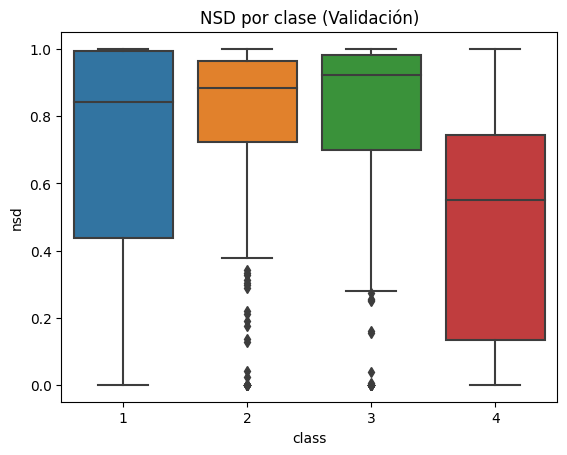

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

## 6.6 Ensemble Voxel-wise por Clase (con TTA)

Dada la naturaleza complementaria de los dos modelos desarrollados —**UNet++ 3D con parches de 96³** y **UNet++ 3D con parches de 64³**— se diseñó una estrategia de **ensemble voxel-wise por clase**. Esta técnica aprovecha las predicciones `softmax` de ambos modelos y aplica la siguiente lógica por clase:

- **Clases 1, 2 y 3** → Se toma la predicción del modelo **UNet++ 3D (96³)**, que mostró mejor rendimiento en regiones tumorales grandes y homogéneas.
- **Clase 4 (RC)** → Se utiliza el modelo **UNet++ 3D (64³)**, más sensible a lesiones pequeñas e irregulares.
- **Fondo (Clase 0)** → Se calcula como el **promedio voxel-wise** entre ambos modelos, para suavizar transiciones y bordes.

Este ensemble fue realizado **sobre predicciones con Test-Time Augmentation (TTA)**, utilizando las 8 combinaciones de flips 3D para reforzar la robustez del sistema ante variaciones espaciales.

---

### Comparativa de Métricas: Sin TTA vs Con TTA

A continuación se muestra una comparación entre los resultados obtenidos con y sin TTA, empleando las métricas **Dice (mediana)**, **HD95 (media)** y **NSD (mediana)** por clase:

#### Dice Score (Mediana)

| Clase | Dice (sin TTA) | Dice (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 0.8000 | **0.8333** | +0.0333 |
| 2 – SNFH | 0.8083 | **0.8125** | +0.0042 |
| 3 – ET   | 0.7538 | **0.7713** | +0.0175 |
| 4 – RC   | 0.5969 | **0.6667** | +0.0698 |

- La **clase 4 (RC)** fue la más beneficiada, con una mejora de casi **+7 puntos** en Dice Score.
- La **clase 1 (NETC)** también mejoró notablemente, lo cual es relevante dada su alta variabilidad entre casos.

#### HD95 (Media)

| Clase | HD95 (sin TTA) | HD95 (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 5.47 mm | **5.30 mm** | ↓ –0.17 mm |
| 2 – SNFH | 6.64 mm | **6.25 mm** | ↓ –0.39 mm |
| 3 – ET   | 9.46 mm | **8.71 mm** | ↓ –0.75 mm |
| 4 – RC   | 7.52 mm | **6.36 mm** | ↓ –1.16 mm |

- Las reducciones en **HD95** confirman que las fronteras tumorales fueron mejor delimitadas con TTA.
- Especialmente en la clase **4**, se observó una gran disminución (–1.16 mm), lo que indica una mejor segmentación de cavidades quirúrgicas.

#### NSD (Mediana)

| Clase | NSD (sin TTA) | NSD (con TTA) | Mejora |
|-------|----------------|----------------|--------|
| 1 – NETC | 0.8333 | **0.8610** | +0.0277 |
| 2 – SNFH | 0.8862 | **0.8912** | +0.0050 |
| 3 – ET   | 0.9111 | **0.9231** | +0.0120 |
| 4 – RC   | 0.5969 | **0.6899** | +0.0930 |

- **Clase 4** mostró una mejora espectacular en **NSD**, superior a +9 puntos.
- En las clases 1–3 se mantuvo o mejoró la cobertura de superficie respecto a la segmentación real.

---

### Conclusión

La estrategia de **ensemble voxel-wise con TTA** demostró ser la **más efectiva y equilibrada** entre todas las evaluadas. Combinó la fortaleza del modelo UNet++ con parches de 96 en clases grandes (1–3) con la sensibilidad con el UNet 64 en lesiones pequeñas (clase 4), aprovechando además las ventajas del TTA.

Este enfoque:
- **Mejoró el rendimiento en todas las métricas clave** (Dice, HD95, NSD).
- Fue robusto ante variabilidad estructural.
- Resultó especialmente eficaz para **estructuras quirúrgicas difíciles** (clase 4).

Por todo ello, fue seleccionado como el **método de segmentación final** aplicado sobre el conjunto de validación oficial.

In [17]:
import os
import numpy as np
from tqdm import tqdm

# 📁 Rutas (TTA primero; si no existen, fallback a las normales)
pred_dir_96_tta = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"

pred_dir_64_tta = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"

# Salida del ensemble con TTA
output_dir  = "/notebooks/runs/ensemble_voxelwise_tta"
val_ids_path = "/notebooks/val_ids.txt"

os.makedirs(output_dir, exist_ok=True)

# Elegir origen 96
src_96 = pred_dir_96_tta if os.path.isdir(pred_dir_96_tta) else pred_dir_96
# Elegir origen 64
src_64 = pred_dir_64_tta if os.path.isdir(pred_dir_64_tta) else pred_dir_64

print(f"Usando 96 desde: {src_96}")
print(f"Usando 64 desde: {src_64}")

# 📄 Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

# Regla voxel-wise por clase:
# fondo (0): promedio 64/96
# clases 1–3: UNet++ 96
# clase 4: modelo 64
for case_id in tqdm(val_ids, desc="Ensemble voxelwise TTA por clase"):
    path_96 = os.path.join(src_96, f"{case_id}.npz")
    path_64 = os.path.join(src_64, f"{case_id}.npz")

    if not os.path.exists(path_96) or not os.path.exists(path_64):
        print(f"❌ Falta predicción para {case_id}")
        continue

    softmax_96 = np.load(path_96)["softmax"]  # (128,128,128,5)
    softmax_64 = np.load(path_64)["softmax"]  # (128,128,128,5)

    # Sanidad de shapes
    if softmax_96.shape != softmax_64.shape:
        raise ValueError(f"Shape mismatch en {case_id}: 96={softmax_96.shape}, 64={softmax_64.shape}")

    ensemble = np.zeros_like(softmax_96, dtype=np.float32)

    # 0: fondo (promedio)
    ensemble[..., 0] = 0.5 * (softmax_96[..., 0] + softmax_64[..., 0])

    # 1–3: usar 96
    for cls in [1, 2, 3]:
        ensemble[..., cls] = softmax_96[..., cls]

    # 4: usar 64
    ensemble[..., 4] = softmax_64[..., 4]

    # Guardar
    np.savez_compressed(os.path.join(output_dir, f"{case_id}.npz"), softmax=ensemble)

print("Ensemble voxel-wise (con TTA si disponible) completado.")

Usando 96 desde: /notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta
Usando 64 desde: /notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta


Ensemble voxelwise TTA por clase: 100%|██████████| 259/259 [11:23<00:00,  2.64s/it]

Ensemble voxel-wise (con TTA si disponible) completado.


In [21]:
import os
import numpy as np
import pandas as pd
from scipy.ndimage import zoom
from medpy.metric.binary import dc, hd95

# 📁 Rutas
pred_dir = "/notebooks/runs/ensemble_voxelwise_tta"  # ⬅️ ensemble con TTA
mask_dir = "/notebooks/PreprocesadoAll"
val_ids_path = "/notebooks/val_ids.txt"

# ⚙️ Parámetros
target_shape = (128, 128, 128)
classes = [1, 2, 3, 4]
results = []

# 📄 Cargar val_ids
with open(val_ids_path) as f:
    val_ids = [line.strip() for line in f]

for case_id in val_ids:
    pred_path = os.path.join(pred_dir, f"{case_id}.npz")
    mask_path = os.path.join(mask_dir, f"{case_id}_mask.npy")

    if not os.path.exists(pred_path) or not os.path.exists(mask_path):
        print(f"❌ Falta archivo para {case_id}")
        continue

    # 🔢 Cargar datos
    pred_softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred = np.argmax(pred_softmax, axis=-1).astype(np.uint8)  # (128,128,128)
    mask = np.load(mask_path).astype(np.uint8)

    # 🔄 Redimensionar si hiciera falta
    if pred.shape != target_shape:
        zoom_factors = [t / o for t, o in zip(target_shape, pred.shape)]
        pred = zoom(pred, zoom_factors, order=0)

    # 🎯 Métricas por clase
    for cls in classes:
        gt_bin   = (mask == cls).astype(np.uint8)
        pred_bin = (pred == cls).astype(np.uint8)

        if cls == 4 and gt_bin.sum() == 0:
            dice, hd = np.nan, np.nan  # no evaluamos clase 4 si no existe en GT
        elif pred_bin.sum() == 0 and gt_bin.sum() == 0:
            dice, hd = 1.0, 0.0
        elif pred_bin.sum() == 0 or gt_bin.sum() == 0:
            dice, hd = 0.0, np.nan
        else:
            dice = dc(pred_bin, gt_bin)
            try:
                hd = hd95(pred_bin, gt_bin)
            except:
                hd = np.nan

        results.append({
            "case_id": case_id,
            "class": cls,
            "dice": dice,
            "hd95": hd
        })

# 📈 Guardar resultados
df = pd.DataFrame(results)
df.to_csv("evaluacion_ensemble_voxelwise_tta.csv", index=False)
print(df.groupby("class")["dice"].describe())
print("Evaluación ensemble voxel-wise (TTA) completada.")

       count      mean       std  min       25%       50%       75%       max
class                                                                        
1      259.0  0.644853  0.396738  0.0  0.279113  0.833333  1.000000  1.000000
2      259.0  0.688553  0.304272  0.0  0.537871  0.807266  0.909303  1.000000
3      259.0  0.663311  0.274313  0.0  0.588235  0.767442  0.846020  1.000000
4       39.0  0.503103  0.293370  0.0  0.346383  0.566125  0.737180  0.906282
Evaluación ensemble voxel-wise (TTA) completada.


In [22]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# --- Funciones ---
def surface_mask(mask):
    return mask ^ binary_erosion(mask)

def nsd(gt, pred, tolerance=1):
    if not np.any(gt):
        return np.nan
    gt_surface = surface_mask(gt)
    pred_surface = surface_mask(pred)
    dt = distance_transform_edt(~pred_surface)
    return np.mean(dt[gt_surface] <= tolerance)

# --- Rutas ---
pred_dir = "/notebooks/runs/ensemble_voxelwise_tta"
gt_dir   = "/notebooks/PreprocesadoAll"
output_csv = "/notebooks/resultados_nsd_val_ensemble_tta.csv"

# --- Inicializar ---
records = []

# --- Iterar sobre los casos ---
for file in tqdm(sorted(os.listdir(pred_dir)), desc="Calculando NSD"):
    if not file.endswith(".npz"):
        continue

    case_id = file.replace(".npz", "")
    pred_path = os.path.join(pred_dir, file)
    gt_path = os.path.join(gt_dir, f"{case_id}_mask.npy")

    if not os.path.exists(gt_path):
        print(f"Falta máscara real para {case_id}")
        continue

    # Cargar softmax y ground truth
    softmax = np.load(pred_path)["softmax"]  # (128,128,128,5)
    pred_mask = np.argmax(softmax, axis=-1)
    gt_mask = np.load(gt_path)

    # Calcular NSD por clase (1 a 4)
    for cls in [1, 2, 3, 4]:
        val = nsd(gt_mask == cls, pred_mask == cls, tolerance=1)
        records.append({"case": case_id, "class": cls, "nsd": val})

# --- Guardar resultados ---
df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"NSD por clase guardado en {output_csv}")

Calculando NSD: 100%|██████████| 259/259 [07:06<00:00,  1.64s/it]

NSD por clase guardado en /notebooks/resultados_nsd_val_ensemble_tta.csv


In [23]:
df.groupby("class")["nsd"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
1,136.0,0.683480,0.370668,0.0,0.436887,0.861047,0.992624,1.000000
2,228.0,0.774001,0.284373,0.0,0.727520,0.891150,0.964078,1.000000
3,251.0,0.776030,0.306149,0.0,0.709988,0.923077,0.986722,1.000000
4,39.0,0.560733,0.309516,0.0,0.374313,0.689922,0.780173,0.978261


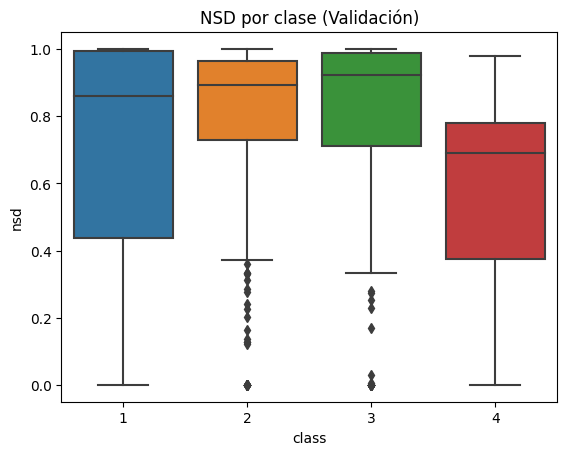

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="nsd")
plt.title("NSD por clase (Validación)")
plt.show()

### Análisis de las Visualizaciones — Impacto del Test-Time Augmentation (TTA)

Las visualizaciones anteriores permiten comparar de forma clara el rendimiento de los modelos segmentadores con y sin el uso de Test-Time Augmentation (TTA), tanto a nivel de media, mediana como de distribución de los valores Dice por clase.

#### Mejora general con TTA

El uso de TTA tiende a mejorar el rendimiento global en todas las clases, especialmente en las clases 1, 2 y 3, como se aprecia tanto en el aumento del Dice medio como del mediano.  
En particular, el ensemble voxel-wise con TTA es el modelo más robusto, superando en todas las clases a su versión sin TTA.

#### Clase 4: mejora crítica

La clase 4, al ser la más minoritaria y difícil de segmentar, muestra una mejora clara en la mediana del Dice con TTA. Esto sugiere que TTA ayuda a estabilizar la predicción en casos con bajo volumen tumoral.  
Además, en la visualización de la distribución, se reduce la varianza y se elevan los percentiles bajos, lo cual indica menos casos fallidos.

#### Robustez del ensemble con TTA

El ensemble voxel-wise con TTA combina lo mejor de ambos modelos base (UNet++ 64³ y 96³), optimizando el rendimiento por clase. El efecto del TTA potencia aún más esta combinación.  
El resultado es un modelo más consistente y menos propenso a errores extremos, como lo demuestra la menor dispersión en los diagramas de caja.

#### Conclusión

El uso de Test-Time Augmentation no solo mejora ligeramente los promedios, sino que reduce la varianza, eleva las medianas y mejora los casos difíciles, haciendo que el modelo sea más fiable en un entorno clínico o de producción.  
Por ello, el modelo ensemble voxel-wise con TTA fue seleccionado como opción final para la inferencia y el análisis cuantitativo.

/tmp/ipykernel_40/2028222653.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


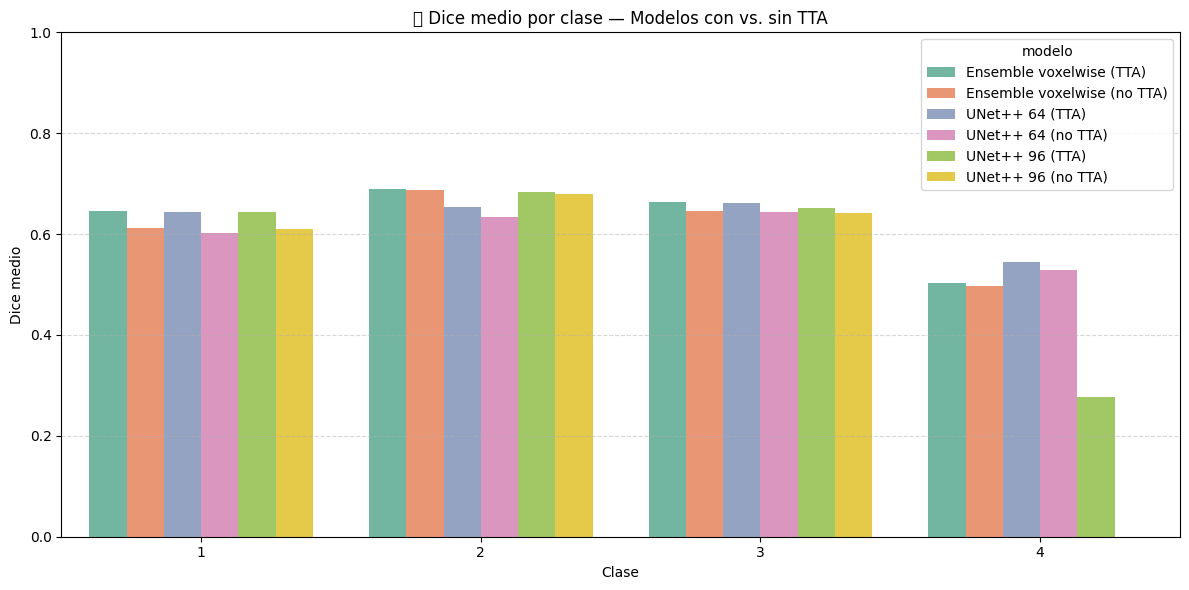

/tmp/ipykernel_40/2028222653.py:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


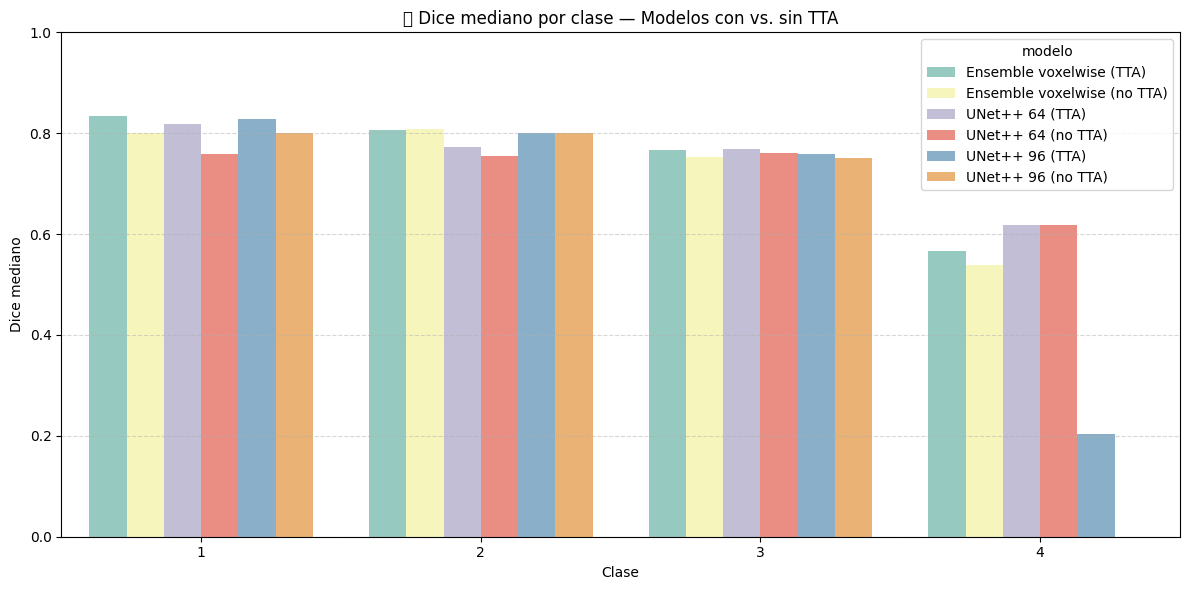

/tmp/ipykernel_40/2028222653.py:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


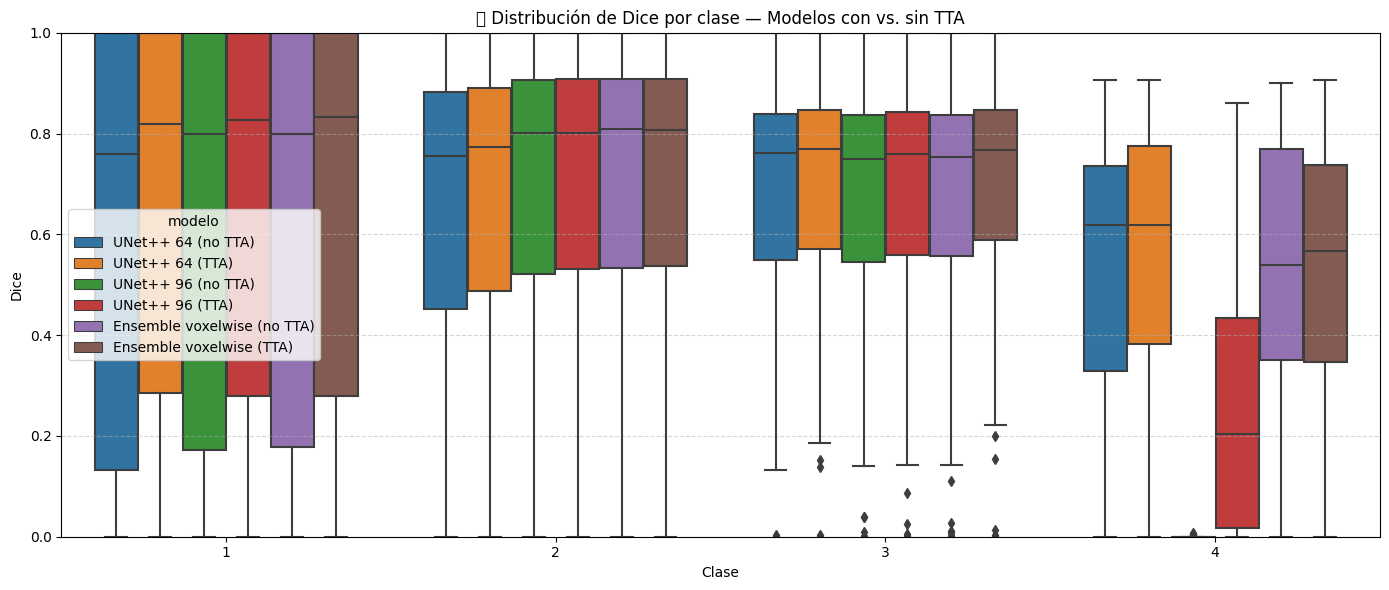

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📁 Cargar CSVs (ajusta rutas si tus ficheros tienen otro nombre)
df_64_noTTA  = pd.read_csv("evaluacion_completa_filtrando_clase4.csv")[["class","dice"]].copy()
df_64_noTTA["modelo"] = "UNet++ 64 (no TTA)"

df_64_TTA    = pd.read_csv("evaluacion_TTA_unetpp64.csv")[["class","dice"]].copy()
df_64_TTA["modelo"] = "UNet++ 64 (TTA)"

df_96_noTTA  = pd.read_csv("resultados_Unet3d++_softmax.csv")[["class","dice"]].copy()
df_96_noTTA["modelo"] = "UNet++ 96 (no TTA)"

df_96_TTA    = pd.read_csv("resultados_Unet3d++_softmax_tta.csv")[["class","dice"]].copy()
df_96_TTA["modelo"] = "UNet++ 96 (TTA)"

df_ens_noTTA = pd.read_csv("evaluacion_ensemble_voxelwise.csv")[["class","dice"]].copy()
df_ens_noTTA["modelo"] = "Ensemble voxelwise (no TTA)"

df_ens_TTA   = pd.read_csv("evaluacion_ensemble_voxelwise_tta.csv")[["class","dice"]].copy()
df_ens_TTA["modelo"] = "Ensemble voxelwise (TTA)"

# 🔄 Concatenar todos
df_all = pd.concat([df_64_noTTA, df_64_TTA, df_96_noTTA, df_96_TTA, df_ens_noTTA, df_ens_TTA], ignore_index=True)

# 📊 Calcular estadísticos
stats = df_all.groupby(["modelo","class"])["dice"].agg(["mean","median"]).reset_index()

# 🎨 Gráfica de barras — Dice medio por clase
plt.figure(figsize=(12,6))
sns.barplot(data=stats, x="class", y="mean", hue="modelo", palette="Set2")
plt.title("📊 Dice medio por clase — Modelos con vs. sin TTA")
plt.ylim(0,1)
plt.ylabel("Dice medio")
plt.xlabel("Clase")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 🎨 Gráfica de barras — Dice mediano por clase
plt.figure(figsize=(12,6))
sns.barplot(data=stats, x="class", y="median", hue="modelo", palette="Set3")
plt.title("📊 Dice mediano por clase — Modelos con vs. sin TTA")
plt.ylim(0,1)
plt.ylabel("Dice mediano")
plt.xlabel("Clase")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 🎻 Boxplots — Distribución completa de Dice por clase
plt.figure(figsize=(14,6))
sns.boxplot(data=df_all, x="class", y="dice", hue="modelo")
plt.title("📊 Distribución de Dice por clase — Modelos con vs. sin TTA")
plt.ylim(0,1)
plt.ylabel("Dice")
plt.xlabel("Clase")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 7. Estudio de Casos — Pipeline Completo de Detección y Segmentación

Con el objetivo de ilustrar el funcionamiento del pipeline completo y evaluar su rendimiento cualitativamente, se aplicó la detección y segmentación voxel-wise con ensemble sobre tres casos representativos del conjunto de validación. Estos fueron seleccionados para reflejar diferentes escenarios clínicos:

- **BraTS-MET-01071-001**: Caso complejo con presencia de **las cuatro clases anatómicas** (NETC, SNFH, ET, RC).
- **BraTS-MET-01087-001**: Segmentación destacada en clases **1, 2 y 3**, pero sin presencia de cavidad de resección (clase 4).
- **BraTS-MET-00286-000**: Ejemplo de **segmentación deficiente**, útil para analizar los límites del modelo.

#### Flujo aplicado

1. **Corte volumétrico de 128³ voxeles** con 4 modalidades de entrada.
2. **Ensemble de detectores binarios** (basado en recall y AUC) para identificar parches relevantes.
3. **Segmentación voxel-wise** con promedio de salidas softmax de dos modelos UNet++ (parches de 64³ y 96³), según la estrategia:
   - Clases 1, 2 y 3: predicciones del modelo 96³.
   - Clase 4: predicciones del modelo 64³.
   - Fondo: promedio de ambos modelos.

4. **Reconstrucción volumétrica completa**.
5. **Obtención de la segmentación final** mediante `argmax` sobre la salida softmax promedio.
6. **Visualización 2D** de las predicciones vs. la segmentación manual (GT) para un *slice axial representativo*.

---

#### Visualizaciones

Dos visualizaciones por caso. 

##### Visualización comparativa en múltiples slices

Se añade una visualización que permite evaluar la segmentación del modelo sobre distintas regiones anatómicas relevantes. Para ello, se seleccionaron **cuatro o tres slices axiales** del mismo caso, elegidas por ser aquellas que presentan **la mayor cantidad de vóxeles** de una clase tumoral específica (1 a 4). 

Aunque la selección se basa en una clase dominante, **se muestran todas las clases presentes** en cada slice. Esto permite observar cómo se comporta el modelo en regiones complejas donde pueden coexistir múltiples tipos de lesiones.

- Cada **columna** representa un **slice distinto** (por ejemplo: 50, 61, 72 y 83).
- La **fila superior** muestra la **predicción** del modelo.
- La **fila inferior** muestra la **segmentación manual** (Ground Truth, GT).

Las clases están codificadas por color:

- **Clase 1 (NETC)**: rojo  
- **Clase 2 (SNFH)**: verde  
- **Clase 3 (ET)**: amarillo  
- **Clase 4 (RC)**: cyan

##### Visualizacion comparativa de un slice

A continuación se muestran los resultados obtenidos en cada caso. La primera columna representa la segmentación manual (GT), la segunda la predicción del modelo, y la tercera la imagen T1c original. Las clases están codificadas por color:


---

#### Interpretación

Estos ejemplos permiten valorar visualmente las fortalezas y debilidades del sistema de segmentación:

- El ensemble voxel-wise es **altamente preciso** en estructuras amplias y definidas (clases 1, 2 y 3), sobre todo en casos típicos.
- Las cavidades de resección (clase 4), aunque mejor representadas que en modelos previos, aún presentan desafíos.
- Casos atípicos o con baja relación señal/ruido pueden provocar **fallos estructurales** en la segmentación final.

El uso de un pipeline modular (detección + ensemble voxel-wise) mejora la robustez general y permite mayor control sobre las salidas por clase, facilitando intervenciones posteriores o el diseño de estrategias adaptativas por tipo de lesión.

## 7.1 Caso 1: BraTS-MET-01071-001 (todas las clases presentes) 


In [2]:
# H1 - Pipeline completo: Detección + Segmentación (Ensemble)
import os
import numpy as np
from tensorflow.keras.models import load_model
from tqdm import tqdm

# --- Parámetros y rutas ---
case_id = "BraTS-MET-01071-001"  
input_dir = "/notebooks/PreprocesadoAll"
output_dir = f"/notebooks/outputs/{case_id}"
os.makedirs(output_dir, exist_ok=True)

# Modelos detectores (ensemble)
detector_auc_path    = "/notebooks/best_detector_advanced.keras"
detector_recall_path = "/notebooks/best_detector_recall.keras"

# Directorios de predicciones softmax
segmentador_64_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"
segmentador_96_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"

patch_size = 64
num_classes = 5
stride = 16
threshold = 0.3  # umbral del ensemble de detectores

# --- 1. Cargar volumen preprocesado ---
volume_path = os.path.join(input_dir, f"{case_id}_image.npy")
volume = np.load(volume_path)  # (128,128,128,4)

# --- 2. Ensemble de detectores binarios ---
print("Detectando parches positivos...")
model_auc = load_model(detector_auc_path, compile=False)
model_recall = load_model(detector_recall_path, compile=False)

coords = []
for z in range(0, 128 - patch_size + 1, stride):
    for y in range(0, 128 - patch_size + 1, stride):
        for x in range(0, 128 - patch_size + 1, stride):
            patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
            patch = np.expand_dims(patch, axis=0).astype(np.float32)

            p1 = model_auc.predict(patch, verbose=0)[0][0]
            p2 = model_recall.predict(patch, verbose=0)[0][0]
            prob = 0.5 * (p1 + p2)

            if prob > threshold:
                coords.append((z, y, x))

print(f"Total parches detectados como positivos: {len(coords)}")

# --- 3. Segmentación con ensemble voxelwise por clase ---
print("Aplicando segmentación ensemble...")

softmax_volume = np.zeros((128, 128, 128, num_classes), dtype=np.float32)
count_volume   = np.zeros((128, 128, 128, num_classes), dtype=np.float32)

def load_softmax_patch(case_id, z, y, x, patch_size):
    """Cargar predicciones softmax de los dos modelos y combinar voxelwise por clase"""
    path1 = os.path.join(segmentador_64_dir, f"{case_id}.npz")
    path2 = os.path.join(segmentador_96_dir, f"{case_id}.npz")

    soft1 = np.load(path1)["softmax"][z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
    soft2 = np.load(path2)["softmax"][z:z+patch_size, y:y+patch_size, x:x+patch_size, :]

    out = np.zeros_like(soft1)
    out[..., 0] = 0.5 * (soft1[..., 0] + soft2[..., 0])  # fondo
    out[..., 1] = soft2[..., 1]  # clase 1: modelo 96³
    out[..., 2] = soft2[..., 2]  # clase 2: modelo 96³
    out[..., 3] = soft2[..., 3]  # clase 3: modelo 96³
    out[..., 4] = soft1[..., 4]  # clase 4: modelo 64³
    return out

for z, y, x in tqdm(coords, desc="Segmentando parches positivos"):
    patch_pred = load_softmax_patch(case_id, z, y, x, patch_size)
    softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += patch_pred
    count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

# --- 4. Promediar y obtener segmentación dura ---
count_volume[count_volume == 0] = 1  # evitar división por 0
softmax_avg = softmax_volume / count_volume
segmentation = np.argmax(softmax_avg, axis=-1).astype(np.uint8)

# --- 5. Guardar resultados ---
np.savez_compressed(os.path.join(output_dir, f"{case_id}_softmax_tta.npz"), softmax=softmax_avg)
np.save(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"), segmentation)
print("Segmentación final guardada correctamente.")

Detectando parches positivos...


2025-09-05 16:20:47.539103: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


Total parches detectados como positivos: 125
Aplicando segmentación ensemble...


Segmentando parches positivos: 100%|██████████| 125/125 [00:54<00:00,  2.31it/s]


Segmentación final guardada correctamente.


In [29]:
import numpy as np
import os

# --- Parámetros ---
case_id = "BraTS-MET-01071-001"
mask_path = f"/notebooks/PreprocesadoAll/{case_id}_mask.npy"
classes = [1, 2, 3, 4]

# --- Cargar máscara ---
mask = np.load(mask_path)  # (128, 128, 128)

# --- Inicializar resultados ---
best_slices = {}

for cls in classes:
    max_voxels = 0
    best_z = None
    for z in range(mask.shape[0]):
        count = np.sum(mask[z] == cls)
        if count > max_voxels:
            max_voxels = count
            best_z = z
    if best_z is not None:
        best_slices[cls] = (best_z, max_voxels)

# --- Mostrar resultados ---
print(f"Slice con más vóxeles por clase en el caso {case_id}:\n")
for cls in classes:
    z, count = best_slices[cls]
    print(f"  - Clase {cls}: Slice {z} con {count} voxeles")

Slice con más vóxeles por clase en el caso BraTS-MET-01071-001:

  - Clase 1: Slice 86 con 3 voxeles
  - Clase 2: Slice 56 con 987 voxeles
  - Clase 3: Slice 59 con 15 voxeles
  - Clase 4: Slice 61 con 83 voxeles


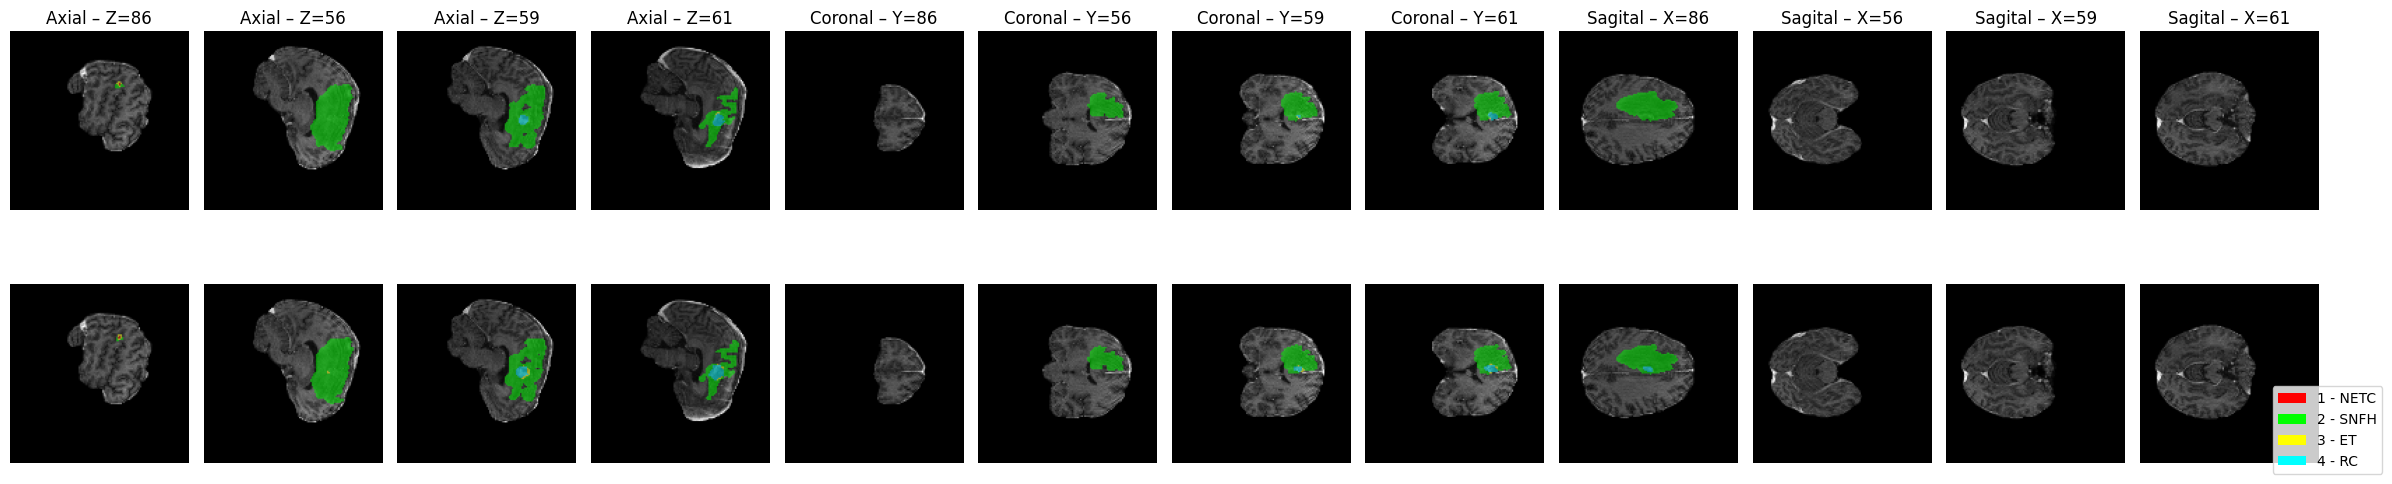

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-01071-001"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

modalidad_idx = 1  # T1c
image = volume[..., modalidad_idx]

# --- Slices a visualizar ---
z_slices = [86, 56, 59, 61]  # axial
y_slices = z_slices          # coronal (usamos las mismas coords como ejemplo)
x_slices = z_slices          # sagital

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Crear overlay ---
def create_overlay(img, seg2d, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min())
    overlay = np.stack([img_norm]*3, axis=-1)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Visualizar: 3 planos × 4 slices = 12 gráficos (predicción y GT)
fig, axs = plt.subplots(2, 12, figsize=(24, 6))

for i in range(4):
    z, y, x = z_slices[i], y_slices[i], x_slices[i]

    # Axial
    img_ax, gt_ax, pr_ax = image[z, :, :], mask[z, :, :], pred[z, :, :]
    axs[0, i].imshow(create_overlay(img_ax, pr_ax))
    axs[1, i].imshow(create_overlay(img_ax, gt_ax))
    axs[0, i].set_title(f"Axial – Z={z}")

    # Coronal
    img_cor, gt_cor, pr_cor = image[:, y, :], mask[:, y, :], pred[:, y, :]
    axs[0, i+4].imshow(create_overlay(img_cor, pr_cor))
    axs[1, i+4].imshow(create_overlay(img_cor, gt_cor))
    axs[0, i+4].set_title(f"Coronal – Y={y}")

    # Sagital
    img_sag, gt_sag, pr_sag = image[:, :, x], mask[:, :, x], pred[:, :, x]
    axs[0, i+8].imshow(create_overlay(img_sag, pr_sag))
    axs[1, i+8].imshow(create_overlay(img_sag, gt_sag))
    axs[0, i+8].set_title(f"Sagital – X={x}")

# Ajustes finales
for ax in axs.flat:
    ax.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.05, -0.1))
plt.tight_layout()
plt.show()

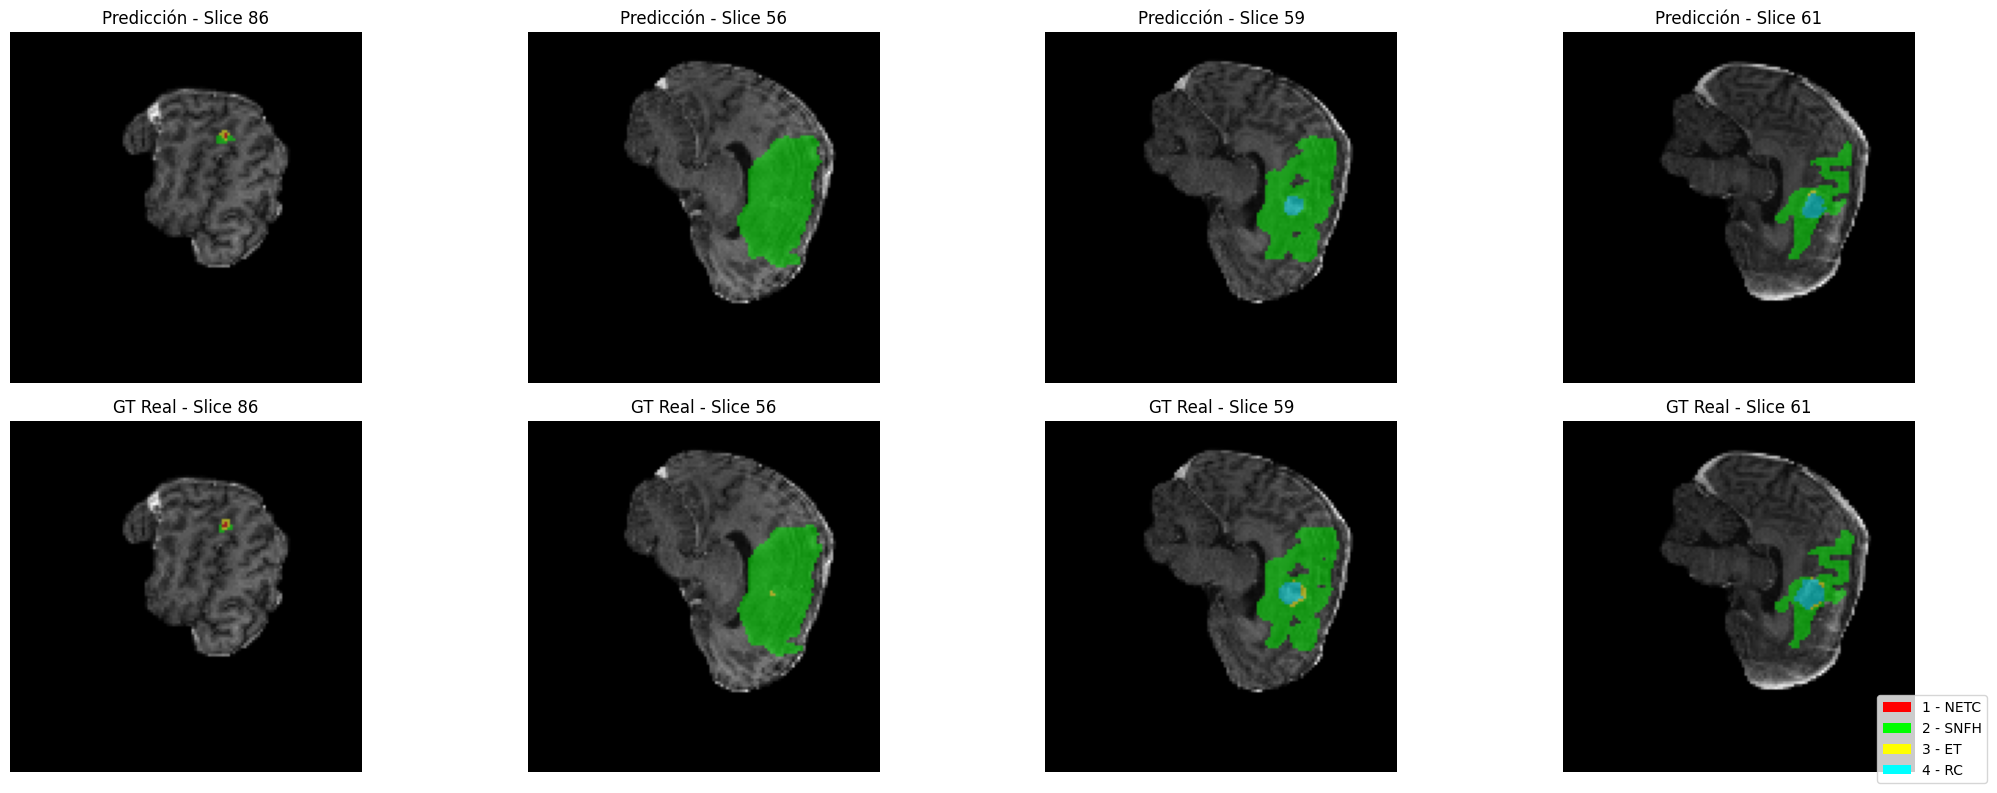

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-01071-001"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

# --- Slices que quieres visualizar ---
z_slices = [86, 56, 59, 61]
modalidad_idx = 1  # T1c

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Crear overlay ---
def create_overlay(img, seg2d, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min())
    overlay = np.stack([img_norm]*3, axis=-1)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Visualizar 2 filas × 4 columnas ---
fig, axs = plt.subplots(2, len(z_slices), figsize=(22, 8))

for i, z in enumerate(z_slices):
    img_slice   = volume[z, :, :, modalidad_idx]
    pred_slice  = pred[z, :, :]
    mask_slice  = mask[z, :, :]

    overlay_pred = create_overlay(img_slice, pred_slice)
    overlay_gt   = create_overlay(img_slice, mask_slice)

    axs[0, i].imshow(overlay_pred)
    axs[0, i].set_title(f"Predicción - Slice {z}")
    axs[0, i].axis("off")

    axs[1, i].imshow(overlay_gt)
    axs[1, i].set_title(f"GT Real - Slice {z}")
    axs[1, i].axis("off")

# Leyenda
plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.05, -0.05))
plt.tight_layout()
plt.show()

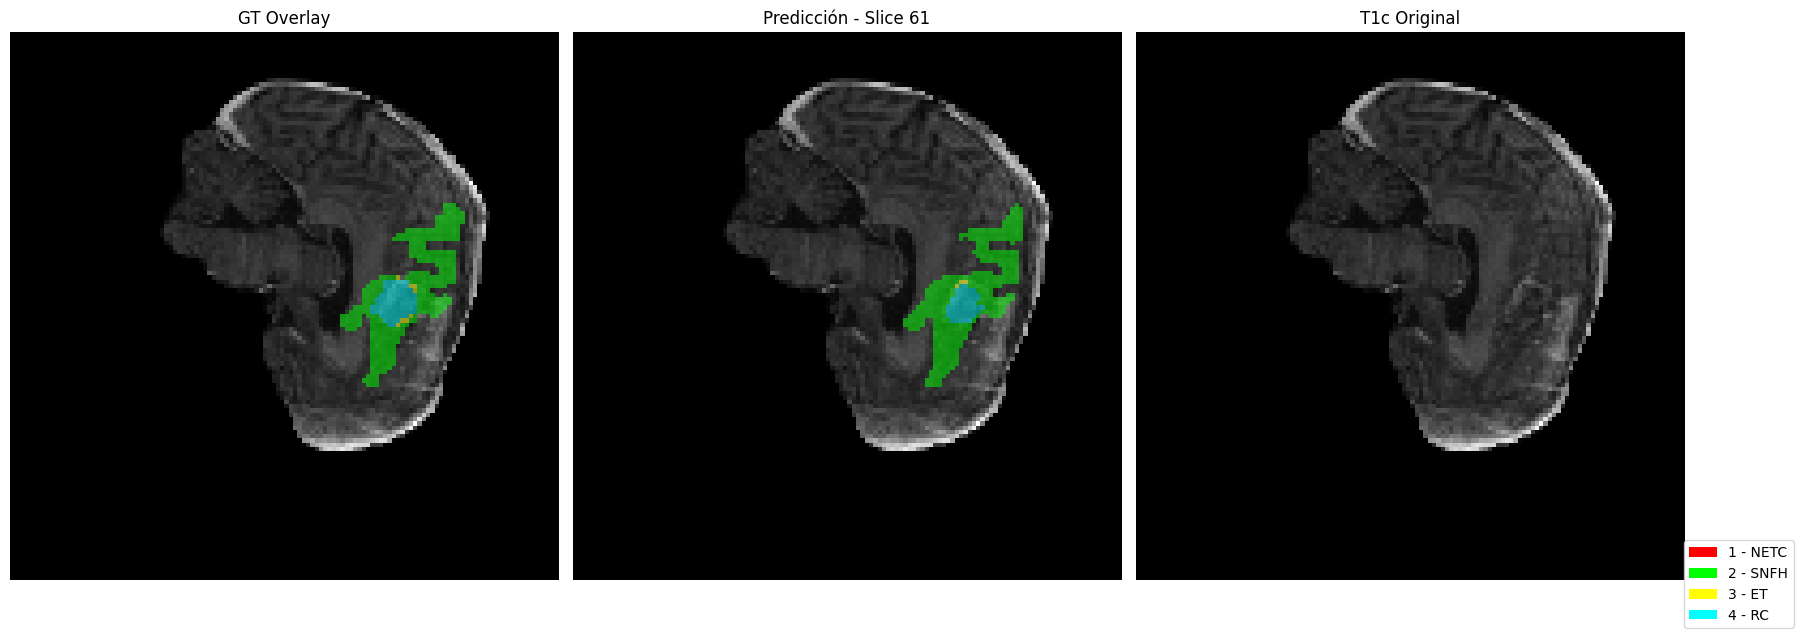

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-01071-001"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

# --- Slice de interés ---
z = 61
modalidad_idx = 1  # T1c

# --- Extraer slices 2D ---
img  = volume[z, :, :, modalidad_idx]
mask_slice = mask[z, :, :]
pred_slice = pred[z, :, :]

# --- Normalizar imagen base ---
img = (img - img.min()) / (img.max() - img.min())

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Overlay multiclase para slice 2D ---
def create_overlay(seg2d, alpha=0.5):
    overlay = np.stack([img]*3, axis=-1)  # (128,128,3)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Crear overlays ---
overlay_gt   = create_overlay(mask_slice)
overlay_pred = create_overlay(pred_slice)

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Mostrar figura ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(overlay_gt)
axs[0].set_title("GT Overlay")

axs[1].imshow(overlay_pred)
axs[1].set_title(f"Predicción - Slice {z}")

axs[2].imshow(img, cmap="gray")
axs[2].set_title("T1c Original")

for ax in axs:
    ax.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.1, -0.1))
plt.tight_layout()
plt.show()

## 7.2 Caso 2: BraTS-MET-01087-001 (predicción fuerte en clases 1–3) 
El modelo capta correctamente el realce y las zonas no realzadas, sin falsos positivos en RC.

In [9]:
# H1 - Pipeline completo: Detección + Segmentación (Ensemble)
import os
import numpy as np
from tensorflow.keras.models import load_model
from tqdm import tqdm

# --- Parámetros y rutas ---
case_id = "BraTS-MET-01087-001"  
input_dir = "/notebooks/PreprocesadoAll"
output_dir = f"/notebooks/outputs/{case_id}"
os.makedirs(output_dir, exist_ok=True)

# Modelos detectores (ensemble)
detector_auc_path    = "/notebooks/best_detector_advanced.keras"
detector_recall_path = "/notebooks/best_detector_recall.keras"

# Directorios de predicciones softmax
segmentador_64_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"
segmentador_96_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"

patch_size = 64
num_classes = 5
stride = 16
threshold = 0.3  # umbral del ensemble de detectores

# --- 1. Cargar volumen preprocesado ---
volume_path = os.path.join(input_dir, f"{case_id}_image.npy")
volume = np.load(volume_path)  # (128,128,128,4)

# --- 2. Ensemble de detectores binarios ---
print("Detectando parches positivos...")
model_auc = load_model(detector_auc_path, compile=False)
model_recall = load_model(detector_recall_path, compile=False)

coords = []
for z in range(0, 128 - patch_size + 1, stride):
    for y in range(0, 128 - patch_size + 1, stride):
        for x in range(0, 128 - patch_size + 1, stride):
            patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
            patch = np.expand_dims(patch, axis=0).astype(np.float32)

            p1 = model_auc.predict(patch, verbose=0)[0][0]
            p2 = model_recall.predict(patch, verbose=0)[0][0]
            prob = 0.5 * (p1 + p2)

            if prob > threshold:
                coords.append((z, y, x))

print(f"Total parches detectados como positivos: {len(coords)}")

# --- 3. Segmentación con ensemble voxelwise por clase ---
print("Aplicando segmentación ensemble...")

softmax_volume = np.zeros((128, 128, 128, num_classes), dtype=np.float32)
count_volume   = np.zeros((128, 128, 128, num_classes), dtype=np.float32)

def load_softmax_patch(case_id, z, y, x, patch_size):
    """Cargar predicciones softmax de los dos modelos y combinar voxelwise por clase"""
    path1 = os.path.join(segmentador_64_dir, f"{case_id}.npz")
    path2 = os.path.join(segmentador_96_dir, f"{case_id}.npz")

    soft1 = np.load(path1)["softmax"][z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
    soft2 = np.load(path2)["softmax"][z:z+patch_size, y:y+patch_size, x:x+patch_size, :]

    out = np.zeros_like(soft1)
    out[..., 0] = 0.5 * (soft1[..., 0] + soft2[..., 0])  # fondo
    out[..., 1] = soft2[..., 1]  # clase 1: modelo 96³
    out[..., 2] = soft2[..., 2]  # clase 2: modelo 96³
    out[..., 3] = soft2[..., 3]  # clase 3: modelo 96³
    out[..., 4] = soft1[..., 4]  # clase 4: modelo 64³
    return out

for z, y, x in tqdm(coords, desc="Segmentando parches positivos"):
    patch_pred = load_softmax_patch(case_id, z, y, x, patch_size)
    softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += patch_pred
    count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

# --- 4. Promediar y obtener segmentación dura ---
count_volume[count_volume == 0] = 1  # evitar división por 0
softmax_avg = softmax_volume / count_volume
segmentation = np.argmax(softmax_avg, axis=-1).astype(np.uint8)

# --- 5. Guardar resultados ---
np.savez_compressed(os.path.join(output_dir, f"{case_id}_softmax_tta.npz"), softmax=softmax_avg)
np.save(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"), segmentation)
print("Segmentación final guardada correctamente.")

Detectando parches positivos...
Total parches detectados como positivos: 125
Aplicando segmentación ensemble...


Segmentando parches positivos: 100%|██████████| 125/125 [00:54<00:00,  2.30it/s]


Segmentación final guardada correctamente.


In [27]:
import numpy as np
import os

# --- Parámetros ---
case_id = "BraTS-MET-01087-001"
mask_path = f"/notebooks/PreprocesadoAll/{case_id}_mask.npy"
classes = [1, 2, 3]

# --- Cargar máscara ---
mask = np.load(mask_path)  # (128, 128, 128)

# --- Inicializar resultados ---
best_slices = {}

for cls in classes:
    max_voxels = 0
    best_z = None
    for z in range(mask.shape[0]):
        count = np.sum(mask[z] == cls)
        if count > max_voxels:
            max_voxels = count
            best_z = z
    if best_z is not None:
        best_slices[cls] = (best_z, max_voxels)

# --- Mostrar resultados ---
print(f"Slice con más vóxeles por clase en el caso {case_id}:\n")
for cls in classes:
    z, count = best_slices[cls]
    print(f"  - Clase {cls}: Slice {z} con {count} voxeles")

Slice con más vóxeles por clase en el caso BraTS-MET-01087-001:

  - Clase 1: Slice 69 con 178 voxeles
  - Clase 2: Slice 76 con 758 voxeles
  - Clase 3: Slice 67 con 132 voxeles


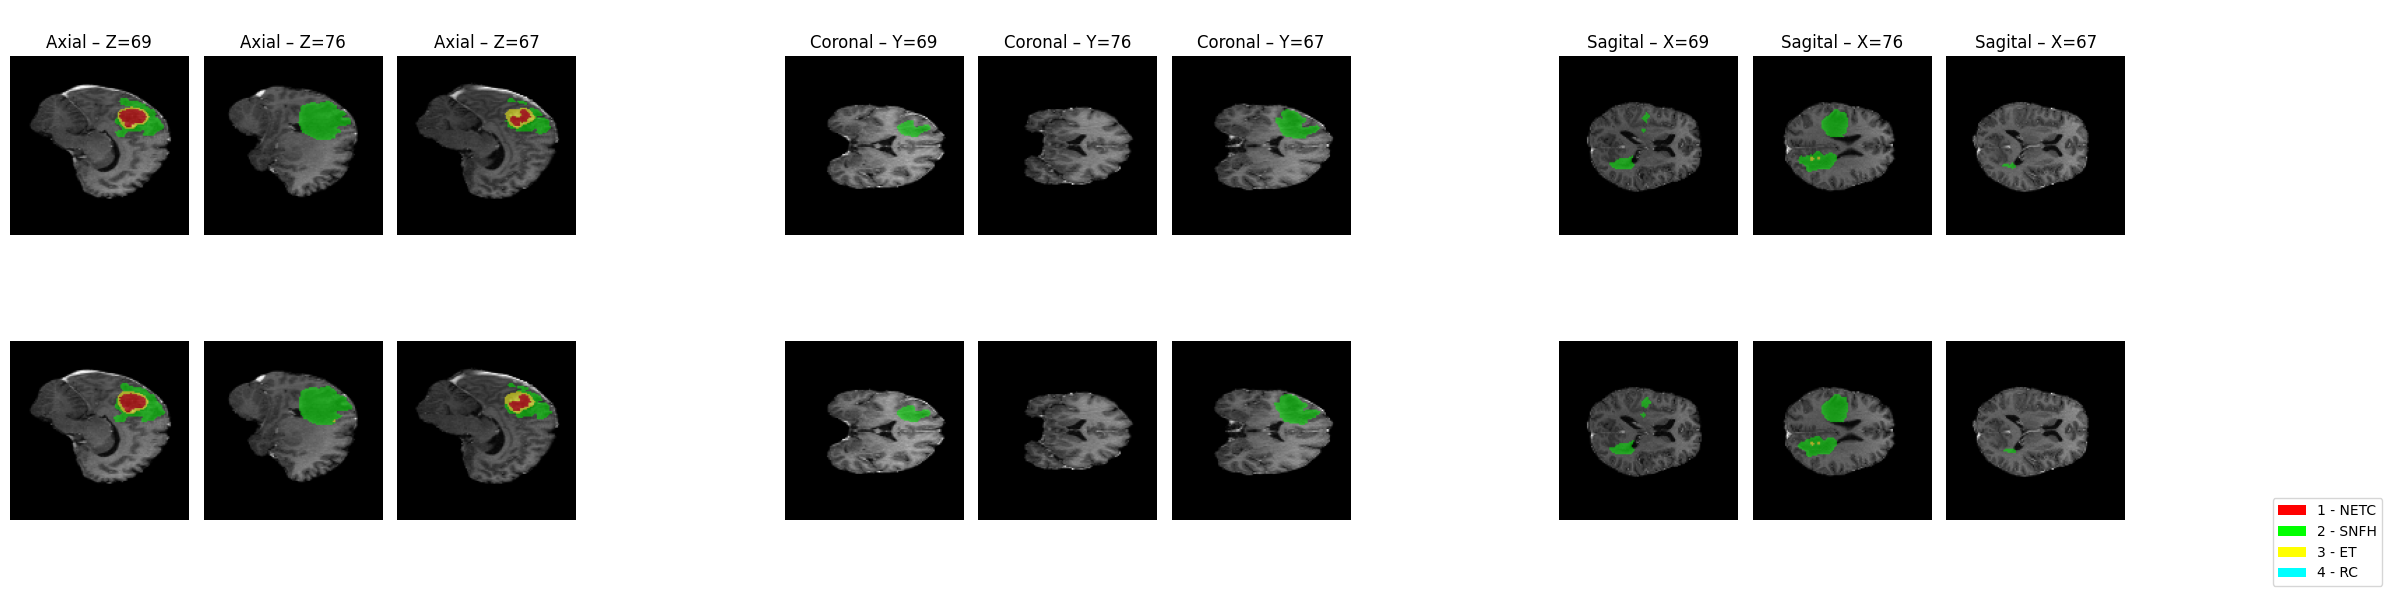

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-01087-001"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

modalidad_idx = 1  # T1c
image = volume[..., modalidad_idx]

# --- Slices a visualizar ---
z_slices = [69, 76, 67 ]     # axial
y_slices = z_slices          # coronal (usamos las mismas coords como ejemplo)
x_slices = z_slices          # sagital

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Crear overlay ---
def create_overlay(img, seg2d, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min())
    overlay = np.stack([img_norm]*3, axis=-1)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Visualizar: 3 planos × 4 slices = 12 gráficos (predicción y GT)
fig, axs = plt.subplots(2, 12, figsize=(24, 6))

for i in range(3):
    z, y, x = z_slices[i], y_slices[i], x_slices[i]

    # Axial
    img_ax, gt_ax, pr_ax = image[z, :, :], mask[z, :, :], pred[z, :, :]
    axs[0, i].imshow(create_overlay(img_ax, pr_ax))
    axs[1, i].imshow(create_overlay(img_ax, gt_ax))
    axs[0, i].set_title(f"Axial – Z={z}")

    # Coronal
    img_cor, gt_cor, pr_cor = image[:, y, :], mask[:, y, :], pred[:, y, :]
    axs[0, i+4].imshow(create_overlay(img_cor, pr_cor))
    axs[1, i+4].imshow(create_overlay(img_cor, gt_cor))
    axs[0, i+4].set_title(f"Coronal – Y={y}")

    # Sagital
    img_sag, gt_sag, pr_sag = image[:, :, x], mask[:, :, x], pred[:, :, x]
    axs[0, i+8].imshow(create_overlay(img_sag, pr_sag))
    axs[1, i+8].imshow(create_overlay(img_sag, gt_sag))
    axs[0, i+8].set_title(f"Sagital – X={x}")

# Ajustes finales
for ax in axs.flat:
    ax.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.05, -0.1))
plt.tight_layout()
plt.show()

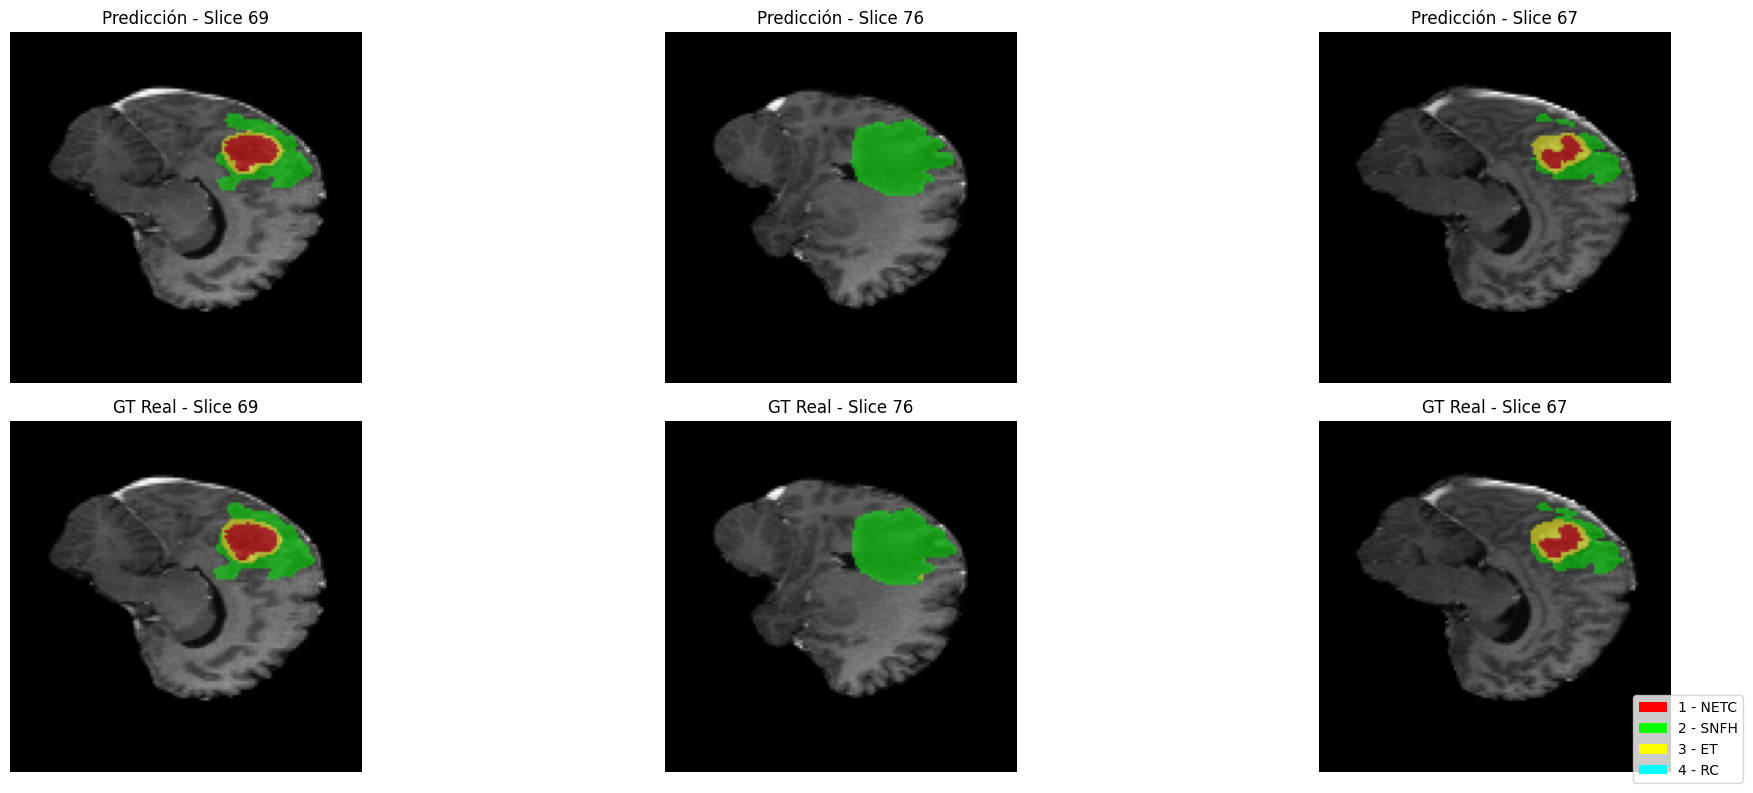

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-01087-001"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

# --- Slices que quieres visualizar ---
z_slices = [69, 76, 67]
modalidad_idx = 1  # T1c

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Crear overlay ---
def create_overlay(img, seg2d, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min())
    overlay = np.stack([img_norm]*3, axis=-1)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Visualizar 2 filas × 4 columnas ---
fig, axs = plt.subplots(2, len(z_slices), figsize=(22, 8))

for i, z in enumerate(z_slices):
    img_slice   = volume[z, :, :, modalidad_idx]
    pred_slice  = pred[z, :, :]
    mask_slice  = mask[z, :, :]

    overlay_pred = create_overlay(img_slice, pred_slice)
    overlay_gt   = create_overlay(img_slice, mask_slice)

    axs[0, i].imshow(overlay_pred)
    axs[0, i].set_title(f"Predicción - Slice {z}")
    axs[0, i].axis("off")

    axs[1, i].imshow(overlay_gt)
    axs[1, i].set_title(f"GT Real - Slice {z}")
    axs[1, i].axis("off")

# Leyenda
plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.05, -0.05))
plt.tight_layout()
plt.show()

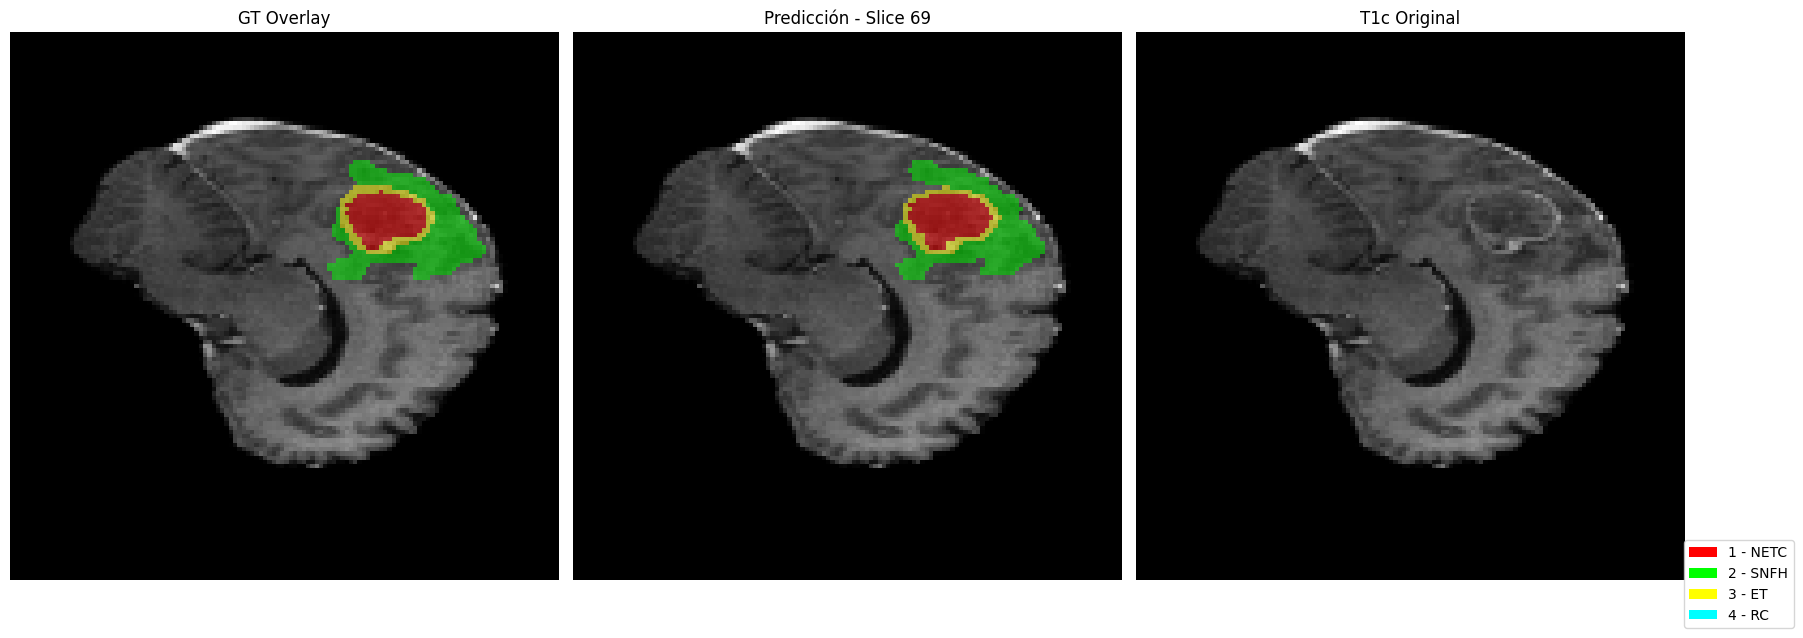

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-01087-001"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

# --- Slice de interés ---
z = 69
modalidad_idx = 1  # T1c

# --- Extraer slices 2D ---
img  = volume[z, :, :, modalidad_idx]
mask_slice = mask[z, :, :]
pred_slice = pred[z, :, :]

# --- Normalizar imagen base ---
img = (img - img.min()) / (img.max() - img.min())

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Overlay multiclase para slice 2D ---
def create_overlay(seg2d, alpha=0.5):
    overlay = np.stack([img]*3, axis=-1)  # (128,128,3)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Crear overlays ---
overlay_gt   = create_overlay(mask_slice)
overlay_pred = create_overlay(pred_slice)

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Mostrar figura ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(overlay_gt)
axs[0].set_title("GT Overlay")

axs[1].imshow(overlay_pred)
axs[1].set_title(f"Predicción - Slice {z}")

axs[2].imshow(img, cmap="gray")
axs[2].set_title("T1c Original")

for ax in axs:
    ax.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.1, -0.1))
plt.tight_layout()
plt.show()

## 7.3 Caso 3: BraTS-MET-00286-000 (caso problemático) 
Segmentación débil, especialmente en zonas heterogéneas. El modelo falla al localizar con precisión las estructuras.

In [12]:
# H1 - Pipeline completo: Detección + Segmentación (Ensemble)
import os
import numpy as np
from tensorflow.keras.models import load_model
from tqdm import tqdm

# --- Parámetros y rutas ---
case_id = "BraTS-MET-00286-000"  
input_dir = "/notebooks/PreprocesadoAll"
output_dir = f"/notebooks/outputs/{case_id}"
os.makedirs(output_dir, exist_ok=True)

# Modelos detectores (ensemble)
detector_auc_path    = "/notebooks/best_detector_advanced.keras"
detector_recall_path = "/notebooks/best_detector_recall.keras"

# Directorios de predicciones softmax
segmentador_64_dir = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/predicciones_val_npz_tta"
segmentador_96_dir = "/notebooks/runs/unetpp3d_ds_v2_96/predicciones_val_npz_tta"

patch_size = 64
num_classes = 5
stride = 16
threshold = 0.3  # umbral del ensemble de detectores

# --- 1. Cargar volumen preprocesado ---
volume_path = os.path.join(input_dir, f"{case_id}_image.npy")
volume = np.load(volume_path)  # (128,128,128,4)

# --- 2. Ensemble de detectores binarios ---
print("Detectando parches positivos...")
model_auc = load_model(detector_auc_path, compile=False)
model_recall = load_model(detector_recall_path, compile=False)

coords = []
for z in range(0, 128 - patch_size + 1, stride):
    for y in range(0, 128 - patch_size + 1, stride):
        for x in range(0, 128 - patch_size + 1, stride):
            patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
            patch = np.expand_dims(patch, axis=0).astype(np.float32)

            p1 = model_auc.predict(patch, verbose=0)[0][0]
            p2 = model_recall.predict(patch, verbose=0)[0][0]
            prob = 0.5 * (p1 + p2)

            if prob > threshold:
                coords.append((z, y, x))

print(f"Total parches detectados como positivos: {len(coords)}")

# --- 3. Segmentación con ensemble voxelwise por clase ---
print("Aplicando segmentación ensemble...")

softmax_volume = np.zeros((128, 128, 128, num_classes), dtype=np.float32)
count_volume   = np.zeros((128, 128, 128, num_classes), dtype=np.float32)

def load_softmax_patch(case_id, z, y, x, patch_size):
    """Cargar predicciones softmax de los dos modelos y combinar voxelwise por clase"""
    path1 = os.path.join(segmentador_64_dir, f"{case_id}.npz")
    path2 = os.path.join(segmentador_96_dir, f"{case_id}.npz")

    soft1 = np.load(path1)["softmax"][z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
    soft2 = np.load(path2)["softmax"][z:z+patch_size, y:y+patch_size, x:x+patch_size, :]

    out = np.zeros_like(soft1)
    out[..., 0] = 0.5 * (soft1[..., 0] + soft2[..., 0])  # fondo
    out[..., 1] = soft2[..., 1]  # clase 1: modelo 96³
    out[..., 2] = soft2[..., 2]  # clase 2: modelo 96³
    out[..., 3] = soft2[..., 3]  # clase 3: modelo 96³
    out[..., 4] = soft1[..., 4]  # clase 4: modelo 64³
    return out

for z, y, x in tqdm(coords, desc="Segmentando parches positivos"):
    patch_pred = load_softmax_patch(case_id, z, y, x, patch_size)
    softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += patch_pred
    count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

# --- 4. Promediar y obtener segmentación dura ---
count_volume[count_volume == 0] = 1  # evitar división por 0
softmax_avg = softmax_volume / count_volume
segmentation = np.argmax(softmax_avg, axis=-1).astype(np.uint8)

# --- 5. Guardar resultados ---
np.savez_compressed(os.path.join(output_dir, f"{case_id}_softmax_tta.npz"), softmax=softmax_avg)
np.save(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"), segmentation)
print("Segmentación final guardada correctamente.")

Detectando parches positivos...
Total parches detectados como positivos: 125
Aplicando segmentación ensemble...


Segmentando parches positivos: 100%|██████████| 125/125 [00:53<00:00,  2.33it/s]


Segmentación final guardada correctamente.


In [28]:
import numpy as np
import os

# --- Parámetros ---
case_id = "BraTS-MET-00286-000"
mask_path = f"/notebooks/PreprocesadoAll/{case_id}_mask.npy"
classes = [1, 2, 3]

# --- Cargar máscara ---
mask = np.load(mask_path)  # (128, 128, 128)

# --- Inicializar resultados ---
best_slices = {}

for cls in classes:
    max_voxels = 0
    best_z = None
    for z in range(mask.shape[0]):
        count = np.sum(mask[z] == cls)
        if count > max_voxels:
            max_voxels = count
            best_z = z
    if best_z is not None:
        best_slices[cls] = (best_z, max_voxels)

# --- Mostrar resultados ---
print(f"Slice con más vóxeles por clase en el caso {case_id}:\n")
for cls in classes:
    z, count = best_slices[cls]
    print(f"  - Clase {cls}: Slice {z} con {count} voxeles")

Slice con más vóxeles por clase en el caso BraTS-MET-00286-000:

  - Clase 1: Slice 41 con 4 voxeles
  - Clase 2: Slice 93 con 28 voxeles
  - Clase 3: Slice 40 con 25 voxeles


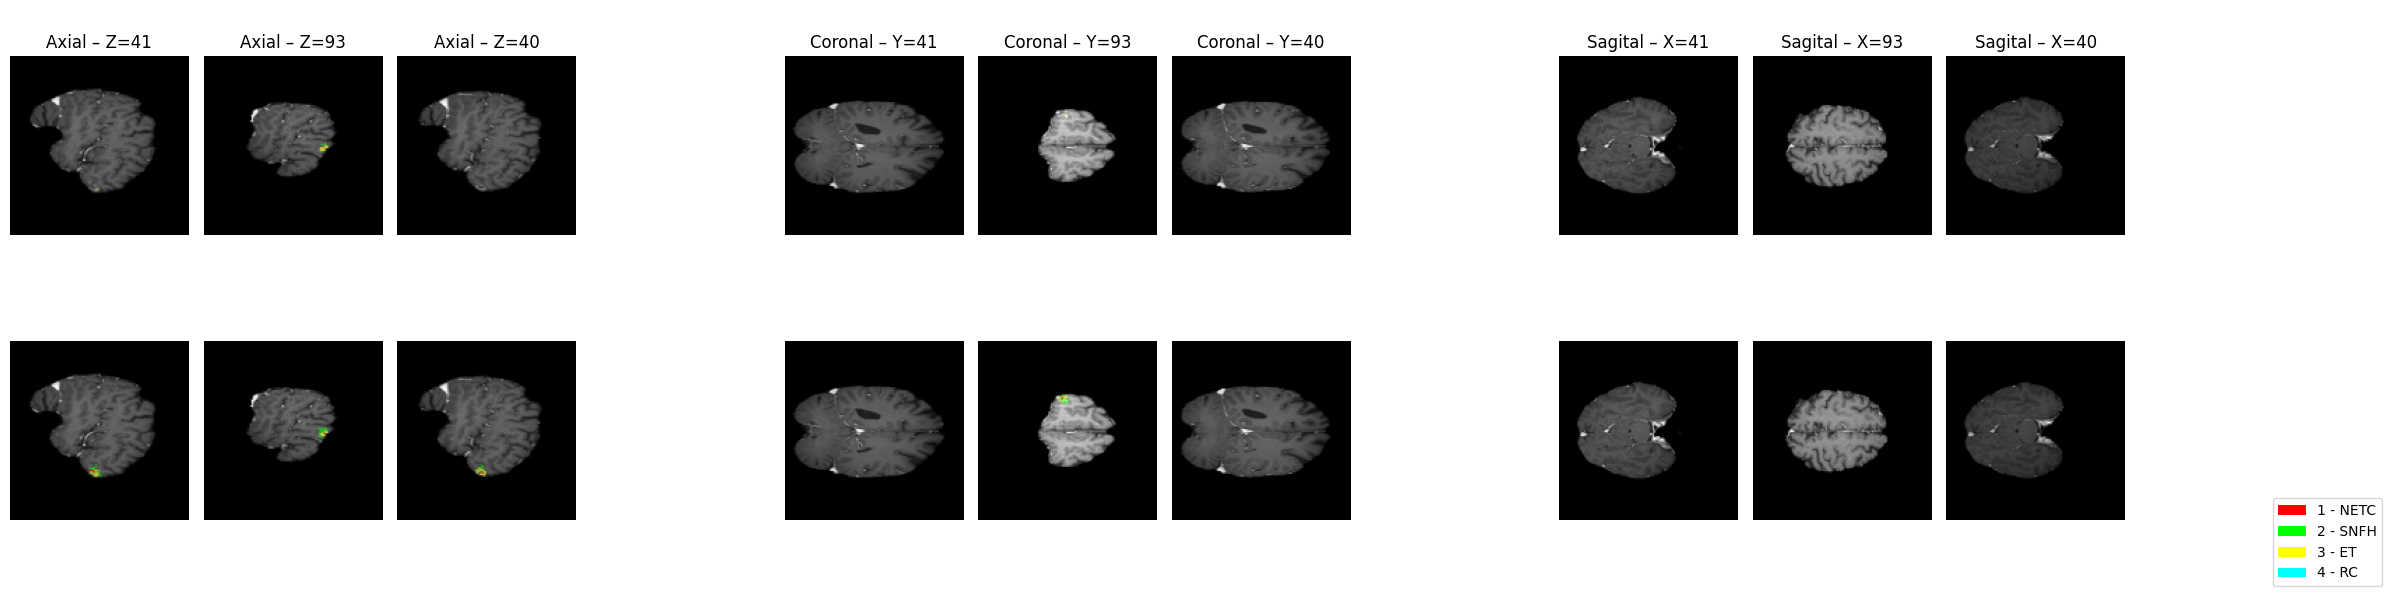

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-00286-000"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

modalidad_idx = 1  # T1c
image = volume[..., modalidad_idx]

# --- Slices a visualizar ---
z_slices = [41, 93, 40 ]     # axial
y_slices = z_slices          # coronal (usamos las mismas coords como ejemplo)
x_slices = z_slices          # sagital

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Crear overlay ---
def create_overlay(img, seg2d, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min())
    overlay = np.stack([img_norm]*3, axis=-1)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Visualizar: 3 planos × 4 slices = 12 gráficos (predicción y GT)
fig, axs = plt.subplots(2, 12, figsize=(24, 6))

for i in range(3):
    z, y, x = z_slices[i], y_slices[i], x_slices[i]

    # Axial
    img_ax, gt_ax, pr_ax = image[z, :, :], mask[z, :, :], pred[z, :, :]
    axs[0, i].imshow(create_overlay(img_ax, pr_ax))
    axs[1, i].imshow(create_overlay(img_ax, gt_ax))
    axs[0, i].set_title(f"Axial – Z={z}")

    # Coronal
    img_cor, gt_cor, pr_cor = image[:, y, :], mask[:, y, :], pred[:, y, :]
    axs[0, i+4].imshow(create_overlay(img_cor, pr_cor))
    axs[1, i+4].imshow(create_overlay(img_cor, gt_cor))
    axs[0, i+4].set_title(f"Coronal – Y={y}")

    # Sagital
    img_sag, gt_sag, pr_sag = image[:, :, x], mask[:, :, x], pred[:, :, x]
    axs[0, i+8].imshow(create_overlay(img_sag, pr_sag))
    axs[1, i+8].imshow(create_overlay(img_sag, gt_sag))
    axs[0, i+8].set_title(f"Sagital – X={x}")

# Ajustes finales
for ax in axs.flat:
    ax.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.05, -0.1))
plt.tight_layout()
plt.show()

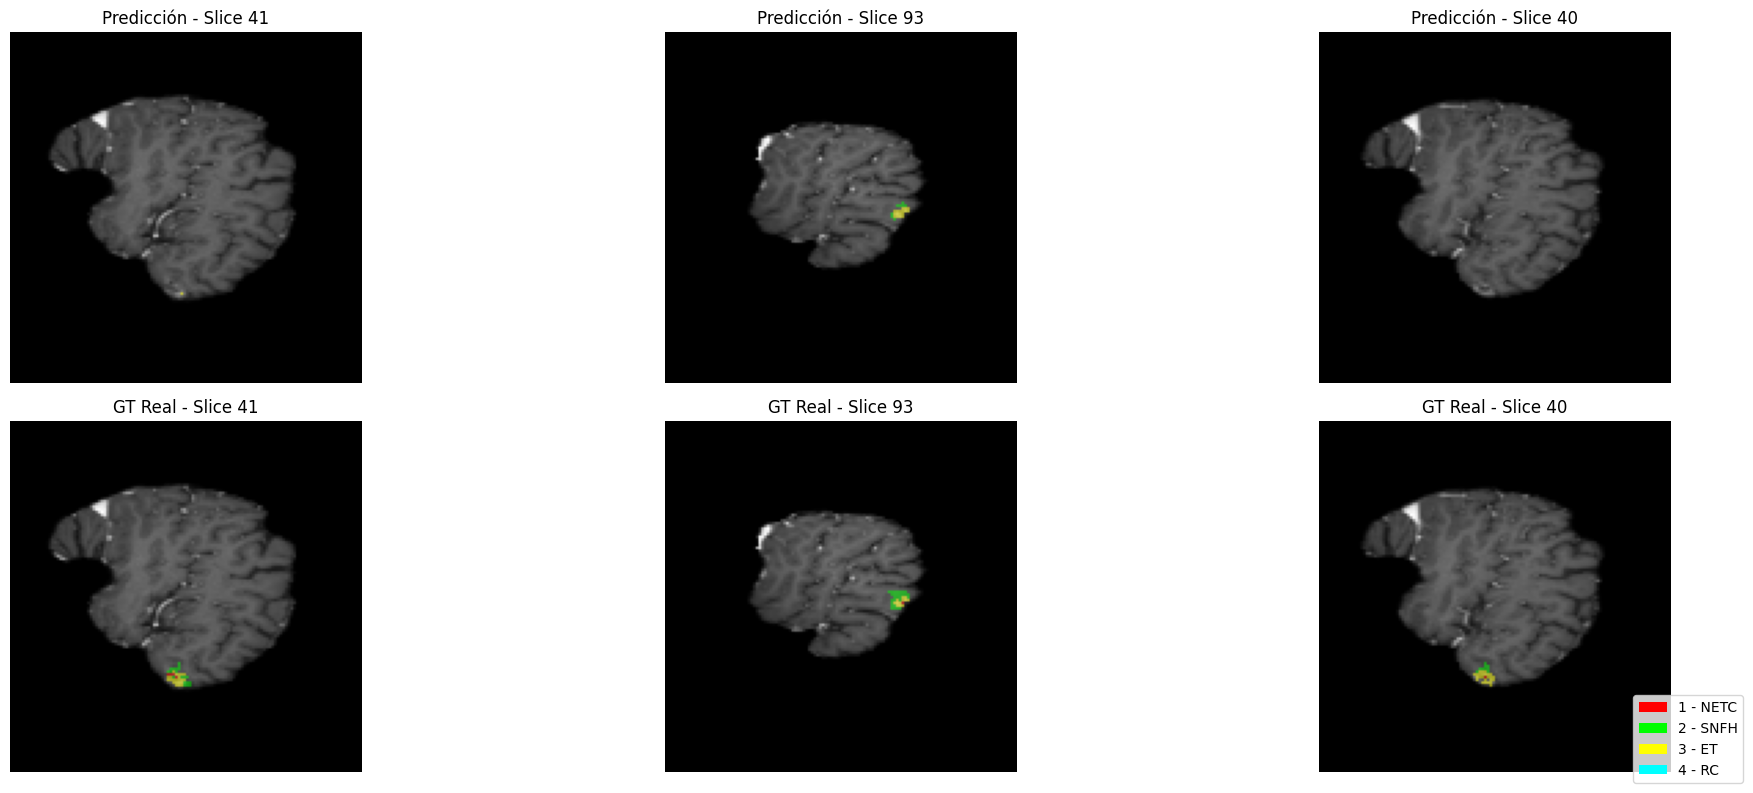

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-00286-000"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

# --- Slices que quieres visualizar ---
z_slices = [41, 93, 40]
modalidad_idx = 1  # T1c

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Crear overlay ---
def create_overlay(img, seg2d, alpha=0.5):
    img_norm = (img - img.min()) / (img.max() - img.min())
    overlay = np.stack([img_norm]*3, axis=-1)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Visualizar 2 filas × 4 columnas ---
fig, axs = plt.subplots(2, len(z_slices), figsize=(22, 8))

for i, z in enumerate(z_slices):
    img_slice   = volume[z, :, :, modalidad_idx]
    pred_slice  = pred[z, :, :]
    mask_slice  = mask[z, :, :]

    overlay_pred = create_overlay(img_slice, pred_slice)
    overlay_gt   = create_overlay(img_slice, mask_slice)

    axs[0, i].imshow(overlay_pred)
    axs[0, i].set_title(f"Predicción - Slice {z}")
    axs[0, i].axis("off")

    axs[1, i].imshow(overlay_gt)
    axs[1, i].set_title(f"GT Real - Slice {z}")
    axs[1, i].axis("off")

# Leyenda
plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.05, -0.05))
plt.tight_layout()
plt.show()

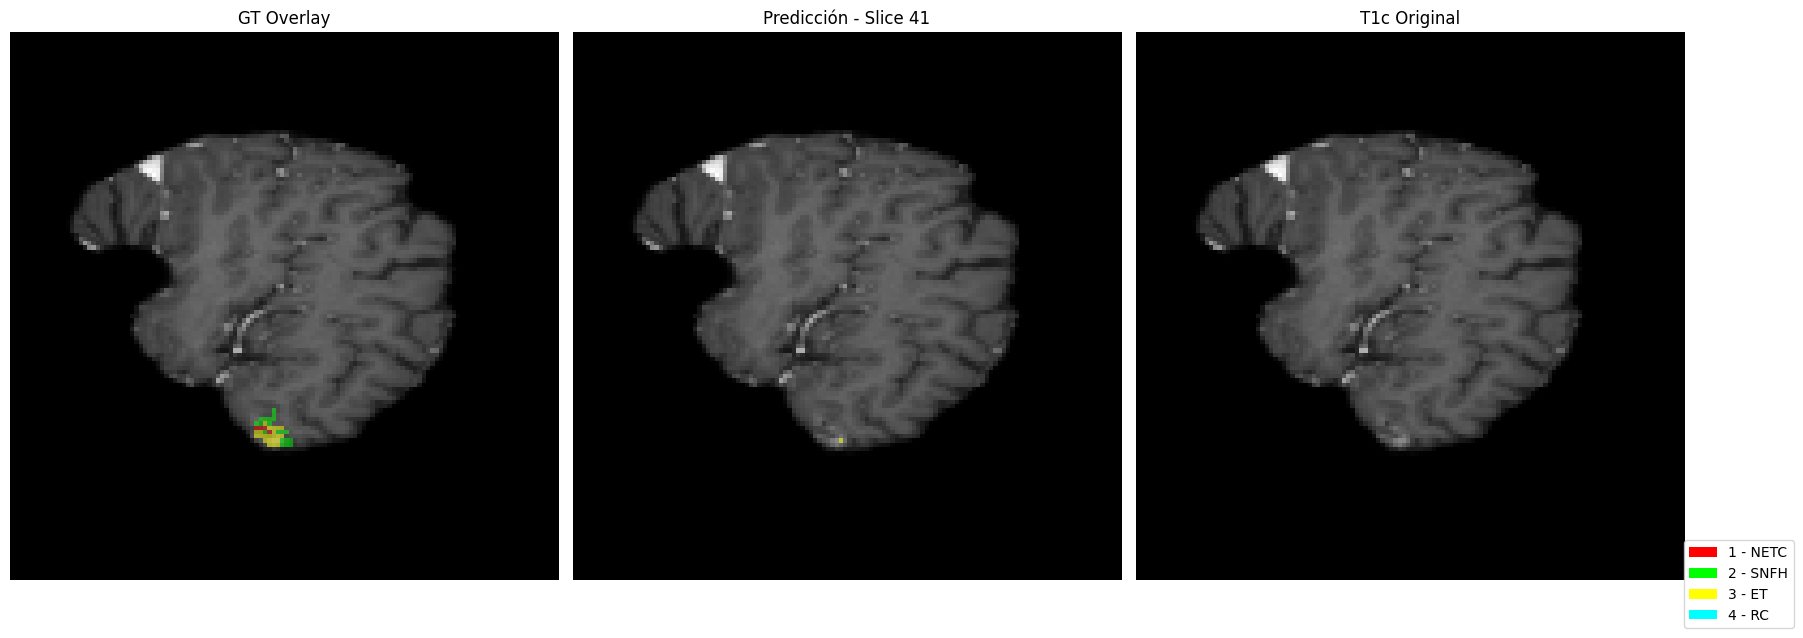

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Parámetros ---
case_id = "BraTS-MET-00286-000"
base_dir = "/notebooks"
input_dir = os.path.join(base_dir, "PreprocesadoAll")
output_dir = os.path.join(base_dir, "outputs", case_id)
os.makedirs(output_dir, exist_ok=True)

# --- Cargar volúmenes ---
volume = np.load(os.path.join(input_dir, f"{case_id}_image.npy"))  # (128,128,128,4)
mask   = np.load(os.path.join(input_dir, f"{case_id}_mask.npy"))   # (128,128,128)
pred   = np.load(os.path.join(output_dir, f"{case_id}_segmentation_tta.npy"))  # (128,128,128)

# --- Slice de interés ---
z = 41
modalidad_idx = 1  # T1c

# --- Extraer slices 2D ---
img  = volume[z, :, :, modalidad_idx]
mask_slice = mask[z, :, :]
pred_slice = pred[z, :, :]

# --- Normalizar imagen base ---
img = (img - img.min()) / (img.max() - img.min())

# --- Mapa de colores por clase ---
class_colors = {
    1: (1.0, 0.0, 0.0),  # rojo
    2: (0.0, 1.0, 0.0),  # verde
    3: (1.0, 1.0, 0.0),  # amarillo
    4: (0.0, 1.0, 1.0),  # cyan
}

# --- Overlay multiclase para slice 2D ---
def create_overlay(seg2d, alpha=0.5):
    overlay = np.stack([img]*3, axis=-1)  # (128,128,3)
    for cls, color in class_colors.items():
        mask_cls = (seg2d == cls)
        for c in range(3):
            overlay[..., c] = np.where(mask_cls, (1 - alpha) * overlay[..., c] + alpha * color[c], overlay[..., c])
    return overlay

# --- Crear overlays ---
overlay_gt   = create_overlay(mask_slice)
overlay_pred = create_overlay(pred_slice)

# --- Leyenda ---
legend_elements = [
    Patch(facecolor=class_colors[1], label="1 - NETC"),
    Patch(facecolor=class_colors[2], label="2 - SNFH"),
    Patch(facecolor=class_colors[3], label="3 - ET"),
    Patch(facecolor=class_colors[4], label="4 - RC"),
]

# --- Mostrar figura ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(overlay_gt)
axs[0].set_title("GT Overlay")

axs[1].imshow(overlay_pred)
axs[1].set_title(f"Predicción - Slice {z}")

axs[2].imshow(img, cmap="gray")
axs[2].set_title("T1c Original")

for ax in axs:
    ax.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(1.1, -0.1))
plt.tight_layout()
plt.show()

## 7.4 Volumen Tumoral

Para evaluar de forma cuantitativa la calidad de la segmentación, se calculó el **volumen tumoral por clase** tanto para la **predicción** del modelo como para la **segmentación manual (Ground Truth)**. Esto permite analizar no solo la precisión voxel a voxel (como hace el Dice), sino también si el modelo sobreestima o subestima el volumen total de cada tipo de lesión.

#### Pasos seguidos:

1. **Carga de máscaras 3D**: se cargaron tanto la segmentación generada por el modelo (`segmentation.npy`) como la máscara real (`mask.npy`) para el caso de estudio (`BraTS-MET-01087-001`).

2. **Definición del volumen del vóxel**: como los datos están en resolución isotrópica (1 mm³ por vóxel), el volumen se calcula directamente como el número de vóxeles de cada clase.

3. **Cálculo por clase (1 a 4)**:
   - Se contabilizó cuántos vóxeles pertenecen a cada clase tumoral en la predicción (`vox_pred`) y en el GT (`vox_gt`).
   - Se transformaron estos valores a volumen en mm³.
   - Se calcularon las **diferencias absolutas** y **relativas** de volumen por clase, para cuantificar posibles desviaciones del modelo.

#### Tabla de resultados:

| Clase | Nombre | Vóxeles Pred. | Vóxeles GT | Vol. Predicho (mm³) | Vol. GT (mm³) | Dif. Absoluta (mm³) | Dif. Relativa (%) |
|-------|--------|----------------|-------------|----------------------|----------------|----------------------|--------------------|
| 1     | NETC   | 2149           | 2259        | 2149.0               | 2259.0         | 110.0                | 4.87               |
| 2     | SNFH   | 18428          | 19820       | 18428.0              | 19820.0        | 1392.0               | 7.02               |
| 3     | ET     | 2532           | 2607        | 2532.0               | 2607.0         | 75.0                 | 2.88               |
| 4     | RC     | 1              | 0           | 1.0                  | 0.0            | 1.0                  | —                  |

> Nota: la diferencia relativa para la clase 4 (RC) no se puede calcular porque no hay presencia en la GT.

Este análisis aporta una perspectiva adicional al rendimiento del modelo, permitiendo detectar casos donde las segmentaciones pueden tener alta concordancia espacial (buen Dice) pero errores relevantes en el volumen total estimado.

### Volumen Tumoral por Clase

Para evaluar cuantitativamente la segmentación generada por el modelo, se calcularon los volúmenes tumorales por clase en milímetros cúbicos (mm³) para tres casos del conjunto de validación. Los volúmenes predichos se compararon con las segmentaciones manuales (GT), considerando un tamaño de vóxel isotrópico de 1 mm³. Las métricas calculadas por clase incluyen:

- **Vóxeles predichos (vox_pred)** y **reales (vox_gt)**
- **Volumen predicho y real (mm³)**
- **Diferencia absoluta (mm³)** y **relativa (%)**

A continuación, se presenta una tabla resumen para los tres casos:

| Caso                  | Clase | Nombre clase | Vóx. Pred. | Vóx. GT | Vol. Pred. (mm³) | Vol. GT (mm³) | Dif. Abs. (mm³) | Dif. Rel. (%) |
|-----------------------|:-----:|---------------|------------|---------|------------------|----------------|------------------|----------------|
| **01087-001**         |   1   | NETC          | 2149       | 2259    | 2149.0           | 2259.0         | 110.0           | 4.87           |
|                       |   2   | SNFH          | 18428      | 19820   | 18428.0          | 19820.0        | 1392.0          | 7.02           |
|                       |   3   | ET            | 2532       | 2607    | 2532.0           | 2607.0         | 75.0            | 2.88           |
|                       |   4   | RC            | 1          | 0       | 1.0              | 0.0            | 1.0             | —              |
| **01071-001**         |   1   | NETC          | 3          | 4       | 3.0              | 4.0            | 1.0             | 25.00          |
|                       |   2   | SNFH          | 12551      | 11775   | 12551.0          | 11775.0        | 776.0           | 6.59           |
|                       |   3   | ET            | 49         | 148     | 49.0             | 148.0          | 99.0            | 66.89          |
|                       |   4   | RC            | 270        | 310     | 270.0            | 310.0          | 40.0            | 12.90          |
| **00286-000**         |   1   | NETC          | 0          | 10      | 0.0              | 10.0           | 10.0            | 100.00         |
|                       |   2   | SNFH          | 17         | 262     | 17.0             | 262.0          | 245.0           | 93.51          |
|                       |   3   | ET            | 81         | 187     | 81.0             | 187.0          | 106.0           | 56.68          |
|                       |   4   | RC            | 8          | 0       | 8.0              | 0.0            | 8.0             | —              |

**Observaciones destacadas**:

- El caso `BraTS-MET-01087-001` presenta una concordancia volumétrica alta entre predicción y GT en todas las clases, con errores relativos < 7%.
- En el caso `01071-001`, se aprecia una sobresegmentación leve en clase 2, y una infrasegmentación considerable en clase 3.
- El caso `00286-000` revela dificultades claras del modelo, con errores relativos elevados en todas las clases, especialmente en la 1 y 2.

Estos resultados reflejan que, aunque el modelo alcanza buena precisión volumétrica en casos bien definidos, presenta desafíos en tumores pequeños o mal definidos.

In [18]:
import os
import numpy as np
import pandas as pd

# --- Parámetros ---
case_id = "BraTS-MET-01087-001"
seg_pred_path = f"/notebooks/outputs/{case_id}/{case_id}_segmentation.npy"
seg_gt_path   = f"/notebooks/PreprocesadoAll/{case_id}_mask.npy"
voxel_spacing_mm = (1.0, 1.0, 1.0)  # isotrópico

# --- Cargar segmentaciones ---
pred = np.load(seg_pred_path)
gt   = np.load(seg_gt_path)
voxel_volume = np.prod(voxel_spacing_mm)  # 1 mm³

# --- Clases tumorales ---
clases = {
    1: "NETC",
    2: "SNFH",
    3: "ET",
    4: "RC"
}

volumenes = []

for cls, nombre in clases.items():
    n_vox_pred = np.sum(pred == cls)
    n_vox_gt   = np.sum(gt   == cls)

    vol_pred = n_vox_pred * voxel_volume
    vol_gt   = n_vox_gt   * voxel_volume

    abs_diff = abs(vol_pred - vol_gt)
    rel_diff = (abs_diff / vol_gt) * 100 if vol_gt > 0 else np.nan

    volumenes.append({
        "class_id": cls,
        "class_name": nombre,
        "vox_pred": int(n_vox_pred),
        "vox_gt": int(n_vox_gt),
        "vol_pred_mm3": vol_pred,
        "vol_gt_mm3": vol_gt,
        "abs_diff_mm3": abs_diff,
        "rel_diff_%": rel_diff
    })

# --- Guardar y mostrar ---
df_vol = pd.DataFrame(volumenes)
print(df_vol.round(2))
df_vol.to_csv(f"/notebooks/outputs/{case_id}/volumen_comparacion_gt_{case_id}.csv", index=False)

   class_id class_name  vox_pred  vox_gt  vol_pred_mm3  vol_gt_mm3  \
0         1       NETC      2145    2259        2145.0      2259.0   
1         2       SNFH     18340   19820       18340.0     19820.0   
2         3         ET      2611    2607        2611.0      2607.0   
3         4         RC         0       0           0.0         0.0   

   abs_diff_mm3  rel_diff_%  
0         114.0        5.05  
1        1480.0        7.47  
2           4.0        0.15  
3           0.0         NaN  


In [19]:
import os
import numpy as np
import pandas as pd

# --- Parámetros ---
case_id = "BraTS-MET-01071-001"
seg_pred_path = f"/notebooks/outputs/{case_id}/{case_id}_segmentation.npy"
seg_gt_path   = f"/notebooks/PreprocesadoAll/{case_id}_mask.npy"
voxel_spacing_mm = (1.0, 1.0, 1.0)  # isotrópico

# --- Cargar segmentaciones ---
pred = np.load(seg_pred_path)
gt   = np.load(seg_gt_path)
voxel_volume = np.prod(voxel_spacing_mm)  # 1 mm³

# --- Clases tumorales ---
clases = {
    1: "NETC",
    2: "SNFH",
    3: "ET",
    4: "RC"
}

volumenes = []

for cls, nombre in clases.items():
    n_vox_pred = np.sum(pred == cls)
    n_vox_gt   = np.sum(gt   == cls)

    vol_pred = n_vox_pred * voxel_volume
    vol_gt   = n_vox_gt   * voxel_volume

    abs_diff = abs(vol_pred - vol_gt)
    rel_diff = (abs_diff / vol_gt) * 100 if vol_gt > 0 else np.nan

    volumenes.append({
        "class_id": cls,
        "class_name": nombre,
        "vox_pred": int(n_vox_pred),
        "vox_gt": int(n_vox_gt),
        "vol_pred_mm3": vol_pred,
        "vol_gt_mm3": vol_gt,
        "abs_diff_mm3": abs_diff,
        "rel_diff_%": rel_diff
    })

# --- Guardar y mostrar ---
df_vol = pd.DataFrame(volumenes)
print(df_vol.round(2))
df_vol.to_csv(f"/notebooks/outputs/{case_id}/volumen_comparacion_gt_{case_id}.csv", index=False)

   class_id class_name  vox_pred  vox_gt  vol_pred_mm3  vol_gt_mm3  \
0         1       NETC         3       4           3.0         4.0   
1         2       SNFH     12551   11775       12551.0     11775.0   
2         3         ET        49     148          49.0       148.0   
3         4         RC       270     310         270.0       310.0   

   abs_diff_mm3  rel_diff_%  
0           1.0       25.00  
1         776.0        6.59  
2          99.0       66.89  
3          40.0       12.90  


In [20]:
import os
import numpy as np
import pandas as pd

# --- Parámetros ---
case_id = "BraTS-MET-00286-000"
seg_pred_path = f"/notebooks/outputs/{case_id}/{case_id}_segmentation.npy"
seg_gt_path   = f"/notebooks/PreprocesadoAll/{case_id}_mask.npy"
voxel_spacing_mm = (1.0, 1.0, 1.0)  # isotrópico

# --- Cargar segmentaciones ---
pred = np.load(seg_pred_path)
gt   = np.load(seg_gt_path)
voxel_volume = np.prod(voxel_spacing_mm)  # 1 mm³

# --- Clases tumorales ---
clases = {
    1: "NETC",
    2: "SNFH",
    3: "ET",
    4: "RC"
}

volumenes = []

for cls, nombre in clases.items():
    n_vox_pred = np.sum(pred == cls)
    n_vox_gt   = np.sum(gt   == cls)

    vol_pred = n_vox_pred * voxel_volume
    vol_gt   = n_vox_gt   * voxel_volume

    abs_diff = abs(vol_pred - vol_gt)
    rel_diff = (abs_diff / vol_gt) * 100 if vol_gt > 0 else np.nan

    volumenes.append({
        "class_id": cls,
        "class_name": nombre,
        "vox_pred": int(n_vox_pred),
        "vox_gt": int(n_vox_gt),
        "vol_pred_mm3": vol_pred,
        "vol_gt_mm3": vol_gt,
        "abs_diff_mm3": abs_diff,
        "rel_diff_%": rel_diff
    })

# --- Guardar y mostrar ---
df_vol = pd.DataFrame(volumenes)
print(df_vol.round(2))
df_vol.to_csv(f"/notebooks/outputs/{case_id}/volumen_comparacion_gt_{case_id}.csv", index=False)

   class_id class_name  vox_pred  vox_gt  vol_pred_mm3  vol_gt_mm3  \
0         1       NETC         0      10           0.0        10.0   
1         2       SNFH        17     262          17.0       262.0   
2         3         ET        81     187          81.0       187.0   
3         4         RC         8       0           8.0         0.0   

   abs_diff_mm3  rel_diff_%  
0          10.0      100.00  
1         245.0       93.51  
2         106.0       56.68  
3           8.0         NaN  


# 8. Aplicación Web Interactiva (Streamlit)

Como parte del trabajo, se ha desarrollado una aplicación web interactiva con Streamlit que permite probar el pipeline completo de detección y segmentación sobre resonancias cerebrales. Esta herramienta facilita tanto la evaluación cualitativa de los resultados como la exploración visual de los volúmenes segmentados, sin necesidad de conocimientos técnicos avanzados ni entornos de programación.

### Funcionalidades principales

- **Entrada de datos flexible**: se permite al usuario subir:
  - Un volumen `.npy` ya preprocesado con forma `(128,128,128,4)` (opción recomendada para pruebas rápidas).
  - O bien las **cuatro modalidades** por separado (`.nii.gz`): T1n, T1c, T2-FLAIR y T2w. En este caso, se aplica automáticamente el pipeline de preprocesado completo:
    - Corrección del bias field (N4ITK) en T1n y T1c.
    - Normalización por z-score.
    - Redimensionado a 128×128×128.

- **Pipeline completo ejecutable** con un solo clic: tras la carga del volumen, se ejecuta la detección y segmentación automática con los modelos previamente entrenados. Todo el proceso está cacheado y optimizado para evitar tiempos de espera innecesarios en llamadas repetidas.

- **Control de inferencia**:
  - Activar o desactivar TTA (Test-Time Augmentation) con 8 flips.
  - Ajustar el umbral de detección (`th`) y el `stride` del detector para controlar sensibilidad y coste computacional.
  - Inferencia en dos etapas: primero se detectan regiones sospechosas y después se segmentan con dos modelos especializados y combinados mediante ensemble voxel-wise por clase.

- **Visualización interactiva**:
  - El usuario puede seleccionar la **modalidad** a visualizar (`T1n`, `T1c`, `T2f`, `T2w`).
  - Navegar por cortes axiales (slices).
  - Activar o desactivar la **superposición de la máscara de segmentación**.
  - La máscara segmentada incluye leyenda visual por clase y se muestra sobre el corte seleccionado.

- **Descarga de resultados**:
  - Posibilidad de descargar el overlay visual en `.png` con leyenda.
  - Descargar la máscara segmentada en `.npy`.
  - Descargar las predicciones softmax en `.npz`.

- **Volumetría**: cálculo automático del volumen por clase (en voxeles, equivalentes a mm³), mostrados en formato JSON.

### Demostración práctica

Además de incluir esta herramienta como parte del proyecto, se ha preparado un vídeo de demostración (enlace en el Anexo) y un enlace a Google Drive con los modelos y archivos necesarios para que pueda ser ejecutada en local o en entorno cloud compatible.

---

> Esta herramienta resulta especialmente útil para la **productivización académica** del proyecto, permitiendo a tutores y evaluadores explorar visualmente los resultados sin necesidad de ejecutar manualmente ningún script.

In [2]:
!pip install --upgrade --ignore-installed blinker==1.9.0
!pip install -q streamlit==1.49.0 pyngrok

In [3]:
from pyngrok import ngrok
ngrok.set_auth_token("31uNqUA0oIhYSj0QKQWf8dW24UF_7yDwRiVUJeT6havRiNQYB")
print("Token configurado")

Token configurado                                                                                   


In [4]:
!pwd
!ls -lah

/notebooks
total 49G
drwxr-xr-x  26 root root   93 Sep 15 10:12  .
drwxr-xr-x   1 root root 4.0K Sep 15 10:11  ..
drwx------   4 root root    2 Jul 28 14:41  .Trash-0
drwxr-xr-x   8 root root   12 Aug 27 19:48  .git
drwxr-xr-x   2 root root   13 Sep  9 11:53  .ipynb_checkpoints
-rw-r--r--   1 root root 2.0M May 31  2023  BraTS-MET-00123-000-t1n.nii.gz
-rw-r--r--   1 root root 4.5M Dec 22  2024  BraTS-MET-01071-002-t1n.nii.gz
-rw-r--r--   1 root root 8.5M Sep  6 16:01  BraTS-MET-01087-001-t1c.nii.gz
-rw-r--r--   1 root root 7.3M Sep  6 16:01  BraTS-MET-01087-001-t1n.nii.gz
-rw-r--r--   1 root root 7.0M Sep  6 16:01  BraTS-MET-01087-001-t2f.nii.gz
-rw-r--r--   1 root root 8.0M Sep  6 16:01  BraTS-MET-01087-001-t2w.nii.gz
-rw-r--r--   1 root root  18M Sep 10 08:08  BraTS-MET-01320-001-t1c.nii.gz
-rw-r--r--   1 root root  16M Sep 10 08:08  BraTS-MET-01320-001-t1n.nii.gz
-rw-r--r--   1 root root  15M Sep 10 08:08  BraTS-MET-01320-001-t2f.nii.gz
-rw-r--r--   1 root root  17M Sep 10 08:08  Br

In [6]:
import os, time, subprocess, signal
from pyngrok import ngrok

# cierra instancias previas si las hubiera
try:
    # en algunos entornos pkill no está permitido; lo intentamos con Popen
    _ = subprocess.run(["pkill", "-f", "streamlit run app.py"], check=False)
except Exception:
    pass

# lanza streamlit en 0.0.0.0:8501 (headless)
streamlit_cmd = ["streamlit", "run", "app.py", "--server.address", "0.0.0.0",
                 "--server.port", "8501", "--server.headless", "true"]
streamlit_proc = subprocess.Popen(streamlit_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

# espera unos segundos a que arranque
time.sleep(5)

# abre túnel HTTP al puerto 8501
public_tunnel = ngrok.connect(8501, "http")
public_url = public_tunnel.public_url
print("Tu app está lista aquí:\n", public_url)
print("\nMantén esta sesión/celda viva para que el túnel siga activo.")

Tu app está lista aquí:
 https://8cd6cf385a53.ngrok-free.app

Mantén esta sesión/celda viva para que el túnel siga activo.


In [9]:
from pyngrok import ngrok
try:
    ngrok.disconnect(public_url)
except Exception:
    pass
ngrok.kill()
streamlit_proc.terminate()  # o streamlit_proc.kill()
print("Streamlit y ngrok detenidos.")

Streamlit y ngrok detenidos.


In [5]:
!pip install -q SimpleITK nibabel

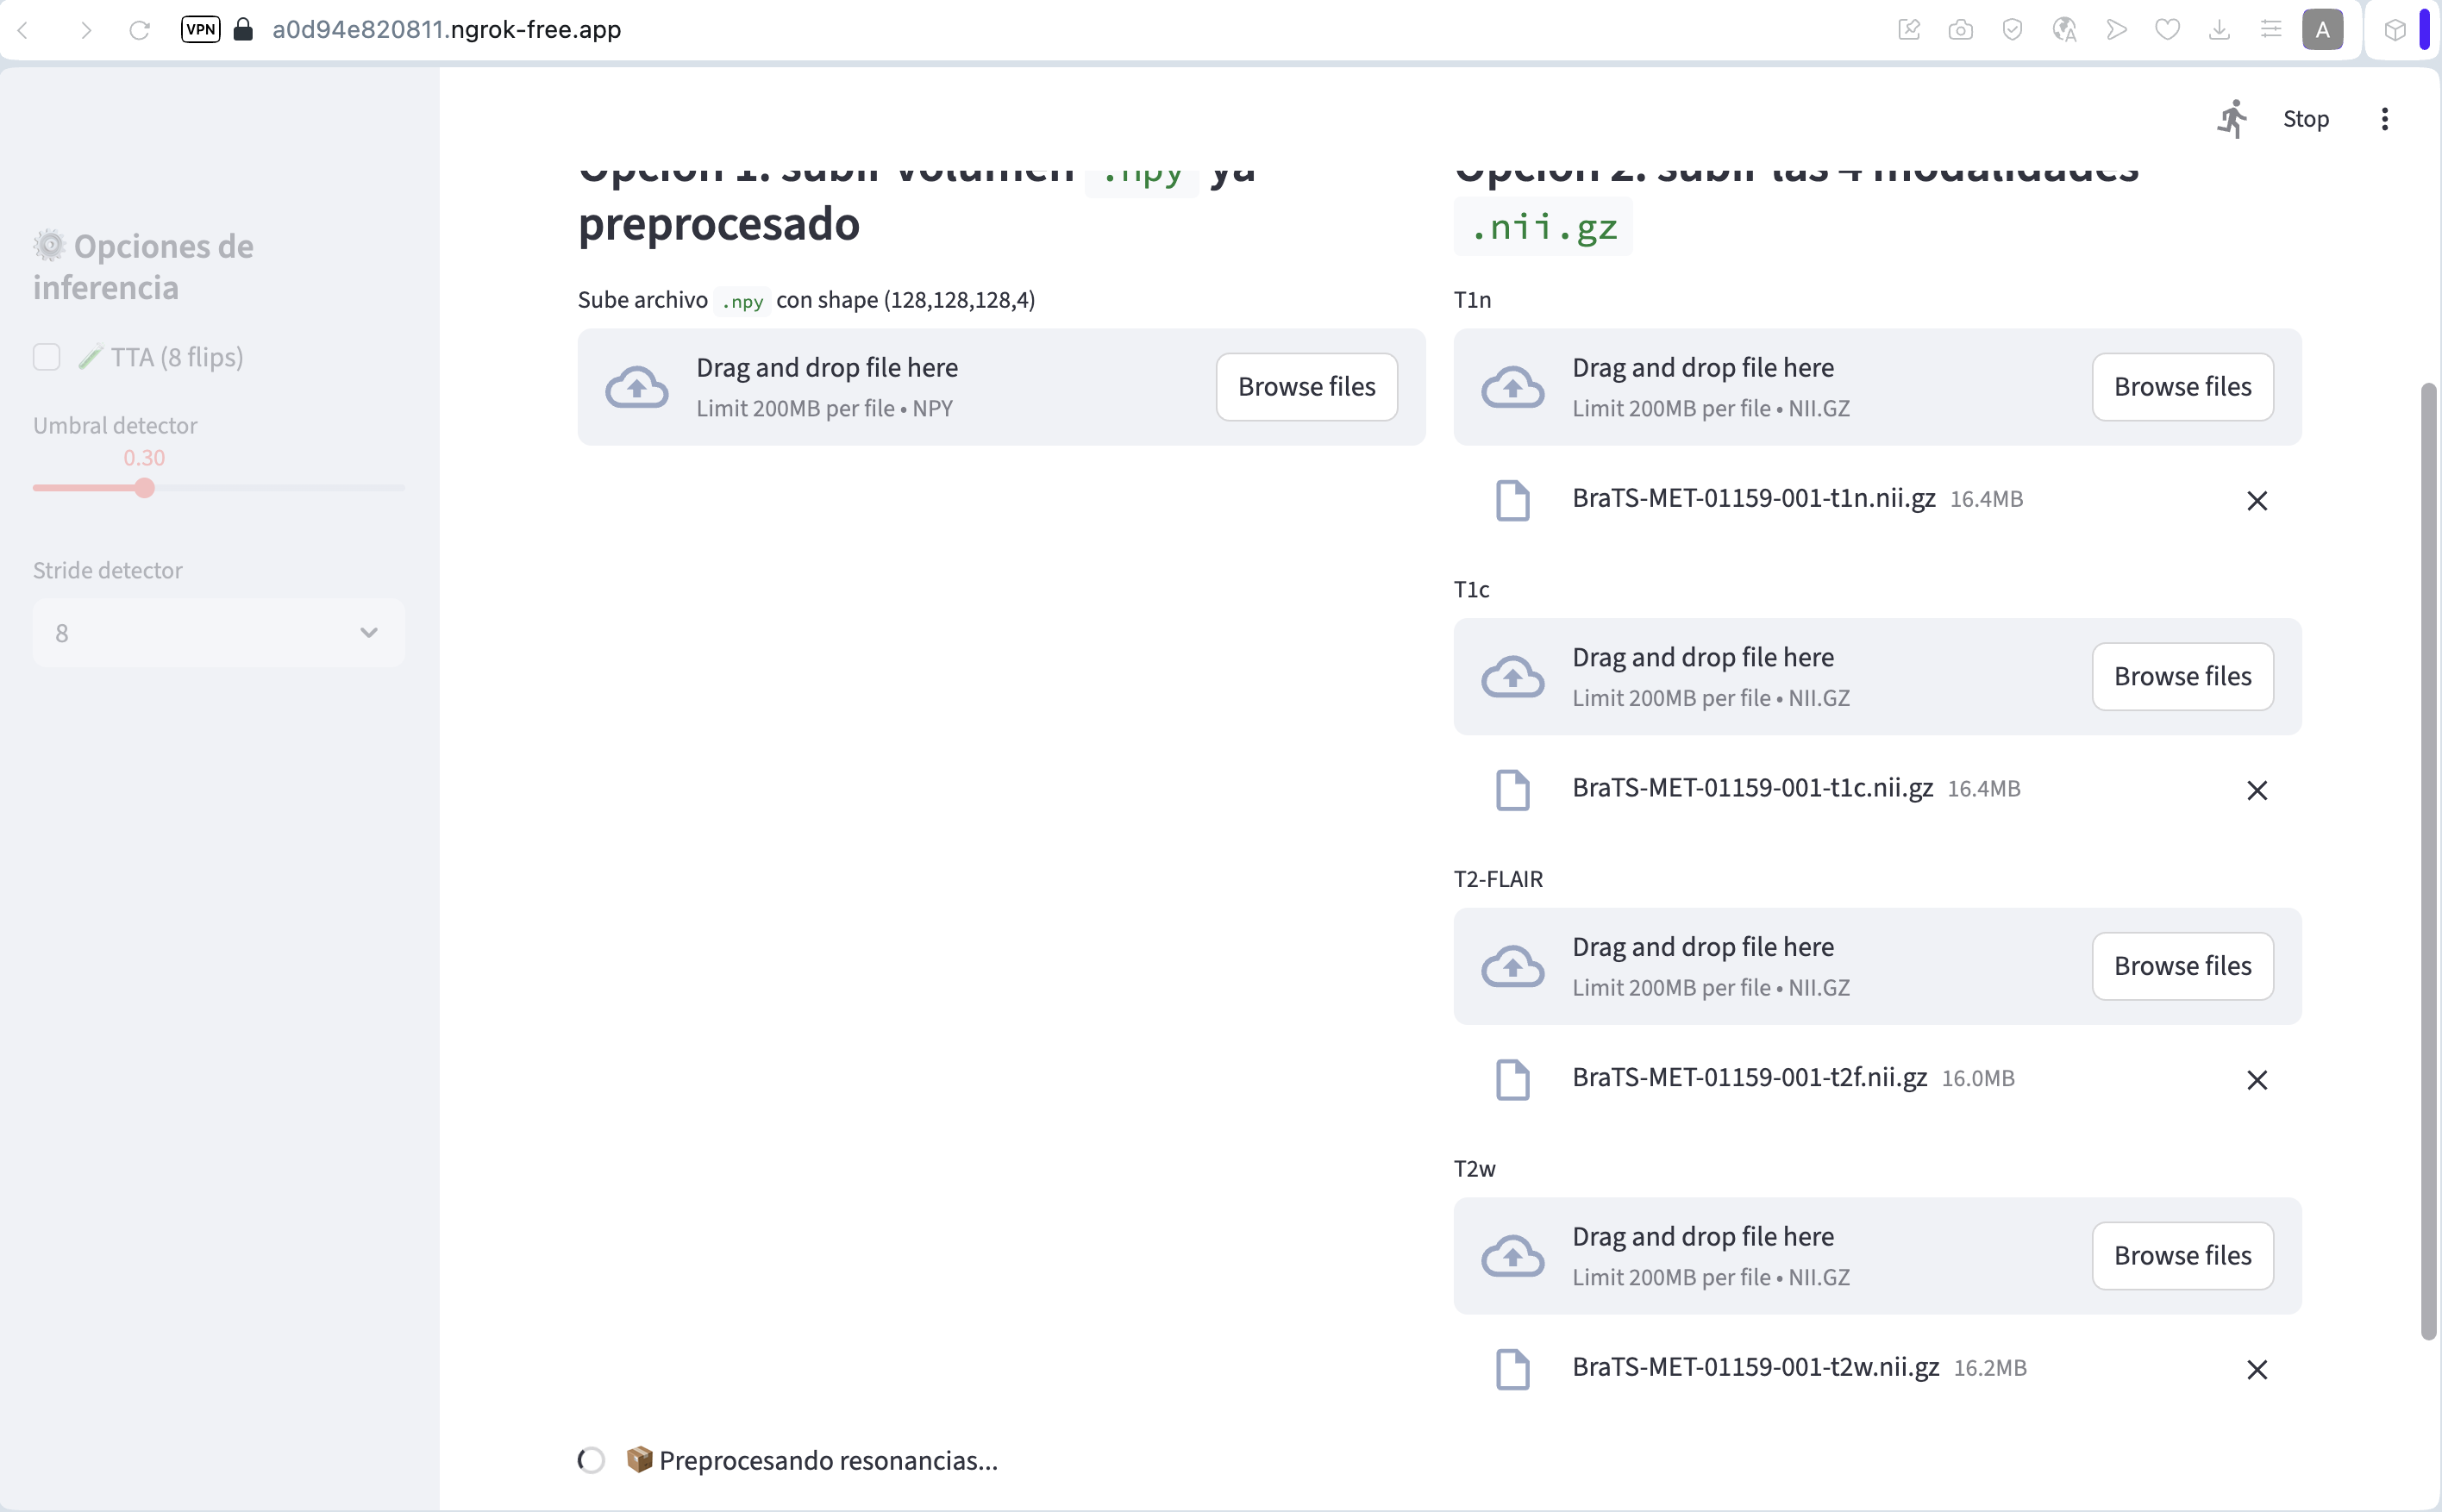

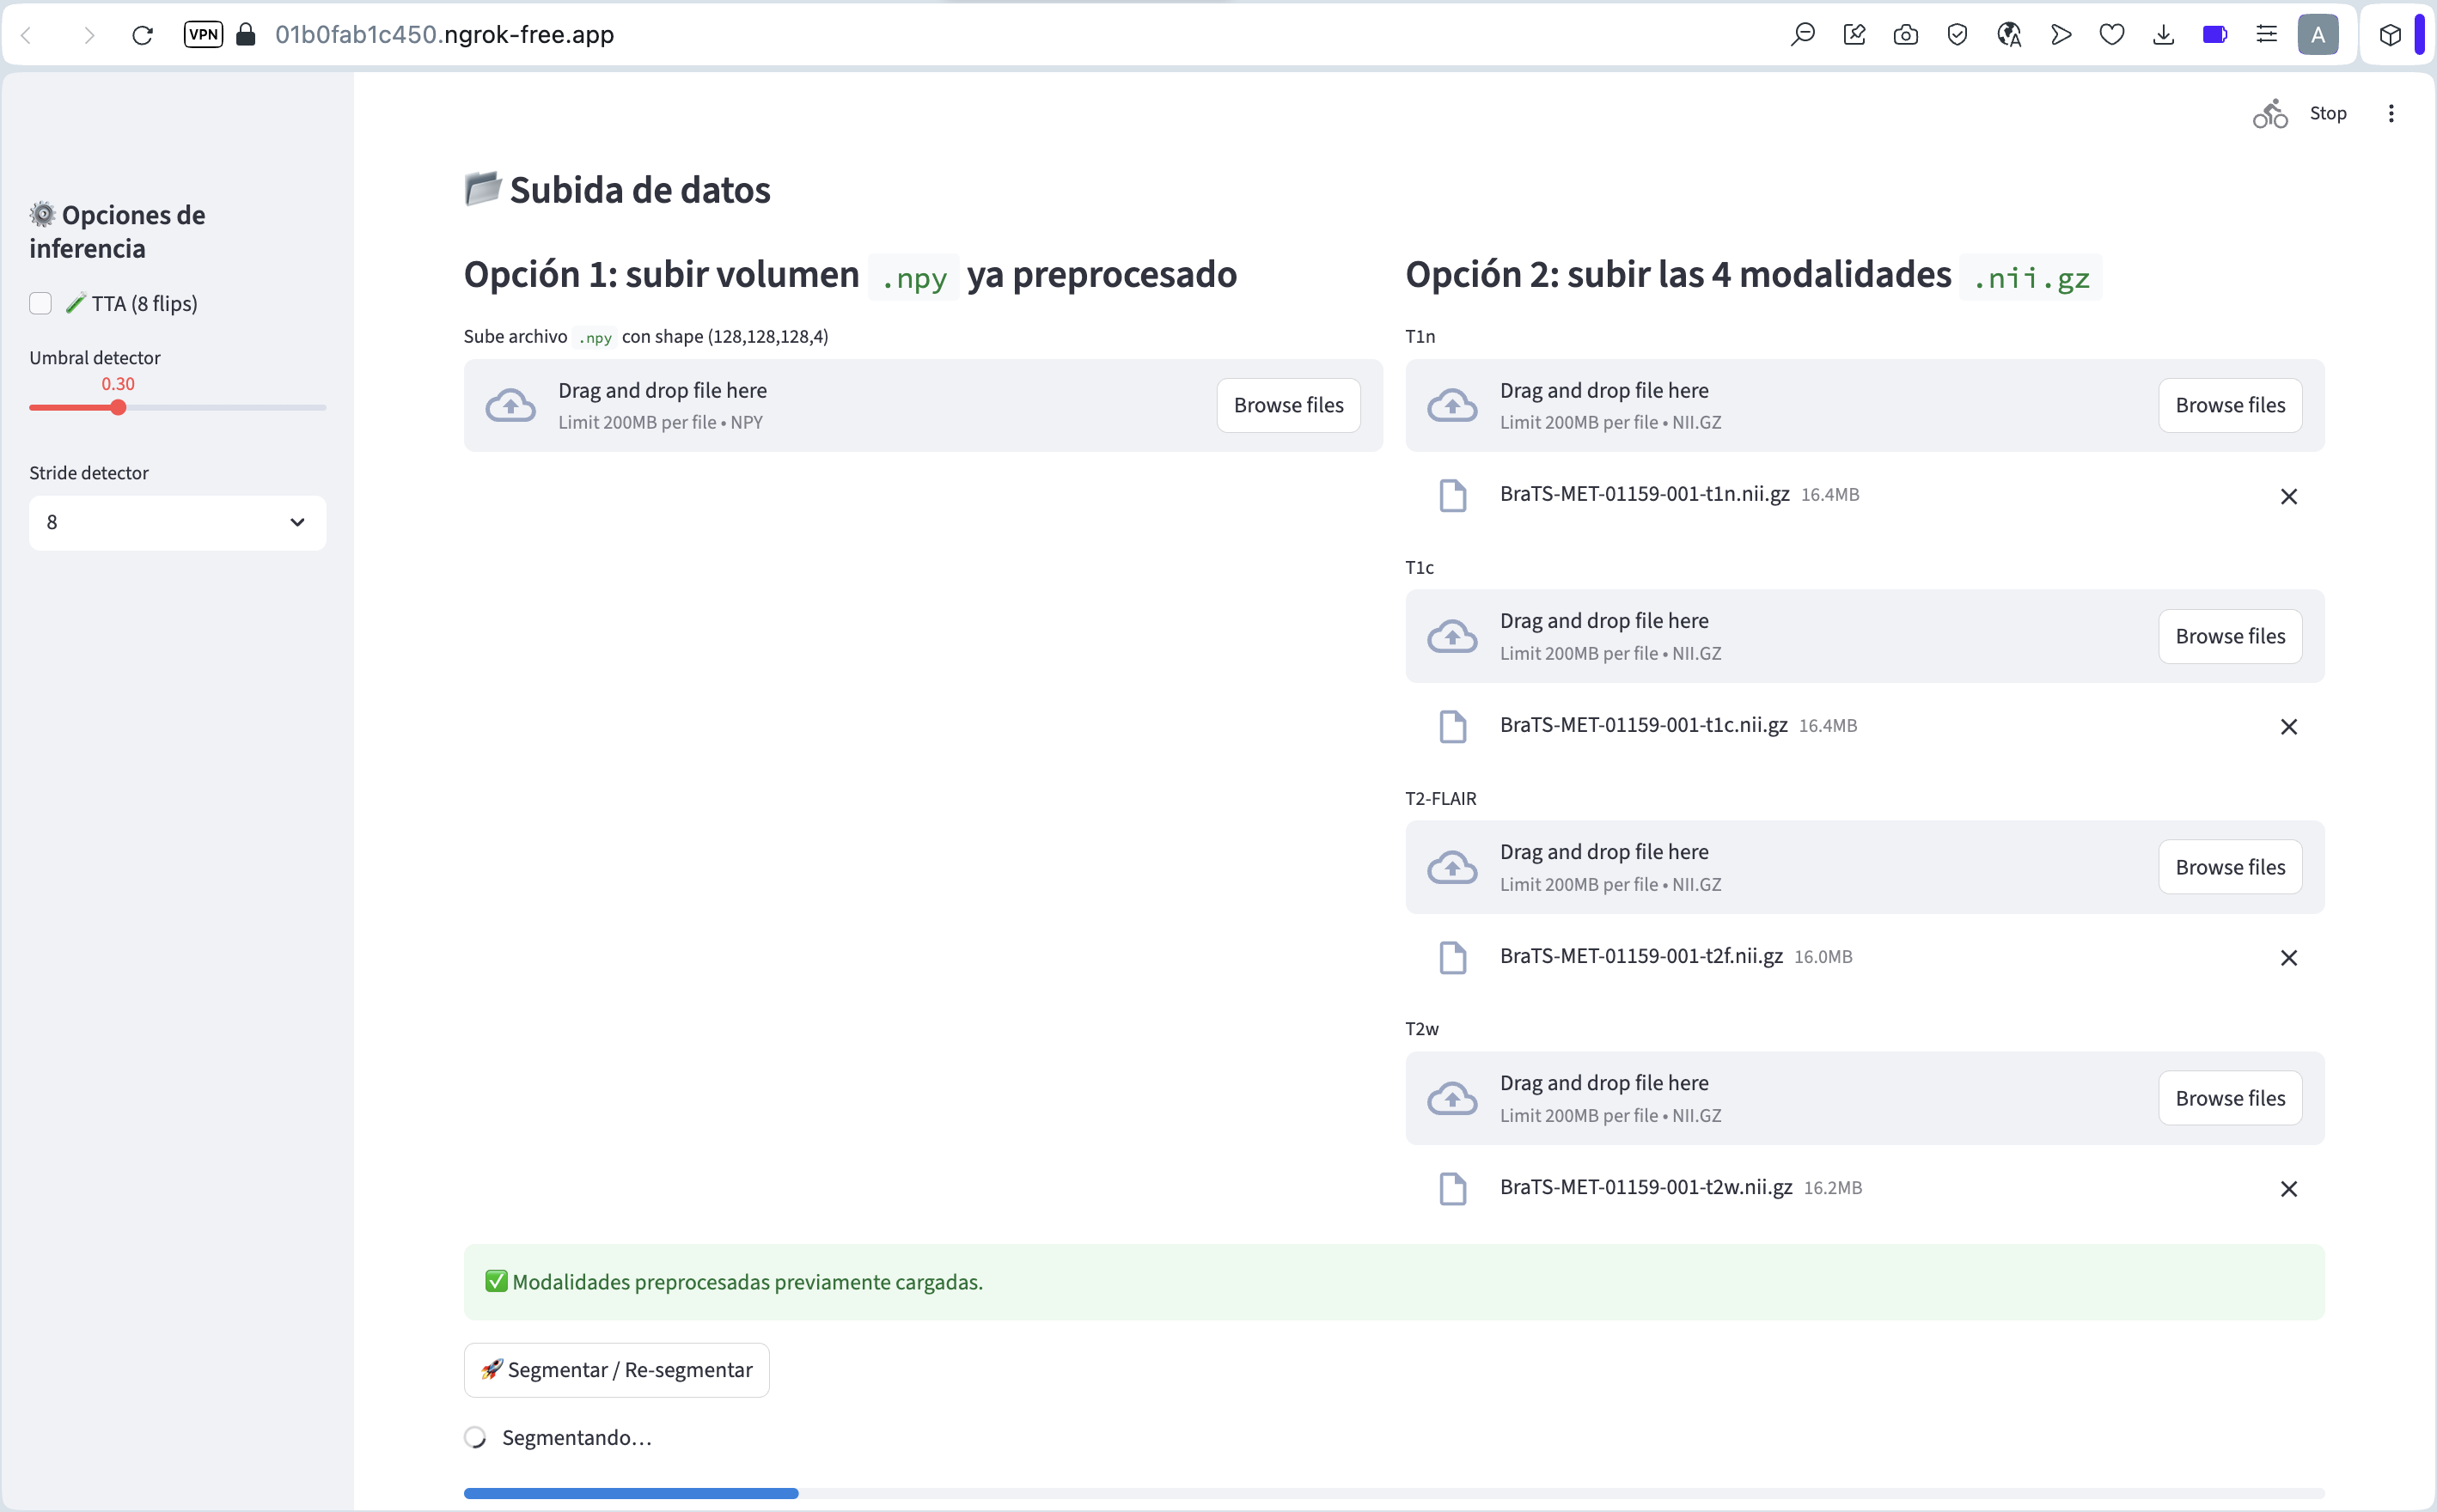

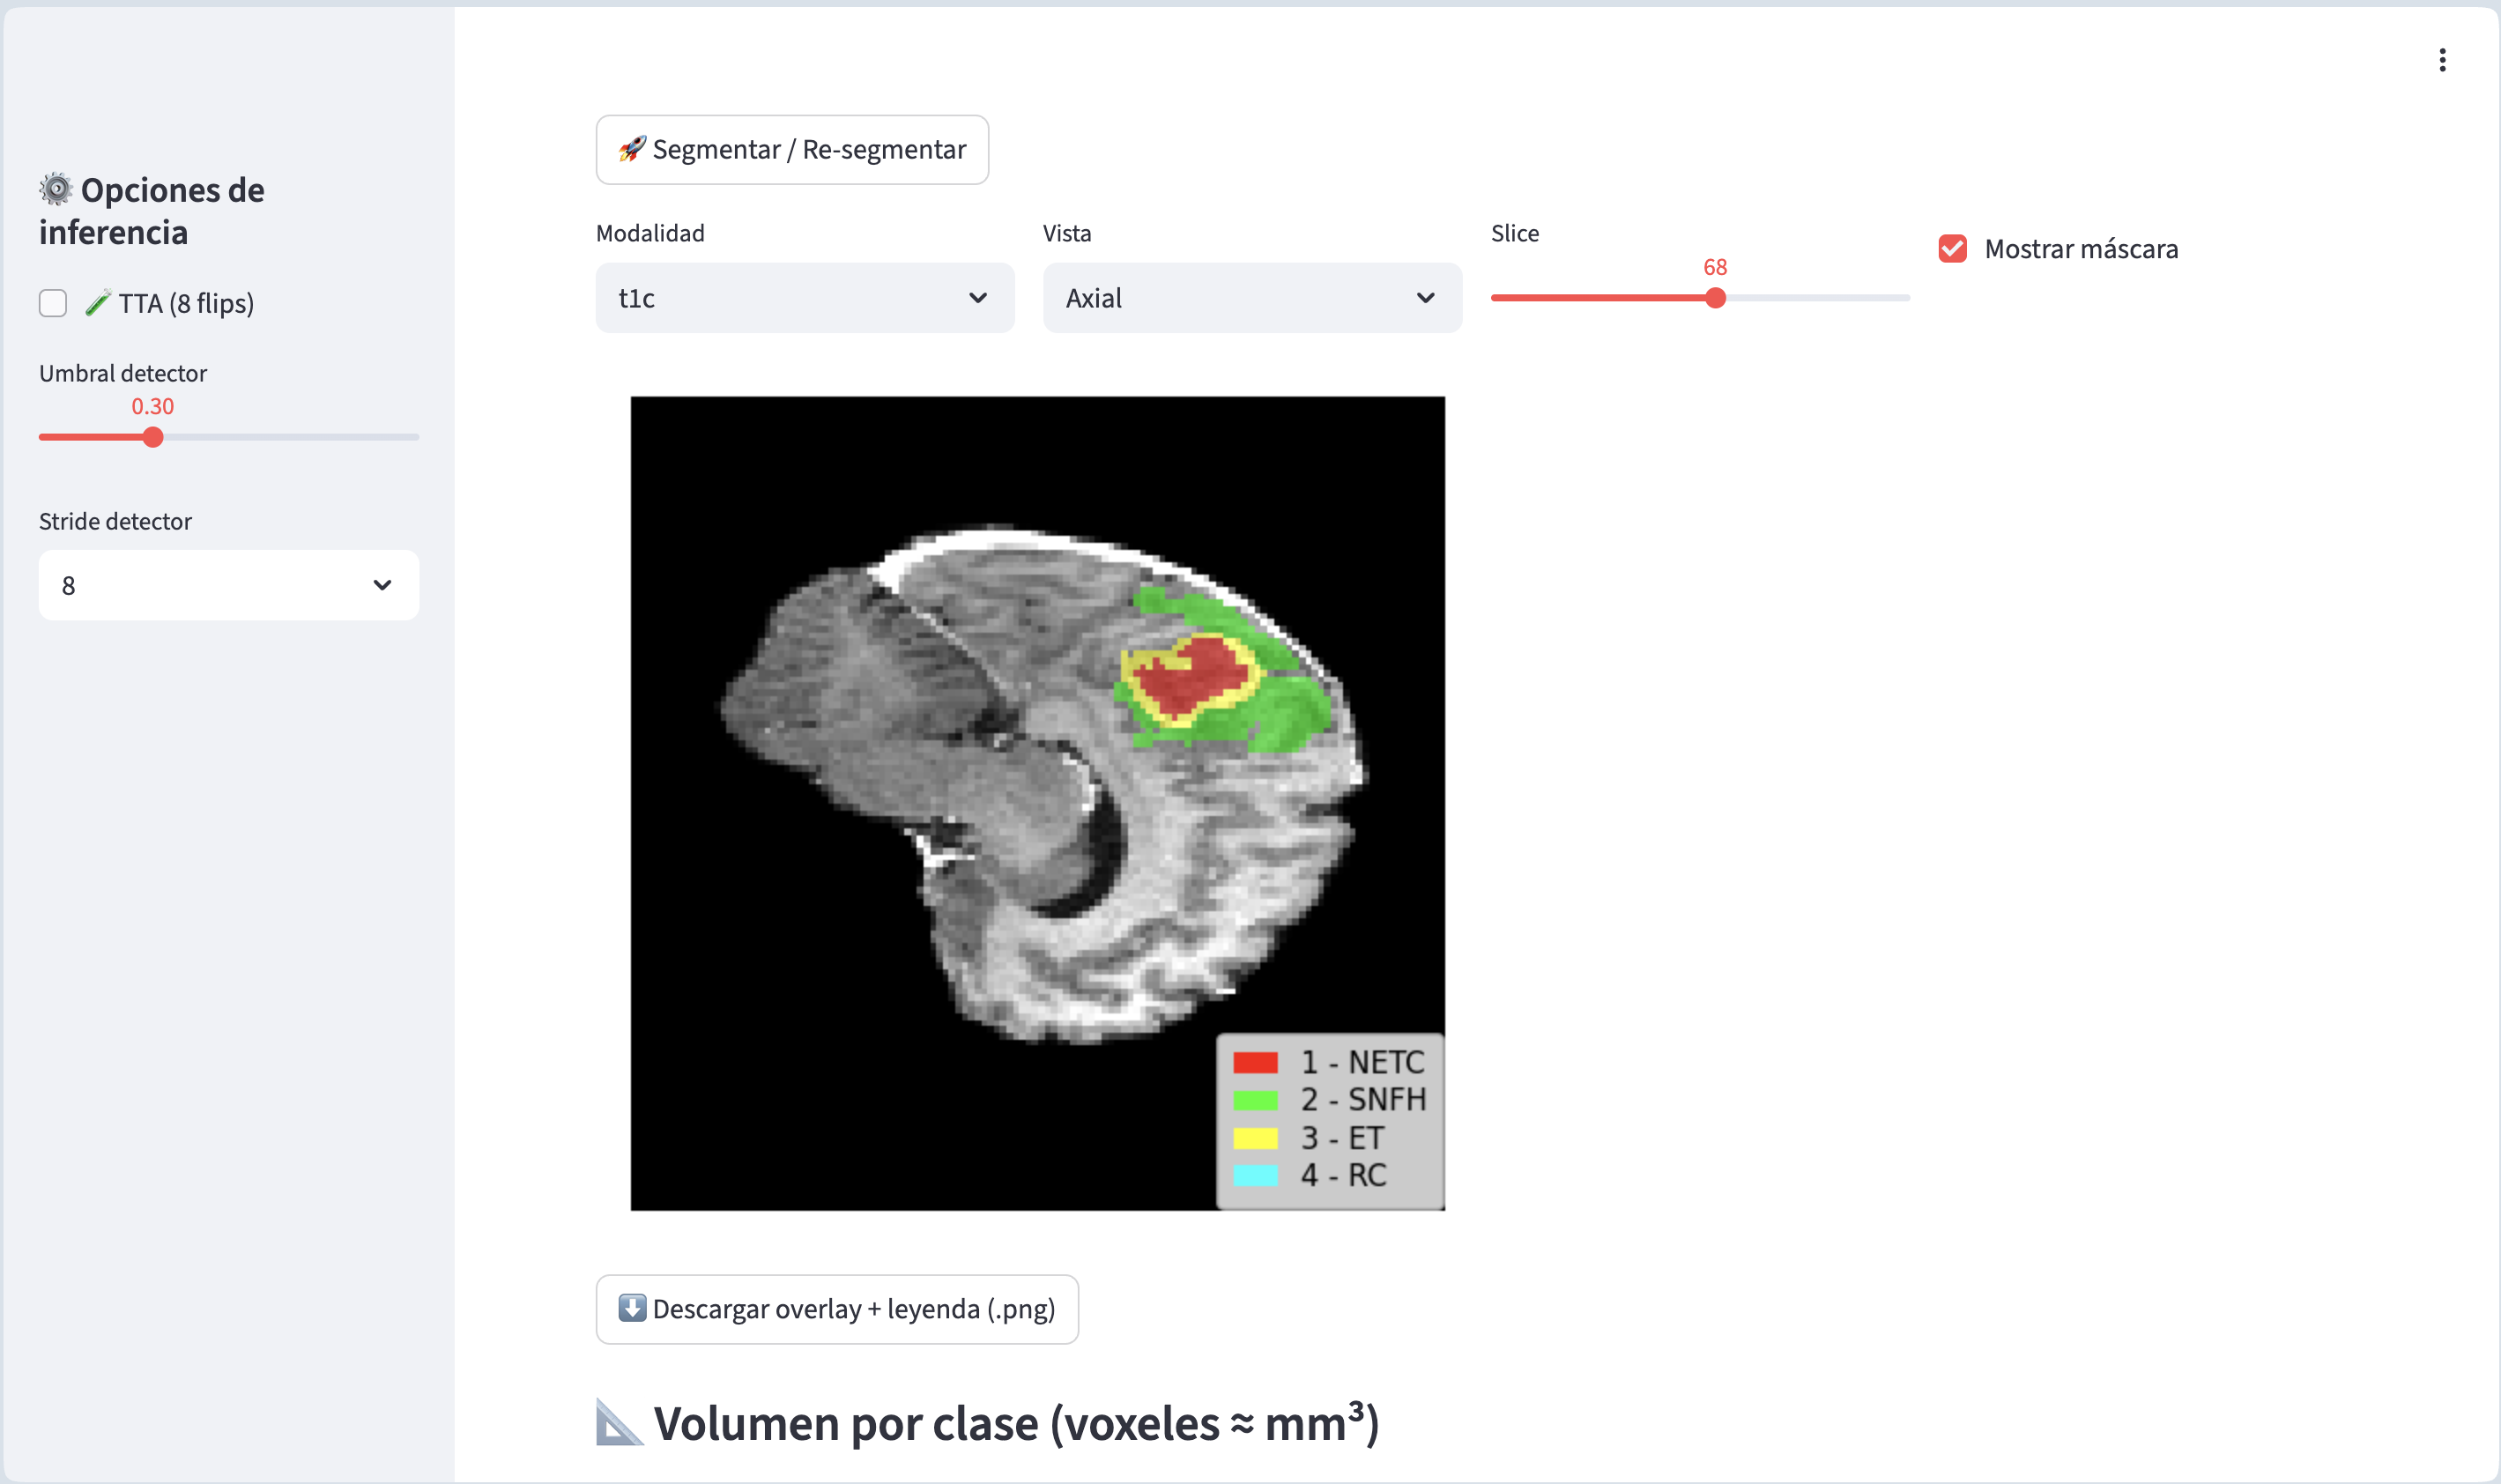

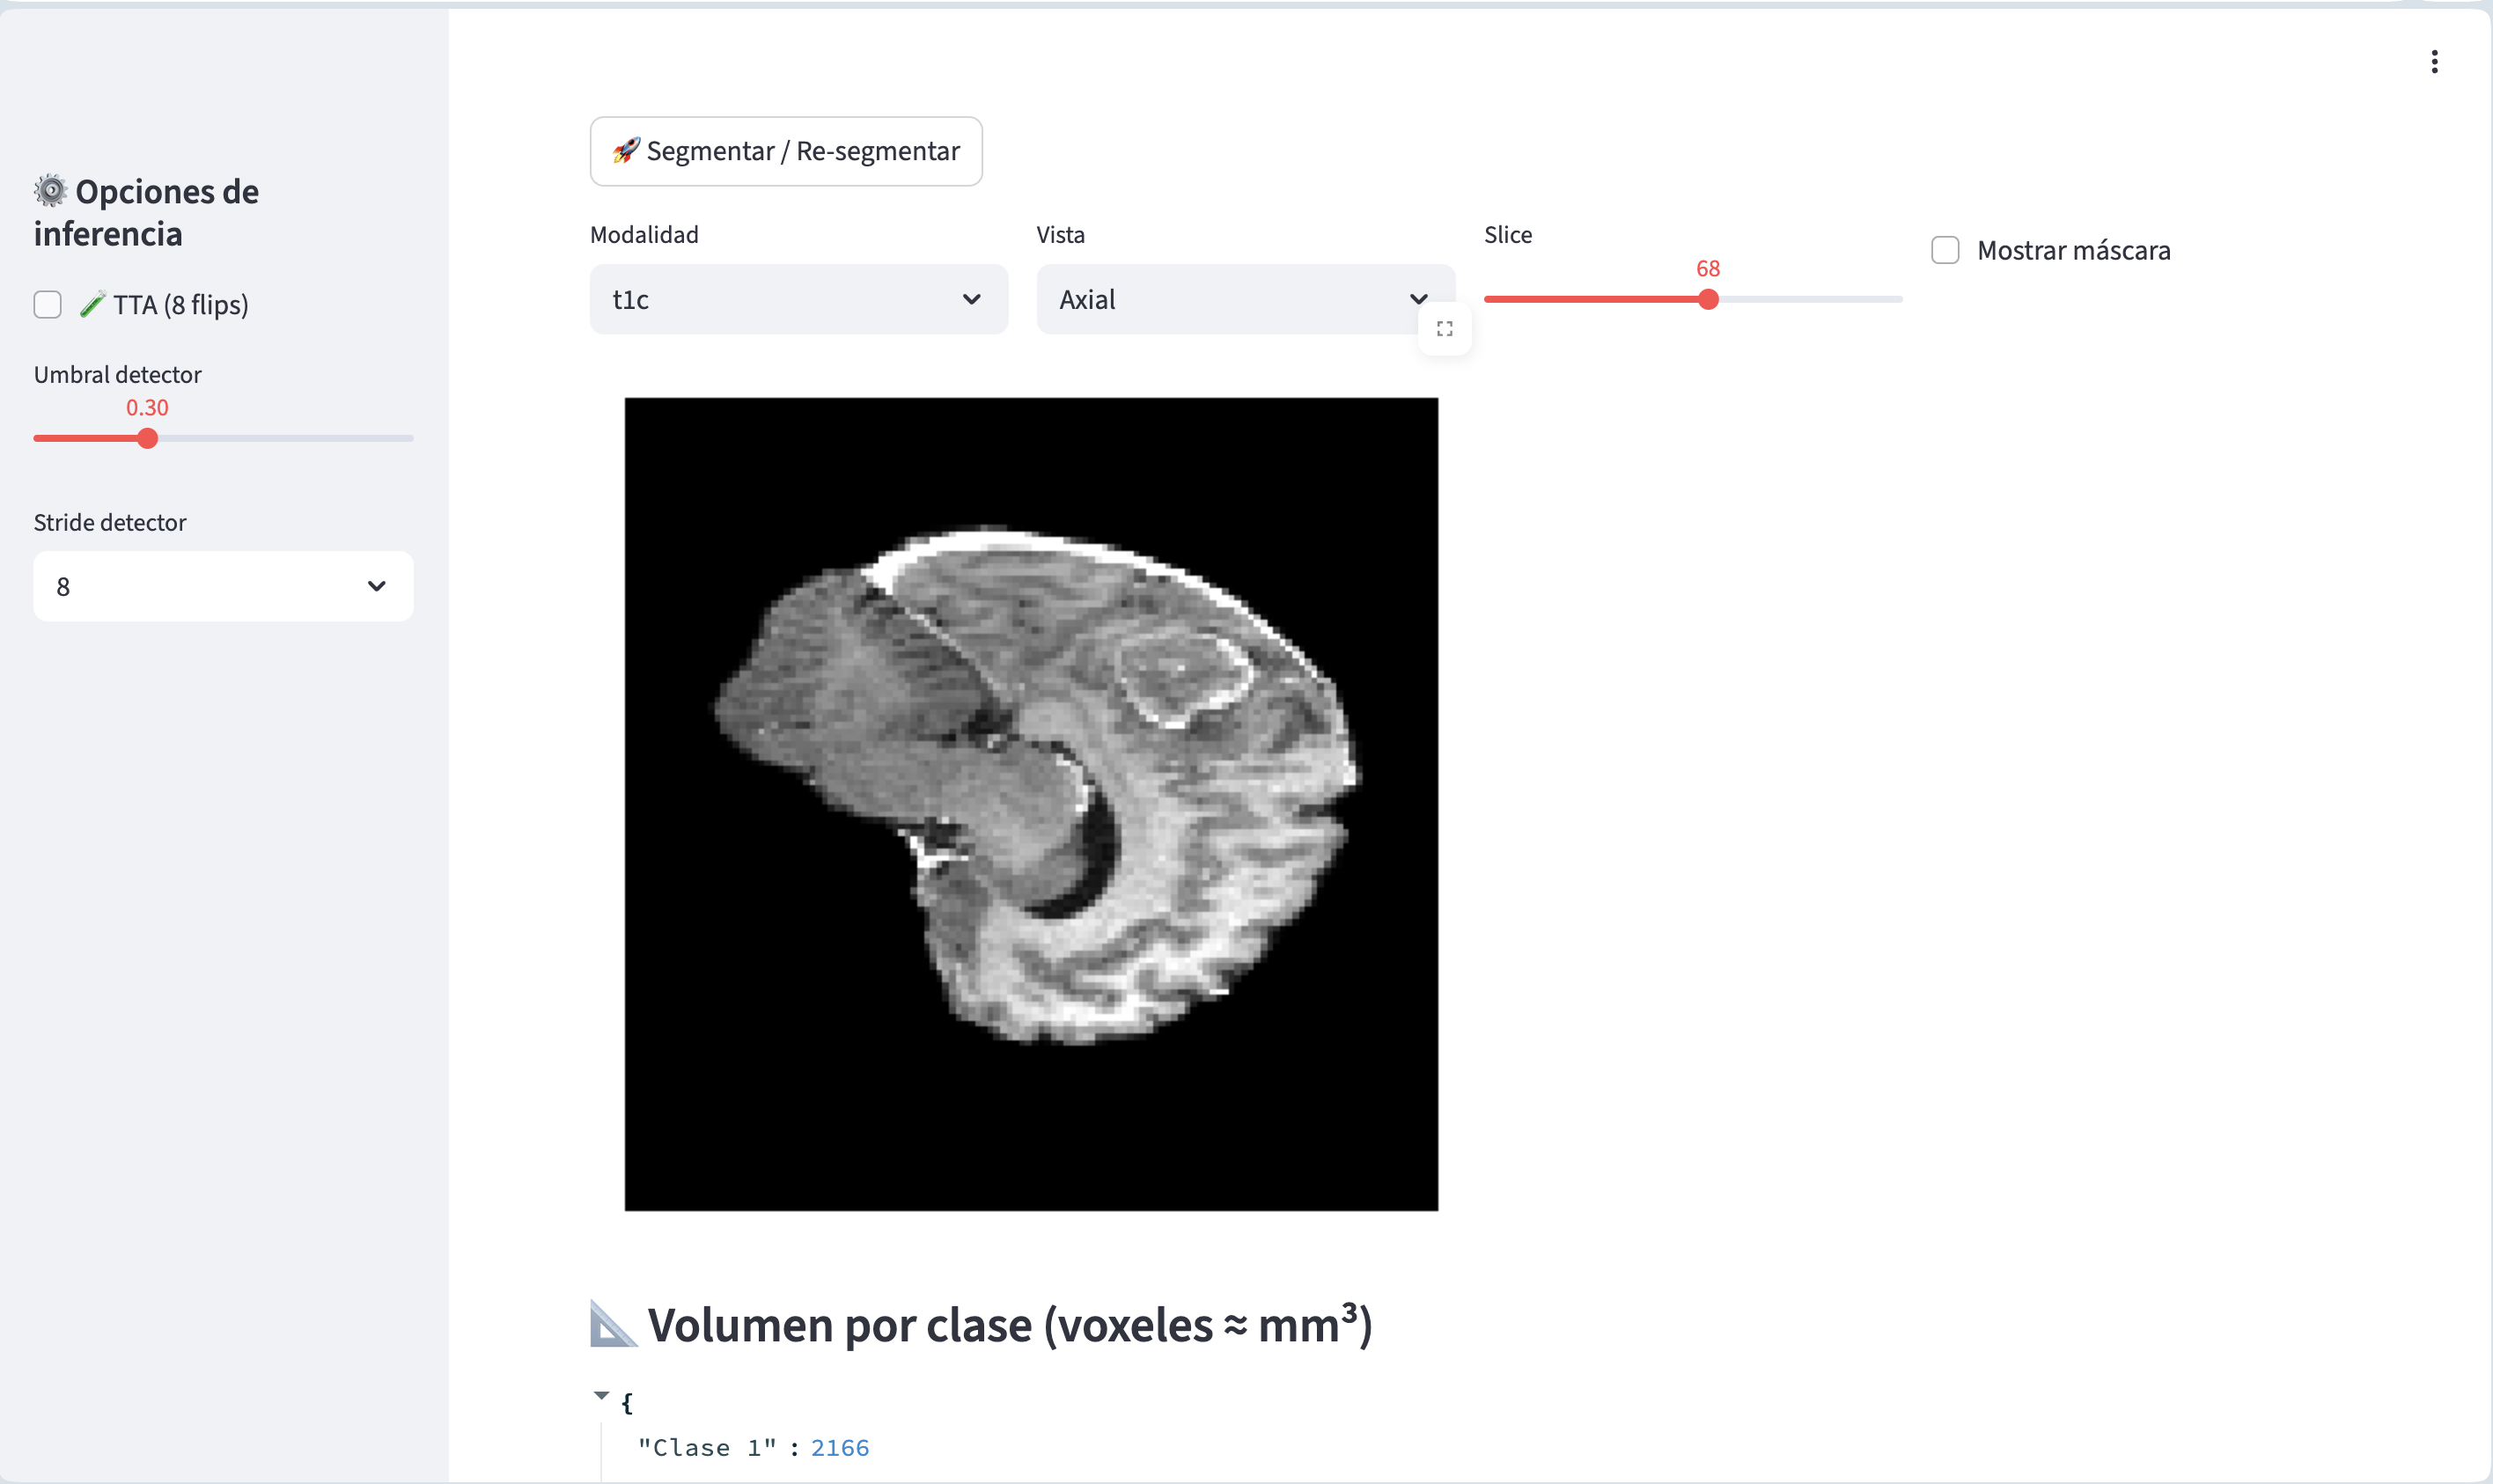

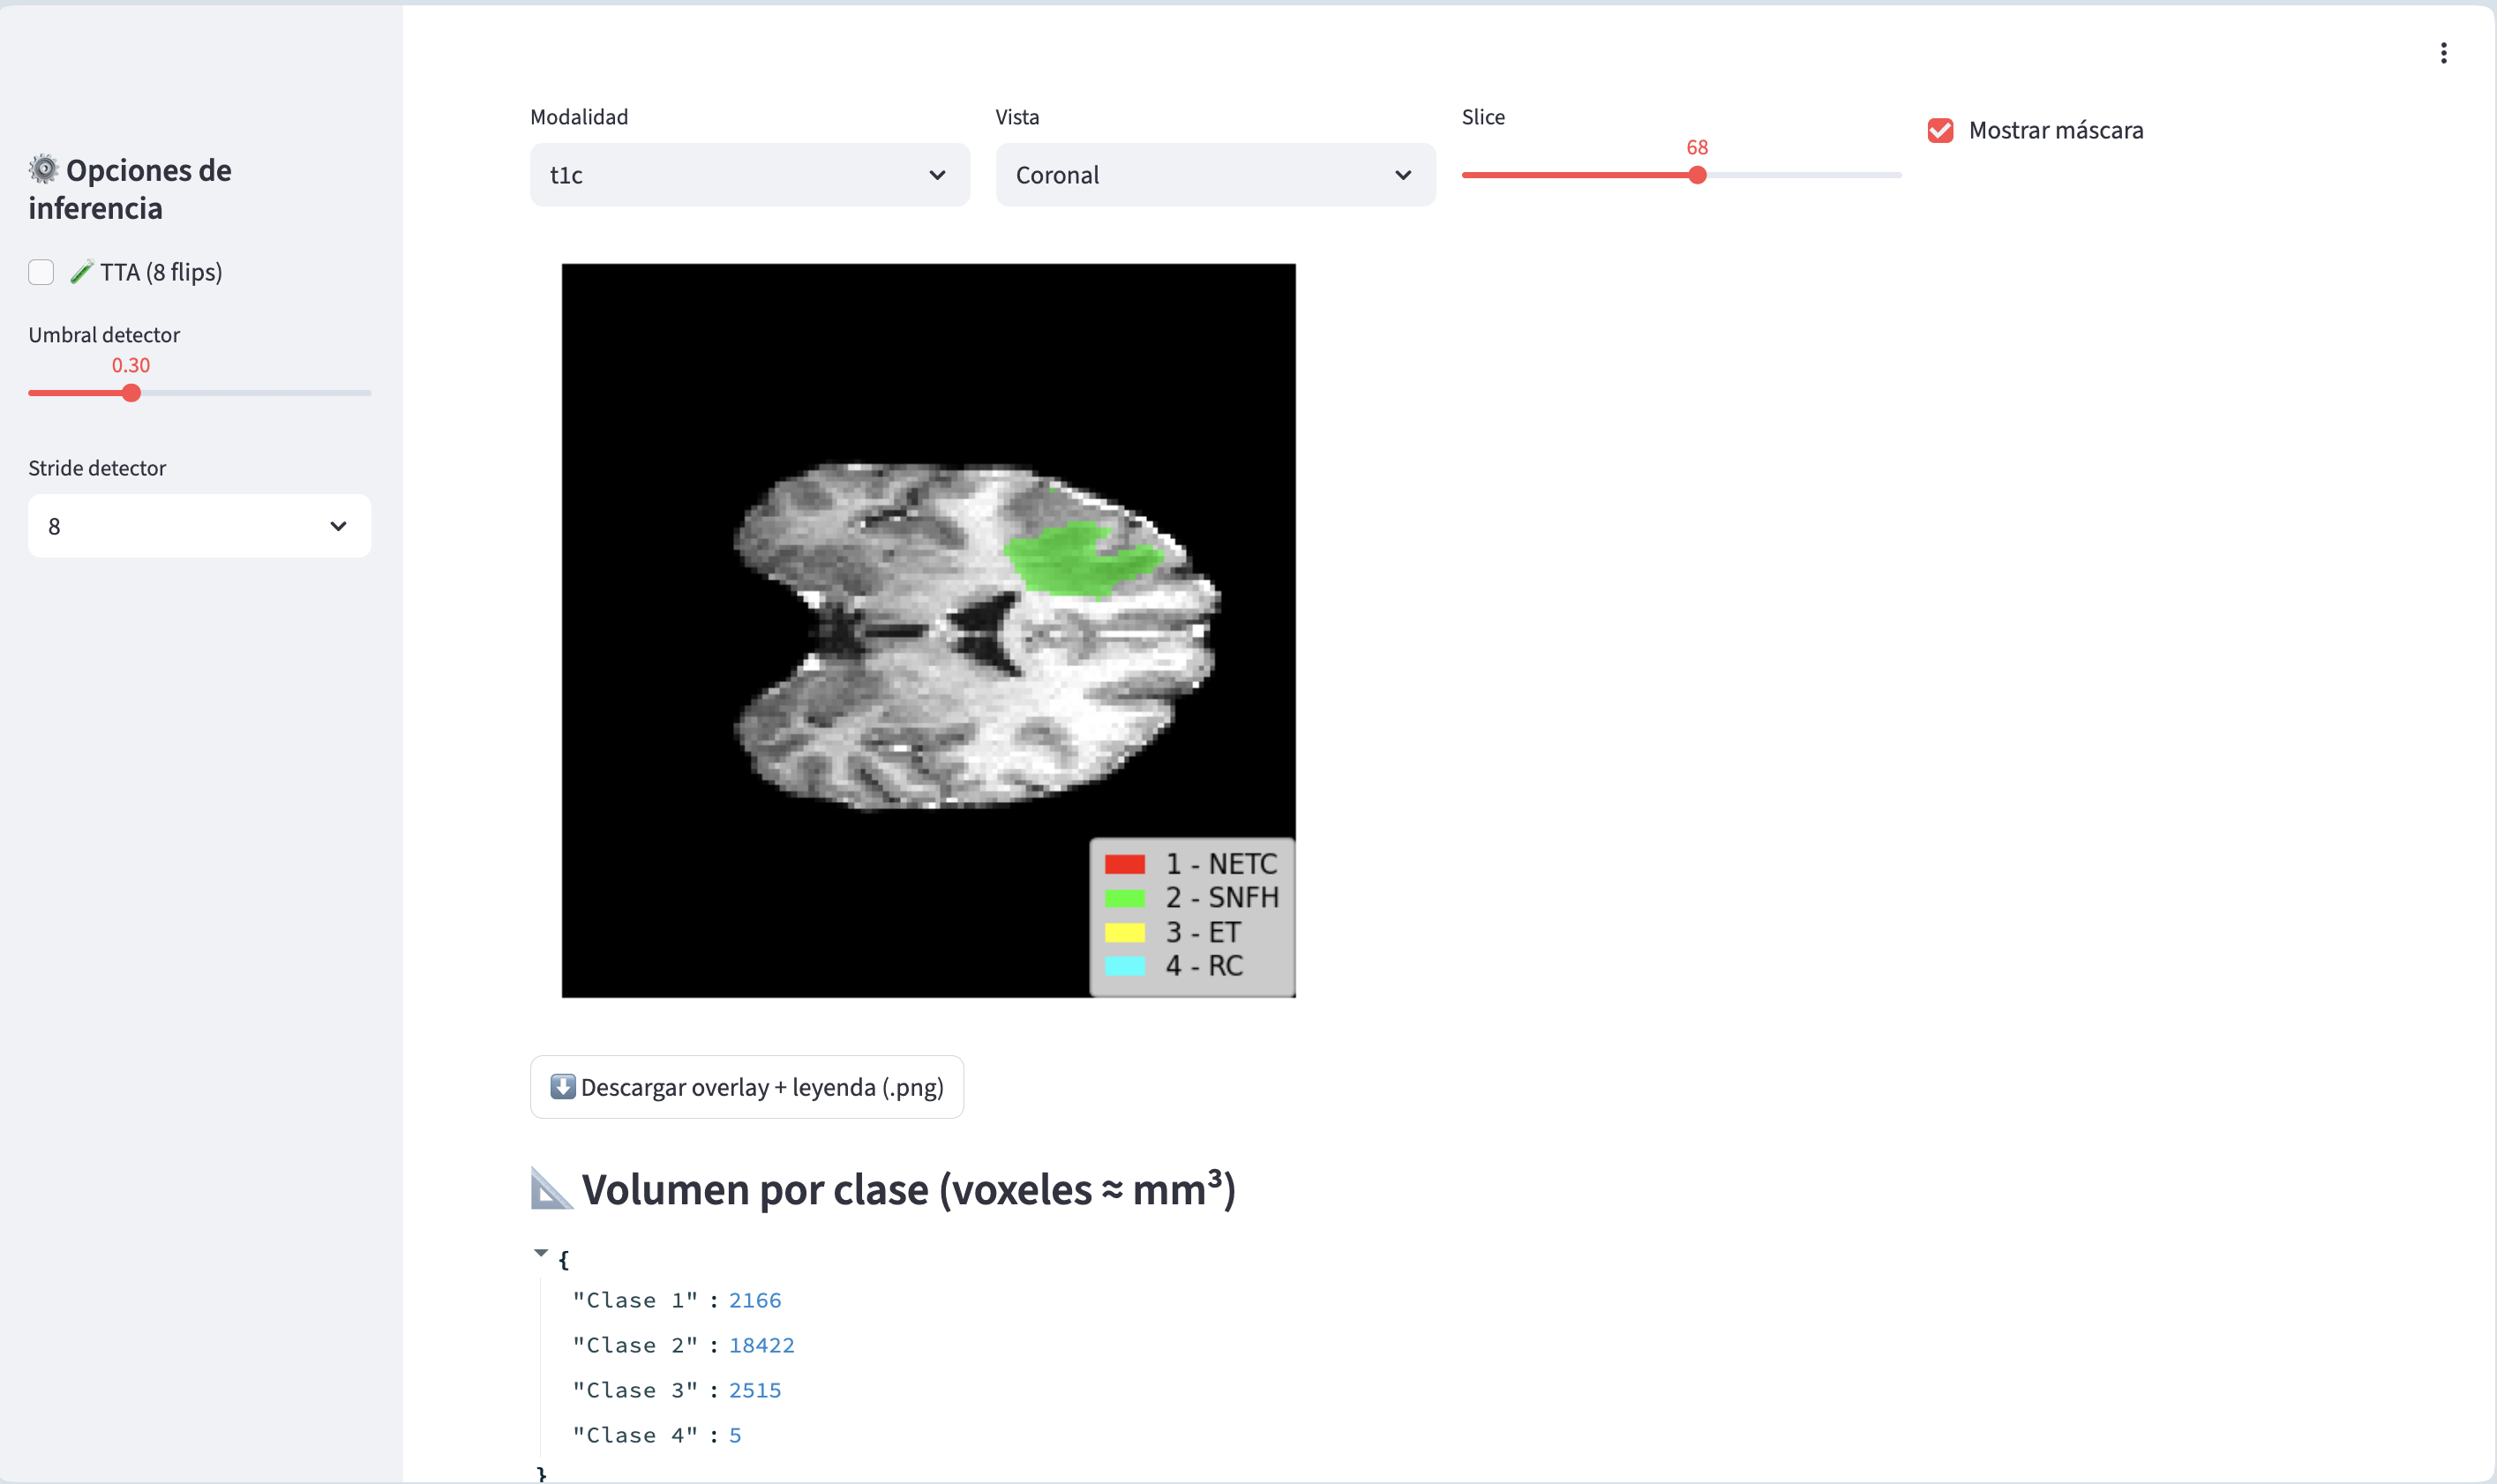

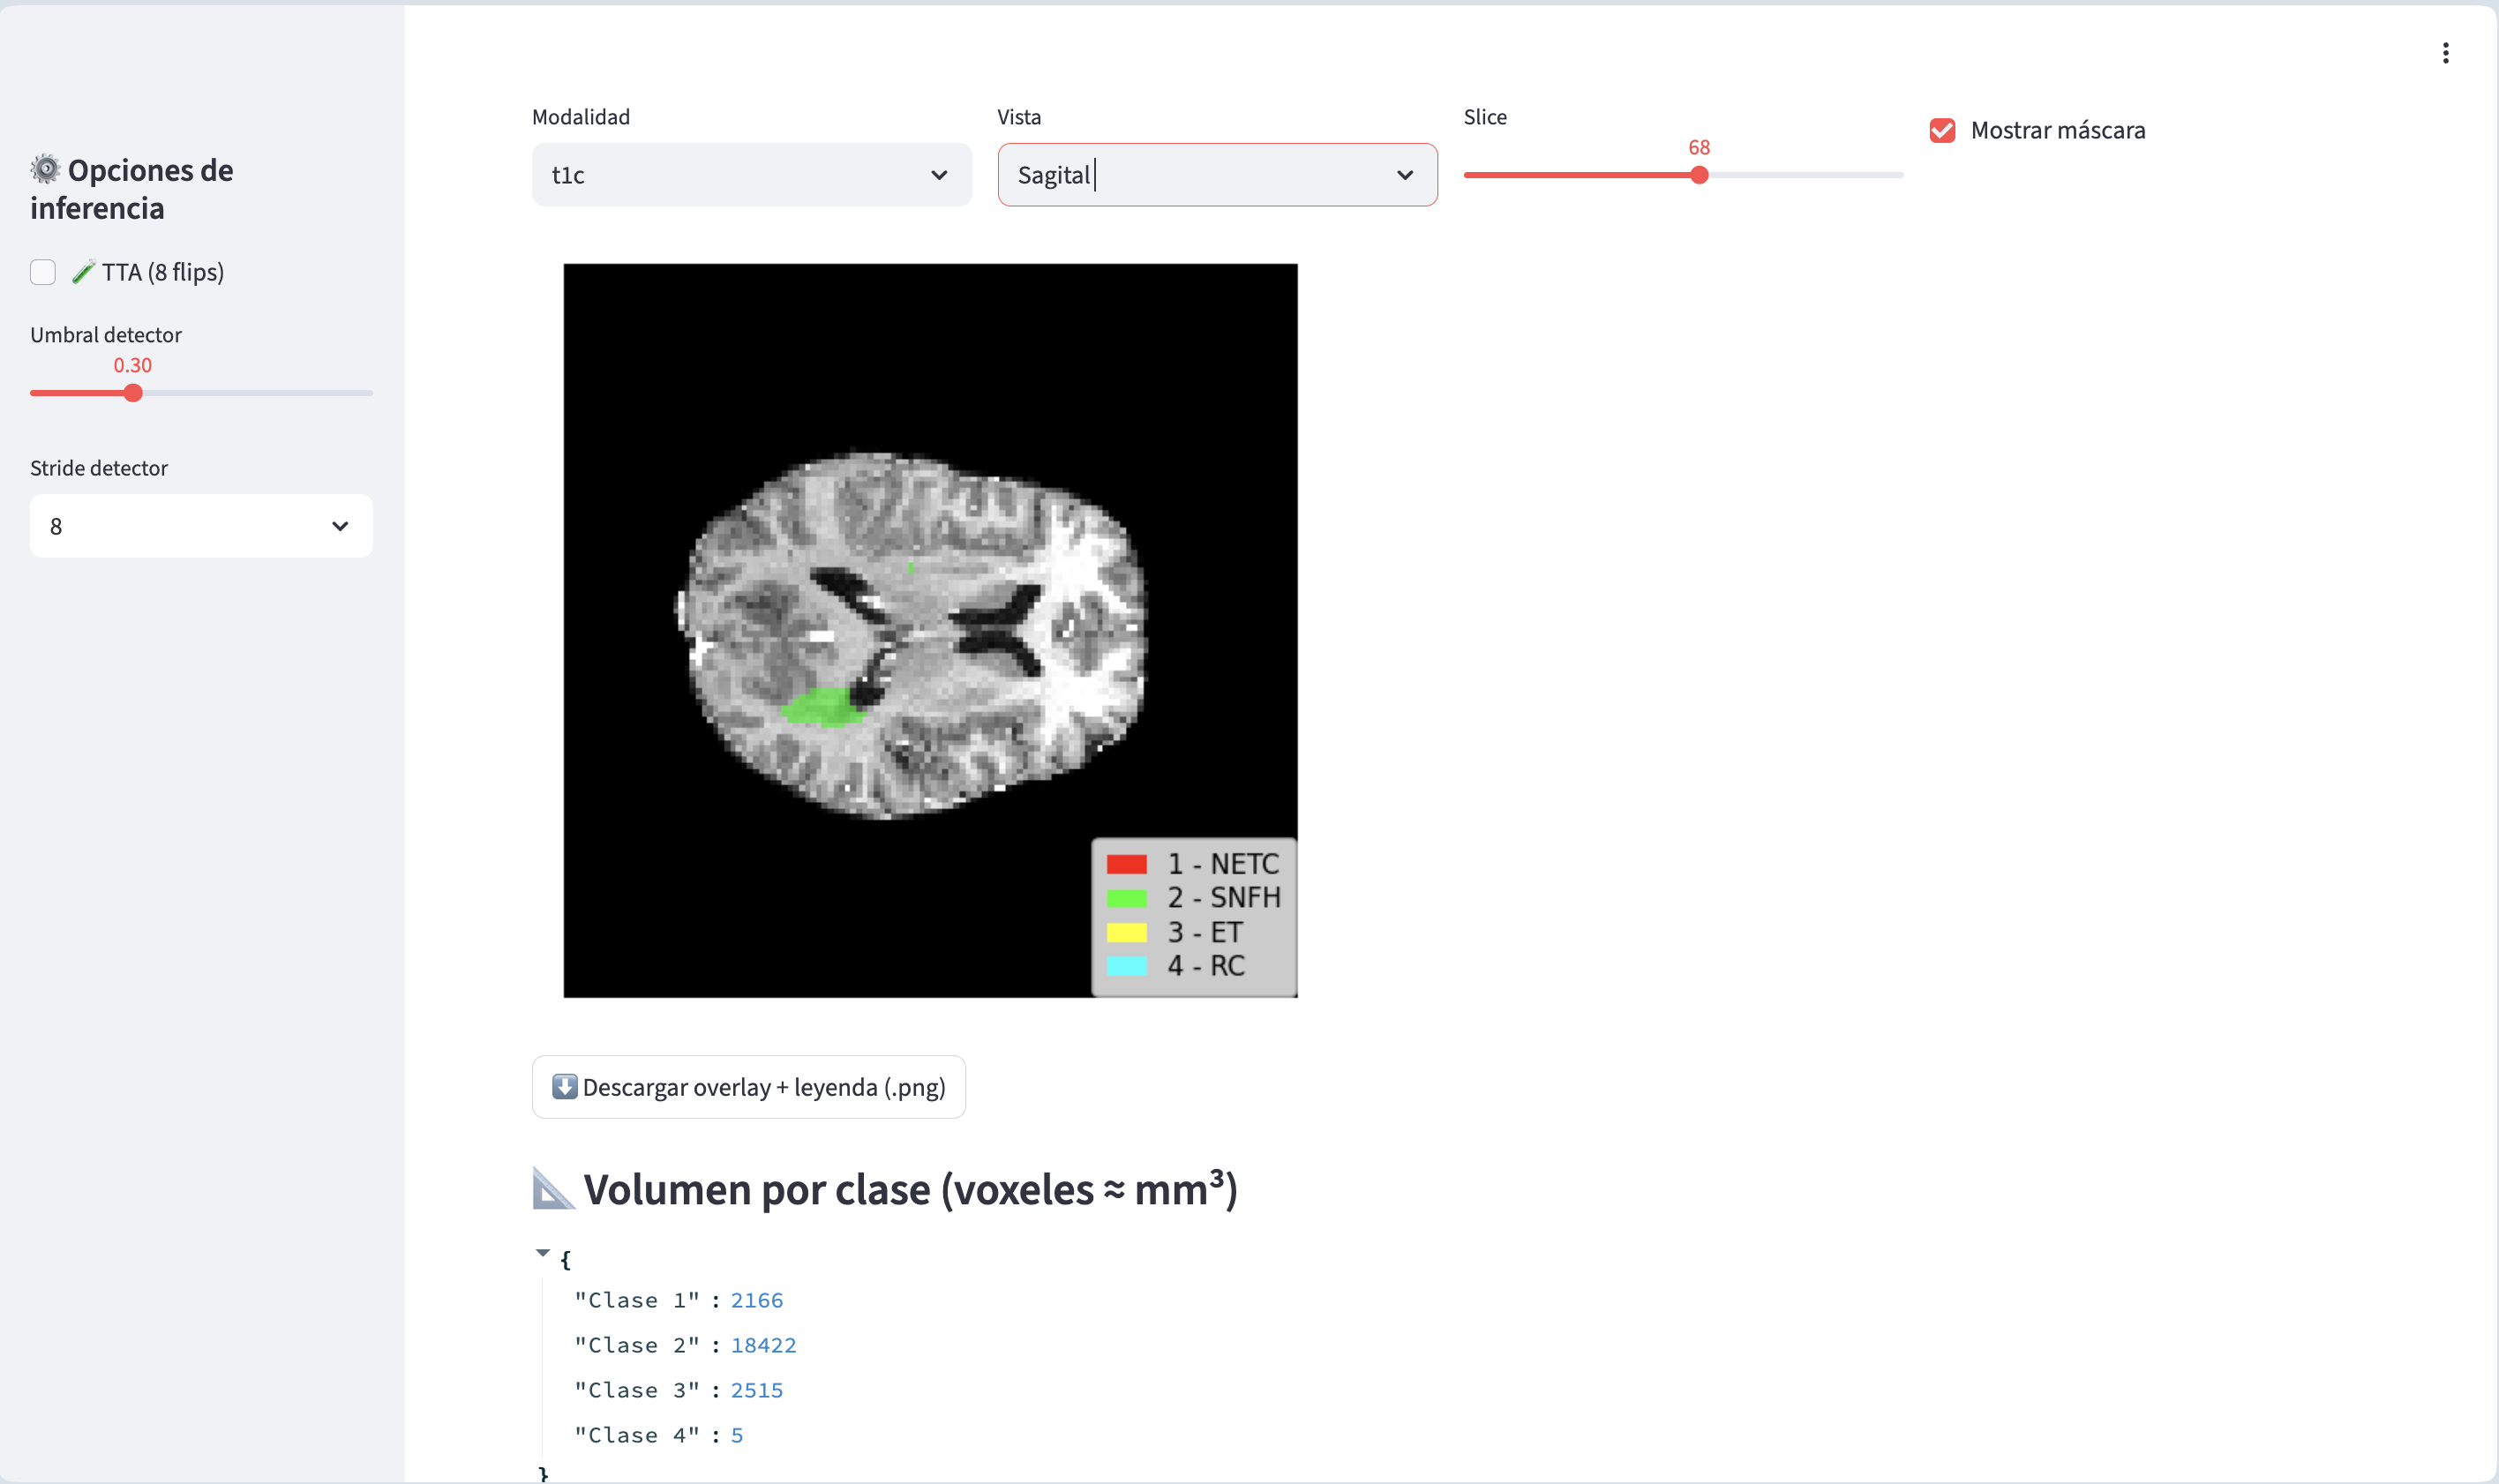

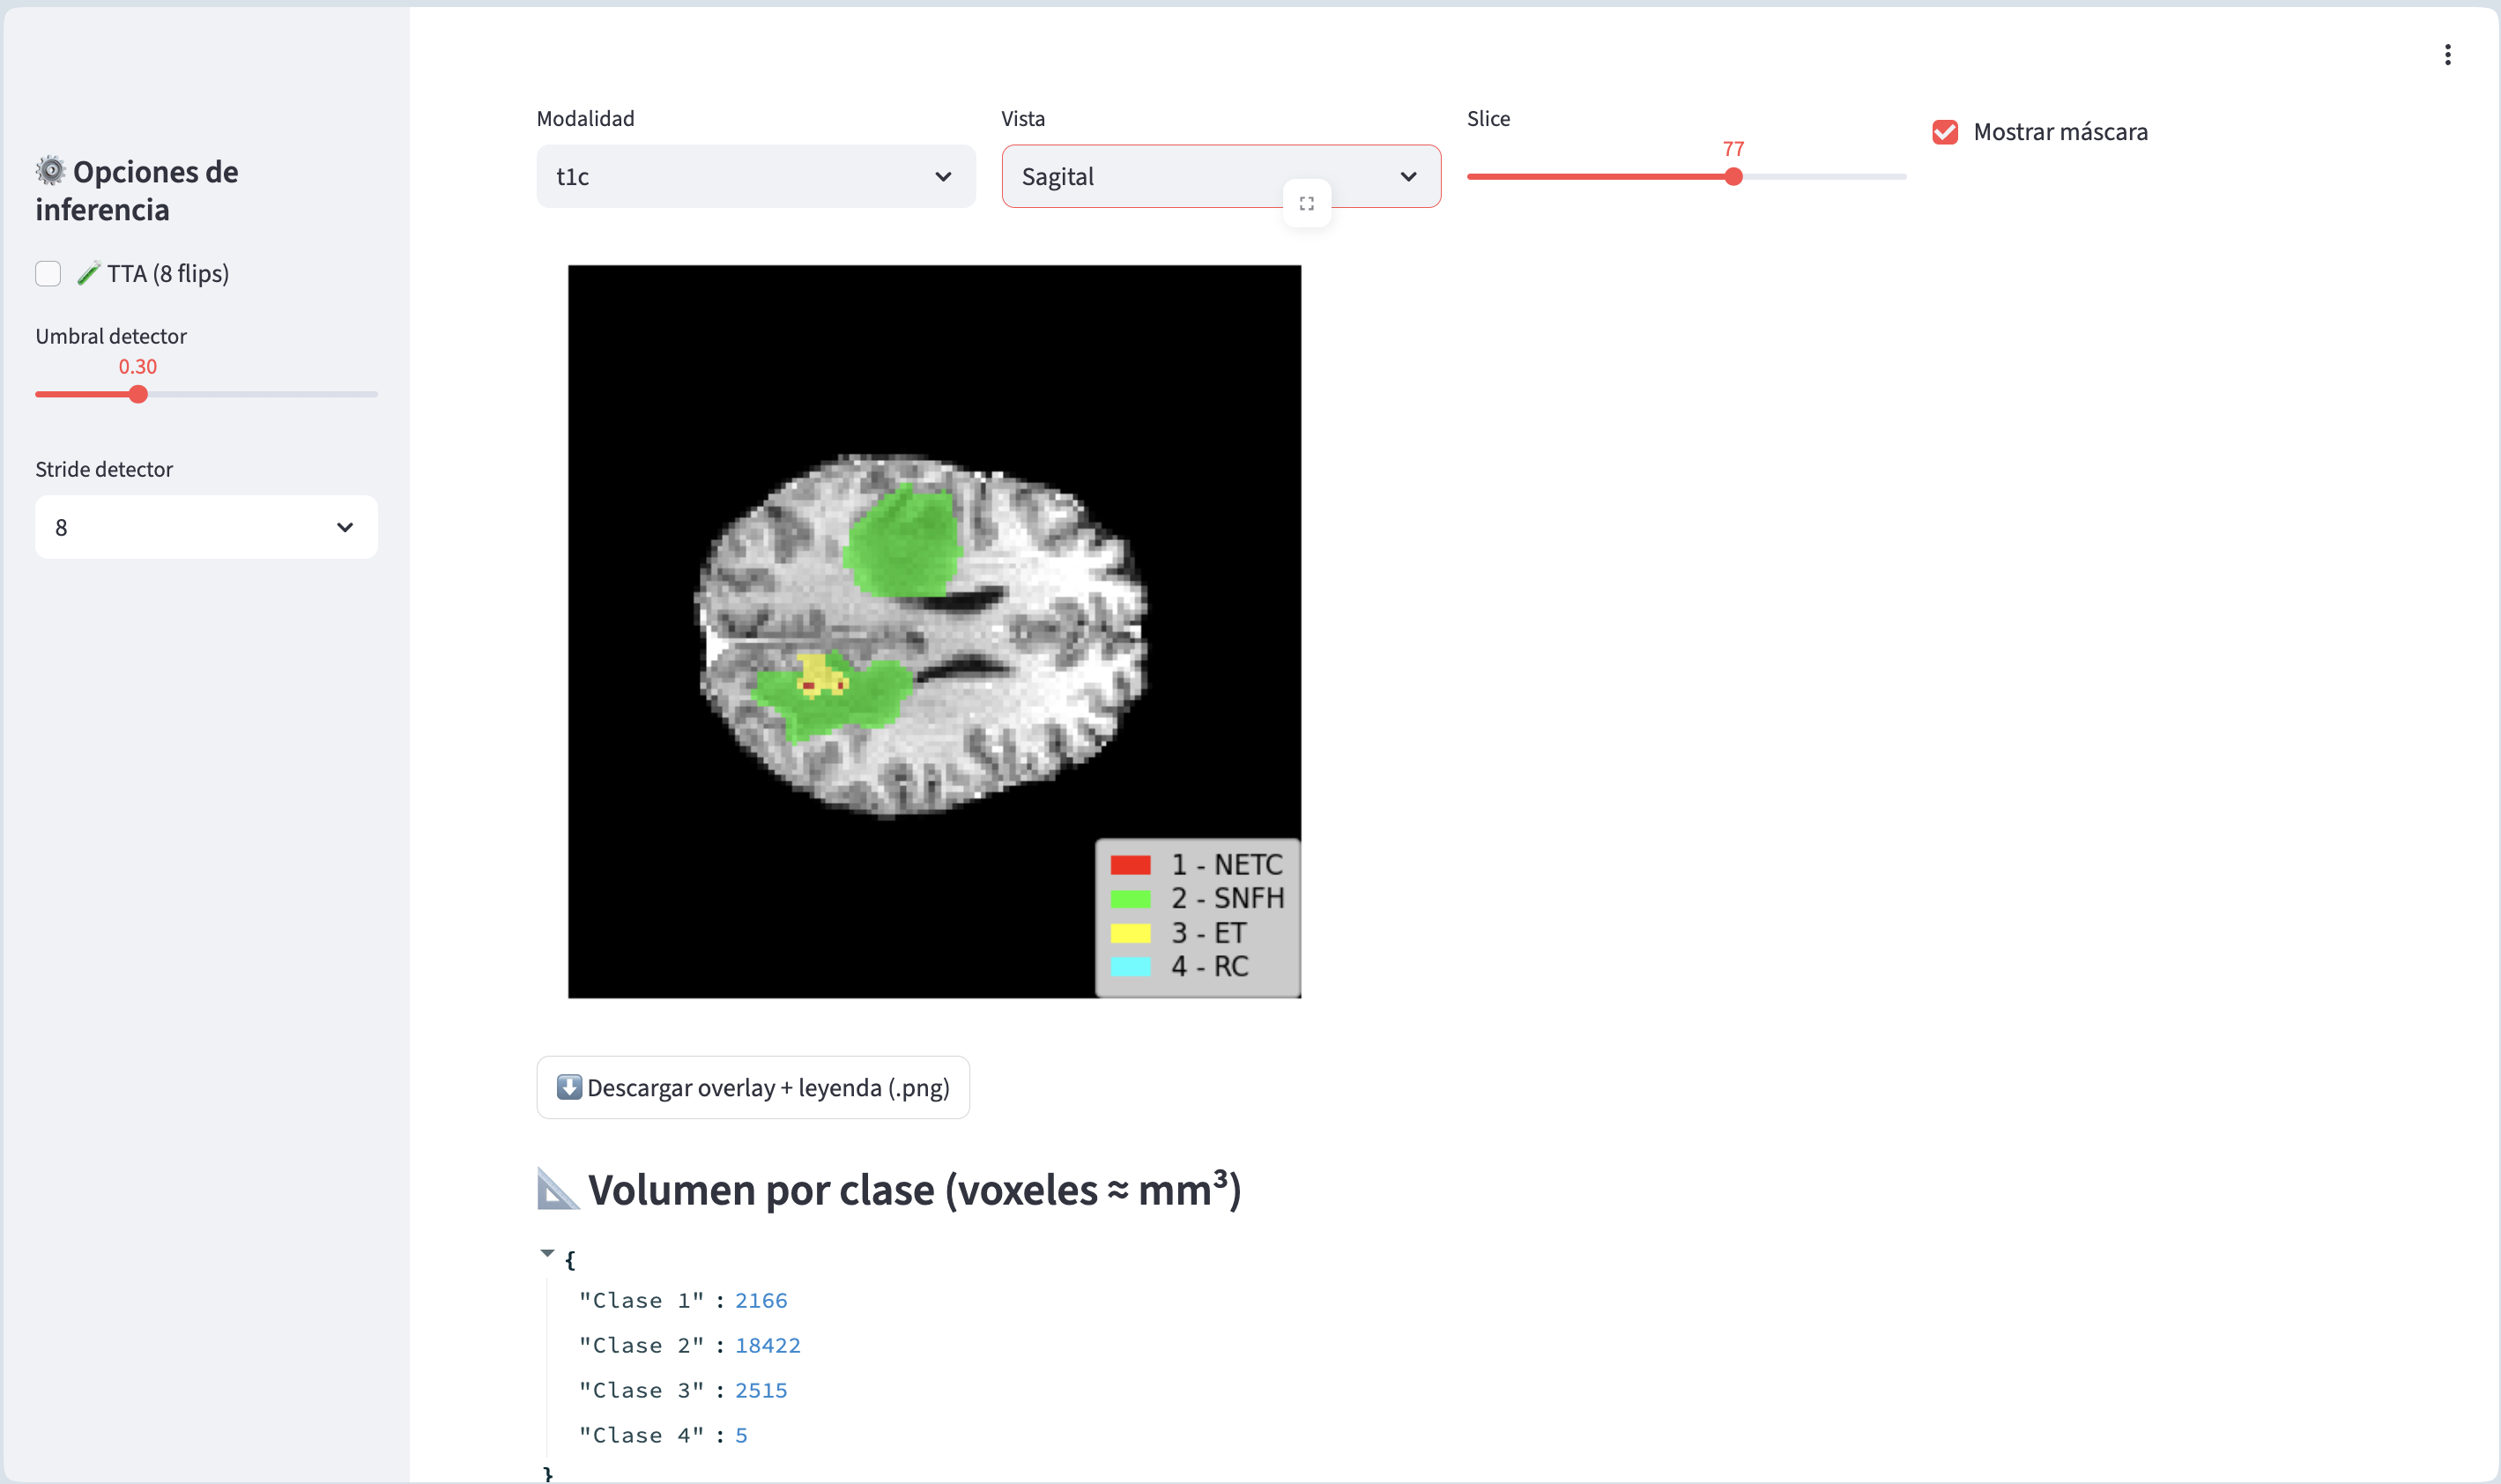

In [7]:
from IPython.display import Image, display

display(Image(filename="streamlit0.png", width=700))
display(Image(filename="streamlit1.png", width=700))
display(Image(filename="streamlit2.png", width=700))
display(Image(filename="streamlit3.png", width=700))
display(Image(filename="streamlit4.png", width=700))
display(Image(filename="streamlit5.png", width=700))
display(Image(filename="streamlit6.png", width=700))

# 9. Inferencia sobre el conjunto de validación oficial (BraTS-METS 2025)

In [10]:
# Detección binaria sobre casos de test oficial (BraTS-MET Validation)
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# Rutas
input_dir = "/notebooks/PreprocesadoValidation"  # volúmenes .npy sin máscara
output_dir = "/notebooks/outputs_test_official/detector_preds"
os.makedirs(output_dir, exist_ok=True)

# Modelos binarios (ensemble)
model_auc    = tf.keras.models.load_model("/notebooks/best_detector_advanced.keras", compile=False)
model_recall = tf.keras.models.load_model("/notebooks/best_detector_recall.keras", compile=False)

# Parámetros de sliding window
patch_size = 64
stride = 32
threshold = 0.3  # umbral bajo para recall

def extract_patches(volume, step=32, size=64):
    """Extrae parches 3D con solapamiento"""
    patches = []
    coords = []
    D, H, W, _ = volume.shape
    for z in range(0, D - size + 1, step):
        for y in range(0, H - size + 1, step):
            for x in range(0, W - size + 1, step):
                patch = volume[z:z+size, y:y+size, x:x+size, :]
                patches.append(patch)
                coords.append((z, y, x))
    return np.array(patches), coords

# Inferencia
n_detected = 0
case_files = sorted([f for f in os.listdir(input_dir) if f.endswith("_image.npy")])
print(f"Casos encontrados: {len(case_files)}")

for filename in tqdm(case_files, desc="Detección en test oficial"):
    case_id = filename.replace("_image.npy", "")
    volume_path = os.path.join(input_dir, filename)
    volume = np.load(volume_path)  # (128,128,128,4)

    patches, coords = extract_patches(volume, step=stride, size=patch_size)
    preds_auc    = model_auc.predict(patches, batch_size=32, verbose=0).flatten()
    preds_recall = model_recall.predict(patches, batch_size=32, verbose=0).flatten()
    preds_ens    = 0.5 * (preds_auc + preds_recall)

    is_positive = preds_ens >= threshold
    coords_pos  = [coords[i] for i in range(len(coords)) if is_positive[i]]
    scores_pos  = [preds_ens[i] for i in range(len(coords)) if is_positive[i]]
    n_detected += len(coords_pos)

    # Guardar coordenadas positivas
    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}_positive_patches.npz"),
        coords=coords_pos,
        scores=scores_pos
    )

print(f"Detección finalizada. Total parches detectados: {n_detected}")
print(f"Guardado en: {output_dir}")

Casos encontrados: 179


Detección en test oficial: 100%|██████████| 179/179 [02:31<00:00,  1.18it/s]

Detección finalizada. Total parches detectados: 4833
Guardado en: /notebooks/outputs_test_official/detector_preds


In [2]:
# Segmentación con modelo de parches 64³ sobre test oficial
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# Rutas
input_dir  = "/notebooks/PreprocesadoValidation"
coord_dir  = "/notebooks/outputs_test_official/detector_preds"
output_dir = "/notebooks/outputs_test_official/predicciones_64_npz"
model_path = "/notebooks/runs/unetpp3d_ds_v2_20250814-223504/best_unetpp3d_ds.keras"

os.makedirs(output_dir, exist_ok=True)

# Parámetros
patch_size   = 64
num_classes  = 5

# Cargar modelo segmentador (64³)
model = tf.keras.models.load_model(model_path, compile=False)

# Lista de casos a procesar
case_files = sorted([f for f in os.listdir(input_dir) if f.endswith("_image.npy")])
print(f"Casos para segmentar: {len(case_files)}")

# Inferencia por caso
for filename in tqdm(case_files, desc="Segmentación 64³"):
    case_id = filename.replace("_image.npy", "")
    image_path = os.path.join(input_dir, filename)
    coord_path = os.path.join(coord_dir, f"{case_id}_positive_patches.npz")

    if not os.path.exists(coord_path):
        print(f"Coordenadas no encontradas para {case_id}. Saltando...")
        continue

    volume = np.load(image_path)  # (128,128,128,4)
    data   = np.load(coord_path)
    coords = data["coords"]

    softmax_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)
    count_volume   = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)

    for (z, y, x) in coords:
        if z + patch_size > volume.shape[0] or y + patch_size > volume.shape[1] or x + patch_size > volume.shape[2]:
            continue  # Evitar overflow fuera de volumen

        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, axis=0).astype(np.float32)  # (1,64,64,64,4)

        pred = model.predict(patch, verbose=0)
        if isinstance(pred, (list, tuple)):
            pred = pred[0]
        if pred.shape[0] == 1:
            pred = pred[0]  # (64,64,64,5)

        softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred
        count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

    # Normalización
    count_volume[count_volume == 0] = 1
    softmax_avg = softmax_volume / count_volume

    # Guardar softmax
    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}.npz"),
        softmax=softmax_avg
    )

print("Segmentación 64³ finalizada. Softmax guardados en:", output_dir)

Casos para segmentar: 179


Segmentación 64³: 100%|██████████| 179/179 [12:58<00:00,  4.35s/it]

Segmentación 64³ finalizada. Softmax guardados en: /notebooks/outputs_test_official/predicciones_64_npz


In [7]:
# Segmentación con modelo de parches 96³ sobre test oficial
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# Rutas
input_dir  = "/notebooks/PreprocesadoValidation"
coord_dir  = "/notebooks/outputs_test_official/detector_preds"
output_dir = "/notebooks/outputs_test_official/predicciones_96_npz"
model_path = "/notebooks/runs/unetpp3d_ds_v2_96/best_unetpp3d_ds_96.keras"

os.makedirs(output_dir, exist_ok=True)

# Parámetros
patch_size   = 96
num_classes  = 5

# Cargar modelo segmentador (96³)
model = tf.keras.models.load_model(model_path, compile=False)

# Lista de casos a procesar
case_files = sorted([f for f in os.listdir(input_dir) if f.endswith("_image.npy")])
print(f"Casos para segmentar: {len(case_files)}")

# Inferencia por caso
for filename in tqdm(case_files, desc="Segmentación 96³"):
    case_id = filename.replace("_image.npy", "")
    image_path = os.path.join(input_dir, filename)
    coord_path = os.path.join(coord_dir, f"{case_id}_positive_patches.npz")

    if not os.path.exists(coord_path):
        print(f"Coordenadas no encontradas para {case_id}. Saltando...")
        continue

    volume = np.load(image_path)  # (128,128,128,4)
    data   = np.load(coord_path)
    coords = data["coords"]

    softmax_volume = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)
    count_volume   = np.zeros(volume.shape[:3] + (num_classes,), dtype=np.float32)

    for (z, y, x) in coords:
        if z + patch_size > volume.shape[0] or y + patch_size > volume.shape[1] or x + patch_size > volume.shape[2]:
            continue  

        patch = volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :]
        patch = np.expand_dims(patch, axis=0).astype(np.float32)  # (1,96,96,96,4)

        pred = model.predict(patch, verbose=0)
        if isinstance(pred, (list, tuple)):
            pred = pred[0]
        if pred.shape[0] == 1:
            pred = pred[0]  # (96,96,96,5)

        softmax_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += pred
        count_volume[z:z+patch_size, y:y+patch_size, x:x+patch_size, :] += 1

    # Normalización
    count_volume[count_volume == 0] = 1
    softmax_avg = softmax_volume / count_volume

    # Guardar softmax
    np.savez_compressed(
        os.path.join(output_dir, f"{case_id}.npz"),
        softmax=softmax_avg
    )

print("Segmentación 96³ finalizada. Softmax guardados en:", output_dir)

Casos para segmentar: 179


Segmentación 96³: 100%|██████████| 179/179 [10:36<00:00,  3.56s/it]

Segmentación 96³ finalizada. Softmax guardados en: /notebooks/outputs_test_official/predicciones_96_npz


In [11]:
import os
import numpy as np
from tqdm import tqdm

# Rutas
pred_dir_96 = "/notebooks/outputs_test_official/predicciones_96_npz"
pred_dir_64 = "/notebooks/outputs_test_official/predicciones_64_npz"
output_dir = "/notebooks/outputs_test_official/ensemble"

os.makedirs(output_dir, exist_ok=True)

# Obtener IDs de los archivos en ambas carpetas
ids_96 = {f.replace(".npz", "") for f in os.listdir(pred_dir_96) if f.endswith(".npz")}
ids_64 = {f.replace(".npz", "") for f in os.listdir(pred_dir_64) if f.endswith(".npz")}

# Intersección de casos presentes en ambas carpetas
common_ids = sorted(list(ids_96 & ids_64))
print(f"Casos comunes para ensemble: {len(common_ids)}")

# Ensemble voxel-wise por clase
for case_id in tqdm(common_ids, desc="Ensemble voxelwise por clase"):
    path_96 = os.path.join(pred_dir_96, f"{case_id}.npz")
    path_64 = os.path.join(pred_dir_64, f"{case_id}.npz")

    softmax_96 = np.load(path_96)["softmax"]
    softmax_64 = np.load(path_64)["softmax"]

    if softmax_96.shape != softmax_64.shape:
        raise ValueError(f"Shape mismatch en {case_id}: 96={softmax_96.shape}, 64={softmax_64.shape}")

    # Inicializar volumen ensemble
    ensemble = np.zeros_like(softmax_96, dtype=np.float32)

    # Fondo (clase 0): promedio
    ensemble[..., 0] = 0.5 * (softmax_96[..., 0] + softmax_64[..., 0])

    # Clases 1–3: usar modelo 96
    for cls in [1, 2, 3]:
        ensemble[..., cls] = softmax_96[..., cls]

    # Clase 4: usar modelo 64
    ensemble[..., 4] = softmax_64[..., 4]

    # Guardar resultado
    np.savez_compressed(os.path.join(output_dir, f"{case_id}.npz"), softmax=ensemble)

print("Ensemble voxelwise completado.")

Casos comunes para ensemble: 179


Ensemble voxelwise por clase: 100%|██████████| 179/179 [08:25<00:00,  2.83s/it]

Ensemble voxelwise completado.


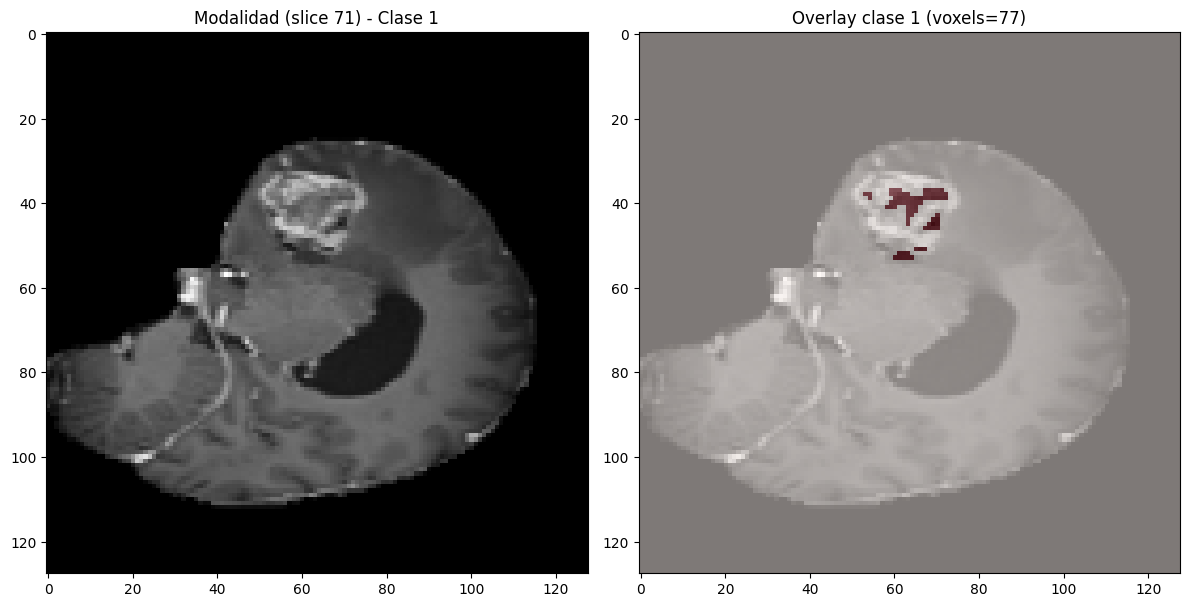

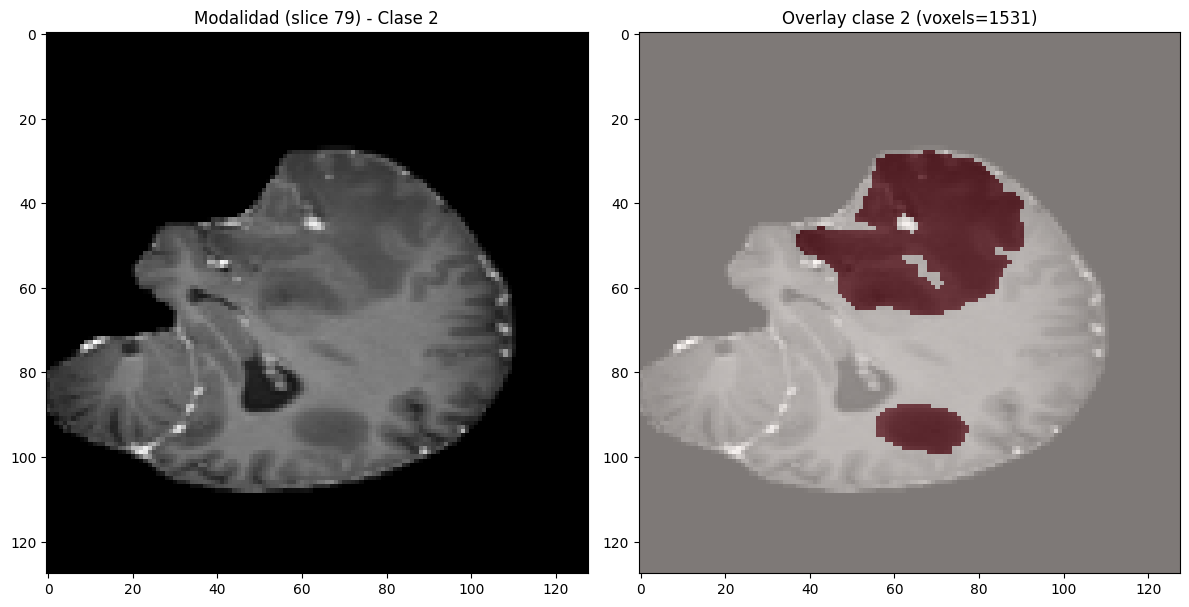

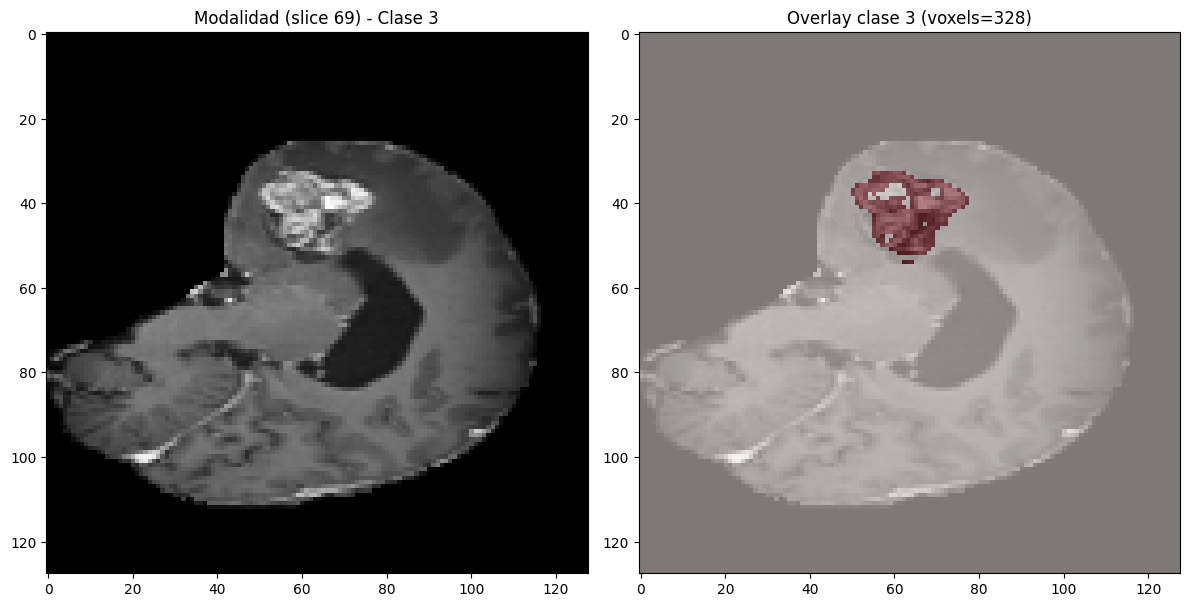

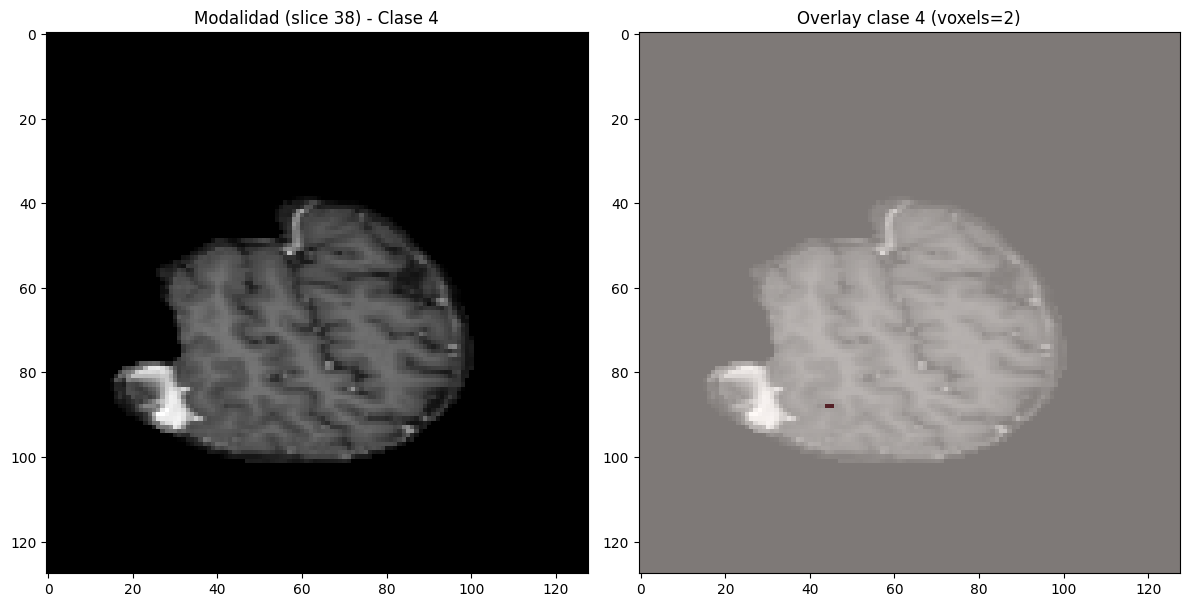

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
case_id = "BraTS-MET-00834-000"
ensemble_path = f"/notebooks/outputs_test_official/ensemble/{case_id}.npz"
modalidad_path = f"/notebooks/PreprocesadoValidation/{case_id}_image.npy"  # Para superponer
modalidad_idx = 1  # T1c = canal 1
classes = [1, 2, 3, 4]

# --- Cargar softmax y modalidad ---
data = np.load(ensemble_path)["softmax"]  # (128, 128, 128, 5)
modalidad = np.load(modalidad_path)[..., modalidad_idx]

# --- Obtener predicción dura ---
pred = np.argmax(data, axis=-1)  # (128, 128, 128)

# --- Buscar slice con más voxeles por clase ---
for cls in classes:
    max_voxels = 0
    best_z = None
    for z in range(pred.shape[0]):
        count = np.sum(pred[z] == cls)
        if count > max_voxels:
            max_voxels = count
            best_z = z
    if best_z is not None and max_voxels > 0:
        # --- Visualización ---
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        ax[0].imshow(modalidad[best_z], cmap="gray")
        ax[0].set_title(f"Modalidad (slice {best_z}) - Clase {cls}")
        ax[1].imshow(modalidad[best_z], cmap="gray")
        ax[1].imshow(pred[best_z] == cls, alpha=0.5, cmap="Reds")
        ax[1].set_title(f"Overlay clase {cls} (voxels={max_voxels})")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Clase {cls}: no presente en {case_id}")